# Librerias

In [ ]:
pip install edaspy

In [ ]:
pip install pybnesian

In [ ]:
pip install pgmpy

In [ ]:
import EDAspy.optimization
print(dir(EDAspy.optimization))


['EBNA', 'EDA', 'EGNA', 'EMNA', 'EdaResult', 'MultivariateKEDA', 'SPEDA', 'UMDAc', 'UMDAcat', 'UMDAd', 'UnivariateKEDA', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'arcs2adj_mat', 'custom', 'eda', 'eda_result', 'multivariate', 'plot_bn', 'tools', 'univariate', 'utils']


EDAspy no puede generar distribuciones. Es decir, no proporciona una forma directa y fácil de generar nuevas soluciones (es decir, muestrear) a partir de un modelo de probabilidad aprendido.

In [ ]:
pip install cma

# EMNA con local search

IT:  0 	Best cost:  63780
IT:  1 	Best cost:  63780
IT:  2 	Best cost:  63780
IT:  3 	Best cost:  63780
IT:  4 	Best cost:  63780
IT:  5 	Best cost:  63780
IT:  6 	Best cost:  63780
IT:  7 	Best cost:  63780
IT:  8 	Best cost:  63780
IT:  9 	Best cost:  63620
IT:  10 	Best cost:  63530
IT:  11 	Best cost:  63530
IT:  12 	Best cost:  63530
IT:  13 	Best cost:  63430
IT:  14 	Best cost:  63430
IT:  15 	Best cost:  63400
IT:  16 	Best cost:  63340
IT:  17 	Best cost:  63340
IT:  18 	Best cost:  63180
	NFEVALS = 2000 F = 63180
	X = [1852.34047246 1377.6767082  1550.30970846 1879.56792313 1609.4177709
 1671.36677057 1725.99584876 1601.44294222 1489.22548869 1605.94608881
 1687.50898083 1323.08482887 1564.85571979 1479.2182039  1529.06817965
 1553.69869431 1401.25420484 1872.29462985 1741.84686377 1821.82569077
 1624.1140639  1632.16663168 1738.83937701 1487.36086708 1500.07843202
 1469.00482073 1431.43049707 1764.25034759 1244.5092662  1818.64192185
 1478.03307362 1667.67304841 1541.3192755

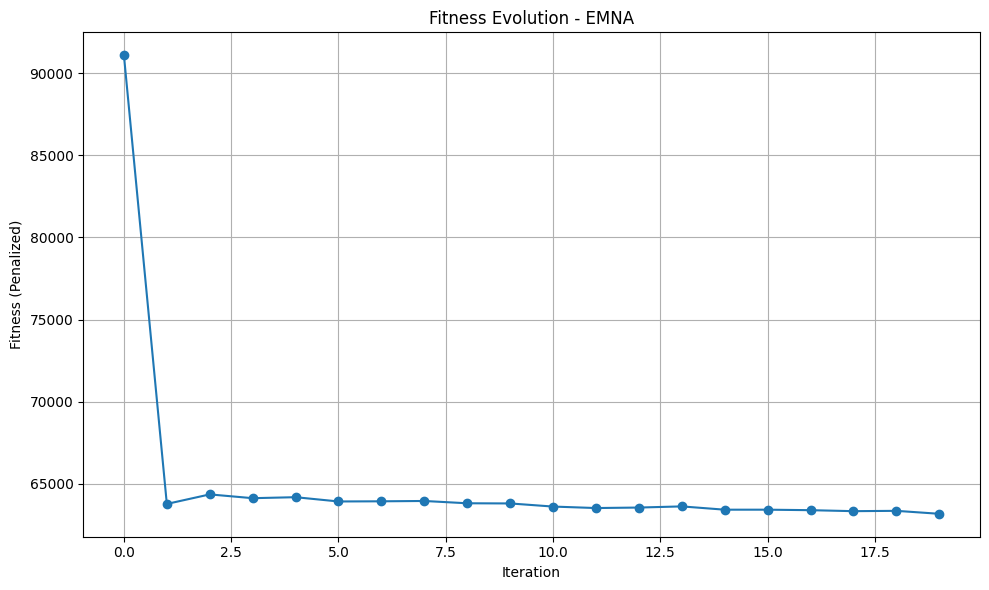

In [ ]:
from EDAspy.optimization import EMNA
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time

warnings.filterwarnings("ignore", category=RuntimeWarning)

rows = 8
cols = 8
iterations = 20

alpha = 60
beta = 10

total_sum = np.random.randint(10000, 20000)

row_margins = np.random.randint(2000, 6000, size=rows)
row_margins = np.round(row_margins / row_margins.sum() * total_sum).astype(int)

col_margins = np.random.randint(2000, 6000, size=cols)
col_margins = np.round(col_margins / col_margins.sum() * total_sum).astype(int)

row_margins[-1] += total_sum - row_margins.sum()
col_margins[-1] += total_sum - col_margins.sum()

dimensions = rows * cols

def generate_initial_matrix(row_margins, col_margins):
    matrix = np.random.randint(20, 100, size=(len(row_margins), len(col_margins)))
    matrix = (matrix / matrix.sum()) * np.sum(row_margins)
    return np.round(matrix).astype(int)

def normalize_matrix(matrix, row_margins, col_margins, max_iter=100):
    matrix = np.maximum(matrix, 1.0)
    for _ in range(max_iter):
        row_sums = matrix.sum(axis=1, keepdims=True)
        matrix *= row_margins[:, None] / (row_sums + 1e-10)
        col_sums = matrix.sum(axis=0, keepdims=True)
        matrix *= col_margins / (col_sums + 1e-10)
    return np.round(matrix).astype(int)

def combined_penalty(matrix, row_margins, col_margins, initial_matrix, alpha=60, beta=10):
    row_diff = np.abs(np.sum(matrix, axis=1) - row_margins)
    col_diff = np.abs(np.sum(matrix, axis=0) - col_margins)
    margin_penalty = np.sum(row_diff**2) + np.sum(col_diff**2)
    similarity_penalty = np.sum(np.abs(matrix - initial_matrix))
    return alpha * margin_penalty + beta * similarity_penalty

def local_search_with_noise(X, row_margins, col_margins, initial_matrix, alpha=60, beta=10, trials=50, std=0.01):
    best_X = X.copy()

    # Calcula el fitness inicial tras normalizar para cumplir con los márgenes
    best_fitness = combined_penalty(
        normalize_matrix(X.reshape((rows, cols)), row_margins, col_margins),
        row_margins, col_margins, initial_matrix, alpha, beta)
    best_perturbed_X = X.copy()
    improved = False

    for _ in range(trials):
        # Se genera el ruido y se aplica a cada componente de X
        noise = np.random.normal(loc=0, scale=std, size=X.shape)
        perturbed_X = X + X * noise

        # Se convierte el vector perturbado a formato matriz y se normaliza para que cumpla con los margenes fila/columna
        matrix = perturbed_X.reshape((rows, cols))
        matrix = normalize_matrix(matrix, row_margins, col_margins)

        # Se calcula el fitness de la nueva matriz
        fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix, alpha, beta)

        # Si el fitness es mejor que el mejor hasta ahora, se guarda esta nueva solución
        if fitness < best_fitness:
            best_fitness = fitness
            best_X = matrix.flatten()
            best_perturbed_X = perturbed_X.copy()
            improved = True

    if improved:
        print("\nMejor 'perturbed_X':")
        print(best_perturbed_X)
    else:
        print("\nLocal search no mejoró el fitness.")

    return best_X.reshape((rows, cols)), best_fitness, best_perturbed_X.reshape((rows, cols)), improved

def run_emna(row_margins, col_margins, dimensions, iterations, initial_matrix):
    emna = EMNA(size_gen=100, max_iter=iterations, dead_iter=10,
                n_variables=dimensions, lower_bound=1, upper_bound=max(row_margins.max(), col_margins.max()))

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()
    #Minimize the fitness function (search for lower best cost)
    result = emna.minimize(fitness_function)
    end_time = time.time()

    best_matrix = result.best_ind.reshape((len(row_margins), len(col_margins)))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Local search after EMNA
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix)

    # If local search no mejora, se usa el resultado de EMNA
    if not improved:
        print("\nUsando la matriz de EMNA como la mejor solución.")
        best_matrix_refined = best_matrix

    execution_time = end_time - start_time
    return best_matrix_refined, np.array(result.history), refined_fitness, execution_time, best_perturbed_matrix

initial_matrix = generate_initial_matrix(row_margins, col_margins)
start_time = time.time()
adjusted_matrix, history, refined_fitness, execution_time, best_perturbed_matrix = run_emna(
    row_margins, col_margins, dimensions, iterations, initial_matrix)
end_time = time.time()
execution_time = end_time - start_time

print("Generated row margins:", row_margins)
print("Generated column margins:", col_margins)
print("\nInitial Matrix:")
print(initial_matrix)
print("\nAdjusted Matrix (after local search):")
print(adjusted_matrix)
print("\nAdjusted row sums:", adjusted_matrix.sum(axis=1))
print("Adjusted column sums:", adjusted_matrix.sum(axis=0))
print(f"\nFinal fitness after local search: {refined_fitness:.2f}")
print(f"Execution time: {execution_time:.2f} seconds")

# Evolucion del fitness
plt.figure(figsize=(10, 6))
plt.plot(history, marker='o')
plt.title('Fitness Evolution - EMNA')
plt.xlabel('Iteration')
plt.ylabel('Fitness (Penalized)')
plt.grid(True)
plt.tight_layout()
plt.show()


# PRUEBAS IPF vs EDAS 2 DIM

Se han truncado las últimas 5000 líneas del flujo de salida.
  1087.99123338   151.26151582   794.76673174  1078.65244976
   457.13615425  1445.38261387  1269.27755159  1301.49259872
  1379.85331213  1211.98720732  1288.90208973   704.49377233
  1724.93217358   668.17293151  1028.58354195   727.86893907
  2130.28812144  1423.74715887   677.38396279   780.97829344
  1764.71161011   926.29510027  1251.22272558  1356.0672844
  1489.0420272   1534.25489638  1066.77633026  1289.28870962
  1278.77192188  1191.64018227  1231.76201093  1139.8546476
  1603.87268782  1610.51243457   761.19372143  1284.95105817
  1224.03841526   594.14164535  1855.76668504   915.65395559
  1252.97545284  1462.17282311  1056.08539581  1103.99259314
   760.55657765   643.58309604  1649.71616503  1042.21779217
   574.37159091  1585.69161935  1531.27563495   782.92217616
   973.96137458  1521.28295433  2096.66460921  1173.9085027
   794.06074277  1546.25932735  1673.95565015  2462.04689301
   982.63719631   990.76774

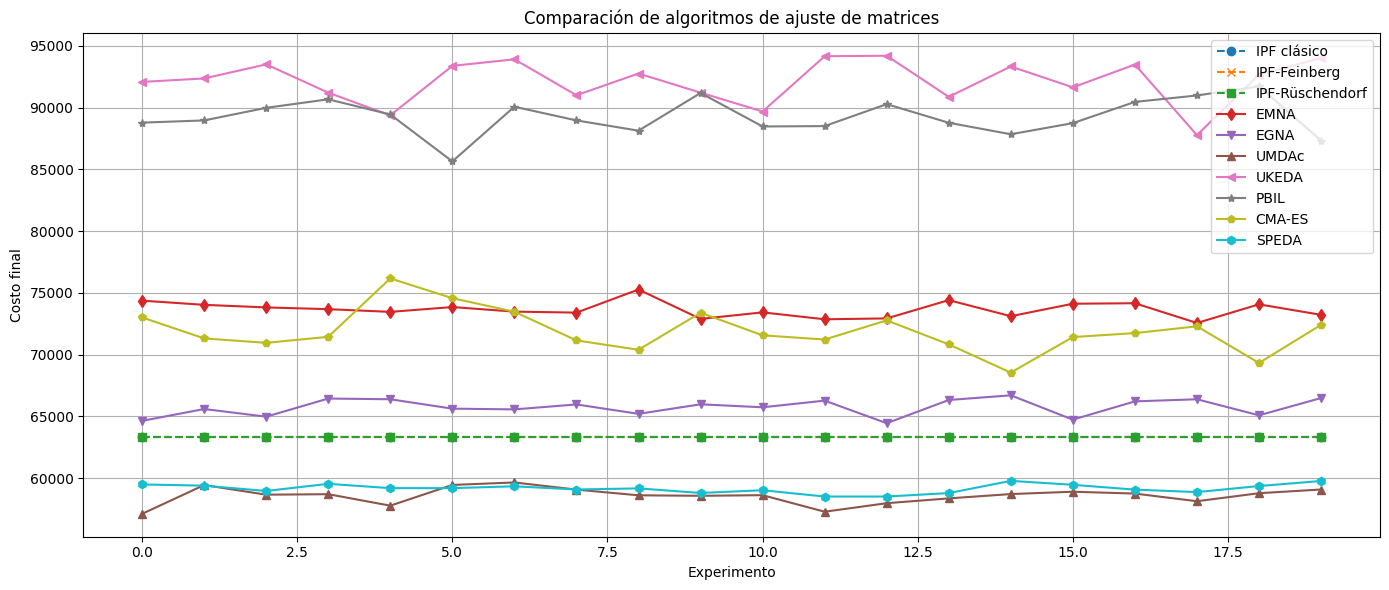

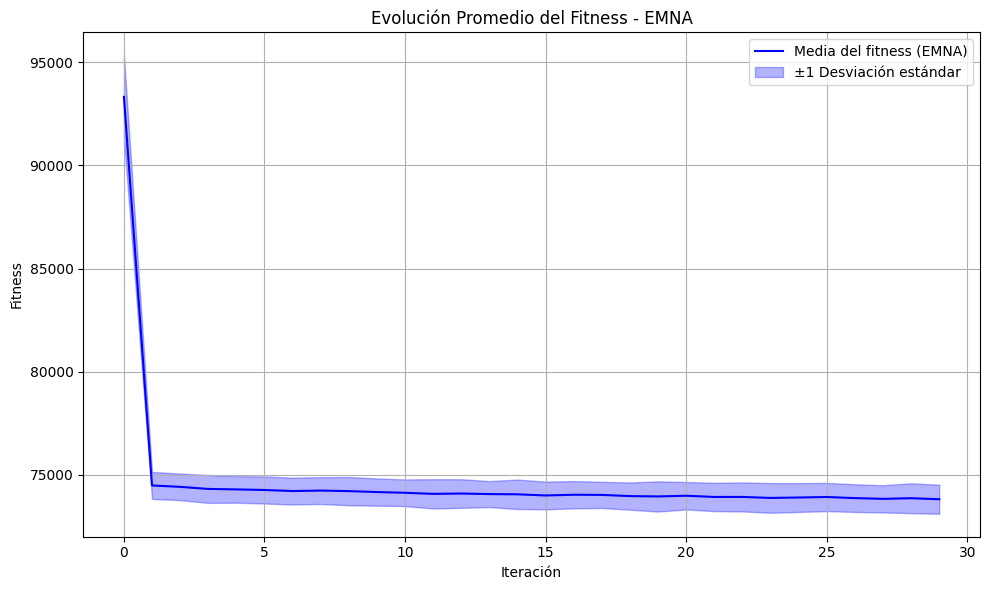

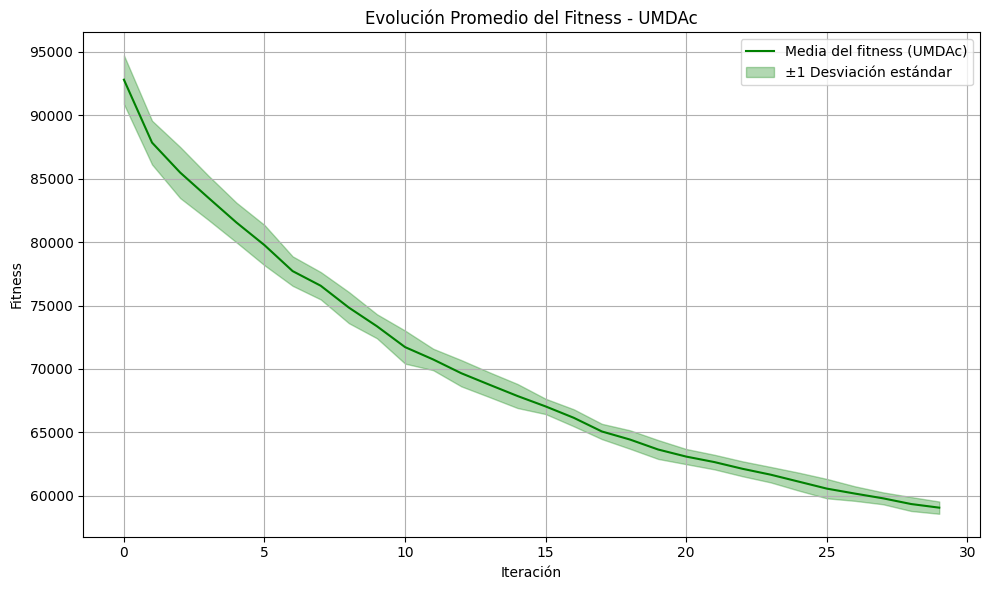

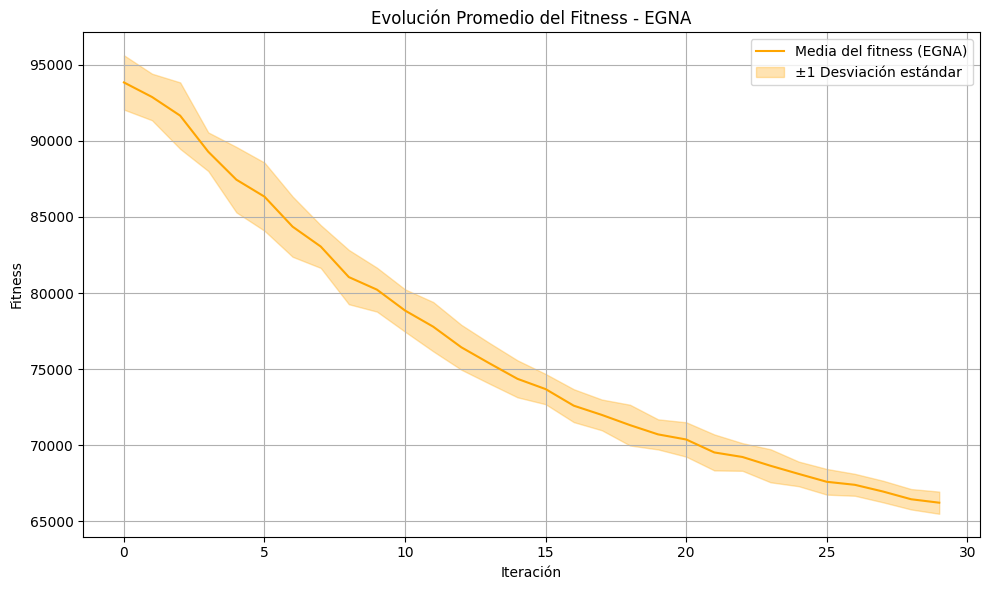

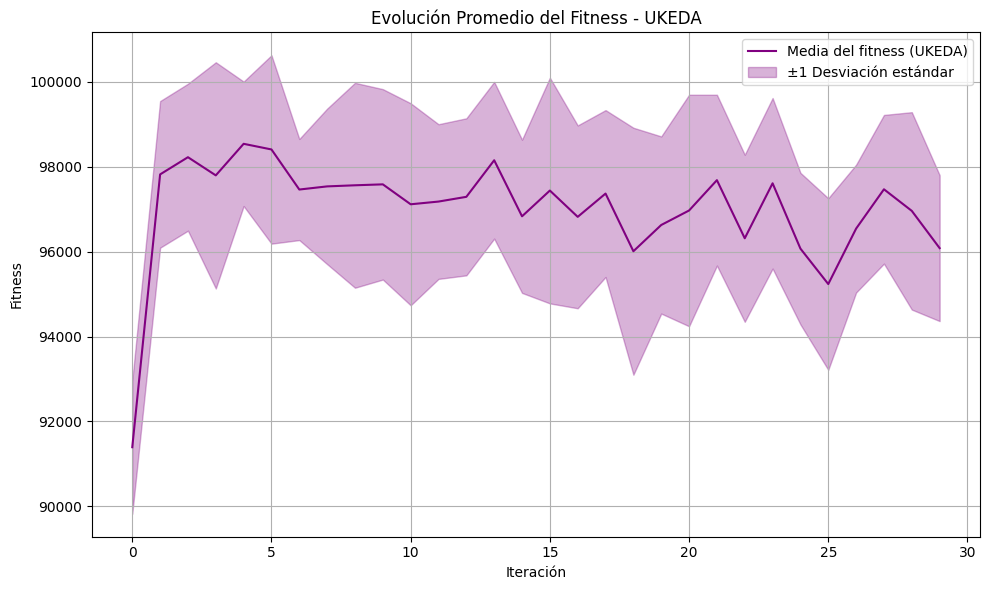

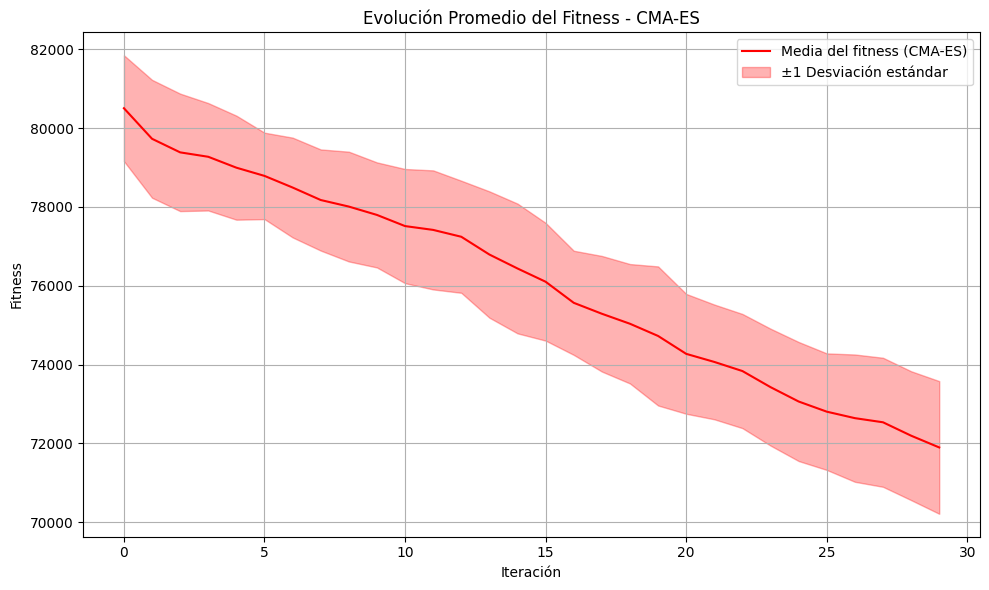

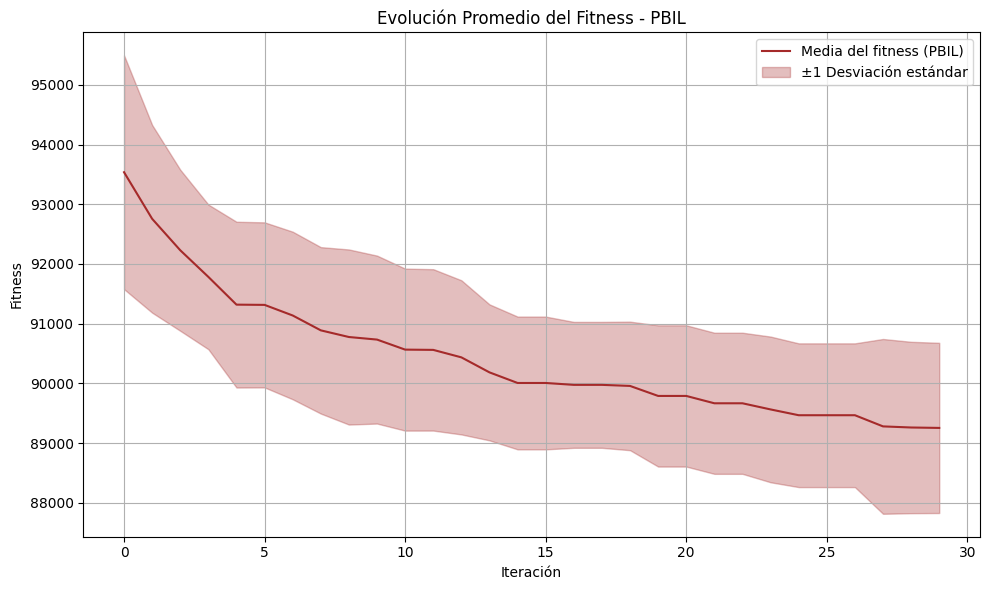

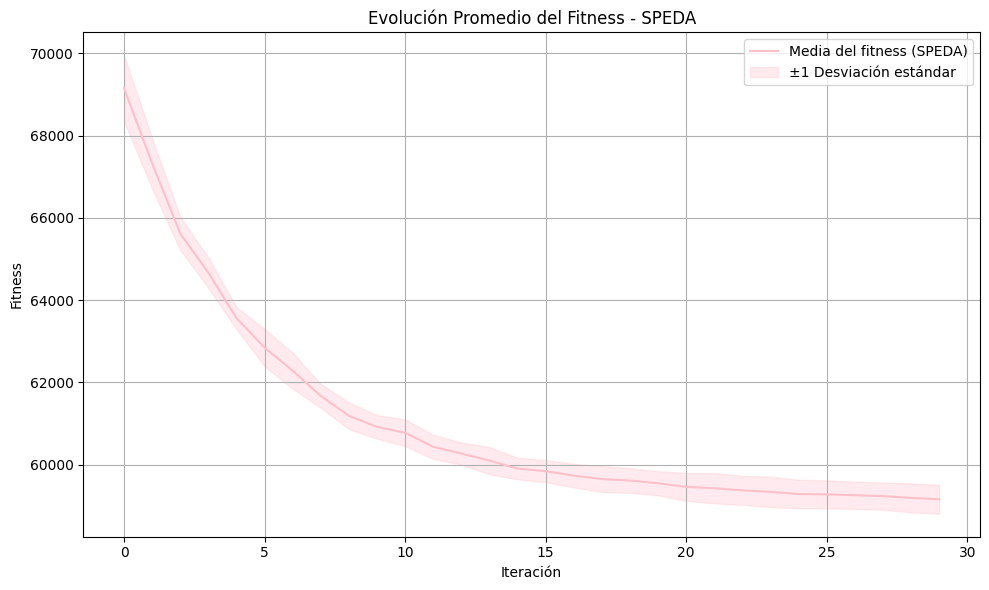

In [ ]:
from EDAspy.optimization import EMNA, UMDAc, EGNA, UnivariateKEDA
import numpy as np
import matplotlib.pyplot as plt
import warnings
import time, cma

warnings.filterwarnings("ignore", category=RuntimeWarning)

num_experiments = 20
rows, cols = 12, 12
iterations = 30

alpha, beta = 60, 10

dimensions = rows * cols

# Función para generar márgenes aleatorios
def generate_margins(rows, cols):
    total_sum = np.random.randint(10000, 20000)
    row_margins = np.random.randint(2000, 6000, size=rows)
    row_margins = np.round(row_margins / row_margins.sum() * total_sum).astype(int)

    col_margins = np.random.randint(2000, 6000, size=cols)
    col_margins = np.round(col_margins / col_margins.sum() * total_sum).astype(int)

    row_margins[-1] += total_sum - row_margins.sum()
    col_margins[-1] += total_sum - col_margins.sum()

    return row_margins, col_margins


def generate_initial_matrix(row_margins, col_margins):
    matrix = np.random.randint(20, 100, size=(len(row_margins), len(col_margins)))
    matrix = (matrix / matrix.sum()) * np.sum(row_margins)
    return np.round(matrix).astype(int)

def normalize_matrix(matrix, row_margins, col_margins, max_iter=100):
    matrix = np.maximum(matrix, 1.0)
    for _ in range(max_iter):
        row_sums = matrix.sum(axis=1, keepdims=True)
        matrix *= row_margins[:, None] / (row_sums + 1e-10)
        col_sums = matrix.sum(axis=0, keepdims=True)
        matrix *= col_margins / (col_sums + 1e-10)
    return np.round(matrix).astype(int)

def combined_penalty(matrix, row_margins, col_margins, initial_matrix, alpha=60, beta=10):
    row_diff = np.abs(np.sum(matrix, axis=1) - row_margins)
    col_diff = np.abs(np.sum(matrix, axis=0) - col_margins)
    margin_penalty = np.sum(row_diff**2) + np.sum(col_diff**2)
    similarity_penalty = np.sum(np.abs(matrix - initial_matrix))
    return alpha * margin_penalty + beta * similarity_penalty

def generate_non_negative_matrix(mean_matrix, std_matrix, max_retries=100):
    rows, cols = mean_matrix.shape
    matrix = np.random.normal(mean_matrix, std_matrix)

    for i in range(rows):
        for j in range(cols):
            retries = 0
            while matrix[i, j] < 0 and retries < max_retries:
                matrix[i, j] = np.random.normal(mean_matrix[i, j], std_matrix[i, j])
                retries += 1
            if matrix[i, j] < 0:
                matrix[i, j] = 0  # fallback
    return matrix

def local_search_with_noise(X, row_margins, col_margins, initial_matrix, alpha=60, beta=10, trials=50, std=0.01):
    best_X = X.copy()
    best_fitness = combined_penalty(
        normalize_matrix(X.reshape((rows, cols)), row_margins, col_margins),
        row_margins, col_margins, initial_matrix, alpha, beta
    )
    best_perturbed_X = X.copy()
    improved = False

    for _ in range(trials):
        noise = np.random.normal(loc=0, scale=std, size=X.shape)
        perturbed_X = X + X * noise
        matrix = perturbed_X.reshape((rows, cols))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix, alpha, beta)

        if fitness < best_fitness:
            best_fitness = fitness
            best_X = matrix.flatten()
            best_perturbed_X = perturbed_X.copy()
            improved = True

    if improved:
        print("\nMejor 'perturbed_X':")
        print(best_perturbed_X)
        print("\nFitness tras local search':")
        print(best_fitness)
    else:
        print("\nLocal search no mejoró el fitness.")

    return best_X.reshape((rows, cols)), best_fitness, best_perturbed_X.reshape((rows, cols)), improved


def fitness_function(matrix, row_margins, col_margins, initial_matrix):
    return combined_penalty(matrix, row_margins, col_margins, initial_matrix)


# IPF basado en Deming & Stephan
def iterative_proportional_fitting_deming(matrix, row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=50):
    start_time = time.time()
    matrix = matrix.astype(float)
    best_costs = []  # Lista para almacenar el "best cost" en cada iteración

    for it in range(max_iterations):
        matrix *= (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix *= (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Calcular el "best cost" después de cada iteración
        best_cost = fitness_function(matrix, row_margins, col_margins, initial_matrix)
        best_costs.append(best_cost)

        # Mostrar el costo en cada iteración
        print(f"IT: {it} \tBest cost: {int(best_cost)}")

        # Condición de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            break

    matrix = np.round(matrix).astype(int)
    execution_time = time.time() - start_time
    return matrix, execution_time, best_costs


# Log-verosimilitud
def log_likelihood(matrix, row_margins, col_margins):
    epsilon = 1e-10
    expected = np.outer(row_margins, col_margins) / np.sum(row_margins)
    return np.sum(matrix * np.log((matrix + epsilon) / expected))

# IPF - Feinberg
def iterative_proportional_fitting_feinberg(matrix, row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=50):
    start_time = time.time()
    matrix = matrix.astype(float)
    prev_ll = log_likelihood(matrix, row_margins, col_margins)
    best_costs = []

    for it in range(max_iterations):
        # Ajuste por filas
        matrix *= row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10)

        # Ajuste por columnas
        matrix *= col_margins[None, :] / (matrix.sum(axis=0, keepdims=True) + 1e-10)

        new_ll = log_likelihood(matrix, row_margins, col_margins)
        best_cost = fitness_function(matrix, row_margins, col_margins, initial_matrix)
        best_costs.append(best_cost)

        print(f"[Fienberg] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if abs(new_ll - prev_ll) < tol:
            print("Convergencia alcanzada.")
            break

        prev_ll = new_ll

    execution_time = time.time() - start_time
    return np.round(matrix).astype(int), execution_time, best_costs


# KL divergencia simétrica
def kl_symmetric_divergence(p, q):
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    return np.sum(p * np.log(p / q) + q * np.log(q / p))

# IPF - Rüschendorf con divergencia KL simétrica
def iterative_proportional_fitting_ruschendorf(matrix, row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=50):
    start_time = time.time()
    matrix = matrix.astype(float)
    prev_matrix = matrix.copy()
    best_costs = []

    for it in range(max_iterations):
        # Ajuste por filas
        matrix *= row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10)

        # Ajuste por columnas
        matrix *= col_margins[None, :] / (matrix.sum(axis=0, keepdims=True) + 1e-10)

        # Calcular coste
        best_cost = fitness_function(matrix, row_margins, col_margins, initial_matrix)
        best_costs.append(best_cost)

        print(f"[Rüschendorf] IT: {it + 1} \tBest cost: {int(best_cost)}")

        # Criterio de parada con divergencia KL simétrica
        if kl_symmetric_divergence(matrix, prev_matrix) < tol:
            print("Convergencia alcanzada.")
            break

        prev_matrix = matrix.copy()

    execution_time = time.time() - start_time
    return np.round(matrix).astype(int), execution_time, best_costs


def run_emna(row_margins, col_margins, dimensions, iterations, initial_matrix):
    emna = EMNA(size_gen=100, max_iter=iterations, dead_iter=10,
                n_variables=dimensions, lower_bound=1, upper_bound=max(row_margins.max(), col_margins.max()))

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()
    result = emna.minimize(fitness_function)
    end_time = time.time()

    best_matrix = result.best_ind.reshape((len(row_margins), len(col_margins)))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Local search after EMNA
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix)

    # If local search didn't improve, use the EMNA result
    if not improved:
        print("\nUsando la matriz de EMNA como la mejor solución.")
        best_matrix_refined = best_matrix

    execution_time = end_time - start_time
    return best_matrix_refined, np.array(result.history), refined_fitness, execution_time, best_perturbed_matrix


def run_umdac(row_margins, col_margins, dimensions, iterations, initial_matrix):
    umdac = UMDAc(size_gen=100, max_iter=iterations, dead_iter=10,
                  n_variables=dimensions, lower_bound=1, upper_bound=max(row_margins.max(), col_margins.max()))

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()
    result = umdac.minimize(fitness_function)
    end_time = time.time()

    best_matrix = result.best_ind.reshape((len(row_margins), len(col_margins)))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Local search after UMDAc
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix)

    # If local search didn't improve, use the EMNA result
    if not improved:
        print("\nUsando la matriz de UMDAc como la mejor solución.")
        best_matrix_refined = best_matrix

    execution_time = end_time - start_time
    return best_matrix_refined, np.array(result.history), refined_fitness, execution_time, best_perturbed_matrix


def run_egna(row_margins, col_margins, dimensions, iterations, initial_matrix):
    egna = EGNA(size_gen=100, max_iter=iterations, dead_iter=10,n_variables=dimensions,lower_bound=1,
                upper_bound=max(row_margins.max(), col_margins.max()))

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()
    result = egna.minimize(fitness_function)
    end_time = time.time()

    best_matrix = result.best_ind.reshape((len(row_margins), len(col_margins)))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Local search after EGNA
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix
    )

    # If local search didn't improve, use the EGNA result
    if not improved:
        print("\nUsando la matriz de EGNA como la mejor solución.")
        best_matrix_refined = best_matrix

    execution_time = end_time - start_time
    return best_matrix_refined, np.array(result.history), refined_fitness, execution_time, best_perturbed_matrix


def run_ukeda(row_margins, col_margins, dimensions, iterations, initial_matrix):
    ukeda = UnivariateKEDA(size_gen=350, max_iter=iterations, dead_iter=10,
                           n_variables=dimensions, lower_bound=1,
                           upper_bound=max(row_margins.max(), col_margins.max()))

    # Función de aptitud que usa penalización y normalización
    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()
    result = ukeda.minimize(fitness_function)
    end_time = time.time()

    best_matrix = result.best_ind.reshape((len(row_margins), len(col_margins)))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Aplicar búsqueda local posterior
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix
    )

    if not improved:
        print("\nUsando la matriz de UKEDA (sin mejora en búsqueda local).")
        best_matrix_refined = best_matrix
        refined_fitness = fitness_function(result.best_ind)
        best_perturbed_matrix = best_matrix

    execution_time = end_time - start_time
    return best_matrix_refined, np.array(result.history), refined_fitness, execution_time, best_perturbed_matrix


# Ejecutar CMA-ES
def run_cma(row_margins, col_margins, iterations, initial_matrix):
    rows, cols = len(row_margins), len(col_margins)
    x0 = initial_matrix.flatten()
    sigma = 50

    es = cma.CMAEvolutionStrategy(x0, sigma)
    history = []
    best_overall_cost = float('inf')

    def fitness_function(individual):
        matrix = individual.reshape((rows, cols))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    for i in range(iterations):
        solutions = es.ask()
        fitness_values = [fitness_function(sol) for sol in solutions]
        es.tell(solutions, fitness_values)

        best_cost = min(fitness_values)
        best_overall_cost = min(best_overall_cost, best_cost)

        history.append(best_overall_cost)
        print(f"Iteración {i+1}: Best Cost = {best_overall_cost}")

    best_vector = es.result.xbest
    best_matrix = best_vector.reshape((rows, cols))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Local search after CMAES
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        best_vector, row_margins, col_margins, initial_matrix, rows, cols
    )

    if not improved:
        print("\nUsando la matriz de CMA-ES como la mejor solución.")
        best_matrix_refined = best_matrix
        refined_fitness = best_overall_cost

    return best_matrix_refined, np.array(history), refined_fitness, best_perturbed_matrix


def run_pbil_continuous(row_margins, col_margins, dimensions, iterations, initial_matrix):
    size_gen = 100
    learning_rate = 0.01
    n_variables = dimensions

    lower_bound = np.ones(n_variables)
    upper_bound = np.full(n_variables, max(np.max(row_margins), np.max(col_margins)))

    prob_vector = np.random.uniform(0, 1, n_variables)

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    best_fitness = float('inf')
    best_solution = None
    fitness_history = []

    for iter in range(iterations):
        population = np.random.uniform(0, 1, (size_gen, n_variables))
        population = population * (upper_bound - lower_bound) + lower_bound

        fitness_values = np.array([fitness_function(ind) for ind in population])

        best_idx = np.argmin(fitness_values)
        best_individual = population[best_idx]

        if fitness_values[best_idx] < best_fitness:
            best_fitness = fitness_values[best_idx]
            best_solution = best_individual.copy()

        prob_vector = (1 - learning_rate) * prob_vector + learning_rate * best_individual

        fitness_history.append(best_fitness)
        print(f"IT: {iter} \tBest cost: {best_fitness}")

    # Resultado antes de búsqueda local
    best_matrix = best_solution.reshape((len(row_margins), len(col_margins)))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Local search after PBIL
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        best_solution, row_margins, col_margins, initial_matrix
    )

    if not improved:
        print("\nUsando la matriz de PBIL como la mejor solución.")
        best_matrix_refined = best_matrix
        refined_fitness = best_fitness

    return best_matrix_refined, np.array(fitness_history), refined_fitness, best_perturbed_matrix


# SPEDA (versión simplificada)
def run_speda(base_matrix, row_margins, col_margins, initial_matrix,
                          population_size=100, num_generations=20, elite_size=10, alpha=0.7, noise_level=None):
    rows, cols = base_matrix.shape

    # Nivel de ruido inicial si no se proporciona
    if noise_level is None:
        noise_level = np.mean(base_matrix) * 0.3

    # Inicializar población con ruido
    current_population = [
        generate_non_negative_matrix(base_matrix, np.full_like(base_matrix, noise_level))
        for _ in range(population_size)
    ]

    history = []
    best_fitness_ever = float('inf')
    best_matrix_ever = None
    best_perturbed_matrix = None

    for gen in range(num_generations):
        fitness_scores = []
        normalized_population = []

        for ind in current_population:
            rounded = np.round(ind).astype(int)
            normalized = normalize_matrix(rounded, row_margins, col_margins)
            fitness = combined_penalty(normalized, row_margins, col_margins, initial_matrix)
            fitness_scores.append(fitness)
            normalized_population.append(normalized)

        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)

        mean_elite = np.mean(elite_array, axis=0)
        std_elite = np.std(elite_array, axis=0)

        base_matrix = alpha * base_matrix + (1 - alpha) * mean_elite

        current_population = [
            generate_non_negative_matrix(base_matrix, std_elite)
            for _ in range(population_size)
        ]

        current_best_fitness = np.min(fitness_scores)
        current_best_index = np.argmin(fitness_scores)
        current_best_matrix = normalized_population[current_best_index]

        if current_best_fitness < best_fitness_ever:
            best_fitness_ever = current_best_fitness
            best_matrix_ever = current_best_matrix.copy()

        print(f"SPEDA Generación {gen+1}: Mejor fitness hasta ahora = {int(best_fitness_ever)}")
        history.append(best_fitness_ever)

    # Búsqueda local
    best_vector = best_matrix_ever.flatten()
    refined_matrix, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        best_vector, row_margins, col_margins, initial_matrix
    )

    if improved:
        print("\nSe mejoró la solución con búsqueda local.")
        return refined_matrix, np.array(history), refined_fitness, best_perturbed_matrix
    else:
        print("\nLa búsqueda local no mejoró la solución de SPEDA.")
        refined_fitness = best_fitness_ever
        best_perturbed_matrix = best_matrix_ever
        return best_matrix_ever, np.array(history), refined_fitness, best_perturbed_matrix


# Inicializar listas de resultados
best_costs_umda, best_costs_emna, best_costs_pbil, best_costs_cmaes, best_costs_egna, best_costs_ukeda = [], [], [], [], [], []
best_costs_ipf, best_costs_ipf_feinberg, best_costs_ipf_ruschendorf = [], [], []
best_costs_speda = []

times_umda, times_emna, times_pbil, times_cmaes, times_egna, times_ukeda, times_speda = [] ,[], [], [], [], [], []
times_ipf, times_ipf_feinberg, times_ipf_ruschendorf = [], [], []

all_histories_emna, all_histories_umdac, all_histories_egna = [], [], []
all_histories_ukeda, all_histories_cmaes, all_histories_pbil= [], [], []
all_histories_speda = []

final_fitness_values = []
all_times = []

# Márgenes aleatorios
row_margins, col_margins = generate_margins(rows, cols)

# Matriz inicial aleatoria
initial_matrix = generate_initial_matrix(row_margins, col_margins)

print("🔹 Matriz Inicial:")
print(initial_matrix)
print("\n🔹 Márgenes de Filas:", row_margins)
print("🔹 Márgenes de Columnas:", col_margins)

# Ejecutar todos los experimentos
for i in range(num_experiments):
    print(f"\n🧪 Experimento {i+1}/{num_experiments}:")

    # IPF clásico
    matrix_deming, time_deming, history_deming = iterative_proportional_fitting_deming(
        matrix=initial_matrix.copy(), row_margins=row_margins, col_margins=col_margins, initial_matrix=initial_matrix)

   # IPF Feinberg
    matrix_feinberg, time_feinberg, history_feinberg = iterative_proportional_fitting_feinberg(
        matrix=initial_matrix.copy(), row_margins=row_margins, col_margins=col_margins, initial_matrix=initial_matrix)

    # IPF Rüschendorf
    matrix_ruschendorf, time_ruschendorf, history_ruschendorf = iterative_proportional_fitting_ruschendorf(
        matrix=initial_matrix.copy(), row_margins=row_margins, col_margins=col_margins, initial_matrix=initial_matrix)

    # SPEDA
    start_time = time.time()
    optimized_matrix_speda, history_speda, refined_fitness_speda, best_perturbed_matrix = run_speda(
        base_matrix=np.copy(initial_matrix), row_margins=row_margins, col_margins=col_margins,
        initial_matrix=initial_matrix, population_size=100, num_generations=iterations, elite_size=10, alpha=0.7)
    all_histories_speda.append(history_speda)
    end_time = time.time()
    time_speda = end_time - start_time
    times_speda.append(time_speda)

    # uKEDA
    optimized_matrix_ukeda, history_ukeda, refined_fitness_ukeda, time_ukeda, best_perturbed_matrix = run_ukeda(
        row_margins, col_margins, dimensions, iterations, initial_matrix)
    all_histories_ukeda.append(history_ukeda)

    # EGNA
    optimized_matrix_egna, history_egna, refined_fitness_egna, time_egna, best_perturbed_matrix = run_egna(
        row_margins, col_margins, dimensions, iterations, initial_matrix)
    all_histories_egna.append(history_egna)

    # CMA-ES
    optimized_matrix_cmaes, history_cmaes, refined_fitness_cmaes, best_perturbed_matrix = run_cma(
        row_margins, col_margins, iterations, initial_matrix)
    all_histories_cmaes.append(history_cmaes)

    # PBIL
    optimized_matrix_pbil, history_pbil, refined_fitness_pbil, best_perturbed_matrix = run_pbil_continuous(
        row_margins, col_margins, dimensions, iterations, initial_matrix)
    all_histories_pbil.append(history_pbil)

    # UMDA
    optimized_matrix_umda, history_umda, refined_fitness_umda, time_umda, best_perturbed_matrix = run_umdac(
        row_margins, col_margins, dimensions, iterations, initial_matrix)
    all_histories_umdac.append(history_umda)

    # EMNA
    optimized_matrix_emna, history_emna, refined_fitness_emna, time_emna, best_perturbed_matrix = run_emna(
        row_margins, col_margins, dimensions, iterations, initial_matrix)
    all_histories_emna.append(history_emna)


    # Obtener costos
    best_costs_ukeda.append(combined_penalty(optimized_matrix_ukeda, row_margins, col_margins, initial_matrix))
    best_costs_umda.append(combined_penalty(optimized_matrix_umda, row_margins, col_margins, initial_matrix))
    best_costs_emna.append(combined_penalty(optimized_matrix_emna, row_margins, col_margins, initial_matrix))
    best_costs_egna.append(combined_penalty(optimized_matrix_egna, row_margins, col_margins, initial_matrix))
    best_costs_pbil.append(history_pbil[-1])
    best_costs_cmaes.append(history_cmaes[-1])
    best_costs_speda.append(history_speda[-1])
    best_costs_ipf.append(history_deming[-1])
    best_costs_ipf_feinberg.append(history_feinberg[-1])
    best_costs_ipf_ruschendorf.append(history_ruschendorf[-1])

    # Tiempos
    times_ukeda.append(time_ukeda)
    times_umda.append(time_umda)
    times_emna.append(time_emna)
    times_egna.append(time_egna)
    times_speda.append(time_speda)
    times_pbil.append(sum(history_pbil))
    times_cmaes.append(sum(history_cmaes))
    times_ipf.append(time_deming)
    times_ipf_feinberg.append(time_feinberg)
    times_ipf_ruschendorf.append(time_ruschendorf)

    # Mostrar resultado del experimento
    print(f"📌 UMDA: {best_costs_umda[-1]:.2f}, EMNA: {best_costs_emna[-1]:.2f}, PBIL: {best_costs_pbil[-1]:.2f}, CMA-ES: {best_costs_cmaes[-1]:.2f}")
    print(f"📌 IPF clásico: {best_costs_ipf[-1]:.2f}, Feinberg: {best_costs_ipf_feinberg[-1]:.2f}, Rüschendorf: {best_costs_ipf_ruschendorf[-1]:.2f}")
    print(f"📌 EGNA: {best_costs_egna[-1]:.2f}, UKEDA: {best_costs_ukeda[-1]:.2f}, SPEDA: {best_costs_speda[-1]:.2f}")

# Mostrar resumen final
print("\n📊 Promedios finales:")
def resumen(nombre, costos, tiempos):
    print(f"{nombre:<20} → Fitness: {np.mean(costos):.2f} ± {np.std(costos):.2f} | Tiempo: {np.mean(tiempos):.2f} s")

resumen("UKEDA", best_costs_ukeda, times_ukeda)
resumen("UMDA", best_costs_umda, times_umda)
resumen("EMNA", best_costs_emna, times_emna)
resumen("EGNA", best_costs_egna, times_egna)
resumen("PBIL", best_costs_pbil, times_pbil)
resumen("CMA-ES", best_costs_cmaes, times_cmaes)
resumen("SPEDA", best_costs_speda, times_speda)
resumen("IPF clásico", best_costs_ipf, times_ipf)
resumen("IPF Feinberg", best_costs_ipf_feinberg, times_ipf_feinberg)
resumen("IPF Rüschendorf", best_costs_ipf_ruschendorf, times_ipf_ruschendorf)

# Gráfica comparativa
plt.figure(figsize=(14, 6))
plt.plot(best_costs_ipf, label="IPF clásico", marker='o', linestyle='--')
plt.plot(best_costs_ipf_feinberg, label="IPF-Feinberg", marker='x', linestyle='--')
plt.plot(best_costs_ipf_ruschendorf, label="IPF-Rüschendorf", marker='s', linestyle='--')
plt.plot(best_costs_emna, label="EMNA", marker='d')
plt.plot(best_costs_egna, label="EGNA", marker='v')
plt.plot(best_costs_umda, label="UMDAc", marker='^')
plt.plot(best_costs_ukeda, label="UKEDA", marker='<')
plt.plot(best_costs_pbil, label="PBIL", marker='*')
plt.plot(best_costs_cmaes, label="CMA-ES", marker='p')
plt.plot(best_costs_speda, label="SPEDA", marker='h')
plt.xlabel("Experimento")
plt.ylabel("Costo final")
plt.title("Comparación de algoritmos de ajuste de matrices")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Mostrar evolución promedio del fitness para métodos NO IPF
all_histories = [all_histories_emna, all_histories_umdac, all_histories_egna, all_histories_ukeda,
                 all_histories_cmaes, all_histories_pbil, all_histories_speda]

labels = ["EMNA", "UMDAc", "EGNA", "UKEDA", "CMA-ES", "PBIL", "SPEDA"]

colors = ['blue', 'green', 'orange', 'purple', 'red', 'brown', 'pink']

for history_list, label, color in zip(all_histories, labels, colors):
    max_len = max(len(h) for h in history_list)
    # Padding con NaN para igualar longitudes (si algunas carreras son más cortas)
    history_array = np.array([
    np.pad(np.array(h, dtype=float), (0, max_len - len(h)), constant_values=np.nan)
    for h in history_list
    ])

    mean_fitness = np.nanmean(history_array, axis=0)
    std_fitness = np.nanstd(history_array, axis=0)

    plt.figure(figsize=(10, 6))
    plt.plot(mean_fitness, label=f'Media del fitness ({label})', color=color)
    plt.fill_between(range(max_len),
                     mean_fitness - std_fitness,
                     mean_fitness + std_fitness,
                     color=color, alpha=0.3, label='±1 Desviación estándar')
    plt.title(f'Evolución Promedio del Fitness - {label}')
    plt.xlabel('Iteración')
    plt.ylabel('Fitness')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



<ipython-input-9-c73b266b3c74>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x="Algoritmo", y="Costo final", palette="Set3")
<ipython-input-9-c73b266b3c74>:28: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


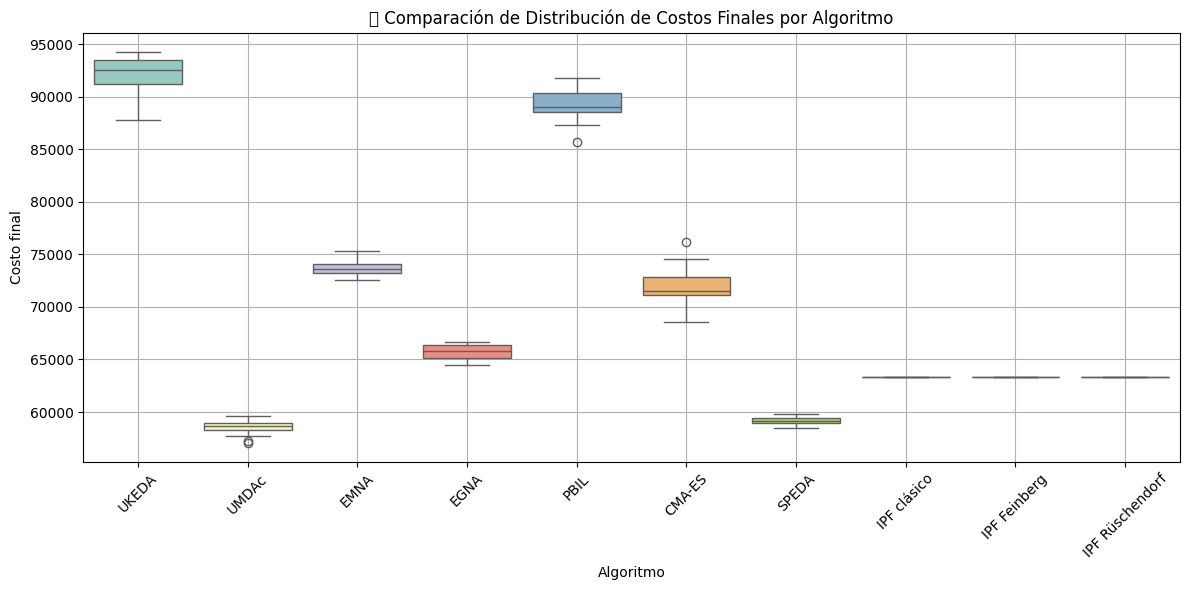

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Crear un DataFrame con todos los costos finales
data = {
    "UKEDA": best_costs_ukeda,
    "UMDAc": best_costs_umda,
    "EMNA": best_costs_emna,
    "EGNA": best_costs_egna,
    "PBIL": best_costs_pbil,
    "CMA-ES": best_costs_cmaes,
    "SPEDA": best_costs_speda,
    "IPF clásico": best_costs_ipf,
    "IPF Feinberg": best_costs_ipf_feinberg,
    "IPF Rüschendorf": best_costs_ipf_ruschendorf
}

df = pd.DataFrame(data)
df_melted = df.melt(var_name="Algoritmo", value_name="Costo final")

# Crear el boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x="Algoritmo", y="Costo final", palette="Set3")
plt.title("📦 Comparación de Distribución de Costos Finales por Algoritmo")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# PRUEBAS IPF vs EDAS 3 DIM

Se han truncado las últimas 5000 líneas del flujo de salida.
  2.55003263e+03  1.07346626e+03  2.39886460e+03  4.70514149e+03
  3.48481026e+03  4.82525363e+03  2.41537399e+03 -3.48908988e+02
  2.16740068e+03  7.83130064e+02  2.37121432e+03  2.16329814e+03
  8.95301209e+02 -7.74271178e+02  3.59654161e+03  1.77550362e+01
 -1.63766515e+02  1.57691391e+03  4.01582814e+03  4.28332517e+03
  2.67107771e+03  2.70556039e+03  1.13959760e+03  1.06312618e+03
  2.21387274e+03 -4.94232321e+02  2.98304840e+03  4.31591930e+02
  1.69507280e+03 -5.33962147e+01  7.96276818e+02  1.63103144e+03
  1.27435348e+03  1.80480823e+03  2.07770537e+03  1.84492350e+03
  3.99807283e+03  2.41464613e+03  4.14506878e+03  3.54362431e+03
  2.12461631e+03  2.48304102e+03  2.05337503e+03  9.09387925e+02
  2.37455414e+03  2.12588780e+03  4.64522808e+03  3.32643572e+03
  2.75358267e+03 -2.70986664e+02  2.31810871e+03  1.66686825e+03
  4.88084296e+03  1.27000902e+03  1.45602083e+03 -8.14222639e+01
  2.24230895e+03  7.72763901e

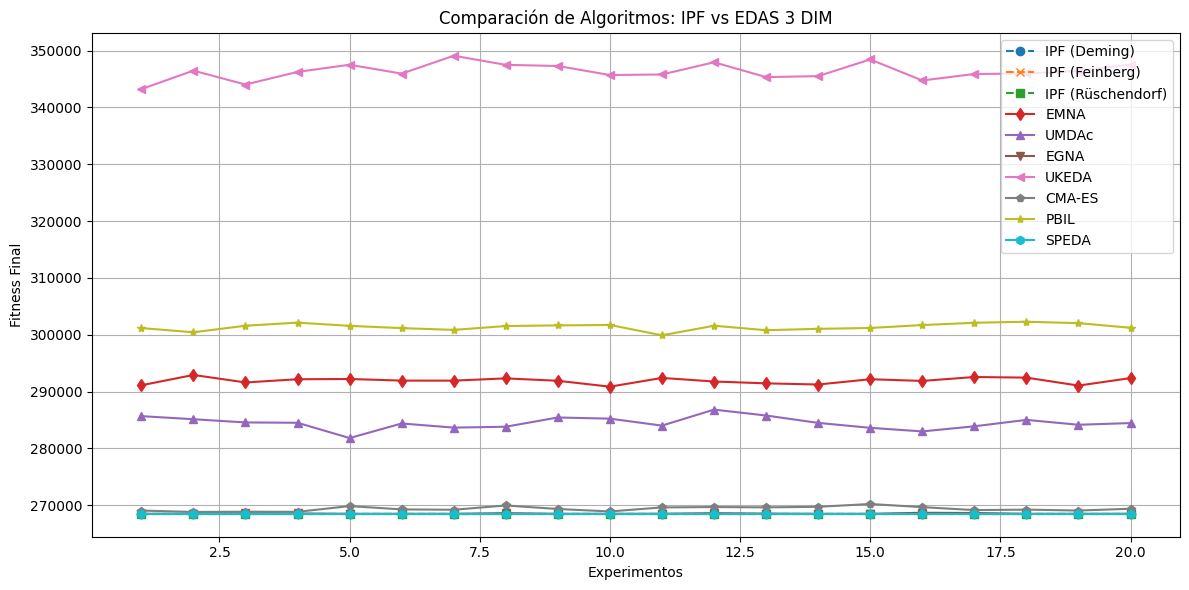


🔹 Resultados Finales por Experimento:
    Experimento  IPF (Deming)  IPF (Feinberg)  IPF (Rüschendorf)         EMNA  \
0             1      268490.0        268490.0           268490.0  291106.2575   
1             2      268490.0        268490.0           268490.0  292922.8946   
2             3      268490.0        268490.0           268490.0  291603.9256   
3             4      268490.0        268490.0           268490.0  292169.4470   
4             5      268490.0        268490.0           268490.0  292211.6856   
5             6      268490.0        268490.0           268490.0  291929.8066   
6             7      268490.0        268490.0           268490.0  291920.4900   
7             8      268490.0        268490.0           268490.0  292320.9049   
8             9      268490.0        268490.0           268490.0  291896.7619   
9            10      268490.0        268490.0           268490.0  290862.0634   
10           11      268490.0        268490.0           268490.0  2923

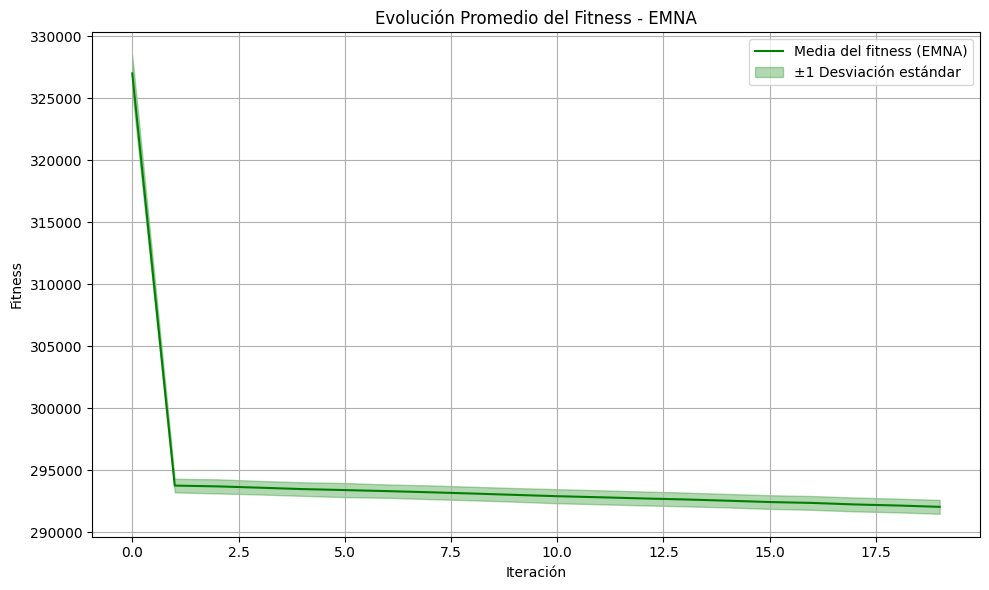

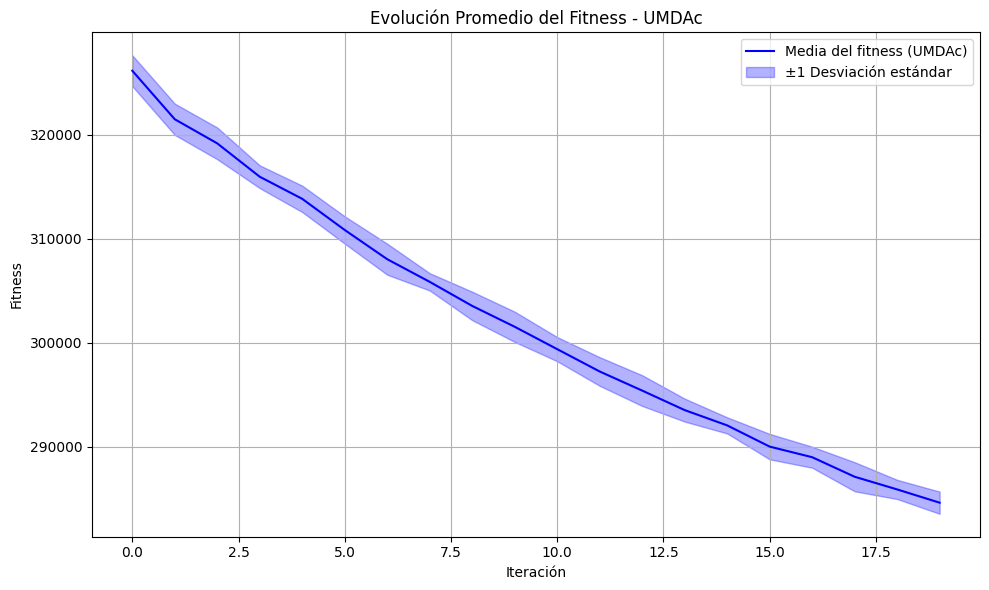

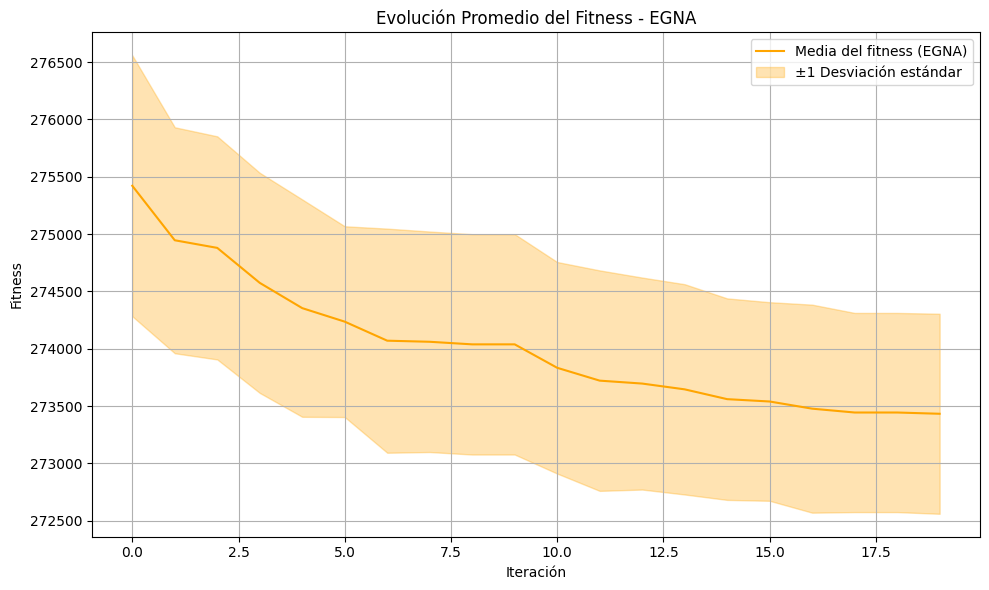

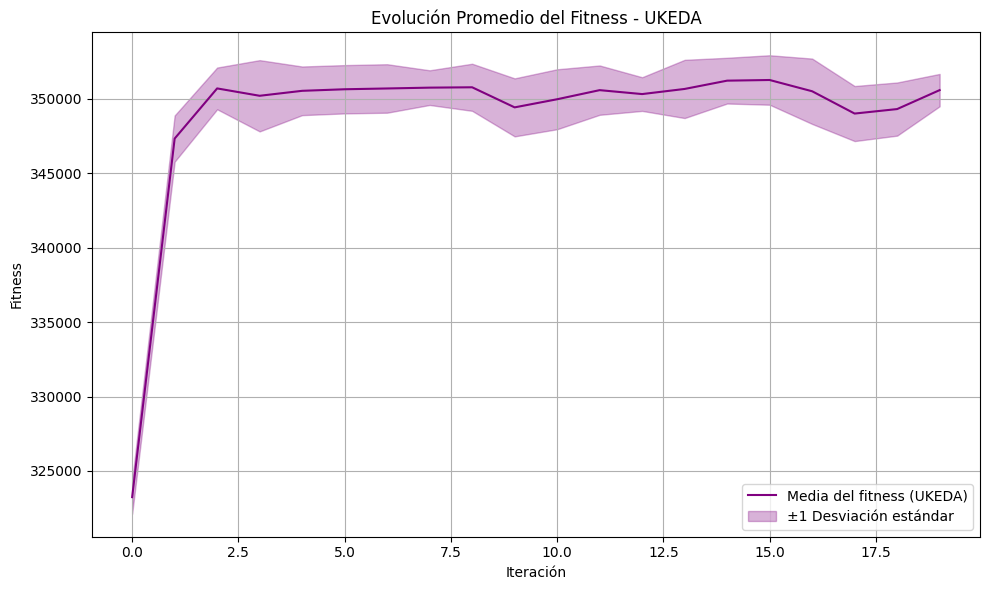

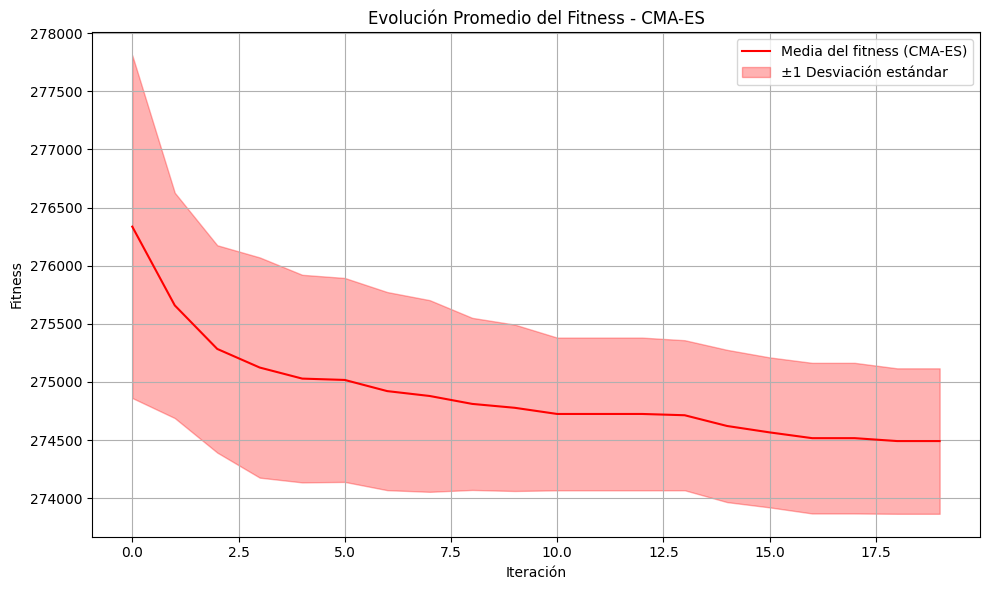

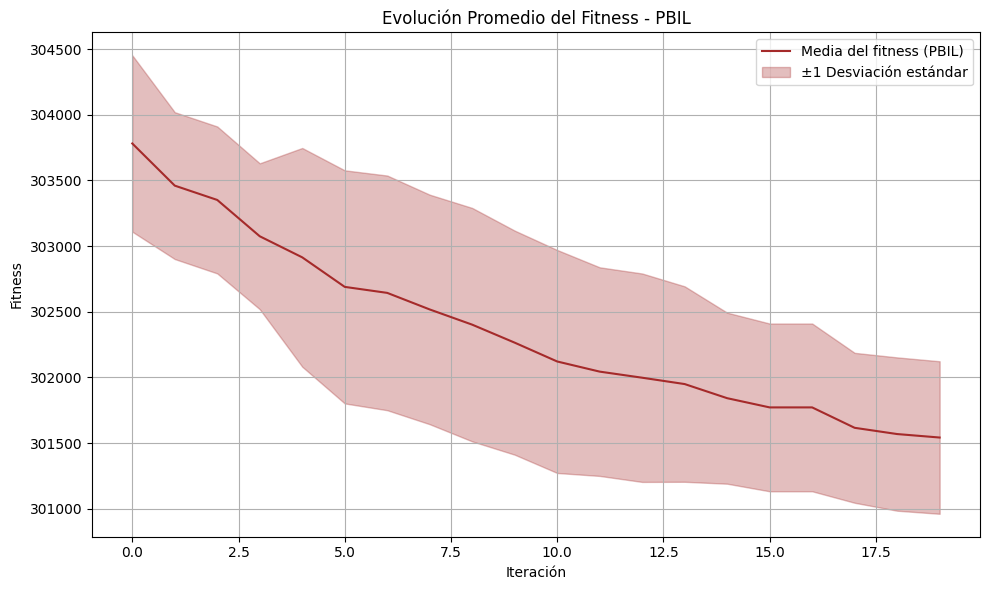

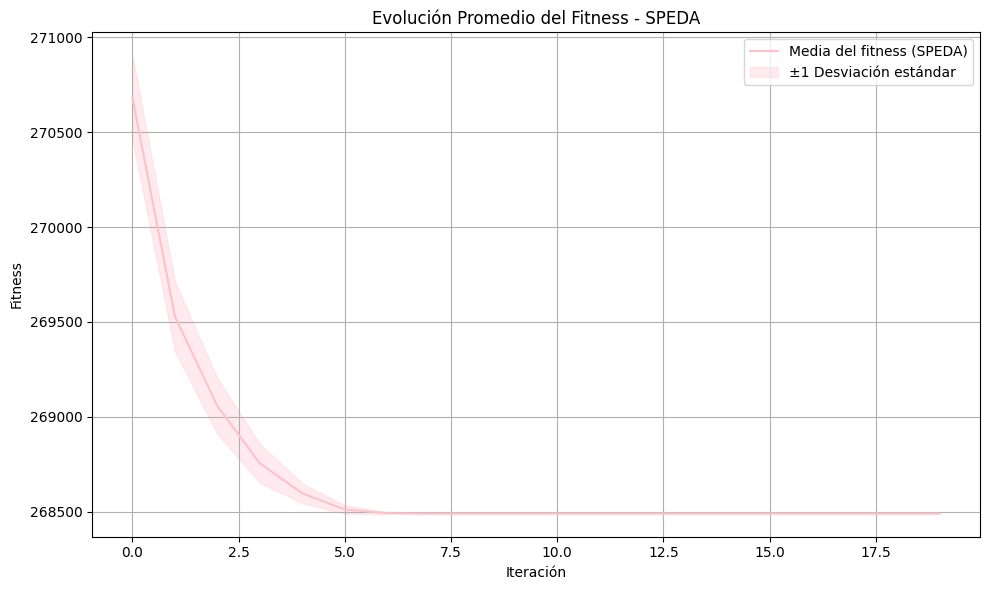

In [ ]:
import numpy as np
import matplotlib.pyplot as pltho
import matplotlib.pyplot as plt
import time, cma
import pandas as pd
from EDAspy.optimization import EMNA, UMDAc, EGNA, UnivariateKEDA

# Parámetros generales
dimensions = (10, 10, 10)  # Dimensiones del tensor (3D)
num_experiments = 20  # Número de experimentos

alpha, beta = 60, 10

# Funciones auxiliares
def generate_initial_tensor(rows, cols, depth):
    return np.random.randint(20, 100, size=(rows, cols, depth))

# Función para generar márgenes aleatorios
def generate_tensor_margins(dimensions, total_sum=np.random.randint(30000, 60000)):
    row_margins = np.random.randint(10000, 13000, size=dimensions[0])
    row_margins = np.round(row_margins / row_margins.sum() * total_sum).astype(int)

    col_margins = np.random.randint(10000, 13000, size=dimensions[1])
    col_margins = np.round(col_margins / col_margins.sum() * total_sum).astype(int)

    depth_margins = np.random.randint(10000, 13000, size=dimensions[2])
    depth_margins = np.round(depth_margins / depth_margins.sum() * total_sum).astype(int)

    row_margins[-1] += total_sum - row_margins.sum()
    col_margins[-1] += total_sum - col_margins.sum()
    depth_margins[-1] += total_sum - depth_margins.sum()

    return row_margins, col_margins, depth_margins


def normalize_tensor(tensor, margin0, margin1, margin2, max_iters=10, tol=1e-6):
    tensor = tensor.copy().astype(float)
    for _ in range(max_iters):
        prev_tensor = tensor.copy()

        tensor *= (margin0[:, None, None] / (tensor.sum(axis=(1, 2), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None] / (tensor.sum(axis=(0, 2), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :] / (tensor.sum(axis=(0, 1), keepdims=True) + 1e-10))

        if np.linalg.norm(tensor - prev_tensor) < tol:
            break

    return tensor

def generate_non_negative_tensor(mean_tensor, std_tensor, max_retries=20):
    depth, rows, cols = mean_tensor.shape
    tensor = np.random.normal(mean_tensor, std_tensor)

    for d in range(depth):
        for r in range(rows):
            for c in range(cols):
                retries = 0
                while tensor[d, r, c] < 0 and retries < max_retries:
                    tensor[d, r, c] = np.random.normal(mean_tensor[d, r, c], std_tensor[d, r, c])
                    retries += 1
                if tensor[d, r, c] < 0:
                    tensor[d, r, c] = 0  # If after retries it is still negative, set to 0
    return tensor


def combined_penalty(tensor, row_margins, col_margins, depth_margins, initial_tensor, alpha=60, beta=10):
    row_diff = np.abs(tensor.sum(axis=(1, 2)) - row_margins)
    col_diff = np.abs(tensor.sum(axis=(0, 2)) - col_margins)
    depth_diff = np.abs(tensor.sum(axis=(0, 1)) - depth_margins)
    margin_penalty = np.sum(row_diff**2) + np.sum(col_diff**2) + np.sum(depth_diff**2)

    similarity_penalty = np.sum(np.abs(tensor - initial_tensor))

    return alpha * margin_penalty + beta * similarity_penalty

def fitness_function(tensor, row_margins, col_margins, depth_margins, initial_tensor):
    return combined_penalty(tensor, row_margins, col_margins, depth_margins, initial_tensor)

def ipf_deming_3d(tensor, row_margins, col_margins, depth_margins, initial_tensor,
                                    tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    best_costs = []  # Almacena el mejor costo en cada iteración

    for it in range(max_iterations):
        # --- Ajuste para las filas (dimensión 0) ---
        row_sums = tensor.sum(axis=(1, 2))  # Suma sobre columnas y profundidad
        row_sums[row_sums == 0] = 1e-10  # Evitar división por cero
        tensor *= (row_margins[:, None, None] / row_sums[:, None, None])

        # --- Ajuste para las columnas (dimensión 1) ---
        col_sums = tensor.sum(axis=(0, 2))  # Suma sobre filas y profundidad
        col_sums[col_sums == 0] = 1e-10
        tensor *= (col_margins[None, :, None] / col_sums[None, :, None])

        # --- Ajuste para la profundidad (dimensión 2) ---
        depth_sums = tensor.sum(axis=(0, 1))  # Suma sobre filas y columnas
        depth_sums[depth_sums == 0] = 1e-10
        tensor *= (depth_margins[None, None, :] / depth_sums[None, None, :])

        # Calcular el costo (fitness) después del ajuste
        current_cost = fitness_function(tensor, row_margins, col_margins, depth_margins, initial_tensor)
        best_costs.append(current_cost)

        print(f"IT: {it + 1} \tBest cost: {int(current_cost)}")

        # Criterio de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    # Redondear a enteros al final
    tensor = np.round(tensor).astype(int)
    execution_time = time.time() - start_time
    return tensor, execution_time, best_costs

# Log-verosimilitud en 3D
def log_likelihood_3d(tensor, row_margins, col_margins, depth_margins):
    epsilon = 1e-10
    total = row_margins.sum()
    expected = np.einsum('i,j,k->ijk', row_margins, col_margins, depth_margins) / (total**2)
    return np.sum(tensor * np.log((tensor + epsilon) / expected))

# IPF - Feinberg en 3D
def ipf_fienberg_3d(tensor, row_margins, col_margins, depth_margins, initial_tensor, tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    prev_ll = log_likelihood_3d(tensor, row_margins, col_margins, depth_margins)
    best_costs = []

    for it in range(max_iterations):
        # Ajuste por filas (dim 0)
        row_sums = tensor.sum(axis=(1, 2))
        tensor *= row_margins[:, None, None] / (row_sums[:, None, None] + 1e-10)

        # Ajuste por columnas (dim 1)
        col_sums = tensor.sum(axis=(0, 2))
        tensor *= col_margins[None, :, None] / (col_sums[None, :, None] + 1e-10)

        # Ajuste por profundidad (dim 2)
        depth_sums = tensor.sum(axis=(0, 1))
        tensor *= depth_margins[None, None, :] / (depth_sums[None, None, :] + 1e-10)

        # Evaluación
        new_ll = log_likelihood_3d(tensor, row_margins, col_margins, depth_margins)
        best_cost = fitness_function(tensor, row_margins, col_margins, depth_margins, initial_tensor)
        best_costs.append(best_cost)

        print(f"[Feinberg 3D] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if abs(new_ll - prev_ll) < tol:
            print("Convergencia alcanzada.")
            break

        prev_ll = new_ll

    execution_time = time.time() - start_time
    return np.round(tensor).astype(int), execution_time, best_costs

# KL divergencia simétrica para tensores 3D
def kl_symmetric_divergence_3d(p, q):
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    return np.sum(p * np.log(p / q) + q * np.log(q / p))

# IPF - Rüschendorf en 3D
def ipf_ruschendorf_3d(tensor, row_margins, col_margins, depth_margins, initial_tensor, tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    prev_tensor = tensor.copy()
    best_costs = []

    for it in range(max_iterations):
        # Ajuste por filas (dim 0)
        row_sums = tensor.sum(axis=(1, 2))
        tensor *= row_margins[:, None, None] / (row_sums[:, None, None] + 1e-10)

        # Ajuste por columnas (dim 1)
        col_sums = tensor.sum(axis=(0, 2))
        tensor *= col_margins[None, :, None] / (col_sums[None, :, None] + 1e-10)

        # Ajuste por profundidad (dim 2)
        depth_sums = tensor.sum(axis=(0, 1))
        tensor *= depth_margins[None, None, :] / (depth_sums[None, None, :] + 1e-10)

        # Coste (fitness)
        best_cost = fitness_function(tensor, row_margins, col_margins, depth_margins, initial_tensor)
        best_costs.append(best_cost)
        print(f"[Rüschendorf 3D] IT: {it + 1} \tBest cost: {int(best_cost)}")

        # Criterio de parada: divergencia KL simétrica
        if kl_symmetric_divergence_3d(tensor, prev_tensor) < tol:
            print("Convergencia alcanzada.")
            break

        prev_tensor = tensor.copy()

    execution_time = time.time() - start_time
    return np.round(tensor).astype(int), execution_time, best_costs


# Función de búsqueda local con ruido
def local_search_with_noise_tensor(X, margins, initial_tensor, shape, normalize_tensor,
                                   alpha=60, beta=10, trials=30, std=0.01):

    best_X = X.copy()
    best_tensor = normalize_tensor(X.reshape(shape), *margins)
    best_fitness = combined_penalty(best_tensor, margins, initial_tensor, alpha, beta)
    best_perturbed_X = X.copy()
    improved = False

    for _ in range(trials):
        noise = np.random.normal(0, std, size=X.shape)
        perturbed_X = X + X * noise
        tensor = normalize_tensor(perturbed_X.reshape(shape), *margins)
        fitness = combined_penalty(tensor, *margins, initial_tensor, alpha, beta)

        if fitness < best_fitness:
            best_fitness = fitness
            best_X = tensor.flatten()
            best_perturbed_X = perturbed_X.copy()
            improved = True

    if improved:
        print("\n Mejor 'perturbed_X':")
        print(best_perturbed_X.reshape(shape))
        print(" Fitness tras local search:", best_fitness)
    else:
        print("\n Local search no mejoró el fitness.")

    return best_X.reshape(shape), best_fitness, best_perturbed_X.reshape(shape), improved


# EMNA (Estimación de distribución multivariada normal)
def run_emna_tensor(margins, shape, iterations, initial_tensor,
                    alpha=60, beta=10, trials=30, std=0.01):

    n_variables = np.prod(shape)
    upper_bound = max([m.max() for m in margins])

    emna = EMNA(size_gen=100, max_iter=iterations, dead_iter=10,
                n_variables=n_variables, lower_bound=1, upper_bound=upper_bound)

    def fitness_function(individual):
        tensor = individual.reshape(shape)
        tensor = normalize_tensor(tensor, *margins)
        return combined_penalty(tensor, *margins, initial_tensor)

    start_time = time.time()
    result = emna.minimize(fitness_function)
    end_time = time.time()

    best_tensor = result.best_ind.reshape(shape)
    best_tensor = normalize_tensor(best_tensor, *margins)
    base_X = best_tensor.flatten()

    execution_time = end_time - start_time
    original_fitness = combined_penalty(best_tensor, *margins, initial_tensor)

    print("\nEjecutando búsqueda local con ruido sobre la solución de EMNA...")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        base_X, margins, initial_tensor, shape, normalize_tensor,
        alpha=alpha, beta=beta, trials=trials, std=std
    )

    if improved:
        print("Búsqueda local mejoró la solución de EMNA.")
        return refined_tensor, np.array(result.history), refined_fitness, execution_time
    else:
        print("La búsqueda local no mejoró la solución de EMNA.")
        return best_tensor, np.array(result.history), original_fitness, execution_time


# UMDAc (Estimación de distribución con variables categóricas)
def run_umdac_tensor(margins, shape, iterations, initial_tensor,
                     alpha=60, beta=10, trials=30, std=0.01):

    n_variables = np.prod(shape)
    upper_bound = max([m.max() for m in margins])

    umdac = UMDAc(size_gen=100, max_iter=iterations, dead_iter=10,
                  n_variables=n_variables, lower_bound=1, upper_bound=upper_bound)

    def fitness_function(individual):
        tensor = individual.reshape(shape)
        tensor = normalize_tensor(tensor, *margins)
        return combined_penalty(tensor, *margins, initial_tensor)

    start_time = time.time()
    result = umdac.minimize(fitness_function)
    end_time = time.time()

    best_tensor = result.best_ind.reshape(shape)
    best_tensor = normalize_tensor(best_tensor, *margins)
    base_X = best_tensor.flatten()

    execution_time = end_time - start_time
    original_fitness = combined_penalty(best_tensor, *margins, initial_tensor)

    print("\nEjecutando búsqueda local con ruido sobre la solución de UMDAc...")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        base_X, margins, initial_tensor, shape, normalize_tensor,
        alpha=alpha, beta=beta, trials=trials, std=std
    )

    if improved:
        print("Búsqueda local mejoró la solución de UMDAc.")
        return refined_tensor, np.array(result.history), refined_fitness, execution_time
    else:
        print("La búsqueda local no mejoró la solución de UMDAc.")
        return best_tensor, np.array(result.history), original_fitness, execution_time


# UnivariateKEDA (Estimación de distribución univariada)
def run_ukeda_tensor(margins, shape, iterations, initial_tensor,
                     alpha=60, beta=10, trials=30, std=0.01):

    n_variables = np.prod(shape)
    upper_bound = max([m.max() for m in margins])

    ukeda = UnivariateKEDA(size_gen=3000, max_iter=iterations, dead_iter=10,
                           n_variables=n_variables, lower_bound=1, upper_bound=upper_bound)

    def fitness_function(individual):
        tensor = individual.reshape(shape)
        tensor = normalize_tensor(tensor, *margins)
        return combined_penalty(tensor, *margins, initial_tensor)

    start_time = time.time()
    result = ukeda.minimize(fitness_function)
    end_time = time.time()

    best_tensor = result.best_ind.reshape(shape)
    best_tensor = normalize_tensor(best_tensor, *margins)
    base_X = best_tensor.flatten()

    execution_time = end_time - start_time
    original_fitness = combined_penalty(best_tensor, *margins, initial_tensor)

    print("\nEjecutando búsqueda local con ruido sobre la solución de UKEDA...")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        base_X, margins, initial_tensor, shape, normalize_tensor,
        alpha=alpha, beta=beta, trials=trials, std=std
    )

    if improved:
        print("Búsqueda local mejoró la solución de UKEDA.")
        return refined_tensor, np.array(result.history), refined_fitness, execution_time
    else:
        print("La búsqueda local no mejoró la solución de UKEDA.")
        return best_tensor, np.array(result.history), original_fitness, execution_time


#EGNA
def run_egna_tensor(base_tensor, row_margins, col_margins, depth_margins, initial_tensor,
                    population_size=50, num_generations=20, elite_size=10, noise_level=5, lambda_=0.7,
                    alpha=60, beta=10, trials=30, std=0.01):

    base_tensor = normalize_tensor(np.array(base_tensor), row_margins, col_margins, depth_margins)
    shape = base_tensor.shape
    margins = (row_margins, col_margins, depth_margins)

    current_population = [
        normalize_tensor(
            generate_non_negative_tensor(base_tensor, np.full_like(base_tensor, noise_level)),
            *margins
        )
        for _ in range(population_size)
    ]

    history = []
    global_best_fitness = float('inf')
    global_best_tensor = None

    for gen in range(num_generations):
        fitness_scores = [
            fitness_function(np.round(ind).astype(int), *margins, initial_tensor)
            for ind in current_population
        ]

        best_idx = np.argmin(fitness_scores)
        current_best_fitness = fitness_scores[best_idx]
        current_best_tensor = current_population[best_idx]

        if current_best_fitness < global_best_fitness:
            global_best_fitness = current_best_fitness
            global_best_tensor = current_best_tensor

        history.append(global_best_fitness)
        print(f"EGNA 3D - Generación {gen+1}: Best fitness = {global_best_fitness:.6f}")

        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)

        mean_elite = np.mean(elite_array, axis=0)
        std_elite = np.std(elite_array, axis=0)

        mean_elite = normalize_tensor(mean_elite, *margins)
        std_elite = np.clip(std_elite, 1e-6, None)

        base_tensor = lambda_ * base_tensor + (1 - lambda_) * mean_elite

        current_population = [
            normalize_tensor(
                generate_non_negative_tensor(base_tensor, std_elite),
                *margins
            )
            for _ in range(population_size)
        ]

    print("\nEjecutando búsqueda local con ruido sobre el tensor de EGNA...")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        global_best_tensor.flatten(), margins, initial_tensor, shape,
        normalize_tensor, alpha=alpha, beta=beta, trials=trials, std=std
    )

    if improved:
        print("Búsqueda local mejoró la solución de EGNA.")
        return refined_tensor, history, refined_fitness
    else:
        print("La búsqueda local no mejoró la solución de EGNA.")
        return global_best_tensor, history, global_best_fitness


# PBIL continuo
def run_pbil_continuous_tensor(margins, tensor_shape, initial_tensor, iterations=20,
                                size_gen=100, learning_rate=0.01, alpha=60, beta=10, trials=30, std=0.01):
    n_variables = np.prod(tensor_shape)

    lower_bound = np.ones(n_variables)
    upper_bound = np.full(n_variables, max(m.max() for m in margins))

    # Vector de probabilidad inicial
    prob_vector = (lower_bound + upper_bound) / 2.0
    std_dev = (upper_bound - lower_bound) / 6  # Para mantener la mayoría dentro de límites

    best_fitness = float('inf')
    best_solution = None
    fitness_history = []

    def fitness_function(individual):
        tensor = individual.reshape(tensor_shape)
        tensor = normalize_tensor(tensor, *margins)
        return combined_penalty(tensor, *margins, initial_tensor, alpha, beta)

    for iter in range(iterations):
        # Generar población
        population = np.random.normal(loc=prob_vector, scale=std_dev, size=(size_gen, n_variables))
        population = np.clip(population, lower_bound, upper_bound)

        fitness_values = np.array([fitness_function(ind) for ind in population])
        best_idx = np.argmin(fitness_values)
        best_individual = population[best_idx]

        if fitness_values[best_idx] < best_fitness:
            best_fitness = fitness_values[best_idx]
            best_solution = best_individual.copy()

        # Actualizar vector de probabilidad
        prob_vector = (1 - learning_rate) * prob_vector + learning_rate * best_individual
        fitness_history.append(best_fitness)

        print(f"PBIL IT {iter+1} - Best cost: {best_fitness:.4f}")

    # Mejor tensor encontrado
    best_tensor = best_solution.reshape(tensor_shape)
    best_tensor = normalize_tensor(best_tensor, *margins)

    # Búsqueda local
    print("\nEjecutando búsqueda local con ruido sobre el tensor de PBIL...")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        best_solution, margins, initial_tensor, tensor_shape, normalize_tensor,
        alpha=alpha, beta=beta, trials=trials, std=std
    )

    if improved:
        print("Búsqueda local mejoró la solución encontrada por PBIL.")
        best_tensor = refined_tensor
        best_fitness = refined_fitness
    else:
        print("La búsqueda local no logró mejorar la solución de PBIL.")

    return best_tensor, fitness_history, best_fitness


def cmaes_3d_optimization(base_tensor, row_margins, col_margins, depth_margins, initial_tensor,
                           sigma=10, population_size=50, generations=20,
                           alpha=60, beta=10, trials=30, std=0.01):

    shape = base_tensor.shape
    n_variables = np.prod(shape)
    margins = (row_margins, col_margins, depth_margins)
    initial_flat = base_tensor.flatten().astype(float)

    # Inicialización CMA-ES
    es = cma.CMAEvolutionStrategy(initial_flat, sigma, {
        'popsize': population_size,
        'maxiter': generations,
        'verb_log': 0,
        'verb_disp': 0,
    })

    history = []
    best_fitness = float('inf')
    best_solution = None

    start_time = time.time()

    while not es.stop():
        solutions = es.ask()
        fitnesses = []

        for s in solutions:
            tensor = s.reshape(shape)
            tensor = np.maximum(tensor, 0)  # Asegura no negatividad
            tensor = normalize_tensor(tensor, *margins)
            fitness = fitness_function(np.round(tensor).astype(int), *margins, initial_tensor)
            fitnesses.append(fitness)

            if fitness < best_fitness:
                best_fitness = fitness
                best_solution = tensor.copy()

        es.tell(solutions, fitnesses)
        history.append(best_fitness)

        print(f"CMA-ES - Generación {len(history)}: Best fitness = {best_fitness:.6f}")

        if len(history) >= generations:
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Redondear la mejor solución antes de aplicar la búsqueda local
    best_tensor = np.round(best_solution).astype(int)
    best_tensor_flat = best_tensor.flatten()

    # Aplicar búsqueda local con ruido
    print("\nEjecutando búsqueda local con ruido sobre el tensor de CMA-ES...")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        best_tensor_flat, margins, initial_tensor, shape, normalize_tensor,
        alpha=alpha, beta=beta, trials=trials, std=std
    )

    if improved:
        print("Búsqueda local mejoró la solución de CMA-ES.")
        return refined_tensor, history, refined_fitness, execution_time
    else:
        print("La búsqueda local no mejoró la solución de CMA-ES.")
        return best_tensor, history, best_fitness, execution_time


# SPEDA (versión simplificada)
def speda_3d_optimization(base_tensor, margin0, margin1, margin2, initial_tensor,
                          population_size=100, num_generations=20, elite_size=10, alpha=0.7, noise_level=None):
    shape = base_tensor.shape

    if noise_level is None:
        noise_level = np.mean(base_tensor) * 0.3

    # Inicializar población con ruido
    current_population = [
        generate_non_negative_tensor(base_tensor, np.full_like(base_tensor, noise_level))
        for _ in range(population_size)
    ]

    history = []
    best_fitness_ever = float('inf')
    best_tensor_ever = None

    for gen in range(num_generations):
        fitness_scores = []
        normalized_population = []

        for ind in current_population:
            rounded = np.round(ind).astype(int)
            normalized = normalize_tensor(rounded, margin0, margin1, margin2)
            fitness = combined_penalty(normalized, margin0, margin1, margin2, initial_tensor)
            fitness_scores.append(fitness)
            normalized_population.append(normalized)

        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)

        mean_elite = np.mean(elite_array, axis=0)
        std_elite = np.std(elite_array, axis=0)

        base_tensor = alpha * base_tensor + (1 - alpha) * mean_elite

        current_population = [
            generate_non_negative_tensor(base_tensor, std_elite)
            for _ in range(population_size)
        ]

        current_best_fitness = np.min(fitness_scores)
        current_best_index = np.argmin(fitness_scores)
        current_best_tensor = normalized_population[current_best_index]

        if current_best_fitness < best_fitness_ever:
            best_fitness_ever = current_best_fitness
            best_tensor_ever = current_best_tensor.copy()

        print(f"SPEDA 3D - Generación {gen + 1}: Mejor fitness hasta ahora = {int(best_fitness_ever)}")
        history.append(best_fitness_ever)

    # Búsqueda local
    best_vector = best_tensor_ever.flatten()
    refined_tensor, refined_fitness, best_perturbed_tensor, improved = local_search_with_noise_tensor(
        best_vector, [margin0, margin1, margin2], initial_tensor, shape,
        normalize_tensor
    )

    if improved:
        print("\nSolución mejorada con búsqueda local.")
        return refined_tensor, np.array(history), refined_fitness, best_perturbed_tensor
    else:
        print("\nLa búsqueda local no mejoró la solución.")
        return best_tensor_ever, np.array(history), best_fitness_ever, best_tensor_ever


# Generar márgenes y tensor inicial
row_margins, col_margins, depth_margins = generate_tensor_margins(dimensions)
initial_tensor = generate_initial_tensor(*dimensions)

# Inicialización de listas para resultados
best_costs_emna, times_emna = [], []
best_costs_umdac, times_umdac = [], []
best_costs_egna, times_egna = [], []
best_costs_keda, times_keda = [], []
best_costs_cmaes, times_cmaes = [], []
best_costs_pbil, times_pbil = [], []
best_costs_speda, times_speda = [], []
best_costs_deming, times_deming = [], []
best_costs_fienberg, times_fienberg = [], []
best_costs_ruschendorf, times_ruschendorf = [], []

all_histories_emna, all_histories_umdac = [], []
all_histories_egna, all_histories_keda = [], []
all_histories_cmaes, all_histories_pbil = [], []
all_histories_speda = []

# Generar márgenes y tensor inicial
row_margins, col_margins, depth_margins = generate_tensor_margins(dimensions)
initial_tensor = generate_initial_tensor(*dimensions)

# Imprimir el tensor inicial y los márgenes
print("\nTensor inicial (antes de ajustar):")
print(initial_tensor)

print("\nMárgenes por filas (dim 0):")
print(row_margins)

print("\nMárgenes por columnas (dim 1):")
print(col_margins)

print("\nMárgenes por profundidad (dim 2):")
print(depth_margins)

# Experimentos
for i in range(num_experiments):
    print(f"\n🔁 Ejecutando prueba {i+1}/{num_experiments}...")

    margins = [row_margins, col_margins, depth_margins]

    # IPF 3D (Deming)
    optimized_tensor_deming, time_deming, costs_deming = ipf_deming_3d(
        initial_tensor, row_margins, col_margins, depth_margins, initial_tensor
    )
    best_costs_deming.append(costs_deming[-1])
    times_deming.append(time_deming)
    print(f"📌 IPF Deming - Fitness final: {costs_deming[-1]:.2f}, Tiempo: {time_deming:.2f}s")

    # IPF 3D (Feinberg)
    optimized_tensor_fienberg, time_fienberg, costs_fienberg = ipf_fienberg_3d(
        initial_tensor, row_margins, col_margins, depth_margins, initial_tensor
    )
    best_costs_fienberg.append(costs_fienberg[-1])
    times_fienberg.append(time_fienberg)
    print(f"📌 IPF Feinberg - Fitness final: {costs_fienberg[-1]:.2f}, Tiempo: {time_fienberg:.2f}s")

    # IPF 3D (Rüschendorf)
    optimized_tensor_ruschendorf, time_ruschendorf, costs_ruschendorf = ipf_ruschendorf_3d(
        initial_tensor, row_margins, col_margins, depth_margins, initial_tensor
    )
    best_costs_ruschendorf.append(costs_ruschendorf[-1])
    times_ruschendorf.append(time_ruschendorf)
    print(f"📌 IPF Rüschendorf - Fitness final: {costs_ruschendorf[-1]:.2f}, Tiempo: {time_ruschendorf:.2f}s")

    # UKEDA 3D
    optimized_tensor_keda, history_keda, final_fitness_keda, time_keda = run_ukeda_tensor(
        margins, initial_tensor.shape, iterations=20, initial_tensor=initial_tensor)
    best_costs_keda.append(final_fitness_keda)
    times_keda.append(time_keda)
    all_histories_keda.append(history_keda)
    print(f"📌 UKEDA 3D - Fitness final: {final_fitness_keda:.4f}, Tiempo: {time_keda:.2f}s")

    # EMNA
    optimized_tensor_emna, history_emna, final_fitness_emna, time_emna = run_emna_tensor(
        margins, initial_tensor.shape, iterations=20, initial_tensor=initial_tensor
    )
    best_costs_emna.append(final_fitness_emna)
    times_emna.append(time_emna)
    all_histories_emna.append(history_emna)
    print(f"📌 EMNA - Fitness final: {final_fitness_emna:.4f}, Tiempo: {time_emna:.2f}s")

    # UMDAc
    optimized_tensor_umdac, costs_umdac, final_fitness_umdac, time_umdac = run_umdac_tensor(
        margins, initial_tensor.shape, iterations=20, initial_tensor=initial_tensor
    )
    best_costs_umdac.append(final_fitness_umdac)
    times_umdac.append(time_umdac)
    all_histories_umdac.append(costs_umdac)  # Guardar historial
    print(f"📌 IPF + UMDAc - Fitness final: {final_fitness_umdac:.4f}, Tiempo: {time_umdac:.2f}s")

    # Ejecutar EGNA 3D
    start_time = time.time()
    optimized_tensor_egna, history_egna, final_fitness_egna = run_egna_tensor(
        initial_tensor, row_margins, col_margins, depth_margins, initial_tensor
    )
    end_time = time.time()
    time_egna = end_time - start_time

    # Guardar resultados
    best_costs_egna.append(final_fitness_egna)
    times_egna.append(time_egna)
    all_histories_egna.append(history_egna)  # Guardar historial
    print(f"📌 EGNA - Fitness final: {final_fitness_egna:.2f}, Generaciones: {len(history_egna)}")

    # PBIL continuo 3D
    start_time = time.time()
    optimized_tensor_pbil, costs_pbil, final_fitness_pbil = run_pbil_continuous_tensor(
        margins, initial_tensor.shape, initial_tensor=initial_tensor)
    end_time = time.time()
    time_pbil = end_time - start_time

    best_costs_pbil.append(final_fitness_pbil)
    times_pbil.append(time_pbil)
    all_histories_pbil.append(costs_pbil)  # Guardar historial
    print(f"📌 PBIL - Fitness final: {final_fitness_pbil:.4f}, Tiempo: {time_pbil:.2f}s")

    #CMAes
    start_time = time.time()
    optimized_tensor_cmaes, history_cmaes, final_fitness_cmaes, time_cmaes = cmaes_3d_optimization(
        initial_tensor, *margins, initial_tensor=initial_tensor)
    end_time = time.time()

    best_costs_cmaes.append(final_fitness_cmaes)
    times_cmaes.append(time_cmaes)
    all_histories_cmaes.append(history_cmaes)
    print(f"📌 CMA-ES - Fitness final: {final_fitness_cmaes:.4f}, Tiempo: {time_cmaes:.2f}s")

    #SPEDA
    start_time = time.time()
    optimized_tensor_speda, history_speda, final_fitness_speda, _ = speda_3d_optimization(
        initial_tensor, *margins, initial_tensor)
    end_time = time.time()
    time_speda = end_time - start_time

    best_costs_speda.append(final_fitness_speda)
    times_speda.append(time_speda)
    all_histories_speda.append(history_speda)
    print(f"📌 SPEDA - Fitness final: {final_fitness_speda:.4f}, Tiempo: {time_speda:.2f}s")

# Mostrar resumen final
df_resultados = pd.DataFrame({
    "Experimento": np.arange(1, num_experiments+1),
    "IPF (Deming)": best_costs_deming,
    "IPF (Feinberg)": best_costs_fienberg,
    "IPF (Rüschendorf)": best_costs_ruschendorf,
    "EMNA": best_costs_emna,
    "UMDAc": best_costs_umdac,
    "EGNA": best_costs_egna,
    "UKEDA": best_costs_keda,
    "CMA-ES": best_costs_cmaes,
    "PBIL": best_costs_pbil,
    "SPEDA": best_costs_speda
})

# Graficar resultados de comparación de fitness
plt.figure(figsize=(12, 6))
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Deming)"], label="IPF (Deming)", marker='o', linestyle='--')
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Feinberg)"], label="IPF (Feinberg)", marker='x', linestyle='--')
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Rüschendorf)"], label="IPF (Rüschendorf)", marker='s', linestyle='--')
plt.plot(df_resultados["Experimento"], df_resultados["EMNA"], label="EMNA", marker='d')
plt.plot(df_resultados["Experimento"], df_resultados["UMDAc"], label="UMDAc", marker='^')
plt.plot(df_resultados["Experimento"], df_resultados["EGNA"], label="EGNA", marker='v')
plt.plot(df_resultados["Experimento"], df_resultados["UKEDA"], label="UKEDA", marker='<')
plt.plot(df_resultados["Experimento"], df_resultados["CMA-ES"], label="CMA-ES", marker='p')
plt.plot(df_resultados["Experimento"], df_resultados["PBIL"], label="PBIL", marker='*')
plt.plot(df_resultados["Experimento"], df_resultados["SPEDA"], label="SPEDA", marker='h')

plt.xlabel("Experimentos")
plt.ylabel("Fitness Final")
plt.title("Comparación de Algoritmos: IPF vs EDAS 3 DIM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 🧾 Mostrar resultados tabulares
print("\n🔹 Resultados Finales por Experimento:")
print(df_resultados.round(4))


# Lista de todas las historias y etiquetas
all_histories = [all_histories_emna, all_histories_umdac, all_histories_egna, all_histories_keda,
                 all_histories_cmaes, all_histories_pbil, all_histories_speda]

labels = ["EMNA", "UMDAc", "EGNA", "UKEDA", "CMA-ES", "PBIL", "SPEDA"]

colors = ['green', 'blue', 'orange', 'purple', 'red', 'brown', 'pink']

for history_list, label, color in zip(all_histories, labels, colors):
    max_len = max(len(h) for h in history_list)
    history_array = np.array([
        np.pad(np.array(h, dtype=float), (0, max_len - len(h)), constant_values=np.nan)
        for h in history_list
    ])

    mean_fitness = np.abs(np.nanmean(history_array, axis=0))
    std_fitness = np.nanstd(history_array, axis=0)

    plt.figure(figsize=(10, 6))
    plt.plot(mean_fitness, label=f'Media del fitness ({label})', color=color)
    plt.fill_between(range(max_len),
                     mean_fitness - std_fitness,
                     mean_fitness + std_fitness,
                     color=color, alpha=0.3, label='±1 Desviación estándar')
    plt.title(f'Evolución Promedio del Fitness - {label}')
    plt.xlabel('Iteración')
    plt.ylabel('Fitness')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()




<ipython-input-27-8a2a47648a03>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x="Algoritmo", y="Costo final", palette="Set3")
<ipython-input-27-8a2a47648a03>:27: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


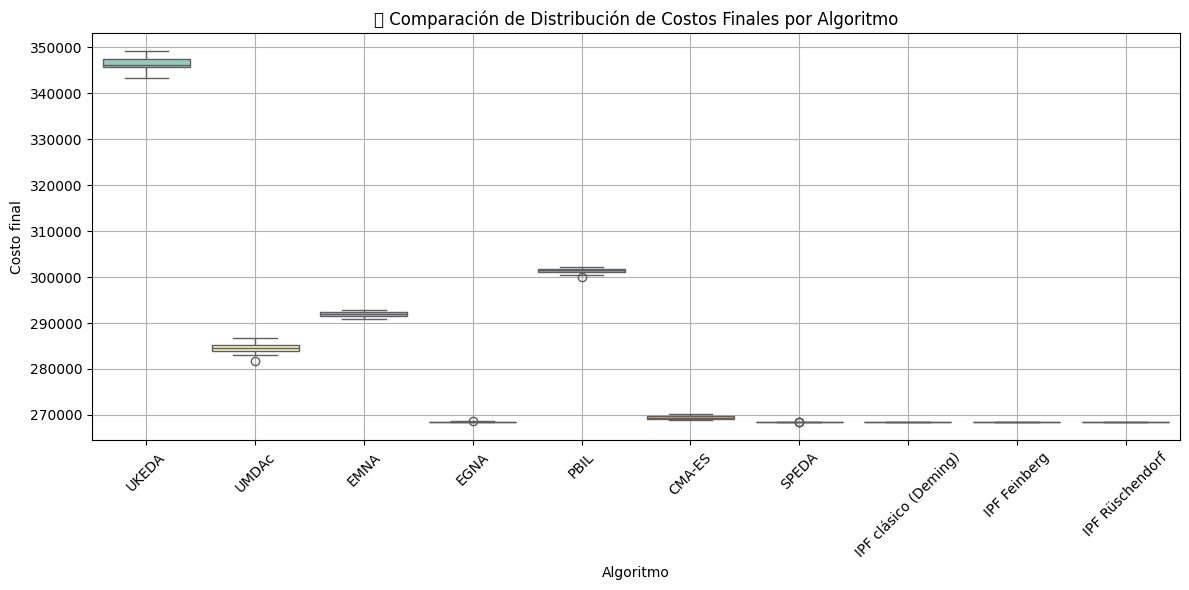

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Usar los nombres definidos en tu experimento
data = {
    "UKEDA": best_costs_keda,  # corregido
    "UMDAc": best_costs_umdac,
    "EMNA": best_costs_emna,
    "EGNA": best_costs_egna,
    "PBIL": best_costs_pbil,
    "CMA-ES": best_costs_cmaes,
    "SPEDA": best_costs_speda,
    "IPF clásico (Deming)": best_costs_deming,  # corregido
    "IPF Feinberg": best_costs_fienberg,
    "IPF Rüschendorf": best_costs_ruschendorf
}

df = pd.DataFrame(data)
df_melted = df.melt(var_name="Algoritmo", value_name="Costo final")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x="Algoritmo", y="Costo final", palette="Set3")
plt.title("📦 Comparación de Distribución de Costos Finales por Algoritmo")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# PRUEBAS IPF vs EDAS 4 DIM

Se han truncado las últimas 5000 líneas del flujo de salida.
     13.15181935   2.59673299]
   [  5.35209703   9.19608166   1.6292518  ...   4.27267553
     11.99359257   4.74287451]
   [  2.67496812  12.74509863   7.90421024 ...   5.66318529
      1.19833071   5.01514904]
   ...
   [  5.47609846  18.43830789   5.5473666  ...  11.18212088
      3.05583767   3.90456211]
   [ 28.32092844  14.91279906   8.30744667 ...   2.40673012
     11.28307944   4.7768776 ]
   [  8.55138245  11.57143227   6.17971189 ...   9.95852357
     13.22033894   7.1419645 ]]]]
Fitness tras local search: 3878220.3663248825
📌 CMA-ES 4D - Fitness final: 3878220.37, Tiempo: 83.11s
IT:  0 	Best cost:  4153927.3389543965
IT:  1 	Best cost:  4152200.5319121955
IT:  2 	Best cost:  4152200.5319121955
IT:  3 	Best cost:  4146268.3058984764
IT:  4 	Best cost:  4137442.6063181884
IT:  5 	Best cost:  4121680.31858821
IT:  6 	Best cost:  4121680.31858821
IT:  7 	Best cost:  4114020.536816195
IT:  8 	Best cost:  4108686.409456

<ipython-input-5-aed15ff6f1dd>:769: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


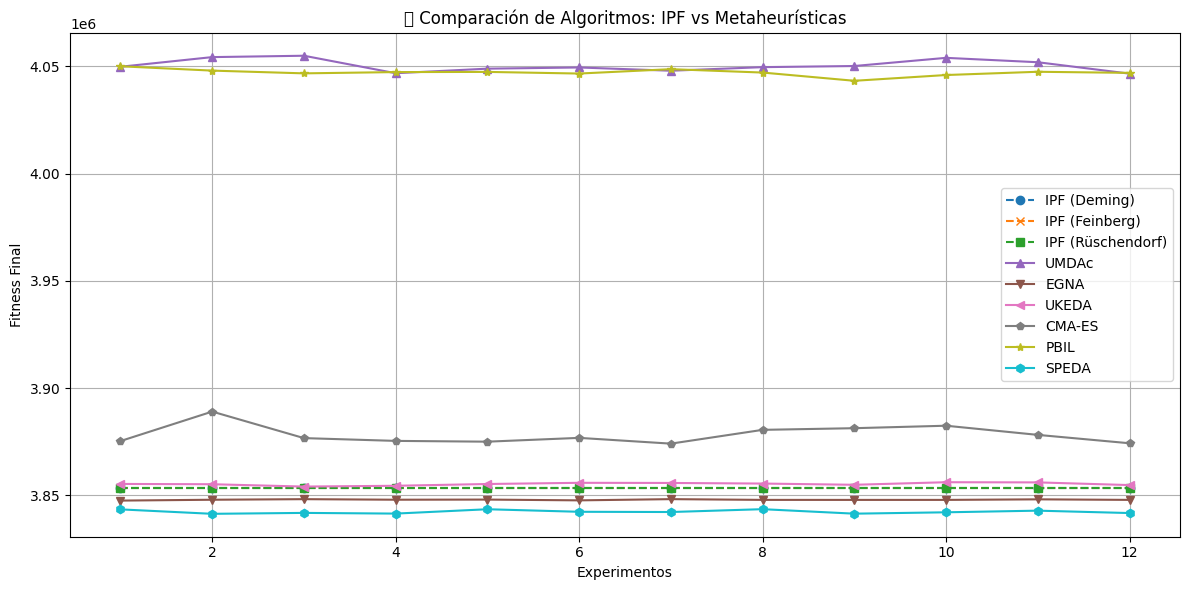


🔹 Resultados Finales por Experimento:
    Experimento  IPF (Deming)  IPF (Feinberg)  IPF (Rüschendorf)  \
0             1  3.853630e+06    3.853630e+06       3.853630e+06   
1             2  3.853630e+06    3.853630e+06       3.853630e+06   
2             3  3.853630e+06    3.853630e+06       3.853630e+06   
3             4  3.853630e+06    3.853630e+06       3.853630e+06   
4             5  3.853630e+06    3.853630e+06       3.853630e+06   
5             6  3.853630e+06    3.853630e+06       3.853630e+06   
6             7  3.853630e+06    3.853630e+06       3.853630e+06   
7             8  3.853630e+06    3.853630e+06       3.853630e+06   
8             9  3.853630e+06    3.853630e+06       3.853630e+06   
9            10  3.853630e+06    3.853630e+06       3.853630e+06   
10           11  3.853630e+06    3.853630e+06       3.853630e+06   
11           12  3.853630e+06    3.853630e+06       3.853630e+06   

           UMDAc          EGNA         UKEDA        CMA-ES          PBIL  \


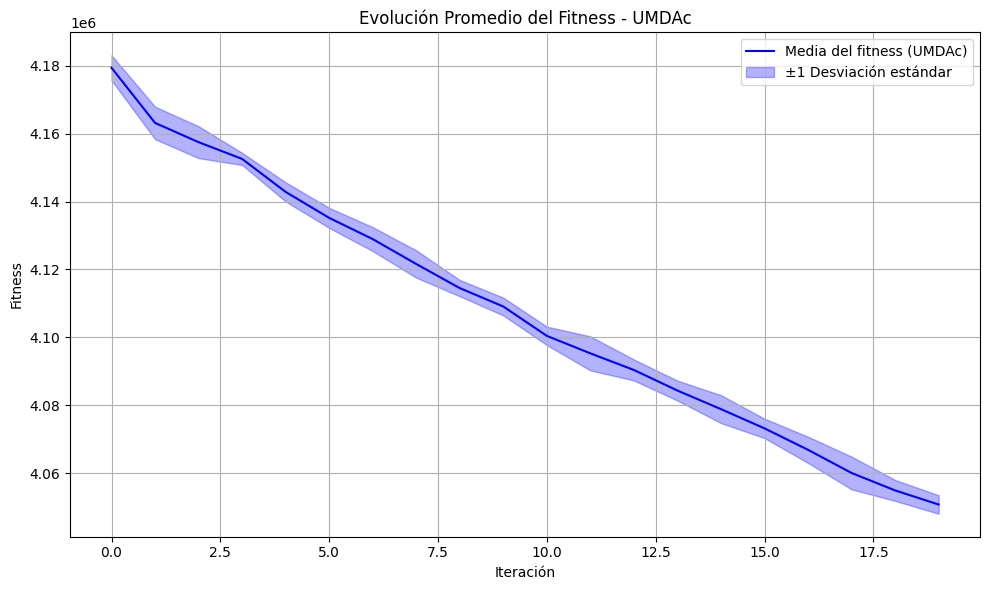

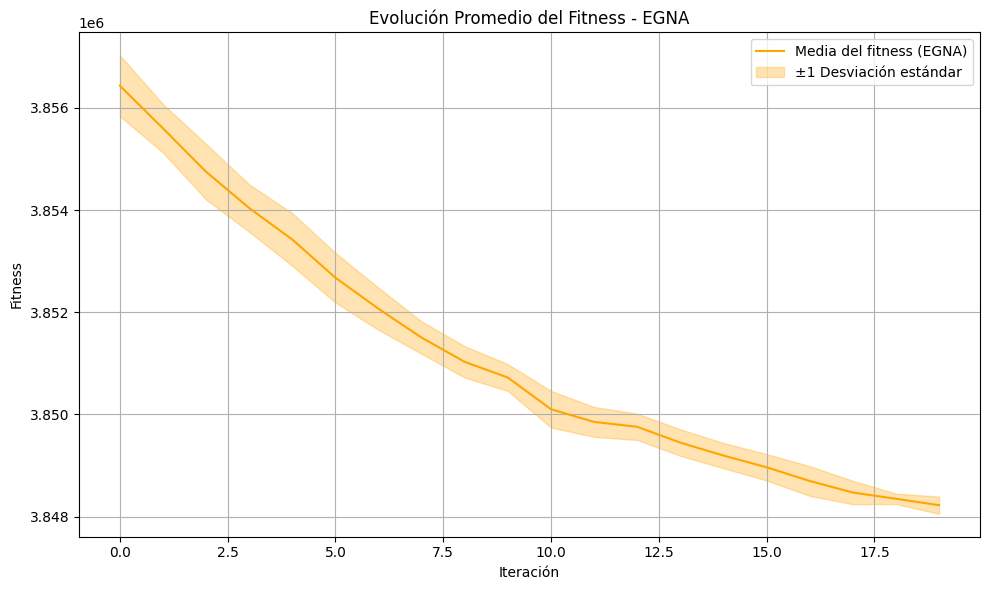

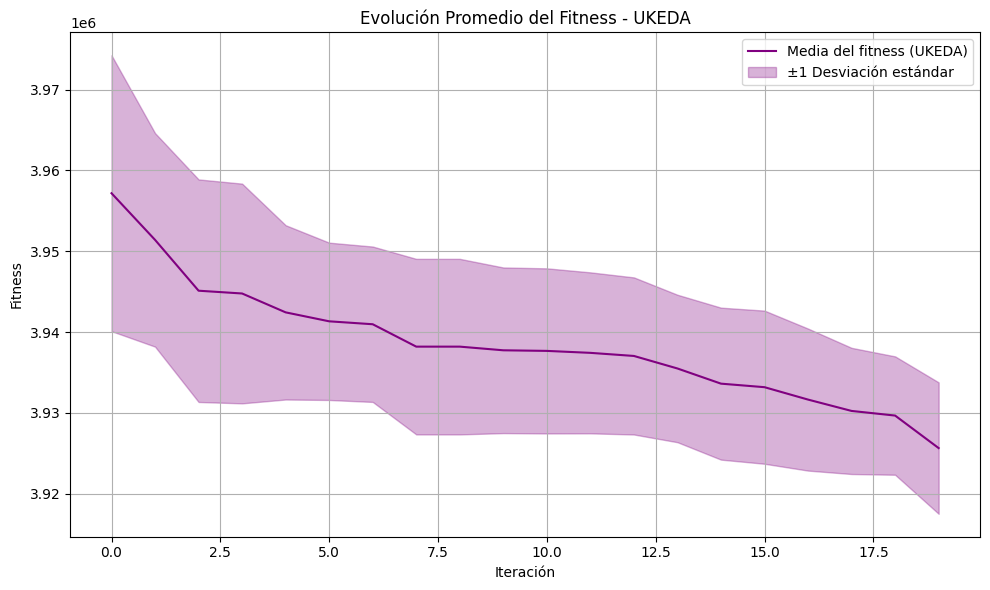

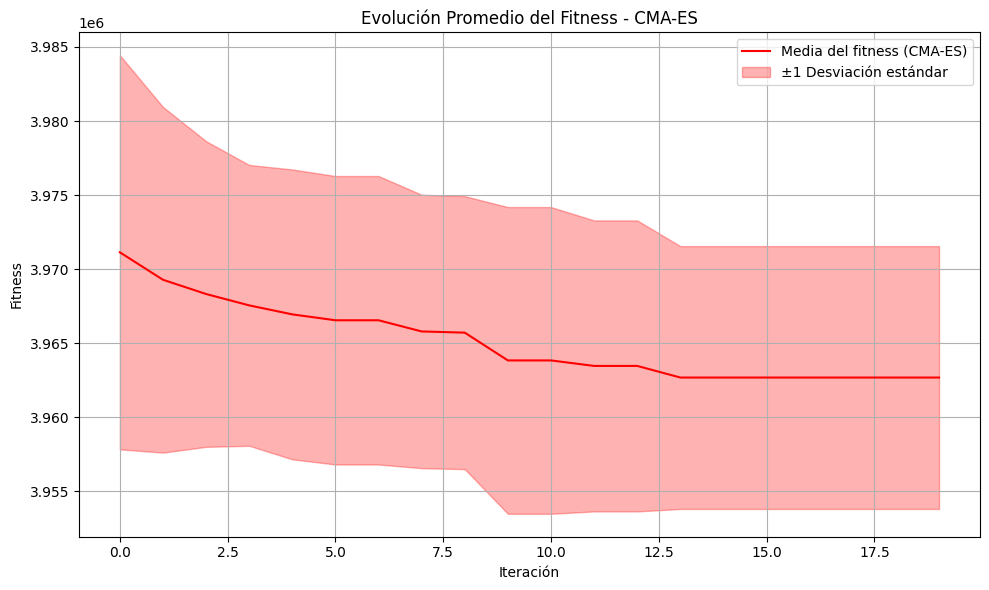

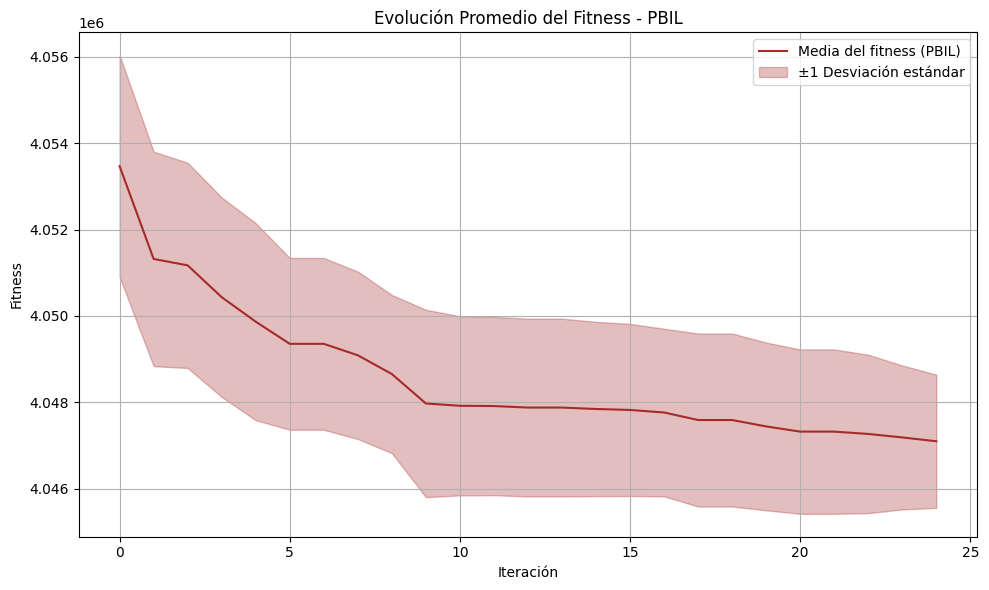

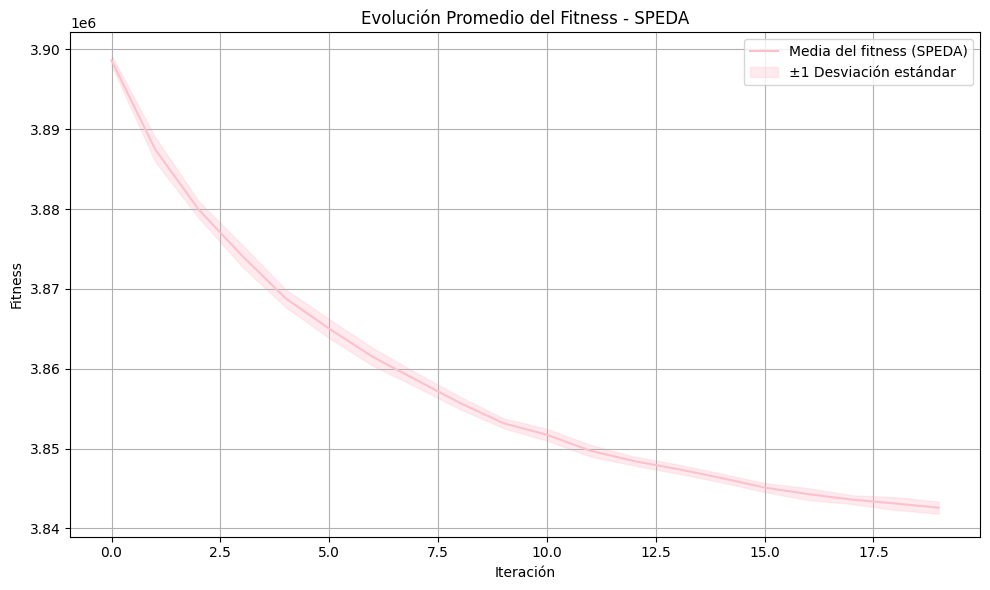

In [ ]:
import numpy as np
import matplotlib.pyplot as pltho
import matplotlib.pyplot as plt
import time, cma
import pandas as pd
from EDAspy.optimization import EMNA, UMDAc, EGNA

# Parámetros generales
num_experiments = 12  # Número de experimentos
iterations = 25  # Número de iteraciones
dimensions = (10, 10, 10, 10)  # Dimensiones del tensor (4D)


def generate_tensor_margins_4d(dimensions, total_sum=np.random.randint(200000, 400000)):
    # Márgenes para cada dimensión
    margin_0 = np.random.randint(10000, 30000, size=dimensions[0])
    margin_0 = np.round(margin_0 / margin_0.sum() * total_sum).astype(int)

    margin_1 = np.random.randint(10000, 30000, size=dimensions[1])
    margin_1 = np.round(margin_1 / margin_1.sum() * total_sum).astype(int)

    margin_2 = np.random.randint(10000, 30000, size=dimensions[2])
    margin_2 = np.round(margin_2 / margin_2.sum() * total_sum).astype(int)

    margin_3 = np.random.randint(10000, 30000, size=dimensions[3])
    margin_3 = np.round(margin_3 / margin_3.sum() * total_sum).astype(int)

    # Asegurarse de que los márgenes sumen el total deseado
    margin_0[-1] += total_sum - margin_0.sum()
    margin_1[-1] += total_sum - margin_1.sum()
    margin_2[-1] += total_sum - margin_2.sum()
    margin_3[-1] += total_sum - margin_3.sum()

    return margin_0, margin_1, margin_2, margin_3

def normalize_tensor_4d(tensor, margin0, margin1, margin2, margin3, max_iters=10, tol=1e-6):
    tensor = tensor.astype(float)
    for _ in range(max_iters):
        prev_tensor = tensor.copy()
        tensor = tensor.astype(float)

        sum0 = tensor.sum(axis=(1, 2, 3), keepdims=True)
        tensor *= margin0[:, None, None, None] / (sum0 + 1e-10)

        sum1 = tensor.sum(axis=(0, 2, 3), keepdims=True)
        tensor *= margin1[None, :, None, None] / (sum1 + 1e-10)

        sum2 = tensor.sum(axis=(0, 1, 3), keepdims=True)
        tensor *= margin2[None, None, :, None] / (sum2 + 1e-10)

        sum3 = tensor.sum(axis=(0, 1, 2), keepdims=True)
        tensor *= margin3[None, None, None, :] / (sum3 + 1e-10)

        diff = ((tensor - prev_tensor) ** 2).sum()
        if diff < tol:
            break

    return tensor

def generate_non_negative_tensor_4d(mean_tensor, std_tensor, max_retries=100):
    dim1, dim2, dim3, dim4 = mean_tensor.shape
    tensor = np.random.normal(mean_tensor, std_tensor)

    for i in range(dim1):
        for j in range(dim2):
            for k in range(dim3):
                for l in range(dim4):
                    retries = 0
                    while tensor[i, j, k, l] < 0 and retries < max_retries:
                        tensor[i, j, k, l] = np.random.normal(mean_tensor[i, j, k, l], std_tensor[i, j, k, l])
                        retries += 1
                    if tensor[i, j, k, l] < 0:
                        tensor[i, j, k, l] = 0  # Si sigue siendo negativo, lo fijamos a 0
    return tensor

def combined_penalty(tensor, margin_0, margin_1, margin_2, margin_3, initial_tensor, alpha=60, beta=10):
    row_diff = np.abs(tensor.sum(axis=(1, 2, 3)) - margin_0)
    col_diff = np.abs(tensor.sum(axis=(0, 2, 3)) - margin_1)
    depth_diff = np.abs(tensor.sum(axis=(0, 1, 3)) - margin_2)
    depth_4d_diff = np.abs(tensor.sum(axis=(0, 1, 2)) - margin_3)

    margin_penalty = np.sum(row_diff**2) + np.sum(col_diff**2) + np.sum(depth_diff**2) + np.sum(depth_4d_diff**2)
    similarity_penalty = np.sum(np.abs(tensor - initial_tensor))

    return alpha * margin_penalty + beta * similarity_penalty

def fitness_function_4d(tensor, margin_0, margin_1, margin_2, margin_3, initial_tensor):
    return combined_penalty(tensor, margin_0, margin_1, margin_2, margin_3, initial_tensor)


def ipf_deming_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor,
                  tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    best_costs = []

    for it in range(max_iterations):
        # --- Ajuste para la dimensión 0 ---
        sum0 = tensor.sum(axis=(1, 2, 3))
        sum0[sum0 == 0] = 1e-10
        tensor *= (margin0[:, None, None, None] / sum0[:, None, None, None])

        # --- Ajuste para la dimensión 1 ---
        sum1 = tensor.sum(axis=(0, 2, 3))
        sum1[sum1 == 0] = 1e-10
        tensor *= (margin1[None, :, None, None] / sum1[None, :, None, None])

        # --- Ajuste para la dimensión 2 ---
        sum2 = tensor.sum(axis=(0, 1, 3))
        sum2[sum2 == 0] = 1e-10
        tensor *= (margin2[None, None, :, None] / sum2[None, None, :, None])

        # --- Ajuste para la dimensión 3 ---
        sum3 = tensor.sum(axis=(0, 1, 2))
        sum3[sum3 == 0] = 1e-10
        tensor *= (margin3[None, None, None, :] / sum3[None, None, None, :])

        # --- Evaluar el fitness ---
        current_cost = fitness_function_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor)
        best_costs.append(current_cost)

        print(f"IT: {it + 1} \tBest cost: {int(current_cost)}")

        # Criterio de convergencia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    # Redondear y finalizar
    tensor = np.round(tensor).astype(int)
    execution_time = time.time() - start_time
    return tensor, execution_time, best_costs


def log_likelihood_4d(tensor, margin0, margin1, margin2, margin3):
    epsilon = 1e-10
    total = margin0.sum()
    expected = np.einsum('i,j,k,l->ijkl', margin0, margin1, margin2, margin3) / (total**3)
    return np.sum(tensor * np.log((tensor + epsilon) / expected))


def ipf_fienberg_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor,
                    tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    prev_ll = log_likelihood_4d(tensor, margin0, margin1, margin2, margin3)
    best_costs = []

    for it in range(max_iterations):
        # --- Ajuste para la dimensión 0 ---
        sum0 = tensor.sum(axis=(1, 2, 3))
        tensor *= margin0[:, None, None, None] / (sum0[:, None, None, None] + 1e-10)

        # --- Ajuste para la dimensión 1 ---
        sum1 = tensor.sum(axis=(0, 2, 3))
        tensor *= margin1[None, :, None, None] / (sum1[None, :, None, None] + 1e-10)

        # --- Ajuste para la dimensión 2 ---
        sum2 = tensor.sum(axis=(0, 1, 3))
        tensor *= margin2[None, None, :, None] / (sum2[None, None, :, None] + 1e-10)

        # --- Ajuste para la dimensión 3 ---
        sum3 = tensor.sum(axis=(0, 1, 2))
        tensor *= margin3[None, None, None, :] / (sum3[None, None, None, :] + 1e-10)

        # Evaluación
        new_ll = log_likelihood_4d(tensor, margin0, margin1, margin2, margin3)
        best_cost = fitness_function_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor)
        best_costs.append(best_cost)

        print(f"[Feinberg 4D] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if abs(new_ll - prev_ll) < tol:
            print("Convergencia alcanzada.")
            break

        prev_ll = new_ll

    execution_time = time.time() - start_time
    return np.round(tensor).astype(int), execution_time, best_costs


# KL divergencia simétrica para 4D
def kl_symmetric_divergence_4d(p, q):
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    return np.sum(p * np.log(p / q) + q * np.log(q / p))

# IPF con criterio de convergencia basado en Rüschendorf para 4D
def ipf_ruschendorf_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor,
                       tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    prev_tensor = tensor.copy()
    best_costs = []

    for it in range(max_iterations):
        # Ajuste dimensión 0
        sum0 = tensor.sum(axis=(1, 2, 3))
        tensor *= margin0[:, None, None, None] / (sum0[:, None, None, None] + 1e-10)

        # Ajuste dimensión 1
        sum1 = tensor.sum(axis=(0, 2, 3))
        tensor *= margin1[None, :, None, None] / (sum1[None, :, None, None] + 1e-10)

        # Ajuste dimensión 2
        sum2 = tensor.sum(axis=(0, 1, 3))
        tensor *= margin2[None, None, :, None] / (sum2[None, None, :, None] + 1e-10)

        # Ajuste dimensión 3
        sum3 = tensor.sum(axis=(0, 1, 2))
        tensor *= margin3[None, None, None, :] / (sum3[None, None, None, :] + 1e-10)

        # Evaluación del coste
        best_cost = fitness_function_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor)
        best_costs.append(best_cost)

        print(f"[Rüschendorf 4D] IT: {it + 1} \tBest cost: {int(best_cost)}")

        # Criterio de parada: divergencia KL simétrica
        if kl_symmetric_divergence_4d(tensor, prev_tensor) < tol:
            print("Convergencia alcanzada.")
            break

        prev_tensor = tensor.copy()

    execution_time = time.time() - start_time
    return np.round(tensor).astype(int), execution_time, best_costs

def local_search_with_noise_tensor_4d(X, margins, initial_tensor, shape, normalize_tensor,
                                     alpha=60, beta=10, trials=30, std=0.01):
    best_X = X.copy()
    best_tensor = normalize_tensor(X.reshape(shape), *margins)
    best_fitness = combined_penalty(best_tensor, *margins, initial_tensor, alpha, beta)
    best_perturbed_X = X.copy()
    improved = False

    for _ in range(trials):
        noise = np.random.normal(0, std, size=X.shape)
        perturbed_X = X + X * noise
        tensor = normalize_tensor(perturbed_X.reshape(shape), *margins)
        fitness = combined_penalty(tensor, *margins, initial_tensor, alpha, beta)

        if fitness < best_fitness:
            best_fitness = fitness
            best_X = tensor.flatten()
            best_perturbed_X = perturbed_X.copy()
            improved = True

    if improved:
        print("\nMejor 'perturbed_X':")
        print(best_perturbed_X.reshape(shape))
        print("Fitness tras local search:", best_fitness)
    else:
        print("\nLocal search no mejoró el fitness.")

    return best_X.reshape(shape), best_fitness, best_perturbed_X.reshape(shape), improved


#UMDAc
def run_umdac_tensor_4d(margins, shape, iterations, initial_tensor,
                        alpha=60, beta=10, local_search_trials=30, local_search_std=0.01):
    n_variables = np.prod(shape)
    upper_bound = max([m.max() for m in margins])

    umdac = UMDAc(size_gen=100, max_iter=iterations, dead_iter=10,
                  n_variables=n_variables, lower_bound=1, upper_bound=upper_bound)

    def fitness_function(individual):
        tensor = individual.reshape(shape)
        tensor = normalize_tensor_4d(tensor, *margins)
        return combined_penalty(tensor, *margins, initial_tensor, alpha, beta)

    start_time = time.time()
    result = umdac.minimize(fitness_function)
    end_time = time.time()

    best_tensor = result.best_ind.reshape(shape)
    best_tensor = normalize_tensor_4d(best_tensor, *margins)
    final_fitness = combined_penalty(best_tensor, *margins, initial_tensor, alpha, beta)
    execution_time = end_time - start_time

    # --- Aquí aplicamos la búsqueda local con ruido ---
    best_flat = best_tensor.flatten()
    best_tensor_ls, best_fitness_ls, best_perturbed_ls, improved = local_search_with_noise_tensor_4d(
        best_flat, margins, initial_tensor, shape, normalize_tensor_4d,
        alpha=alpha, beta=beta, trials=local_search_trials, std=local_search_std
    )

    # Si la búsqueda local mejora el resultado, actualizamos los valores
    if improved and best_fitness_ls < final_fitness:
        best_tensor = best_tensor_ls
        final_fitness = best_fitness_ls

    return best_tensor, np.array(result.history), final_fitness, execution_time

# EGNA 4D
def run_egna_tensor_4d(base_tensor, row_margins, col_margins, depth_margins, depth_4d_margins, initial_tensor,
                       population_size=50, num_generations=20, elite_size=10, noise_level=5, lambda_=0.7,
                       alpha=60, beta=10, trials=30, std=0.01):

    base_tensor = np.array(base_tensor)
    shape = base_tensor.shape
    margins = (row_margins, col_margins, depth_margins, depth_4d_margins)

    def fitness_wrapped(tensor):
        normalized = normalize_tensor_4d(tensor, *margins)
        return combined_penalty(normalized, *margins, initial_tensor, alpha, beta)

    current_population = [
        generate_non_negative_tensor_4d(base_tensor, np.full_like(base_tensor, noise_level))
        for _ in range(population_size)]

    history = []
    global_best_fitness = float('inf')
    global_best_tensor = None

    for gen in range(num_generations):
        fitness_scores = [
            float(fitness_wrapped(ind))
            for ind in current_population]

        current_best_fitness = min(fitness_scores)
        best_index = np.argmin(fitness_scores)
        current_best_tensor = current_population[best_index]

        if current_best_fitness < global_best_fitness:
            global_best_fitness = current_best_fitness
            global_best_tensor = current_best_tensor.copy()

        history.append(global_best_fitness)
        print(f"EGNA 4D - Generación {gen+1}: Best fitness = {global_best_fitness:.4f}")

        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)

        mean_elite = np.mean(elite_array, axis=0)
        std_elite = np.std(elite_array, axis=0)

        base_tensor = lambda_ * base_tensor + (1 - lambda_) * mean_elite

        current_population = [
            generate_non_negative_tensor_4d(base_tensor, std_elite)
            for _ in range(population_size)
        ]

    print("\nEjecutando búsqueda local con ruido sobre el tensor de EGNA (4D)")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor_4d(
        global_best_tensor.flatten(), margins, initial_tensor, shape,
        normalize_tensor_4d, alpha=alpha, beta=beta, trials=trials, std=std)

    if improved:
        refined_tensor = normalize_tensor_4d(refined_tensor, *margins)
        print("Búsqueda local mejoró la solución de EGNA 4D.")
        return refined_tensor, -np.array(history), refined_fitness
    else:
        global_best_tensor = normalize_tensor_4d(global_best_tensor, *margins)
        print("La búsqueda local no mejoró la solución de EGNA 4D.")
        return global_best_tensor, -np.array(history), global_best_fitness

#uKEDA
def run_univariate_keda_tensor_4d(base_tensor, margin0, margin1, margin2, margin3, initial_tensor,
                                   population_size=50, num_generations=20, elite_size=10, noise_level=3,
                                   alpha=60, beta=10, local_search_trials=30, local_search_std=0.01):
    shape = base_tensor.shape  # (dim0, dim1, dim2, dim3)

    # Inicializa la población con ruido y normalización
    current_population = [
        normalize_tensor_4d(
            generate_non_negative_tensor_4d(base_tensor, np.full_like(base_tensor, noise_level)),
            margin0, margin1, margin2, margin3
        )
        for _ in range(population_size)
    ]

    history = []
    prev_best_fitness = float('inf')

    for gen in range(num_generations):
        fitness_scores = [
            fitness_function_4d(np.round(ind).astype(int), margin0, margin1, margin2, margin3, initial_tensor)
            for ind in current_population
        ]

        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)

        mean = np.mean(elite_array, axis=0)
        std = np.std(elite_array, axis=0)

        current_population = [
            normalize_tensor_4d(
                generate_non_negative_tensor_4d(mean, std),
                margin0, margin1, margin2, margin3
            )
            for _ in range(population_size)
        ]

        best_fitness = np.min(fitness_scores)
        if best_fitness > prev_best_fitness:
            best_fitness = prev_best_fitness

        prev_best_fitness = best_fitness
        history.append(best_fitness)

        print(f"Univariate KEDA 4D - Generación {gen+1}: Best fitness = {best_fitness:.6f}")

    # Mejor tensor de la última población
    best_index = np.argmin(fitness_scores)
    best_tensor = current_population[best_index]

    # Aplicar búsqueda local con ruido
    best_flat = best_tensor.flatten()
    best_tensor_ls, best_fitness_ls, best_perturbed_ls, improved = local_search_with_noise_tensor_4d(
        best_flat, [margin0, margin1, margin2, margin3], initial_tensor, shape, normalize_tensor_4d,
        alpha=alpha, beta=beta, trials=local_search_trials, std=local_search_std)

    if improved and best_fitness_ls < best_fitness:
        final_tensor = best_tensor_ls
        final_fitness = best_fitness_ls
    else:
        final_tensor = np.round(best_tensor).astype(int)
        final_fitness = best_fitness

    return final_tensor, history, final_fitness


#PBIL 4D
def run_pbil_continuous_tensor_4d(margins, tensor_shape, iterations, initial_tensor,
                                  size_gen=100, learning_rate=0.01):
    n_variables = np.prod(tensor_shape)

    lower_bound = np.ones(n_variables)
    upper_bound = np.full(n_variables, max([m.max() for m in margins]))

    # Inicializar prob_vector igual que en 3D, centrado entre límites
    prob_vector = (lower_bound + upper_bound) / 2.0
    std_dev = (upper_bound - lower_bound) / 6

    def fitness_function(individual):
        tensor = individual.reshape(tensor_shape)
        tensor = normalize_tensor_4d(tensor, *margins)
        return combined_penalty(tensor, *margins, initial_tensor)

    best_fitness = float('inf')
    best_solution = None
    fitness_history = []

    for iter in range(iterations):
        population = np.random.normal(loc=prob_vector, scale=std_dev, size=(size_gen, n_variables))
        population = np.clip(population, lower_bound, upper_bound)

        fitness_values = np.array([fitness_function(ind) for ind in population])
        best_idx = np.argmin(fitness_values)
        best_individual = population[best_idx]

        if fitness_values[best_idx] < best_fitness:
            best_fitness = fitness_values[best_idx]
            best_solution = best_individual.copy()

        prob_vector = (1 - learning_rate) * prob_vector + learning_rate * best_individual
        fitness_history.append(best_fitness)

        print(f"PBIL IT {iter+1} - Best cost: {best_fitness:.4f}")

    best_tensor = best_solution.reshape(tensor_shape)
    best_tensor = normalize_tensor_4d(best_tensor, *margins)
    final_fitness = combined_penalty(best_tensor, *margins, initial_tensor)

    return best_tensor, fitness_history, final_fitness


#CMAES
def cmaes_4d_optimization(base_tensor, margin0, margin1, margin2, margin3, initial_tensor,
                          sigma=10, population_size=50, generations=20,
                          alpha=60, beta=10, local_search_trials=30, local_search_std=0.01):
    shape = base_tensor.shape
    n_variables = np.prod(shape)
    initial_flat = base_tensor.flatten().astype(float)

    es = cma.CMAEvolutionStrategy(initial_flat, sigma, {
        'popsize': population_size,
        'maxiter': generations,
        'verb_log': 0,
        'verb_disp': 0,
    })

    history = []
    best_fitness = float('inf')
    best_solution = None

    start_time = time.time()

    while not es.stop():
        solutions = es.ask()
        fitnesses = []

        for s in solutions:
            tensor = s.reshape(shape)
            tensor = np.clip(tensor, 0, None)  # Evita negativos
            tensor = normalize_tensor_4d(tensor, margin0, margin1, margin2, margin3)
            fitness = fitness_function_4d(np.round(tensor).astype(int), margin0, margin1, margin2, margin3, initial_tensor)
            fitnesses.append(fitness)

            if fitness < best_fitness:
                best_fitness = fitness
                best_solution = tensor.copy()

        es.tell(solutions, fitnesses)
        history.append(best_fitness)

        print(f"CMA-ES 4D - Generación {len(history)}: Best fitness = {best_fitness:.6f}")

        if len(history) >= generations:
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Aplicar búsqueda local con ruido al mejor tensor encontrado
    best_flat = best_solution.flatten()
    best_tensor_ls, best_fitness_ls, best_perturbed_ls, improved = local_search_with_noise_tensor_4d(
        best_flat, [margin0, margin1, margin2, margin3],
        initial_tensor, shape,normalize_tensor_4d, alpha=alpha, beta=beta,
        trials=local_search_trials, std=local_search_std)

    if improved and best_fitness_ls < best_fitness:
        final_tensor = best_tensor_ls
        final_fitness = best_fitness_ls
    else:
        final_tensor = np.round(best_solution).astype(int)
        final_fitness = best_fitness

    return final_tensor, history, final_fitness, execution_time


#SPEDA
def speda_4d_optimization(base_tensor, margin0, margin1, margin2, margin3, initial_tensor,
                          population_size=100, num_generations=20, elite_size=10, alpha=0.7, noise_level=None):
    shape = base_tensor.shape

    if noise_level is None:
        noise_level = np.mean(base_tensor) * 0.3

    # Inicializar población con ruido
    current_population = [
        generate_non_negative_tensor_4d(base_tensor, np.full_like(base_tensor, noise_level))
        for _ in range(population_size)
    ]

    history = []
    best_fitness_ever = float('inf')
    best_tensor_ever = None

    for gen in range(num_generations):
        fitness_scores = []
        normalized_population = []

        for ind in current_population:
            rounded = np.round(ind).astype(int)
            normalized = normalize_tensor_4d(rounded, margin0, margin1, margin2, margin3)
            fitness = combined_penalty(normalized, margin0, margin1, margin2, margin3, initial_tensor)
            fitness_scores.append(fitness)
            normalized_population.append(normalized)

        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)

        mean_elite = np.mean(elite_array, axis=0)
        std_elite = np.std(elite_array, axis=0)

        base_tensor = alpha * base_tensor + (1 - alpha) * mean_elite

        current_population = [
            generate_non_negative_tensor_4d(base_tensor, std_elite)
            for _ in range(population_size)]

        current_best_fitness = np.min(fitness_scores)
        current_best_index = np.argmin(fitness_scores)
        current_best_tensor = normalized_population[current_best_index]

        if current_best_fitness < best_fitness_ever:
            best_fitness_ever = current_best_fitness
            best_tensor_ever = current_best_tensor.copy()

        print(f"SPEDA 4D - Generación {gen + 1}: Mejor fitness hasta ahora = {best_fitness_ever:.4f}")
        history.append(best_fitness_ever)

    # Búsqueda local
    best_vector = best_tensor_ever.flatten()
    refined_tensor, refined_fitness, best_perturbed_tensor, improved = local_search_with_noise_tensor_4d(
        best_vector, [margin0, margin1, margin2, margin3], initial_tensor, shape,
        normalize_tensor_4d)

    if improved:
        print("\nSolución mejorada con búsqueda local.")
        return refined_tensor, np.array(history), refined_fitness, best_perturbed_tensor
    else:
        print("\nLa búsqueda local no mejoró la solución.")
        return best_tensor_ever, np.array(history), best_fitness_ever, best_tensor_ever


# Almacenar resultados
best_costs_deming, times_deming  = [], []
best_costs_fienberg, times_fienberg = [], []
best_costs_ruschendorf, times_ruschendorf = [], []

best_costs_umdac, times_umdac = [], []
best_costs_egna, times_egna = [], []
best_costs_keda, times_keda = [], []
best_costs_cmaes, times_cmaes = [], []
best_costs_pbil, times_pbil = [], []
best_costs_speda, times_speda = [], []

all_histories_speda, all_histories_umdac, all_histories_egna = [], [], []
all_histories_keda, all_histories_cmaes, all_histories_pbil= [], [], []


# Inicialización fija para todos los experimentos
initial_tensor = np.random.randint(20, 100, size=dimensions)

# Generación de los márgenes para las cuatro dimensiones
row_margins, col_margins, depth_margins, depth_4d_margins = generate_tensor_margins_4d(dimensions)

# Imprimir el tensor inicial y los márgenes
print("\nTensor inicial (antes de ajustar):")
#print(initial_tensor)

print("\nMárgenes por filas (dim 0):")
print(row_margins)
print("\nMárgenes por columnas (dim 1):")
print(col_margins)
print("\nMárgenes por profundidad (dim 2):")
print(depth_margins)
print("\nMárgenes por profundidad 4D (dim 3):")
print(depth_4d_margins)

# Repetir experimento
for i in range(num_experiments):
    print(f"\n🔹 Ejecutando experimento {i+1}/{num_experiments}...")

    margins = [row_margins, col_margins, depth_margins, depth_4d_margins]

    # IPF 4D (Deming)
    optimized_tensor_deming, time_deming, costs_deming = ipf_deming_4d(
        initial_tensor, row_margins, col_margins, depth_margins, depth_4d_margins, initial_tensor
    )
    best_costs_deming.append(costs_deming[-1])
    times_deming.append(time_deming)
    print(f"📌 IPF Deming - Fitness final: {costs_deming[-1]:.2f}, Tiempo: {time_deming:.2f}s")

    # IPF 4D (Feinberg)
    optimized_tensor_fienberg, time_fienberg, costs_fienberg = ipf_fienberg_4d(
        initial_tensor, row_margins, col_margins, depth_margins, depth_4d_margins, initial_tensor
    )
    best_costs_fienberg.append(costs_fienberg[-1])
    times_fienberg.append(time_fienberg)
    print(f"📌 IPF Feinberg - Fitness final: {costs_fienberg[-1]:.2f}, Tiempo: {time_fienberg:.2f}s")

    # IPF 4D (Rüschendorf)
    optimized_tensor_ruschendorf, time_ruschendorf, costs_ruschendorf = ipf_ruschendorf_4d(
        initial_tensor, row_margins, col_margins, depth_margins, depth_4d_margins, initial_tensor
    )
    best_costs_ruschendorf.append(costs_ruschendorf[-1])
    times_ruschendorf.append(time_ruschendorf)
    print(f"📌 IPF Rüschendorf - Fitness final: {costs_ruschendorf[-1]:.2f}, Tiempo: {time_ruschendorf:.2f}s")


    # PBIL 4 DIM
    start_time = time.time()
    optimized_tensor_pbil, history_pbil, final_fitness_pbil = run_pbil_continuous_tensor_4d(
       margins, dimensions, iterations, initial_tensor)
    time_pbil = time.time() - start_time
    best_costs_pbil.append(final_fitness_pbil)
    times_pbil.append(time_pbil)
    all_histories_pbil.append(history_pbil)
    print(f"📌 PBIL - Fitness final: {final_fitness_pbil:.2f}, Tiempo: {time_pbil:.2f}s")

    # CMAes 4 DIM
    start_time = time.time()
    optimized_tensor_cmaes, history_cmaes, final_fitness_cmaes, exec_time_cmaes = cmaes_4d_optimization(
        initial_tensor, *margins, initial_tensor)
    time_cmaes = time.time() - start_time
    best_costs_cmaes.append(final_fitness_cmaes)
    times_cmaes.append(time_cmaes)
    all_histories_cmaes.append(history_cmaes)
    print(f"📌 CMA-ES 4D - Fitness final: {final_fitness_cmaes:.2f}, Tiempo: {time_cmaes:.2f}s")


    # Ejecutar UMDAc en tensor 4D
    optimized_tensor_umdac, costs_umdac, final_fitness_umdac, time_umdac = run_umdac_tensor_4d(
        margins, initial_tensor.shape, iterations=20, initial_tensor=initial_tensor)
    # Guardar resultados
    best_costs_umdac.append(final_fitness_umdac)
    times_umdac.append(time_umdac)
    all_histories_umdac.append(costs_umdac)  # Historial de fitness por iteración
    print(f"📌 UMDAc 4D - Fitness final: {final_fitness_umdac:.4f}, Tiempo: {time_umdac:.2f}s")

    # Ejecutar EGNA 4D
    start_time = time.time()
    optimized_tensor_egna, history_egna, final_fitness_egna = run_egna_tensor_4d(
        initial_tensor, *margins, initial_tensor)
    end_time = time.time()
    time_egna = end_time - start_time
    # Guardar resultados
    best_costs_egna.append(final_fitness_egna)
    times_egna.append(time_egna)
    all_histories_egna.append(history_egna)
    print(f"📌 EGNA 4D - Fitness final: {final_fitness_egna:.4f}, Generaciones: {len(history_egna)}, Tiempo: {time_egna:.2f}s")


    # Ejecutar SPEDA en tensor 4D
    start_time = time.time()
    optimized_tensor_speda, history_speda, final_fitness_speda, _  = speda_4d_optimization(
        initial_tensor, *margins, initial_tensor)
    time_speda = time.time() - start_time
    best_costs_speda.append(final_fitness_speda)
    times_speda.append(time_speda)
    all_histories_speda.append(history_speda)
    print(f"📌 SPEDA 4D - Fitness final: {final_fitness_speda:.4f}, Tiempo: {time_speda:.2f}s")

    # Ejecutar uKEDA en tensor 4D
    start_time = time.time()
    optimized_tensor_keda, history_keda, final_fitness_keda = run_univariate_keda_tensor_4d(
        initial_tensor, *margins, initial_tensor=initial_tensor)
    time_keda = time.time() - start_time
    best_costs_keda.append(final_fitness_keda)
    times_keda.append(time_keda)
    all_histories_keda.append(history_keda)
    print(f"📌 Univariate KEDA 4D - Fitness final: {final_fitness_keda:.4f}, Tiempo: {time_keda:.2f}s")



# Mostrar resumen final
df_resultados = pd.DataFrame({
    "Experimento": np.arange(1, num_experiments+1),
    "IPF (Deming)": best_costs_deming,
    "IPF (Feinberg)": best_costs_fienberg,
    "IPF (Rüschendorf)": best_costs_ruschendorf,
    "UMDAc": best_costs_umdac,
    "EGNA": best_costs_egna,
    "UKEDA": best_costs_keda,
    "CMA-ES": best_costs_cmaes,
    "PBIL": best_costs_pbil,
    "SPEDA": best_costs_speda
})

# Graficar resultados de comparación de fitness
plt.figure(figsize=(12, 6))
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Deming)"], label="IPF (Deming)", marker='o', color='#1f77b4', linestyle='--')
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Feinberg)"], label="IPF (Feinberg)", marker='x', color='#ff7f0e', linestyle='--')
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Rüschendorf)"], label="IPF (Rüschendorf)", marker='s', color='#2ca02c', linestyle='--')
plt.plot(df_resultados["Experimento"], df_resultados["UMDAc"], label="UMDAc", color='#9467bd', marker='^')
plt.plot(df_resultados["Experimento"], df_resultados["EGNA"], label="EGNA", color='#8c564b', marker='v')
plt.plot(df_resultados["Experimento"], df_resultados["UKEDA"], label="UKEDA", color='#e377c2', marker='<')
plt.plot(df_resultados["Experimento"], df_resultados["CMA-ES"], label="CMA-ES", color='#7f7f7f', marker='p')
plt.plot(df_resultados["Experimento"], df_resultados["PBIL"], label="PBIL", color='#bcbd22', marker='*')
plt.plot(df_resultados["Experimento"], df_resultados["SPEDA"], label="SPEDA", color='#17becf', marker='h')

plt.xlabel("Experimentos")
plt.ylabel("Fitness Final")
plt.title("🔍 Comparación de Algoritmos: IPF vs Metaheurísticas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 🧾 Mostrar resultados tabulares
print("\n🔹 Resultados Finales por Experimento:")
print(df_resultados.round(4))

# Lista de todas las historias y etiquetas
all_histories = [all_histories_umdac, all_histories_egna, all_histories_keda,
                 all_histories_cmaes, all_histories_pbil, all_histories_speda]

labels = ["UMDAc", "EGNA", "UKEDA", "CMA-ES", "PBIL", "SPEDA"]

colors = ['blue', 'orange', 'purple', 'red', 'brown', 'pink']

for history_list, label, color in zip(all_histories, labels, colors):
    max_len = max(len(h) for h in history_list)
    history_array = np.array([np.pad(np.abs(h).astype(float), (0, max_len - len(h)), constant_values=np.nan) for h in history_list])

    mean_fitness = np.nanmean(history_array, axis=0)
    std_fitness = np.nanstd(history_array, axis=0)

    plt.figure(figsize=(10, 6))
    plt.plot(mean_fitness, label=f'Media del fitness ({label})', color=color)
    plt.fill_between(range(max_len),
                     mean_fitness - std_fitness,
                     mean_fitness + std_fitness,
                     color=color, alpha=0.3, label='±1 Desviación estándar')
    plt.title(f'Evolución Promedio del Fitness - {label}')
    plt.xlabel('Iteración')
    plt.ylabel('Fitness')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

<ipython-input-6-bfdb70443abf>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x="Algoritmo", y="Costo final", palette="Set3")
<ipython-input-6-bfdb70443abf>:26: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


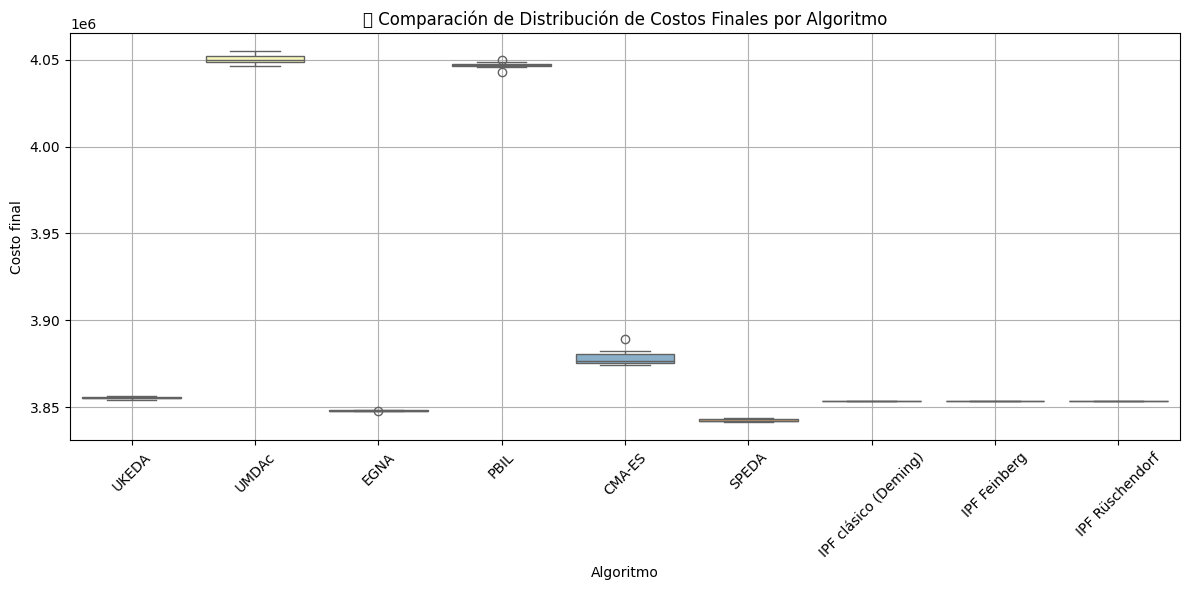

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Usar los nombres definidos en tu experimento
data = {
    "UKEDA": best_costs_keda,  # corregido
    "UMDAc": best_costs_umdac,
    "EGNA": best_costs_egna,
    "PBIL": best_costs_pbil,
    "CMA-ES": best_costs_cmaes,
    "SPEDA": best_costs_speda,
    "IPF clásico (Deming)": best_costs_deming,  # corregido
    "IPF Feinberg": best_costs_fienberg,
    "IPF Rüschendorf": best_costs_ruschendorf
}

df = pd.DataFrame(data)
df_melted = df.melt(var_name="Algoritmo", value_name="Costo final")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x="Algoritmo", y="Costo final", palette="Set3")
plt.title("📦 Comparación de Distribución de Costos Finales por Algoritmo")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


# 1 vs varias iteraciones


🔹 Matriz Inicial:
[[82 72 98 80 52 53 42 89 22 23]
 [30 55 50 22 91 90 42 93 20 48]
 [37 70 63 30 88 53 42 66 29 96]
 [51 83 80 78 38 93 81 29 82 86]
 [41 53 72 95 76 65 74 94 50 80]
 [33 47 91 79 28 94 30 50 50 55]
 [80 74 64 91 61 48 92 54 39 95]
 [66 81 20 69 96 98 50 84 41 54]
 [94 28 94 24 99 73 95 25 49 94]
 [26 62 82 90 46 98 31 67 92 53]]

🔹 Márgenes de filas:
[1027  601 1074 1248  908 1527 1344  597 1520 1293]

🔹 Márgenes de columnas:
[ 563 1343  676 1521 1556  901 1259 1419  750 1151]

🔹 Ejecutando experimento 1/10...

IPF 1 iteración: Best cost = 76256.74
IT:  0 	Best cost:  52317.21603084635
IT:  1 	Best cost:  52317.21603084635
IT:  2 	Best cost:  49966.18461129734
IT:  3 	Best cost:  49966.18461129734
IT:  4 	Best cost:  49966.18461129734
IT:  5 	Best cost:  49966.18461129734
IT:  6 	Best cost:  49966.18461129734
IT:  7 	Best cost:  45986.03114631979
IT:  8 	Best cost:  45986.03114631979
IT:  9 	Best cost:  45986.03114631979
IT:  10 	Best cost:  45986.03114631979
IT:  11

/usr/local/lib/python3.11/dist-packages/EDAspy/optimization/custom/probabilistic_models/multivariate_gaussian.py:42: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  return np.random.multivariate_normal(self.pm_means, self.pm_cov, size)


Se han truncado las últimas 5000 líneas del flujo de salida.
SPEDA Generación 3: Mejor fitness hasta ahora = 9518
SPEDA Generación 4: Mejor fitness hasta ahora = 9246
SPEDA Generación 5: Mejor fitness hasta ahora = 7861
SPEDA Generación 6: Mejor fitness hasta ahora = 7144
SPEDA Generación 7: Mejor fitness hasta ahora = 5844
SPEDA Generación 8: Mejor fitness hasta ahora = 5670
SPEDA Generación 9: Mejor fitness hasta ahora = 4792
SPEDA Generación 10: Mejor fitness hasta ahora = 4086
SPEDA Generación 11: Mejor fitness hasta ahora = 3852
SPEDA Generación 12: Mejor fitness hasta ahora = 3614
SPEDA Generación 13: Mejor fitness hasta ahora = 3157
SPEDA Generación 14: Mejor fitness hasta ahora = 2952
SPEDA Generación 15: Mejor fitness hasta ahora = 2069
SPEDA Generación 16: Mejor fitness hasta ahora = 1917
SPEDA Generación 17: Mejor fitness hasta ahora = 1889
SPEDA Generación 18: Mejor fitness hasta ahora = 1734
SPEDA Generación 19: Mejor fitness hasta ahora = 1653
SPEDA Generación 20: Mejor f

<ipython-input-19-afa5c521041d>:1095: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


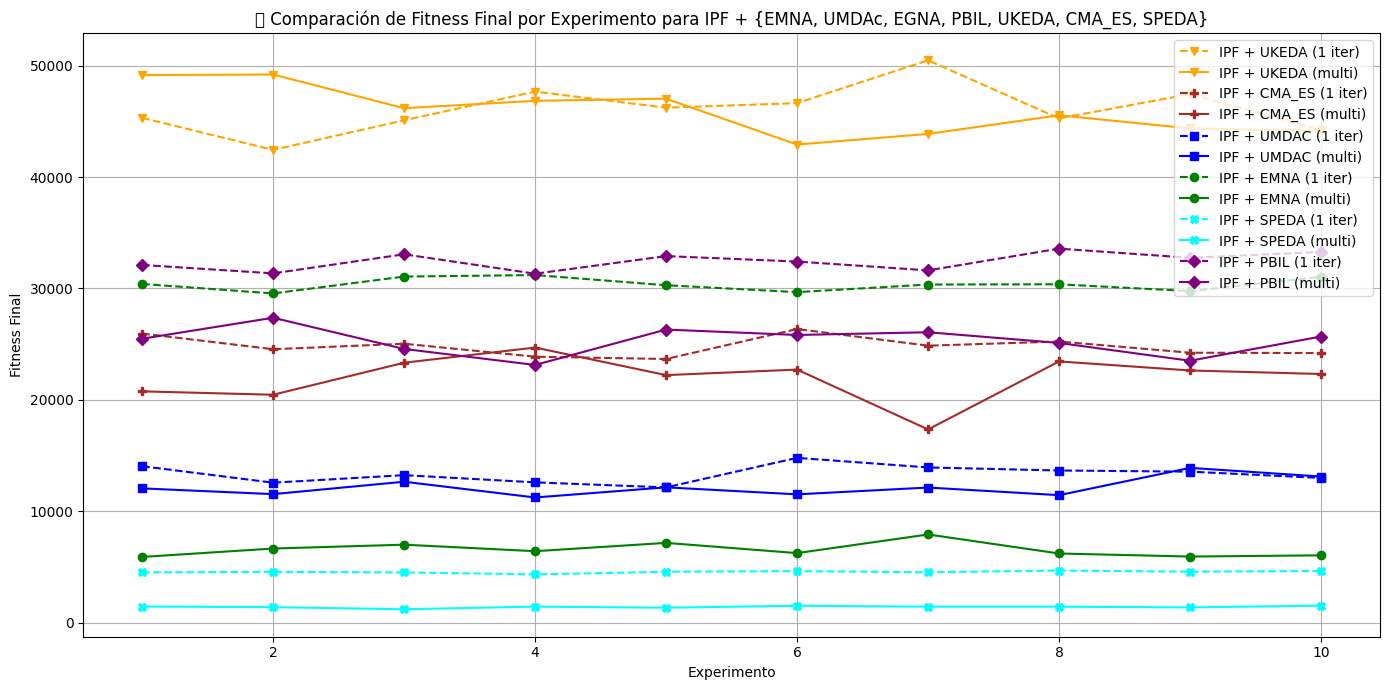

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, cma
from EDAspy.optimization import EMNA, UMDAc, EGNA, UnivariateKEDA


# Parámetros generales
rows, cols = 10, 10
total_sum = np.random.randint(10000, 20000)
num_experiments = 10

# Funciones auxiliares
def generate_initial_matrix(rows, cols):
    return np.random.randint(20, 100, size=(rows, cols))

def generate_margins(rows, cols, total_sum):
    row_margins = np.random.randint(2000, 6000, size=rows)
    row_margins = np.round(row_margins / row_margins.sum() * total_sum).astype(int)
    col_margins = np.random.randint(2000, 6000, size=cols)
    col_margins = np.round(col_margins / col_margins.sum() * total_sum).astype(int)
    row_margins[-1] += total_sum - row_margins.sum()
    col_margins[-1] += total_sum - col_margins.sum()
    return row_margins, col_margins

def generate_non_negative_matrix(mean_matrix, std_matrix, max_retries=100):
    rows, cols = mean_matrix.shape
    matrix = np.random.normal(mean_matrix, std_matrix)
    for i in range(rows):
        for j in range(cols):
            retries = 0
            while matrix[i, j] < 0 and retries < max_retries:
                matrix[i, j] = np.random.normal(mean_matrix[i, j], std_matrix[i, j])
                retries += 1
            if matrix[i, j] < 0:
                matrix[i, j] = 0
    return matrix

# Función de normalización
def normalize_matrix(matrix, row_margins, col_margins, max_iter=100):
    matrix = np.maximum(matrix, 1.0)
    for _ in range(max_iter):
        row_sums = matrix.sum(axis=1, keepdims=True)
        matrix *= row_margins[:, None] / (row_sums + 1e-10)
        col_sums = matrix.sum(axis=0, keepdims=True)
        matrix *= col_margins / (col_sums + 1e-10)
    return np.round(matrix).astype(int)


# Función de penalización combinada (debes definirla si no lo has hecho ya)
def combined_penalty(matrix, row_margins, col_margins, initial_matrix, alpha=60, beta=10):
    row_diff = np.abs(matrix.sum(axis=1) - row_margins).sum()
    col_diff = np.abs(matrix.sum(axis=0) - col_margins).sum()
    similarity = np.abs(matrix - initial_matrix).sum()
    return alpha * (row_diff + col_diff) + beta * similarity

# Función de fitness
def fitness_function(matrix, row_margins, col_margins, initial_matrix):
    return combined_penalty(matrix, row_margins, col_margins, initial_matrix)


# Función de búsqueda local con ruido
def local_search_with_noise(X, row_margins, col_margins, initial_matrix, alpha=60, beta=10, trials=30, std=0.01):
    global rows, cols
    rows, cols = len(row_margins), len(col_margins)

    best_X = X.copy()
    best_fitness = combined_penalty(
        normalize_matrix(X.reshape((rows, cols)), row_margins, col_margins),
        row_margins, col_margins, initial_matrix, alpha, beta
    )
    best_perturbed_X = X.copy()
    improved = False

    for _ in range(trials):
        noise = np.random.normal(loc=0, scale=std, size=X.shape)
        perturbed_X = X + X * noise
        matrix = perturbed_X.reshape((rows, cols))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix, alpha, beta)

        if fitness < best_fitness:
            best_fitness = fitness
            best_X = matrix.flatten()
            best_perturbed_X = perturbed_X.copy()
            improved = True

    if improved:
        print("\nMejor 'perturbed_X':")
        print(best_perturbed_X)
        print("\nFitness tras local search':")
        print(best_fitness)
    else:
        print("\nLocal search no mejoró el fitness.")

    return best_X.reshape((rows, cols)), best_fitness, best_perturbed_X.reshape((rows, cols)), improved


# Función para ejecutar EMNA
def run_emna(row_margins, col_margins, dimensions, iterations, initial_matrix):
    emna = EMNA(size_gen=100, max_iter=iterations, dead_iter=0,
                n_variables=dimensions, lower_bound=1, upper_bound=max(row_margins.max(), col_margins.max()))

    def fitness_function(individual):
        matrix = individual.reshape((rows, cols))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()
    result = emna.minimize(fitness_function)
    end_time = time.time()

    best_matrix = result.best_ind.reshape((rows, cols))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Búsqueda local después de EMNA
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix)

    # Si la búsqueda local no mejoró, usar el resultado de EMNA
    if not improved:
        print("\nUsando la matriz de EMNA como la mejor solución.")
        best_matrix_refined = best_matrix

    execution_time = end_time - start_time
    return best_matrix_refined, np.array(result.history), refined_fitness, execution_time, best_perturbed_matrix


def iterative_proportional_fitting_plus_emna_one_iter(matrix, row_margins, col_margins, initial_matrix):
    start_time = time.time()

    # Paso IPF
    matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
    matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

    # Evaluación después de IPF
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    print(f"\nIPF: Best cost = {best_fitness_so_far:.2f}")

    # Refinamiento con EMNA
    refined_matrix, history, refined_fitness, execution_time_emna, _ = run_emna(row_margins, col_margins, matrix.size, 10, matrix)

    # Actualizar si mejora
    if refined_fitness < best_fitness_so_far:
        best_matrix_so_far = refined_matrix.astype(float)
        best_fitness_so_far = refined_fitness

    end_time = time.time()
    execution_time = end_time - start_time

    return np.round(best_matrix_so_far).astype(int), execution_time, [best_fitness_so_far]


def iterative_proportional_fitting_plus_emna(matrix, row_margins, col_margins, initial_matrix, iterations=10, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con EMNA: Usamos la matriz de IPF como base
        refined_matrix, history, refined_fitness, execution_time_emna, _ = run_emna(row_margins, col_margins, matrix.size, 10, matrix)

        # Compara la solución refinada con la mejor solución global (de IPF y EMNA)
        if refined_fitness < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness

        best_costs.append(best_fitness_so_far)

        # Criterio de parada: si la diferencia entre costes consecutivos es menor que la tolerancia, parar
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("  Diferencia menor que tolerancia. Parando.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    return np.round(best_matrix_so_far).astype(int), execution_time, best_costs


# UMDAc (Estimación de distribución con variables categóricas)
def run_umdac(row_margins, col_margins, dimensions, iterations, initial_matrix):
    umdac = UMDAc(size_gen=100, max_iter=iterations, dead_iter=10,
                  n_variables=dimensions, lower_bound=1, upper_bound=max(row_margins.max(), col_margins.max()))

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))  # Reshape del individuo en la forma de la matriz
        matrix = normalize_matrix(matrix, row_margins, col_margins)  # Normalización de la matriz
        return np.sum(combined_penalty(matrix, row_margins, col_margins, initial_matrix))  # Sumar la penalización

    # Ejecución de UMDAc
    start_time = time.time()
    result = umdac.minimize(fitness_function)  # Minimización con UMDAc
    end_time = time.time()

    # Mejor solución encontrada
    best_matrix = result.best_ind.reshape((len(row_margins), len(col_margins)))  # Reshape de la mejor solución
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)  # Normalización de la mejor solución

    best_matrix = result.best_ind.reshape((rows, cols))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Búsqueda local después de UMDAc
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix)

    # Si la búsqueda local no mejoró, usar el resultado de UMDAc
    if not improved:
        print("\nUsando la matriz de UMDAc como la mejor solución.")
        best_matrix_refined = best_matrix

    # Tiempo de ejecución
    execution_time = end_time - start_time

    #Fitness IPF+UMDAc
    final_fitness = combined_penalty(best_matrix, row_margins, col_margins, initial_matrix)

    # Retornar la mejor matriz, el historial de resultados y el tiempo de ejecución
    return best_matrix, np.array(result.history), execution_time


def iterative_proportional_fitting_plus_umdac_one_iter(matrix, row_margins, col_margins, initial_matrix):
    start_time = time.time()

    # Inicializar con la matriz original
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    # Paso IPF
    matrix = best_matrix_so_far.copy()
    matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
    matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

    current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)
    if current_fitness < best_fitness_so_far:
        best_fitness_so_far = current_fitness
        best_matrix_so_far = matrix.copy()

    print(f"\nIPF Iteración única: Best cost = {best_fitness_so_far:.2f}")

    # UMDAc
    refined_matrix, fitness_history, execution_time_umdac = run_umdac(
        row_margins, col_margins, matrix.size, 20, matrix
    )
    refined_fitness = fitness_history[-1]

    if refined_fitness < best_fitness_so_far:
        best_matrix_so_far = refined_matrix.astype(float)
        best_fitness_so_far = refined_fitness

    end_time = time.time()
    total_time = end_time - start_time

    return np.round(best_matrix_so_far).astype(int), total_time, [best_fitness_so_far]


def iterative_proportional_fitting_plus_umdac(matrix, row_margins, col_margins, initial_matrix, iterations=10, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializar con la matriz original
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con UMDAc
        refined_matrix, fitness_history, execution_time_umdac = run_umdac(row_margins, col_margins, matrix.size, 20, matrix)
        refined_fitness = fitness_history[-1]  # Tomamos el fitness final

        # Comparación global
        if refined_fitness < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            best_costs.append(best_fitness_so_far)

        # Parada temprana si no hay mejora significativa
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("  Diferencia menor que tolerancia. Parando.")
            break

    end_time = time.time()
    execution_time = end_time - start_time
    return np.round(best_matrix_so_far).astype(int), execution_time, best_costs


def run_egna(row_margins, col_margins, dimensions, iterations, initial_matrix):
    egna = EGNA(size_gen=100, max_iter=iterations, dead_iter=10, n_variables=dimensions, lower_bound=1,
                upper_bound=max(row_margins.max(), col_margins.max()))

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()
    result = egna.minimize(fitness_function)
    end_time = time.time()

    best_matrix = result.best_ind.reshape((len(row_margins), len(col_margins)))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Local search con ruido
    best_matrix_refined, refined_fitness, _, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix
    )

    if not improved:
        print("\nUsando la matriz de EGNA como la mejor solución.")
        best_matrix_refined = best_matrix
        refined_fitness = combined_penalty(best_matrix_refined, row_margins, col_margins, initial_matrix)

    execution_time = end_time - start_time
    return best_matrix_refined, np.array(result.history), refined_fitness

def iterative_proportional_fitting_plus_egna(matrix, row_margins, col_margins, initial_matrix, iterations=10, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # EGNA: se usa la matriz de IPF como punto de partida
        refined_matrix, fitness_history, refined_fitness, execution_time_egna = run_egna(
            row_margins, col_margins, matrix.size, 20, matrix)


        # Si EGNA mejora, actualizamos la mejor matriz y su coste
        if refined_fitness < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos lo anterior
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far

        # Criterio de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("  Diferencia menor que tolerancia. Parando.")
            break

    end_time = time.time()
    execution_time = end_time - start_time
    return np.round(best_matrix_so_far).astype(int), execution_time, best_costs


def iterative_proportional_fitting_plus_egna_one_iter(matrix, row_margins, col_margins, initial_matrix):
    best_costs = []
    start_time = time.time()

    # Paso IPF: Actualizamos la matriz utilizando los márgenes
    matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
    matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

    # Evaluación después de IPF
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    print(f"\nIPF (una iteración): Best cost = {best_fitness_so_far:.2f}")

    # EGNA: se usa la matriz de IPF como punto de partida
    refined_matrix, fitness_history, refined_fitness = run_egna(
        row_margins, col_margins, matrix.size, 20, matrix)

    # Si EGNA mejora, actualizamos la mejor matriz y su coste
    if refined_fitness < best_fitness_so_far:
        best_matrix_so_far = refined_matrix.astype(float)
        best_fitness_so_far = refined_fitness
        best_costs.append(refined_fitness)
    else:
        # Si no mejora, mantenemos lo anterior
        best_costs.append(best_fitness_so_far)

    end_time = time.time()
    execution_time = end_time - start_time

    # Para mantener consistencia con la versión multi iteración, devolvemos lista de costes con uno solo valor
    return np.round(best_matrix_so_far).astype(int), execution_time, best_costs


def run_ukeda(row_margins, col_margins, dimensions, iterations, initial_matrix):
    ukeda = UnivariateKEDA(size_gen=350, max_iter=iterations, dead_iter=10,
        n_variables=dimensions, lower_bound=1, upper_bound=max(row_margins.max(), col_margins.max()))

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()
    result = ukeda.minimize(fitness_function)
    end_time = time.time()

    best_matrix = result.best_ind.reshape((len(row_margins), len(col_margins)))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    best_matrix_refined, refined_fitness, _, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix)

    if not improved:
        print("\nUsando la matriz de UKEDA (sin mejora en búsqueda local).")
        best_matrix_refined = best_matrix
        refined_fitness = fitness_function(result.best_ind)

    execution_time = end_time - start_time
    return best_matrix_refined, np.array(result.history), refined_fitness, execution_time

def iterative_proportional_fitting_plus_ukeda_one_iter(matrix, row_margins, col_margins, initial_matrix, tol=1e-6):
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    # Solo una iteración
    matrix = best_matrix_so_far.copy()

    # Paso IPF: Actualizamos la matriz utilizando los márgenes
    matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
    matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

    # Evaluación después de IPF
    current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    # Actualizamos la mejor matriz y fitness si IPF mejora
    if current_fitness < best_fitness_so_far:
        best_fitness_so_far = current_fitness
        best_matrix_so_far = matrix.copy()

    print(f"\nIPF 1 iteración: Best cost = {best_fitness_so_far:.2f}")

    # UKEDA: se usa la matriz de IPF como punto de partida
    refined_matrix, fitness_history, refined_fitness, execution_time_ukeda = run_ukeda(
        row_margins, col_margins, matrix.size, 20, matrix)

    # Si UKEDA mejora, actualizamos la mejor matriz y su coste
    if refined_fitness < best_fitness_so_far:
        best_matrix_so_far = refined_matrix.astype(float)
        best_fitness_so_far = refined_fitness
        best_costs = [refined_fitness]
    else:
        best_costs = [best_fitness_so_far]
        refined_fitness = best_fitness_so_far

    end_time = time.time()
    execution_time = end_time - start_time

    return np.round(best_matrix_so_far).astype(int), execution_time, best_costs


# IPF clásico con UKEDA
def iterative_proportional_fitting_plus_ukeda(matrix, row_margins, col_margins, initial_matrix, iterations=10, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # UKEDA: se usa la matriz de IPF como punto de partida
        refined_matrix, fitness_history, refined_fitness, execution_time_ukeda = run_ukeda(
            row_margins, col_margins, matrix.size, 20, matrix)

        # Si UKEDA mejora, actualizamos la mejor matriz y su coste
        if refined_fitness < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos lo anterior
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far

        # Criterio de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("  Diferencia menor que tolerancia. Parando.")
            break

    end_time = time.time()
    exection_time = end_time - start_time
    return np.round(best_matrix_so_far).astype(int), exection_time, best_costs


# PBIL continuo con búsqueda local
def run_pbil_continuous(row_margins, col_margins, dimensions, iterations, initial_matrix,
                        size_gen=100, learning_rate=0.01):
    n_variables = dimensions
    n_rows, n_cols = len(row_margins), len(col_margins)

    lower_bound = np.ones(n_variables)
    upper_bound = np.full(n_variables, max(np.max(row_margins), np.max(col_margins)))

    # Vector de probabilidad inicial (valor medio dentro del rango)
    prob_vector = (upper_bound + lower_bound) / 2.0
    std_dev = (upper_bound - lower_bound) / 6  # Supone 99.7% dentro del rango en una normal

    best_fitness = float('inf')
    best_solution = None
    fitness_history = []

    def fitness_function(individual):
        matrix = individual.reshape((n_rows, n_cols))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()

    for iter in range(iterations):
        # Generar población a partir de una distribución normal centrada en prob_vector
        population = np.random.normal(loc=prob_vector, scale=std_dev, size=(size_gen, n_variables))
        population = np.clip(population, lower_bound, upper_bound)

        # Evaluar fitness
        fitness_values = np.array([fitness_function(ind) for ind in population])
        best_idx = np.argmin(fitness_values)
        best_individual = population[best_idx]

        # Actualizar mejor solución
        if fitness_values[best_idx] < best_fitness:
            best_fitness = fitness_values[best_idx]
            best_solution = best_individual.copy()

        # Actualizar vector de probabilidad hacia el mejor individuo
        prob_vector = (1 - learning_rate) * prob_vector + learning_rate * best_individual

        # Guardar historial
        fitness_history.append(best_fitness)

        # Mostrar progreso
        print(f"Iteración {iter+1}/{iterations} - Mejor Costo: {best_fitness:.4f}")

    # Búsqueda local después de PBIL
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        best_solution, row_margins, col_margins, initial_matrix)

    if improved:
        print("\nSe mejoró la solución con búsqueda local.")
    else:
        print("\nLa búsqueda local no mejoró la solución de PBIL. Usando la mejor solución original.")
        best_matrix_refined = best_solution.reshape((n_rows, n_cols))
        best_matrix_refined = normalize_matrix(best_matrix_refined, row_margins, col_margins)

    end_time = time.time()
    execution_time = end_time - start_time
    print(f"Tiempo total de ejecución PBIL + Local Search: {execution_time:.2f} segundos")

    return initial_matrix, best_matrix_refined, fitness_history

def iterative_proportional_fitting_plus_pbil_one_iter(matrix, row_margins, col_margins, initial_matrix, tol=1e-6):
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy().astype(float)
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    # Solo una iteración IPF
    matrix = best_matrix_so_far.copy()
    matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
    matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

    current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    if current_fitness < best_fitness_so_far:
        best_fitness_so_far = current_fitness
        best_matrix_so_far = matrix.copy()

    print(f"\nIPF 1 iteración: Best cost = {best_fitness_so_far:.2f}")

    # Refinamiento con PBIL
    _, refined_matrix, fitness_history = run_pbil_continuous(row_margins, col_margins, matrix.size, 20, matrix)
    refined_fitness = fitness_history[-1]

    if refined_fitness < best_fitness_so_far:
        best_matrix_so_far = refined_matrix.astype(float)
        best_fitness_so_far = refined_fitness
        best_costs = fitness_history  # lista completa
    else:
        best_costs = [best_fitness_so_far]

    execution_time = time.time() - start_time

    return np.round(best_matrix_so_far).astype(int), execution_time, best_costs

def iterative_proportional_fitting_plus_pbil(matrix, row_margins, col_margins, initial_matrix, iterations=20, tol=1e-6):
    matrix = matrix.astype(float)
    best_costs = []
    start_time = time.time()

    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    for it in range(iterations):
        matrix = best_matrix_so_far.copy()

        # Paso IPF
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento PBIL
        _, refined_matrix, fitness_history = run_pbil_continuous(row_margins, col_margins, matrix.size, 20, matrix)
        refined_fitness = fitness_history[-1]

        if refined_fitness < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness
        else:
            print(f"No mejora el costo en la iteración {it}")

        best_costs.append(best_fitness_so_far)

        # Criterio de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Criterio de parada alcanzado: Convergencia")
            break

    execution_time = time.time() - start_time
    best_matrix_so_far = np.round(best_matrix_so_far).astype(int)

    return best_matrix_so_far, execution_time, best_costs


# Función de optimización con CMA-ES
def run_cma_es(row_margins, col_margins, dimensions, iterations, initial_matrix):
    # Inicialización de CMA-ES
    x0 = initial_matrix.flatten()
    sigma = 50  # Desviación estándar inicial
    es = cma.CMAEvolutionStrategy(x0, sigma)

    # Historial de resultados
    history = []
    best_overall_cost = float('inf')
    best_solution = None

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()

    # Ejecución de iteraciones
    for i in range(iterations):
        solutions = es.ask()
        fitness_values = [fitness_function(sol) for sol in solutions]
        es.tell(solutions, fitness_values)

        gen_best_cost = min(fitness_values)
        history.append(gen_best_cost)

        if gen_best_cost < best_overall_cost:
            best_overall_cost = gen_best_cost
            best_solution = solutions[fitness_values.index(gen_best_cost)]

        print(f"Iteración {i+1}: Best Cost = {best_overall_cost}")

    end_time = time.time()

    # Mejor matriz del CMA-ES
    best_matrix = best_solution.reshape((len(row_margins), len(col_margins)))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Aplicar búsqueda local sobre la mejor solución
    best_matrix_refined, refined_fitness, _, improved = local_search_with_noise(
        best_solution, row_margins, col_margins, initial_matrix
    )

    if improved:
        print("\nSe mejoró la solución con búsqueda local.")
        best_matrix = best_matrix_refined
        best_overall_cost = refined_fitness
    else:
        print("\nLa búsqueda local no mejoró la solución de CMA-ES.")

    execution_time = end_time - start_time

    return best_matrix, history, execution_time


def iterative_proportional_fitting_plus_cma_es_one_iter(matrix, row_margins, col_margins, initial_matrix, tol=1e-6):
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    # Asegurarnos de que el coste no sea infinito
    if np.isinf(best_fitness_so_far):
        print("Error: El coste inicial es infinito, ajustando a un valor muy grande.")
        best_fitness_so_far = 1e10  # O algún valor adecuado para evitar infinito

    # Solo una iteración
    matrix = best_matrix_so_far.copy()

    # Paso IPF: Actualizamos la matriz utilizando los márgenes
    matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
    matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

    # Evaluación después de IPF
    current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    # Actualizamos la mejor matriz y fitness si IPF mejora
    if current_fitness < best_fitness_so_far:
        best_fitness_so_far = current_fitness
        best_matrix_so_far = matrix.copy()

    print(f"\nIPF 1 iteración: Best cost = {best_fitness_so_far:.2f}")

    # CMA-ES: se usa la matriz de IPF como punto de partida
    refined_matrix, fitness_history, execution_time = run_cma_es(row_margins, col_margins, matrix.shape, 20, matrix)

    refined_fitness = fitness_history[-1]

    # Si CMA-ES mejora, actualizamos la mejor matriz y su coste
    if refined_fitness < best_fitness_so_far:
        best_matrix_so_far = refined_matrix.astype(float)
        best_fitness_so_far = refined_fitness
        best_costs = [refined_fitness]
    else:
        best_costs = [best_fitness_so_far]
        refined_fitness = best_fitness_so_far

    end_time = time.time()
    execution_time = end_time - start_time
    return np.round(best_matrix_so_far).astype(int), execution_time , best_costs


def iterative_proportional_fitting_plus_cma_es(matrix, row_margins, col_margins, initial_matrix, iterations=20, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    # Asegurarnos de que el coste no sea infinito
    if np.isinf(best_fitness_so_far):
        print("Error: El coste inicial es infinito, ajustando a un valor muy grande.")
        best_fitness_so_far = 1e10  # O algún valor adecuado para evitar infinito

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # CMA-ES: se usa la matriz de IPF como punto de partida
        refined_matrix, fitness_history, execution_time = run_cma_es(row_margins, col_margins, matrix.shape, 20, matrix)

        refined_fitness = fitness_history[-1]

        # Si CMA-ES mejora, actualizamos la mejor matriz y su coste
        if refined_fitness < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos lo anterior
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far

        # Criterio de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("  Diferencia menor que tolerancia. Parando.")
            break

    end_time = time.time()
    exection_time = end_time - start_time
    return np.round(best_matrix_so_far).astype(int), exection_time, best_costs


# SPEDA (versión simplificada)
def speda_optimization(base_matrix, row_margins, col_margins, initial_matrix,
                       population_size=100, num_generations=20, elite_size=10, alpha=0.7, noise_level=5):
    rows, cols = base_matrix.shape

    current_population = [generate_non_negative_matrix(base_matrix, np.full_like(base_matrix, noise_level))
                          for _ in range(population_size)]

    history = []
    best_fitness_ever = float('inf')
    best_matrix_ever = None

    for gen in range(num_generations):
        fitness_scores = [
            combined_penalty(np.round(ind).astype(int), row_margins, col_margins, initial_matrix)
            for ind in current_population
        ]

        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)

        mean_elite = np.mean(elite_array, axis=0)
        std_elite = np.std(elite_array, axis=0)

        base_matrix = alpha * base_matrix + (1 - alpha) * mean_elite

        current_population = [generate_non_negative_matrix(base_matrix, std_elite)
                              for _ in range(population_size)]

        current_best_fitness = np.min(fitness_scores)
        current_best_index = np.argmin(fitness_scores)
        current_best_matrix = np.round(current_population[current_best_index]).astype(int)

        if current_best_fitness < best_fitness_ever:
            best_fitness_ever = current_best_fitness
            best_matrix_ever = current_best_matrix.copy()

        print(f"SPEDA Generación {gen+1}: Mejor fitness hasta ahora = {int(best_fitness_ever)}")
        history.append(best_fitness_ever)

    # Búsqueda local después de SPEDA
    best_vector = best_matrix_ever.flatten()
    refined_matrix, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        best_vector, row_margins, col_margins, initial_matrix
    )

    if improved:
        print("\nSe mejoró la solución con búsqueda local.")
        best_matrix_ever = refined_matrix
        history.append(refined_fitness)
    else:
        print("\nLa búsqueda local no mejoró la solución de SPEDA.")

    return best_matrix_ever, np.array(history)


def iterative_proportional_fitting_plus_speda_one_iter(matrix, row_margins, col_margins, initial_matrix, tol=1e-6):
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)
    best_costs = []

    # Solo una iteración
    # Usar la mejor matriz encontrada hasta ahora como punto de partida
    matrix = best_matrix_so_far.copy()

    # Paso IPF: Actualizamos la matriz utilizando los márgenes
    matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
    matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

    # Evaluación después de IPF
    current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    # Actualizamos la mejor matriz y fitness si IPF mejora
    if current_fitness < best_fitness_so_far:
        best_fitness_so_far = current_fitness
        best_matrix_so_far = matrix.copy()

    print(f"\nIPF 1 iteración: Best cost = {best_fitness_so_far:.2f}")

    # SPEDA: se usa la matriz de IPF como punto de partida
    refined_matrix, fitness_history = speda_optimization(
        np.round(matrix).astype(int), row_margins, col_margins, matrix
    )
    refined_fitness = fitness_history[-1]

    # Si SPEDA mejora, actualizamos la mejor matriz y su coste
    if refined_fitness < best_fitness_so_far:
        best_matrix_so_far = refined_matrix.astype(float)
        best_fitness_so_far = refined_fitness
        best_costs.append(refined_fitness)
    else:
        best_costs.append(best_fitness_so_far)
        refined_fitness = best_fitness_so_far

    end_time = time.time()
    execution_time = end_time - start_time
    return np.round(best_matrix_so_far).astype(int), execution_time, best_costs


def iterative_proportional_fitting_plus_speda(matrix, row_margins, col_margins, initial_matrix, iterations=10, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # SPEDA: se usa la matriz de IPF como punto de partida
        refined_matrix, fitness_history = speda_optimization(
            np.round(matrix).astype(int),row_margins,col_margins,matrix)

        refined_fitness = fitness_history[-1]

        # Si SPEDA mejora, actualizamos la mejor matriz y su coste
        if refined_fitness < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos lo anterior
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far

        # Criterio de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("  Diferencia menor que tolerancia. Parando.")
            break

    end_time = time.time()
    execution_time = end_time - start_time
    return np.round(best_matrix_so_far).astype(int), execution_time, best_costs


methods = ["ukeda", "cma_es", "umdac", "emna", "speda", "pbil"] #, "egna"

all_data = {
    m: {
        "multi": {"fitness": [], "times": [], "histories": []},
        "one_iter": {"fitness": [], "times": [], "histories": []}
    } for m in methods
}

# Inicialización fija para todos los experimentos
initial_matrix = generate_initial_matrix(rows, cols)
row_margins, col_margins = generate_margins(rows, cols, total_sum)

print("\n🔹 Matriz Inicial:")
print(initial_matrix)
print("\n🔹 Márgenes de filas:")
print(row_margins)
print("\n🔹 Márgenes de columnas:")
print(col_margins)

# Ejecutar experimentos
for i in range(num_experiments):
    print(f"\n🔹 Ejecutando experimento {i + 1}/{num_experiments}...")

    for method in methods:
        # One iteration
        func_one = globals()[f"iterative_proportional_fitting_plus_{method}_one_iter"]
        matrix_one, time_one, costs_one = func_one(initial_matrix, row_margins, col_margins, initial_matrix)
        all_data[method]["one_iter"]["fitness"].append(costs_one[-1])
        all_data[method]["one_iter"]["times"].append(time_one)
        all_data[method]["one_iter"]["histories"].append(costs_one)
        print(f"📌 IPF + {method.upper()} (1 iter) - Fitness: {costs_one[-1]:.2f}, Tiempo: {time_one:.2f}s")

        # Multi iteration
        func_multi = globals()[f"iterative_proportional_fitting_plus_{method}"]
        matrix_multi, time_multi, costs_multi = func_multi(initial_matrix, row_margins, col_margins, initial_matrix)
        all_data[method]["multi"]["fitness"].append(costs_multi[-1])
        all_data[method]["multi"]["times"].append(time_multi)
        all_data[method]["multi"]["histories"].append(costs_multi)
        print(f"📌 IPF + {method.upper()} (multi) - Fitness: {costs_multi[-1]:.2f}, Tiempo: {time_multi:.2f}s")

# Crear DataFrame de resumen
df_resultados = pd.DataFrame({"Experimento": np.arange(1, num_experiments + 1)})
for method in methods:
    metodo = method.upper()
    df_resultados[f"Fitness IPF+{metodo} (1 iter)"] = all_data[method]["one_iter"]["fitness"]
    df_resultados[f"Tiempo IPF+{metodo} (1 iter)"] = all_data[method]["one_iter"]["times"]
    df_resultados[f"Fitness IPF+{metodo} (multi)"] = all_data[method]["multi"]["fitness"]
    df_resultados[f"Tiempo IPF+{metodo} (multi)"] = all_data[method]["multi"]["times"]

# Mostrar tabla de resultados
print("\n📊 Resultados Comparativos:")
print(df_resultados)

# Gráfica comparativa de fitness final por experimento
plt.figure(figsize=(14, 7))
markers = {'emna': 'o', 'umdac': 's', 'pbil': 'D', 'ukeda': 'v', 'cma_es': 'P', 'speda': 'X'} #, 'egna': '^'
colors = {'emna': 'green', 'umdac': 'blue', 'pbil': 'purple', 'ukeda': 'orange', 'cma_es': 'brown', 'speda': 'cyan'} #, 'egna': 'red'

for method in methods:
    metodo = method.upper()
    plt.plot(df_resultados["Experimento"], df_resultados[f"Fitness IPF+{metodo} (1 iter)"],
             label=f"IPF + {metodo} (1 iter)", color=colors[method], marker=markers[method], linestyle='--')
    plt.plot(df_resultados["Experimento"], df_resultados[f"Fitness IPF+{metodo} (multi)"],
             label=f"IPF + {metodo} (multi)", color=colors[method], marker=markers[method], linestyle='-')

plt.xlabel("Experimento")
plt.ylabel("Fitness Final")
plt.title("📉 Comparación de Fitness Final por Experimento para IPF + {EMNA, UMDAc, EGNA, PBIL, UKEDA, CMA_ES, SPEDA}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# PRUEBAS IPF vs IPF+EDAs 2 DIM


🔹 Matriz Inicial:
[[46 98 41 64 68 96 84 88 44 43]
 [82 70 55 90 87 95 21 54 33 95]
 [58 83 66 54 81 83 61 92 91 49]
 [44 82 99 25 67 80 63 42 76 23]
 [59 39 91 96 39 88 83 50 61 73]
 [20 34 67 84 46 43 80 94 21 32]
 [67 53 78 47 66 41 78 99 93 55]
 [45 20 56 73 41 79 33 48 36 58]
 [50 36 26 39 25 44 73 94 98 55]
 [38 29 63 64 32 59 39 92 85 34]]

🔹 Márgenes de filas:
[1250 2685 2395 1824 1343 1703 1622 2163 1877 1349]

🔹 Márgenes de columnas:
[2325 1847 1523 1899 1630 2034 1975 2021 1049 1908]

🔹 Ejecutando experimento 1/15...
IT: 0 	Best cost: 1873935
IT: 1 	Best cost: 123056
IT: 2 	Best cost: 120973
IT: 3 	Best cost: 120970
IT: 4 	Best cost: 120970
IT: 5 	Best cost: 120970
IT: 6 	Best cost: 120969
📌 IPF basado en Deming & Stephan - Fitness final: 120970.00, Tiempo: 0.00s
[Fienberg] IT: 1 	Best cost: 1873935
[Fienberg] IT: 2 	Best cost: 123056
[Fienberg] IT: 3 	Best cost: 120973
[Fienberg] IT: 4 	Best cost: 120970
[Fienberg] IT: 5 	Best cost: 120970
[Fienberg] IT: 6 	Best cost: 1209

/usr/local/lib/python3.11/dist-packages/EDAspy/optimization/custom/probabilistic_models/multivariate_gaussian.py:42: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  return np.random.multivariate_normal(self.pm_means, self.pm_cov, size)


IT:  0 	Best cost:  47249.711764928725
IT:  1 	Best cost:  47014.45488043257
IT:  2 	Best cost:  46876.634115969966
IT:  3 	Best cost:  46806.634115969966
IT:  4 	Best cost:  46726.634115969966
IT:  5 	Best cost:  46303.00152377808
IT:  6 	Best cost:  46303.00152377808
IT:  7 	Best cost:  46176.634115969966
IT:  8 	Best cost:  46176.634115969966
	NFEVALS = 1000 F = 46176.634115969966
	X = [1246.62120244 1556.46187623 1189.71214803 1358.37328844 1355.02814269
 1485.25585316 1298.94641364 1401.30366059 1410.0376982  1417.16182381
 1315.03306459 1427.2318815  1395.7896313  1478.44052389 1651.20798633
 1498.87065962 1232.61420011 1120.55636043 1312.71720015 1681.18558842
 1227.0625036  1559.93753729 1473.99372989 1271.94784494 1419.10075606
 1307.87532007 1504.9317705  1288.41714827 1472.74776845 1225.67945281
 1268.95655297 1490.64471167 1487.40911491 1373.93815955 1316.76165902
 1271.61277637 1445.7132057  1291.82616986 1438.65255433 1312.73911006
 1466.6011997  1522.44854354 1242.250975

/usr/local/lib/python3.11/dist-packages/EDAspy/optimization/custom/probabilistic_models/multivariate_gaussian.py:42: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  return np.random.multivariate_normal(self.pm_means, self.pm_cov, size)


IT:  0 	Best cost:  50244.90071249133
IT:  1 	Best cost:  50244.90071249133
IT:  2 	Best cost:  50078.721657632916
IT:  3 	Best cost:  50078.721657632916
IT:  4 	Best cost:  49974.99847438273
IT:  5 	Best cost:  49704.99847438273
IT:  6 	Best cost:  49704.99847438273
IT:  7 	Best cost:  49591.26812029946
IT:  8 	Best cost:  49544.99847438273
	NFEVALS = 1000 F = 49544.99847438273
	X = [1533.75876013 1621.60898664 1429.54361781 1286.13987541 1288.48950187
 1376.97767061 1630.80069401 1588.61085777 1394.17882833 1229.83083052
 1341.8536445  1399.99692437 1467.09483439 1386.34094327 1310.75469247
 1455.12659298 1282.59125614 1331.71988898 1331.68957893 1262.82965584
 1502.72244591 1559.7335574  1370.33296753 1270.40159514 1432.09419708
 1539.27800526 1362.56678349 1408.52519109 1324.70211051 1198.25447036
 1274.01568858 1466.06236347 1544.22882657 1152.44374628 1228.7357953
 1402.96237403 1404.70592134 1381.92642046 1341.42494891 1489.20654137
 1528.0455255  1236.35486243 1216.80361676 150

...

/usr/local/lib/python3.11/dist-packages/EDAspy/optimization/custom/probabilistic_models/multivariate_gaussian.py:42: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  return np.random.multivariate_normal(self.pm_means, self.pm_cov, size)


IT:  0 	Best cost:  47913.253040018324
IT:  1 	Best cost:  47913.253040018324
IT:  2 	Best cost:  47913.253040018324
IT:  3 	Best cost:  47732.533205994216
IT:  4 	Best cost:  47732.533205994216
IT:  5 	Best cost:  47532.533205994216
IT:  6 	Best cost:  47532.533205994216
IT:  7 	Best cost:  47532.533205994216
IT:  8 	Best cost:  47517.7850875164
	NFEVALS = 1000 F = 47517.7850875164
	X = [1289.53677543 1494.38111554 1366.73486866 1301.65504947 1251.01215574
 1202.67006923 1235.24581561 1498.26542545 1321.10293534 1199.10700069
 1353.87895624 1536.04353064 1349.02796301 1554.00715739 1288.64473148
 1458.91882938 1191.1132916  1077.14282068 1361.44183373 1525.83196562
 1376.62063494 1442.26374299 1369.46034328 1473.54498444 1546.73134223
 1489.10465093 1438.06464365 1541.76658415 1411.14357719 1262.6874042
 1363.92223606 1254.40843253 1461.67251085 1378.7379457  1361.0229945
 1240.75984181 1352.81851049 1396.2399563  1472.34233122 1325.72472295
 1309.5006471  1246.28803211 1538.33582688 

/usr/local/lib/python3.11/dist-packages/EDAspy/optimization/custom/probabilistic_models/multivariate_gaussian.py:42: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  return np.random.multivariate_normal(self.pm_means, self.pm_cov, size)


IT:  0 	Best cost:  46970.45791064652
IT:  1 	Best cost:  46970.45791064652
IT:  2 	Best cost:  46821.33547350976
IT:  3 	Best cost:  46821.33547350976
IT:  4 	Best cost:  46692.812624745864
IT:  5 	Best cost:  46447.967625957375
IT:  6 	Best cost:  46447.967625957375
IT:  7 	Best cost:  46334.09707034279
IT:  8 	Best cost:  46109.905587598114
	NFEVALS = 1000 F = 46109.905587598114
	X = [1223.35616546 1392.7561723  1132.37540456 1351.8303382  1477.02308697
 1267.18232586 1476.60784263 1311.54491407 1311.11450893 1201.14842804
 1528.23760977 1441.57777148 1328.36207122 1482.80543103 1393.70308547
 1285.07347729 1029.1111663  1193.97541151 1244.18438397 1455.87266841
 1315.34319434 1693.38990564 1226.36648738 1356.50670084 1473.9763469
 1423.14604975 1391.61317258 1406.0794463  1518.11840114 1085.71040798
 1394.34503933 1400.73035751 1380.16128876 1252.2616465  1459.0651963
 1596.39985597 1225.25892539 1345.32035816 1622.49020452 1314.52292163
 1162.69899386 1381.27202207 1187.42334144 1

<ipython-input-18-fafc5bba4206>:1037: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


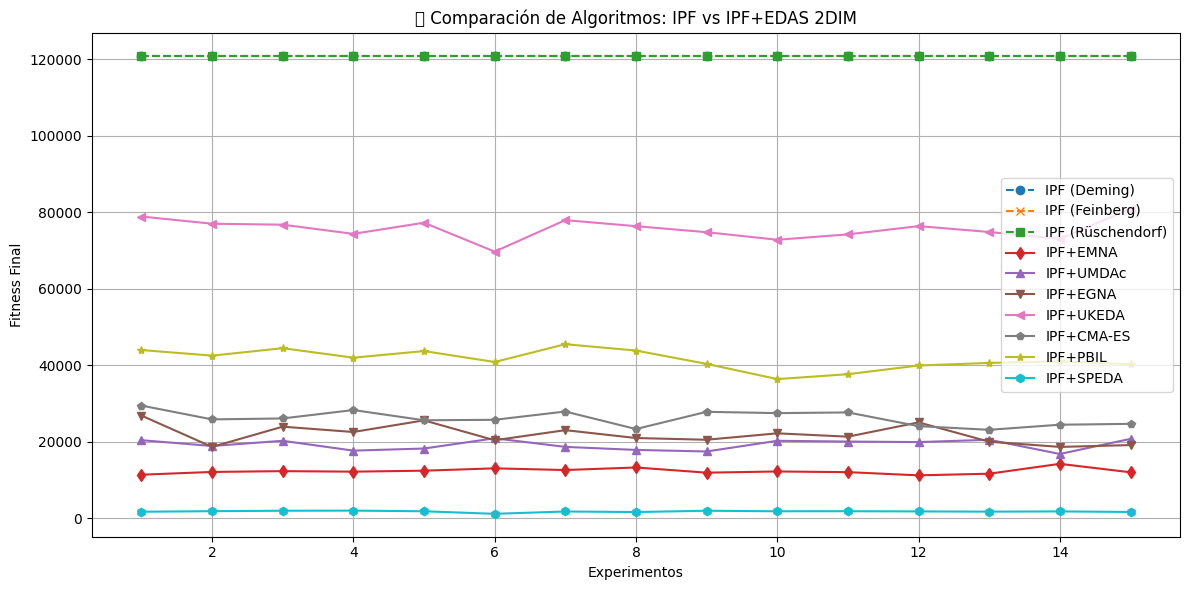


🔹 Resultados Finales por Experimento:
    Experimento  IPF (Deming)  IPF (Feinberg)  IPF (Rüschendorf)    IPF+EMNA  \
0             1      120970.0        120970.0           120970.0  11397.9978   
1             2      120970.0        120970.0           120970.0  12120.2645   
2             3      120970.0        120970.0           120970.0  12333.7619   
3             4      120970.0        120970.0           120970.0  12196.4444   
4             5      120970.0        120970.0           120970.0  12451.6684   
5             6      120970.0        120970.0           120970.0  13061.6378   
6             7      120970.0        120970.0           120970.0  12621.5726   
7             8      120970.0        120970.0           120970.0  13288.0204   
8             9      120970.0        120970.0           120970.0  11932.1616   
9            10      120970.0        120970.0           120970.0  12243.0413   
10           11      120970.0        120970.0           120970.0  12065.5275   
1

<ipython-input-18-fafc5bba4206>:1074: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


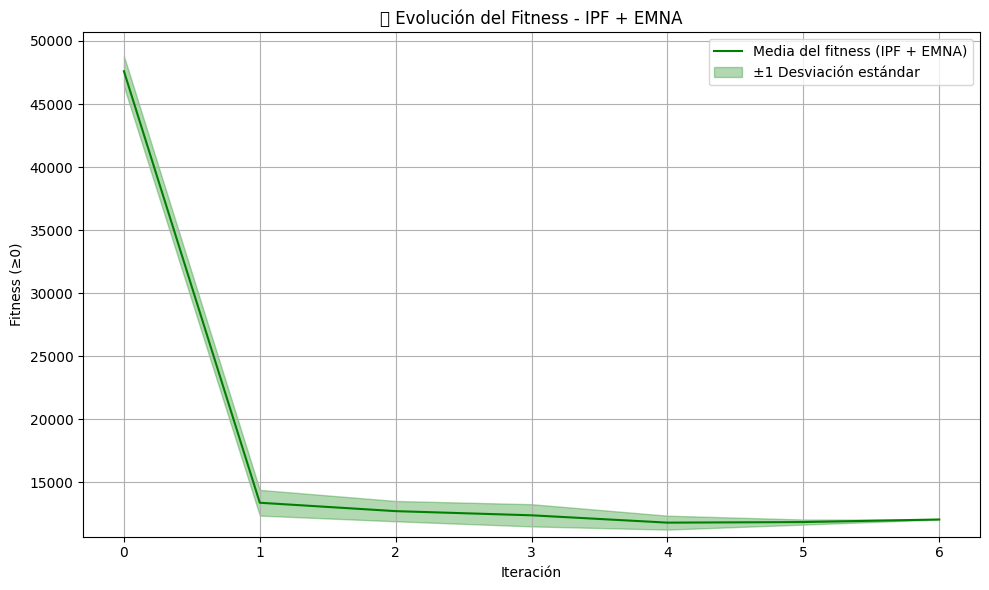

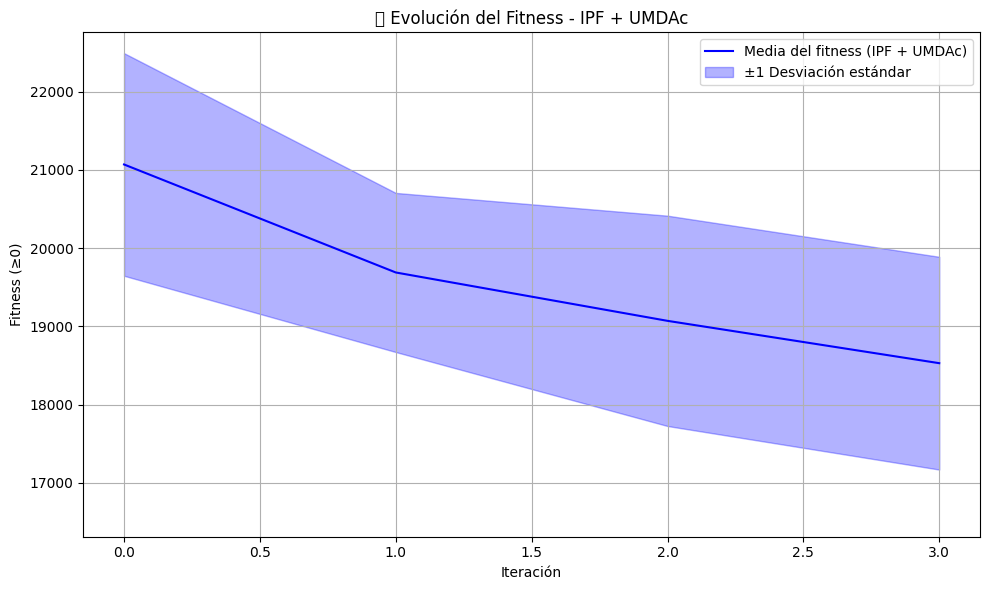

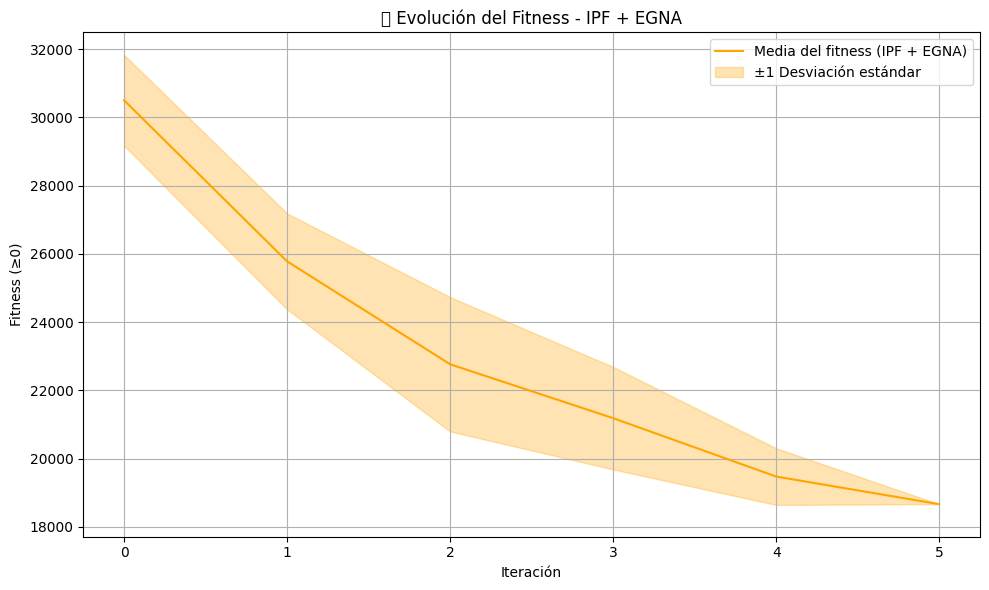

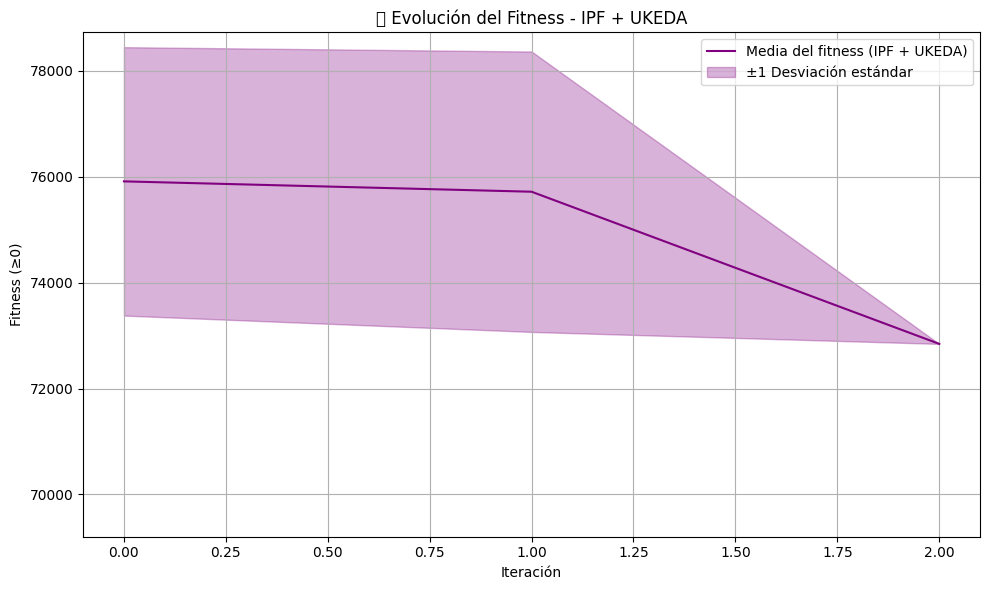

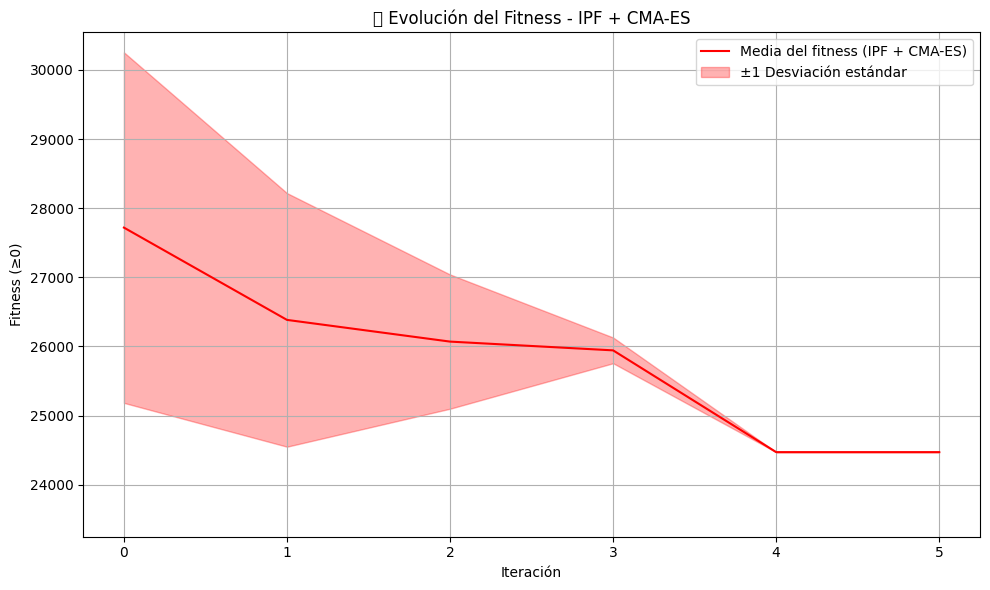

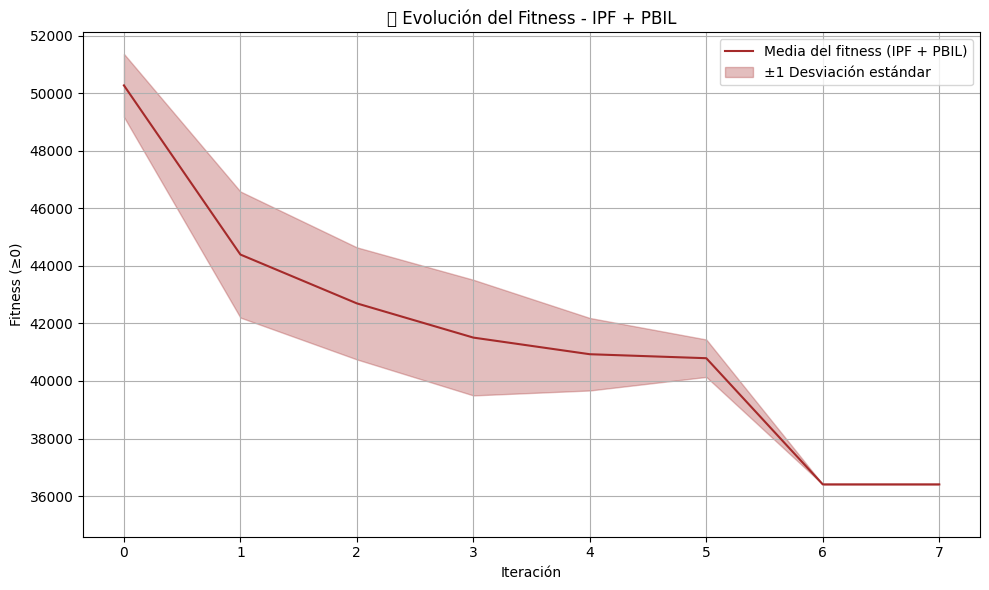

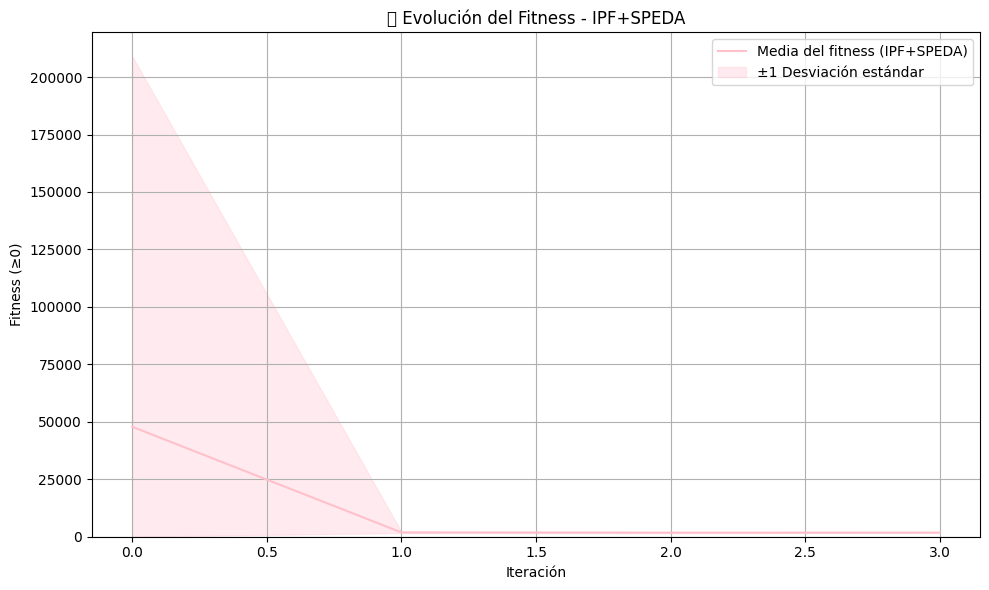

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, cma
from EDAspy.optimization import EMNA, UMDAc, EGNA, UnivariateKEDA

# Parámetros generales
rows, cols = 10, 10
total_sum = np.random.randint(10000, 20000)
num_experiments = 15

# Funciones auxiliares
def generate_initial_matrix(rows, cols):
    return np.random.randint(20, 100, size=(rows, cols))

def generate_margins(rows, cols, total_sum):
    row_margins = np.random.randint(2000, 6000, size=rows)
    row_margins = np.round(row_margins / row_margins.sum() * total_sum).astype(int)
    col_margins = np.random.randint(2000, 6000, size=cols)
    col_margins = np.round(col_margins / col_margins.sum() * total_sum).astype(int)
    row_margins[-1] += total_sum - row_margins.sum()
    col_margins[-1] += total_sum - col_margins.sum()
    return row_margins, col_margins

# Función de normalización
def normalize_matrix(matrix, row_margins, col_margins, max_iter=100):
    matrix = np.maximum(matrix, 1.0)
    for _ in range(max_iter):
        row_sums = matrix.sum(axis=1, keepdims=True)
        matrix *= row_margins[:, None] / (row_sums + 1e-10)
        col_sums = matrix.sum(axis=0, keepdims=True)
        matrix *= col_margins / (col_sums + 1e-10)
    return np.round(matrix).astype(int)

def generate_non_negative_matrix(mean_matrix, std_matrix, max_retries=100):
    rows, cols = mean_matrix.shape
    matrix = np.random.normal(mean_matrix, std_matrix)
    for i in range(rows):
        for j in range(cols):
            retries = 0
            while matrix[i, j] < 0 and retries < max_retries:
                matrix[i, j] = np.random.normal(mean_matrix[i, j], std_matrix[i, j])
                retries += 1
            if matrix[i, j] < 0:
                matrix[i, j] = 0
    return matrix

def combined_penalty(matrix, row_margins, col_margins, initial_matrix, alpha=60, beta=10):
    row_diff = np.abs(np.sum(matrix, axis=1) - row_margins)
    col_diff = np.abs(np.sum(matrix, axis=0) - col_margins)
    margin_penalty = np.sum(row_diff**2) + np.sum(col_diff**2)
    similarity_penalty = np.sum(np.abs(matrix - initial_matrix))
    return alpha * margin_penalty + beta * similarity_penalty

def fitness_function(matrix, row_margins, col_margins, initial_matrix):
    return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

# IPF basado en Deming & Stephan
def iterative_proportional_fitting_deming(matrix, row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=50):
    start_time = time.time()
    matrix = matrix.astype(float)
    best_costs = []  # Lista para almacenar el "best cost" en cada iteración

    for it in range(max_iterations):
        matrix *= (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix *= (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Calcular el "best cost" después de cada iteración
        best_cost = fitness_function(matrix, row_margins, col_margins, initial_matrix)
        best_costs.append(best_cost)

        # Mostrar el costo en cada iteración
        print(f"IT: {it} \tBest cost: {int(best_cost)}")

        # Condición de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            break

    matrix = np.round(matrix).astype(int)
    execution_time = time.time() - start_time
    return matrix, execution_time, best_costs


# Log-verosimilitud
def log_likelihood(matrix, row_margins, col_margins):
    epsilon = 1e-10
    expected = np.outer(row_margins, col_margins) / np.sum(row_margins)
    return np.sum(matrix * np.log((matrix + epsilon) / expected))

# IPF - Feinberg
def iterative_proportional_fitting_feinberg(matrix, row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=50):
    start_time = time.time()
    matrix = matrix.astype(float)
    prev_ll = log_likelihood(matrix, row_margins, col_margins)
    best_costs = []

    for it in range(max_iterations):
        # Ajuste por filas
        matrix *= row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10)

        # Ajuste por columnas
        matrix *= col_margins[None, :] / (matrix.sum(axis=0, keepdims=True) + 1e-10)

        new_ll = log_likelihood(matrix, row_margins, col_margins)
        best_cost = fitness_function(matrix, row_margins, col_margins, initial_matrix)
        best_costs.append(best_cost)

        print(f"[Fienberg] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if abs(new_ll - prev_ll) < tol:
            print("Convergencia alcanzada.")
            break

        prev_ll = new_ll

    execution_time = time.time() - start_time
    return np.round(matrix).astype(int), execution_time, best_costs

# KL divergencia simétrica
def kl_symmetric_divergence(p, q):
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    return np.sum(p * np.log(p / q) + q * np.log(q / p))

# IPF - Rüschendorf con divergencia KL simétrica
def iterative_proportional_fitting_ruschendorf(matrix, row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=50):
    start_time = time.time()
    matrix = matrix.astype(float)
    prev_matrix = matrix.copy()
    best_costs = []

    for it in range(max_iterations):
        # Ajuste por filas
        matrix *= row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10)

        # Ajuste por columnas
        matrix *= col_margins[None, :] / (matrix.sum(axis=0, keepdims=True) + 1e-10)

        # Calcular coste
        best_cost = fitness_function(matrix, row_margins, col_margins, initial_matrix)
        best_costs.append(best_cost)

        print(f"[Rüschendorf] IT: {it + 1} \tBest cost: {int(best_cost)}")

        # Criterio de parada con divergencia KL simétrica
        if kl_symmetric_divergence(matrix, prev_matrix) < tol:
            print("Convergencia alcanzada.")
            break

        prev_matrix = matrix.copy()

    execution_time = time.time() - start_time
    return np.round(matrix).astype(int), execution_time, best_costs

# Función de búsqueda local con ruido
def local_search_with_noise(X, row_margins, col_margins, initial_matrix, alpha=60, beta=10, trials=30, std=0.01):
    rows, cols = len(row_margins), len(col_margins)

    best_X = X.copy()
    best_fitness = combined_penalty(
        normalize_matrix(X.reshape((rows, cols)), row_margins, col_margins),
        row_margins, col_margins, initial_matrix, alpha, beta
    )
    best_perturbed_X = X.copy()
    improved = False

    for _ in range(trials):
        noise = np.random.normal(loc=0, scale=std, size=X.shape)
        perturbed_X = X + X * noise
        matrix = perturbed_X.reshape((rows, cols))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix, alpha, beta)

        if fitness < best_fitness:
            best_fitness = fitness
            best_X = matrix.flatten()
            best_perturbed_X = perturbed_X.copy()
            improved = True

    if improved:
        print("\nMejor 'perturbed_X':")
        print(best_perturbed_X)
        print("\nFitness tras local search':")
        print(best_fitness)
    else:
        print("\nLocal search no mejoró el fitness.")

    return best_X.reshape((rows, cols)), best_fitness, best_perturbed_X.reshape((rows, cols)), improved

# Función para ejecutar EMNA
def run_emna(row_margins, col_margins, dimensions, iterations, initial_matrix):
    emna = EMNA(size_gen=100, max_iter=iterations, dead_iter=10,
                n_variables=dimensions, lower_bound=1, upper_bound=max(row_margins.max(), col_margins.max()))

    def fitness_function(individual):
        matrix = individual.reshape((rows, cols))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()
    result = emna.minimize(fitness_function)
    end_time = time.time()

    best_matrix = result.best_ind.reshape((rows, cols))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Búsqueda local después de EMNA
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix)

    # Si la búsqueda local no mejoró, usar el resultado de EMNA
    if not improved:
        print("\nUsando la matriz de EMNA como la mejor solución.")
        best_matrix_refined = best_matrix

    execution_time = end_time - start_time
    return best_matrix_refined, np.array(result.history), refined_fitness, execution_time, best_perturbed_matrix


def iterative_proportional_fitting_plus_emna(matrix, row_margins, col_margins, initial_matrix, iterations=10, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)


def iterative_proportional_fitting_plus_emna(matrix, row_margins, col_margins, initial_matrix, iterations=10, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con EMNA: Usamos la matriz de IPF como base
        refined_matrix, history, refined_fitness, execution_time_emna, _ = run_emna(row_margins, col_margins, matrix.size, 10, matrix)

        # Compara la solución refinada con la mejor solución global (de IPF y EMNA)
        if refined_fitness < best_fitness_so_far:
            # Si EMNA mejora, actualizamos la mejor matriz y su coste
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si EMNA no mejora, mantenemos la solución de IPF
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far  # No se cambia el fitness, seguimos con IPF

        # Criterio de parada: si la diferencia entre costes consecutivos es menor que la tolerancia, parar
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("  Diferencia menor que tolerancia. Parando.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Devolvemos la mejor matriz encontrada, su tiempo de ejecución y los costes (para el análisis)
    return np.round(best_matrix_so_far).astype(int), execution_time, best_costs


# UMDAc (Estimación de distribución con variables categóricas)
def run_umdac(row_margins, col_margins, dimensions, iterations, initial_matrix):
    umdac = UMDAc(size_gen=100, max_iter=iterations, dead_iter=10,
                  n_variables=dimensions, lower_bound=1, upper_bound=max(row_margins.max(), col_margins.max()))

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))  # Reshape del individuo en la forma de la matriz
        matrix = normalize_matrix(matrix, row_margins, col_margins)  # Normalización de la matriz
        return np.sum(combined_penalty(matrix, row_margins, col_margins, initial_matrix))  # Sumar la penalización

    # Ejecución de UMDAc
    start_time = time.time()
    result = umdac.minimize(fitness_function)  # Minimización con UMDAc
    end_time = time.time()

    # Mejor solución encontrada
    best_matrix = result.best_ind.reshape((len(row_margins), len(col_margins)))  # Reshape de la mejor solución
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)  # Normalización de la mejor solución

    best_matrix = result.best_ind.reshape((rows, cols))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Búsqueda local después de UMDAc
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix)

    # Si la búsqueda local no mejoró, usar el resultado de UMDAc
    if not improved:
        print("\nUsando la matriz de UMDAc como la mejor solución.")
        best_matrix_refined = best_matrix

    # Tiempo de ejecución
    execution_time = end_time - start_time

    #Fitness IPF+UMDAc
    final_fitness = combined_penalty(best_matrix, row_margins, col_margins, initial_matrix)

    # Retornar la mejor matriz, el historial de resultados y el tiempo de ejecución
    return best_matrix, np.array(result.history), execution_time


def iterative_proportional_fitting_plus_umdac(matrix, row_margins, col_margins, initial_matrix, iterations=10, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializar con la matriz original
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con UMDAc
        refined_matrix, fitness_history, execution_time_umdac = run_umdac(row_margins, col_margins, matrix.size, 20, matrix)
        refined_fitness = fitness_history[-1]  # Tomamos el fitness final

        # Comparación global
        if refined_fitness < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            best_costs.append(best_fitness_so_far)

        # Parada temprana si no hay mejora significativa
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("  Diferencia menor que tolerancia. Parando.")
            break

    end_time = time.time()
    execution_time = end_time - start_time
    return np.round(best_matrix_so_far).astype(int), execution_time, best_costs



def run_egna(row_margins, col_margins, dimensions, iterations, initial_matrix):
    egna = EGNA(size_gen=100, max_iter=iterations, dead_iter=10, n_variables=dimensions, lower_bound=1,
                upper_bound=max(row_margins.max(), col_margins.max()))

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()
    result = egna.minimize(fitness_function)
    end_time = time.time()

    best_matrix = result.best_ind.reshape((len(row_margins), len(col_margins)))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Local search con ruido
    best_matrix_refined, refined_fitness, _, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix
    )

    if not improved:
        print("\nUsando la matriz de EGNA como la mejor solución.")
        best_matrix_refined = best_matrix
        refined_fitness = combined_penalty(best_matrix_refined, row_margins, col_margins, initial_matrix)

    execution_time = end_time - start_time
    return best_matrix_refined, np.array(result.history), refined_fitness, execution_time



def iterative_proportional_fitting_plus_egna(matrix, row_margins, col_margins, initial_matrix, iterations=10, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # EGNA: se usa la matriz de IPF como punto de partida
        refined_matrix, fitness_history, refined_fitness, execution_time_egna = run_egna(
            row_margins, col_margins, matrix.size, 20, matrix)


        # Si EGNA mejora, actualizamos la mejor matriz y su coste
        if refined_fitness < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos lo anterior
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far

        # Criterio de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("  Diferencia menor que tolerancia. Parando.")
            break

    end_time = time.time()
    return np.round(best_matrix_so_far).astype(int), end_time - start_time, best_costs


def run_ukeda(row_margins, col_margins, dimensions, iterations, initial_matrix):
    ukeda = UnivariateKEDA(size_gen=350, max_iter=iterations, dead_iter=10,
        n_variables=dimensions, lower_bound=1, upper_bound=max(row_margins.max(), col_margins.max()))

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()
    result = ukeda.minimize(fitness_function)
    end_time = time.time()

    best_matrix = result.best_ind.reshape((len(row_margins), len(col_margins)))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    best_matrix_refined, refined_fitness, _, improved = local_search_with_noise(
        result.best_ind, row_margins, col_margins, initial_matrix)

    if not improved:
        print("\nUsando la matriz de UKEDA (sin mejora en búsqueda local).")
        best_matrix_refined = best_matrix
        refined_fitness = fitness_function(result.best_ind)

    execution_time = end_time - start_time
    return best_matrix_refined, np.array(result.history), refined_fitness, execution_time


# IPF clásico con UKEDA
def iterative_proportional_fitting_plus_ukeda(matrix, row_margins, col_margins, initial_matrix, iterations=10, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # UKEDA: se usa la matriz de IPF como punto de partida
        refined_matrix, fitness_history, refined_fitness, execution_time_ukeda = run_ukeda(
            row_margins, col_margins, matrix.size, 20, matrix)

        # Si UKEDA mejora, actualizamos la mejor matriz y su coste
        if refined_fitness < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos lo anterior
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far

        # Criterio de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("  Diferencia menor que tolerancia. Parando.")
            break

    end_time = time.time()
    return np.round(best_matrix_so_far).astype(int), end_time - start_time, best_costs

# PBIL continuo con búsqueda local
def run_pbil_continuous(row_margins, col_margins, dimensions, iterations, initial_matrix,
                        size_gen=100, learning_rate=0.01):
    n_variables = dimensions
    n_rows, n_cols = len(row_margins), len(col_margins)

    lower_bound = np.ones(n_variables)
    upper_bound = np.full(n_variables, max(np.max(row_margins), np.max(col_margins)))

    # Vector de probabilidad inicial (valor medio dentro del rango)
    prob_vector = (upper_bound + lower_bound) / 2.0
    std_dev = (upper_bound - lower_bound) / 6  # Supone 99.7% dentro del rango en una normal

    best_fitness = float('inf')
    best_solution = None
    fitness_history = []

    def fitness_function(individual):
        matrix = individual.reshape((n_rows, n_cols))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()

    for iter in range(iterations):
        # Generar población a partir de una distribución normal centrada en prob_vector
        population = np.random.normal(loc=prob_vector, scale=std_dev, size=(size_gen, n_variables))
        population = np.clip(population, lower_bound, upper_bound)

        # Evaluar fitness
        fitness_values = np.array([fitness_function(ind) for ind in population])
        best_idx = np.argmin(fitness_values)
        best_individual = population[best_idx]

        # Actualizar mejor solución
        if fitness_values[best_idx] < best_fitness:
            best_fitness = fitness_values[best_idx]
            best_solution = best_individual.copy()

        # Actualizar vector de probabilidad hacia el mejor individuo
        prob_vector = (1 - learning_rate) * prob_vector + learning_rate * best_individual

        # Guardar historial
        fitness_history.append(best_fitness)

        # Mostrar progreso
        print(f"Iteración {iter+1}/{iterations} - Mejor Costo: {best_fitness:.4f}")

    # Búsqueda local después de PBIL
    best_matrix_refined, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        best_solution, row_margins, col_margins, initial_matrix)

    if improved:
        print("\nSe mejoró la solución con búsqueda local.")
    else:
        print("\nLa búsqueda local no mejoró la solución de PBIL. Usando la mejor solución original.")
        best_matrix_refined = best_solution.reshape((n_rows, n_cols))
        best_matrix_refined = normalize_matrix(best_matrix_refined, row_margins, col_margins)

    end_time = time.time()
    execution_time = end_time - start_time
    print(f"Tiempo total de ejecución PBIL + Local Search: {execution_time:.2f} segundos")

    return initial_matrix, best_matrix_refined, fitness_history


def iterative_proportional_fitting_plus_pbil(matrix, row_margins, col_margins, initial_matrix, iterations=20, tol=1e-6):
    # Asegúrate de que la matriz sea de tipo float
    matrix = matrix.astype(float)

    best_costs = []  # Lista para almacenar los mejores costos durante las iteraciones
    best_cost = float('inf')  # Inicialización del mejor costo
    start_time = time.time()  # Registro del tiempo de inicio

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con PBIL
        initial_matrix_result, refined_matrix, fitness_history = run_pbil_continuous(row_margins, col_margins, matrix.size, 20, matrix)  # Refinamiento con PBIL

        # El coste final de PBIL se extrae del historial de ejecuciones
        new_cost = fitness_history[-1]

        # Si el nuevo costo es mejor, actualizamos la matriz y el costo
        if new_cost < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = new_cost
        # Si el costo no mejora, mantenemos la solución anterior
        else:
            print(f"No mejora el costo en la iteración {it}")

        best_costs.append(best_fitness_so_far)  # Registramos el mejor costo de esta iteración

        # Impresión del progreso
        print(f"IPF Iteración {it}: Best cost = {int(best_fitness_so_far)}")

        # Criterio de parada: si el cambio en el costo es menor que la tolerancia, se detiene
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Criterio de parada alcanzado: Convergencia")
            break

    # Redondear la matriz final y convertirla a tipo entero
    matrix = np.round(best_matrix_so_far).astype(int)
    execution_time = time.time() - start_time  # Calcular el tiempo total de ejecución

    return matrix, execution_time, best_costs

# Función de optimización con CMA-ES
def run_cma_es(row_margins, col_margins, dimensions, iterations, initial_matrix):
    # Inicialización de CMA-ES
    x0 = initial_matrix.flatten()
    sigma = 50  # Desviación estándar inicial
    es = cma.CMAEvolutionStrategy(x0, sigma)

    # Historial de resultados
    history = []
    best_overall_cost = float('inf')
    best_solution = None

    def fitness_function(individual):
        matrix = individual.reshape((len(row_margins), len(col_margins)))
        matrix = normalize_matrix(matrix, row_margins, col_margins)
        return combined_penalty(matrix, row_margins, col_margins, initial_matrix)

    start_time = time.time()

    # Ejecución de iteraciones
    for i in range(iterations):
        solutions = es.ask()
        fitness_values = [fitness_function(sol) for sol in solutions]
        es.tell(solutions, fitness_values)

        gen_best_cost = min(fitness_values)
        history.append(gen_best_cost)

        if gen_best_cost < best_overall_cost:
            best_overall_cost = gen_best_cost
            best_solution = solutions[fitness_values.index(gen_best_cost)]

        print(f"Iteración {i+1}: Best Cost = {best_overall_cost}")

    end_time = time.time()

    # Mejor matriz del CMA-ES
    best_matrix = best_solution.reshape((len(row_margins), len(col_margins)))
    best_matrix = normalize_matrix(best_matrix, row_margins, col_margins)

    # Aplicar búsqueda local sobre la mejor solución
    best_matrix_refined, refined_fitness, _, improved = local_search_with_noise(
        best_solution, row_margins, col_margins, initial_matrix
    )

    if improved:
        print("\nSe mejoró la solución con búsqueda local.")
        best_matrix = best_matrix_refined
        best_overall_cost = refined_fitness
    else:
        print("\nLa búsqueda local no mejoró la solución de CMA-ES.")

    execution_time = end_time - start_time

    return best_matrix, history, execution_time

def iterative_proportional_fitting_plus_cma_es(matrix, row_margins, col_margins, initial_matrix, iterations=20, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    # Asegurarnos de que el coste no sea infinito
    if np.isinf(best_fitness_so_far):
        print("Error: El coste inicial es infinito, ajustando a un valor muy grande.")
        best_fitness_so_far = 1e10  # O algún valor adecuado para evitar infinito

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # CMA-ES: se usa la matriz de IPF como punto de partida
        refined_matrix, fitness_history, execution_time = run_cma_es(row_margins, col_margins, matrix.shape, 20, matrix)

        refined_fitness = fitness_history[-1]

        # Si CMA-ES mejora, actualizamos la mejor matriz y su coste
        if refined_fitness < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos lo anterior
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far

        # Criterio de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("  Diferencia menor que tolerancia. Parando.")
            break

    end_time = time.time()
    return np.round(best_matrix_so_far).astype(int), end_time - start_time, best_costs


# SPEDA (versión simplificada)
def speda_optimization(base_matrix, row_margins, col_margins, initial_matrix,
                       population_size=100, num_generations=20, elite_size=10, alpha=0.7, noise_level=5):
    rows, cols = base_matrix.shape

    current_population = [generate_non_negative_matrix(base_matrix, np.full_like(base_matrix, noise_level))
                          for _ in range(population_size)]

    history = []
    best_fitness_ever = float('inf')
    best_matrix_ever = None

    for gen in range(num_generations):
        fitness_scores = [
            combined_penalty(np.round(ind).astype(int), row_margins, col_margins, initial_matrix)
            for ind in current_population
        ]

        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)

        mean_elite = np.mean(elite_array, axis=0)
        std_elite = np.std(elite_array, axis=0)

        base_matrix = alpha * base_matrix + (1 - alpha) * mean_elite

        current_population = [generate_non_negative_matrix(base_matrix, std_elite)
                              for _ in range(population_size)]

        current_best_fitness = np.min(fitness_scores)
        current_best_index = np.argmin(fitness_scores)
        current_best_matrix = np.round(current_population[current_best_index]).astype(int)

        if current_best_fitness < best_fitness_ever:
            best_fitness_ever = current_best_fitness
            best_matrix_ever = current_best_matrix.copy()

        print(f"SPEDA Generación {gen+1}: Mejor fitness hasta ahora = {int(best_fitness_ever)}")
        history.append(best_fitness_ever)

    # Búsqueda local después de SPEDA
    best_vector = best_matrix_ever.flatten()
    refined_matrix, refined_fitness, best_perturbed_matrix, improved = local_search_with_noise(
        best_vector, row_margins, col_margins, initial_matrix
    )

    if improved:
        print("\nSe mejoró la solución con búsqueda local.")
        best_matrix_ever = refined_matrix
        history.append(refined_fitness)
    else:
        print("\nLa búsqueda local no mejoró la solución de SPEDA.")

    return best_matrix_ever, np.array(history)

def iterative_proportional_fitting_plus_speda(matrix, row_margins, col_margins, initial_matrix, iterations=10, tol=1e-6):
    best_costs = []
    start_time = time.time()

    # Inicializamos la mejor matriz y su coste
    best_matrix_so_far = matrix.copy()
    best_fitness_so_far = combined_penalty(best_matrix_so_far, row_margins, col_margins, initial_matrix)

    for it in range(iterations):
        # Usar la mejor matriz encontrada hasta ahora como punto de partida
        matrix = best_matrix_so_far.copy()

        # Paso IPF: Actualizamos la matriz utilizando los márgenes
        matrix = matrix * (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix = matrix * (col_margins / (matrix.sum(axis=0) + 1e-10))

        # Evaluación después de IPF
        current_fitness = combined_penalty(matrix, row_margins, col_margins, initial_matrix)

        # Ahora actualizamos el mejor fitness y mejor matriz si IPF mejora el mejor actual
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_matrix_so_far = matrix.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # SPEDA: se usa la matriz de IPF como punto de partida
        refined_matrix, fitness_history = speda_optimization(
            np.round(matrix).astype(int),row_margins,col_margins,matrix)

        refined_fitness = fitness_history[-1]

        # Si SPEDA mejora, actualizamos la mejor matriz y su coste
        if refined_fitness < best_fitness_so_far:
            best_matrix_so_far = refined_matrix.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos lo anterior
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far

        # Criterio de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("  Diferencia menor que tolerancia. Parando.")
            break

    end_time = time.time()
    return np.round(best_matrix_so_far).astype(int), end_time - start_time, best_costs


# Almacenar resultados
best_costs_ipf, times_ipf  = [], []
best_costs_fienberg, times_fienberg = [], []
best_costs_ruschendorf, times_ruschendorf = [], []

best_costs_emna, times_emna = [], []
best_costs_umdac, times_umdac = [], []
best_costs_egna, times_egna = [], []
best_costs_ukeda, times_ukeda = [], []
best_costs_cmaes, times_cmaes = [], []
best_costs_pbil, times_pbil = [], []
best_costs_speda, times_speda = [], []

all_histories_emna, all_histories_umdac, all_histories_egna = [], [], []
all_histories_ukeda, all_histories_cmaes, all_histories_pbil= [], [], []
all_histories_speda = []

final_fitness_values = []
all_times = []

# Inicialización fija para todos los experimentos
initial_matrix = generate_initial_matrix(rows, cols)
row_margins, col_margins = generate_margins(rows, cols, total_sum)

print("\n🔹 Matriz Inicial:")
print(initial_matrix)
print("\n🔹 Márgenes de filas:")
print(row_margins)
print("\n🔹 Márgenes de columnas:")
print(col_margins)

# Repetir experimento
for i in range(num_experiments):
    print(f"\n🔹 Ejecutando experimento {i+1}/{num_experiments}...")

    # IPF basado en Deming & Stephan
    optimized_matrix_ipf, time_ipf, costs_ipf = iterative_proportional_fitting_deming(
        initial_matrix, row_margins, col_margins, initial_matrix
    )
    best_costs_ipf.append(costs_ipf[-1])
    times_ipf.append(time_ipf)
    print(f"📌 IPF basado en Deming & Stephan - Fitness final: {costs_ipf[-1]:.2f}, Tiempo: {time_ipf:.2f}s")

    # IPF basado en Feinberg
    optimized_matrix_fienberg, time_fienberg, costs_fienberg = iterative_proportional_fitting_feinberg(
        initial_matrix, row_margins, col_margins, initial_matrix
    )
    best_costs_fienberg.append(costs_fienberg[-1])
    times_fienberg.append(time_fienberg)
    print(f"📌 IPF basado en Feinberg - Fitness final: {costs_fienberg[-1]:.2f}, Tiempo: {time_fienberg:.2f}s")

    # IPF basado en Rüschendorf
    optimized_matrix_ruschendorf, time_ruschendorf, costs_ruschendorf = iterative_proportional_fitting_ruschendorf(
        initial_matrix, row_margins, col_margins, initial_matrix
    )
    best_costs_ruschendorf.append(costs_ruschendorf[-1])
    times_ruschendorf.append(time_ruschendorf)
    print(f"📌 IPF basado en Rüschendorf - Fitness final: {costs_ruschendorf[-1]:.2f}, Tiempo: {time_ruschendorf:.2f}s")

    # Ejecutar IPF + UnivariateKEDA
    optimized_matrix_keda, time_keda, costs_keda = iterative_proportional_fitting_plus_ukeda(
        initial_matrix, row_margins, col_margins, initial_matrix  # Cambié la función aquí
    )
    best_costs_ukeda.append(costs_keda[-1])  # Guardar el último valor de fitness
    times_ukeda.append(time_keda)
    all_histories_ukeda.append(costs_keda)
    print(f"📌 IPF + UnivariateKEDA - Fitness final: {costs_keda[-1]:.2f}, Tiempo: {time_keda:.2f}s")

    # Ejecutar IPF + EGNA
    optimized_matrix_egna, time_egna, costs_egna = iterative_proportional_fitting_plus_egna(
        initial_matrix, row_margins, col_margins, initial_matrix
    )
    best_costs_egna.append(costs_egna[-1])  # Guardar el último valor de fitness
    times_egna.append(time_egna)
    all_histories_egna.append(costs_egna)
    print(f"📌 IPF + EGNA - Fitness final: {costs_egna[-1]:.2f}, Tiempo: {time_egna:.2f}s")

    # IPF + EMNA
    optimized_matrix_emna, time_emna, costs_emna = iterative_proportional_fitting_plus_emna(
        initial_matrix, row_margins, col_margins, initial_matrix
    )
    best_costs_emna.append(costs_emna[-1])
    times_emna.append(time_emna)
    all_histories_emna.append(costs_emna)
    print(f"📌 IPF + EMNA - Fitness final: {costs_emna[-1]:.2f}, Tiempo: {time_emna:.2f}s")

    # IPF + UMDAc
    optimized_matrix_umdac, time_umdac, costs_umdac = iterative_proportional_fitting_plus_umdac(
        initial_matrix, row_margins, col_margins, initial_matrix
    )
    best_costs_umdac.append(costs_umdac[-1])
    times_umdac.append(time_umdac)
    all_histories_umdac.append(costs_umdac)
    print(f"📌 IPF + UMDAc - Fitness final: {costs_umdac[-1]:.2f}, Tiempo: {time_umdac:.2f}s")

    # Ejecutar IPF + CMA-ES
    optimized_matrix_cmaes, time_cmaes, costs_cmaes = iterative_proportional_fitting_plus_cma_es(
        initial_matrix, row_margins, col_margins, initial_matrix
    )
    best_costs_cmaes.append(costs_cmaes[-1])  # Último fitness
    times_cmaes.append(time_cmaes)
    all_histories_cmaes.append(costs_cmaes)
    final_fitness_values.append(costs_cmaes[-1])
    all_times.append(time_cmaes)
    print(f"📌 IPF + CMA-ES - Fitness final: {costs_cmaes[-1]:.2f}, Tiempo: {time_cmaes:.2f}s")

    # Ejecutar IPF + PBIL
    optimized_matrix_pbil, time_pbil, costs_pbil = iterative_proportional_fitting_plus_pbil(
        initial_matrix, row_margins, col_margins, initial_matrix
    )
    best_costs_pbil.append(costs_pbil[-1])  # Guardar el último valor de fitness
    times_pbil.append(time_pbil)
    all_histories_pbil.append(costs_pbil)
    print(f"📌 IPF + PBIL - Fitness final: {costs_pbil[-1]:.2f}, Tiempo: {time_pbil:.2f}s")

    # Ejecutar IPF + SPEDA
    optimized_matrix_speda, time_speda, costs_speda = iterative_proportional_fitting_plus_speda(
        initial_matrix, row_margins, col_margins, initial_matrix
    )
    best_costs_speda.append(costs_speda[-1])  # Guardar el último valor de fitness
    times_speda.append(time_speda)
    all_histories_speda.append(costs_speda)
    print(f"📌 IPF + SPEDA - Fitness final: {costs_speda[-1]:.2f}, Tiempo: {time_speda:.2f}s")


# Mostrar resumen final
df_resultados = pd.DataFrame({
    "Experimento": np.arange(1, num_experiments+1),
    "IPF (Deming)": best_costs_ipf,
    "IPF (Feinberg)": best_costs_fienberg,
    "IPF (Rüschendorf)": best_costs_ruschendorf,
    "IPF+EMNA": best_costs_emna,
    "IPF+UMDAc": best_costs_umdac,
    "IPF+EGNA": best_costs_egna,
    "IPF+UKEDA": best_costs_ukeda,
    "IPF+CMA-ES": best_costs_cmaes,
    "IPF+PBIL": best_costs_pbil,
    "IPF+SPEDA": best_costs_speda
})

# Graficar resultados de comparación de fitness
plt.figure(figsize=(12, 6))

# IPF base con línea discontinua y colores específicos
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Deming)"], label="IPF (Deming)", marker='o', linestyle='--', color='#1f77b4')
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Feinberg)"], label="IPF (Feinberg)", marker='x', linestyle='--', color='#ff7f0e')
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Rüschendorf)"], label="IPF (Rüschendorf)", marker='s', linestyle='--', color='#2ca02c')

# Métodos híbridos con línea sólida y colores específicos
plt.plot(df_resultados["Experimento"], df_resultados["IPF+EMNA"], label="IPF+EMNA", marker='d', linestyle='-', color='#d62728')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+UMDAc"], label="IPF+UMDAc", marker='^', linestyle='-', color='#9467bd')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+EGNA"], label="IPF+EGNA", marker='v', linestyle='-', color='#8c564b')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+UKEDA"], label="IPF+UKEDA", marker='<', linestyle='-', color='#e377c2')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+CMA-ES"], label="IPF+CMA-ES", marker='p', linestyle='-', color='#7f7f7f')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+PBIL"], label="IPF+PBIL", marker='*', linestyle='-', color='#bcbd22')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+SPEDA"], label="IPF+SPEDA", marker='h', linestyle='-', color='#17becf')


plt.xlabel("Experimentos")
plt.ylabel("Fitness Final")
plt.title("🔍 Comparación de Algoritmos: IPF vs IPF+EDAS 2DIM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 🧾 Mostrar resultados tabulares
print("\n🔹 Resultados Finales por Experimento:")
print(df_resultados.round(4))

# Lista de todas las historias y etiquetas
all_histories = [all_histories_emna, all_histories_umdac, all_histories_egna, all_histories_ukeda,
                 all_histories_cmaes, all_histories_pbil, all_histories_speda]

labels = ["IPF + EMNA","IPF + UMDAc", "IPF + EGNA", "IPF + UKEDA", "IPF + CMA-ES", "IPF + PBIL", "IPF+SPEDA"]

colors = ['green', 'blue', 'orange', 'purple', 'red', 'brown', 'pink']

for history_list, label, color in zip(all_histories, labels, colors):
    max_len = max(len(h) for h in history_list)
    history_array = np.array([np.pad(h, (0, max_len - len(h)), constant_values=np.nan) for h in history_list])

    mean_fitness = np.nanmean(history_array, axis=0)
    std_fitness = np.nanstd(history_array, axis=0)

    lower_bound = np.nanmin(mean_fitness - std_fitness)
    ylim_bottom = 0 if lower_bound < 0 else lower_bound * 0.95  # Ajuste dinámico

    plt.figure(figsize=(10, 6))
    plt.plot(mean_fitness, label=f'Media del fitness ({label})', color=color)
    plt.fill_between(range(max_len),
                     np.maximum(0, mean_fitness - std_fitness),
                     mean_fitness + std_fitness,
                     color=color, alpha=0.3, label='±1 Desviación estándar')
    plt.ylim(bottom=ylim_bottom)
    plt.title(f'📉 Evolución del Fitness - {label}')
    plt.xlabel('Iteración')
    plt.ylabel('Fitness (≥0)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



<ipython-input-19-8fd633f5a4f8>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x="Algoritmo", y="Costo final", palette="Set3")


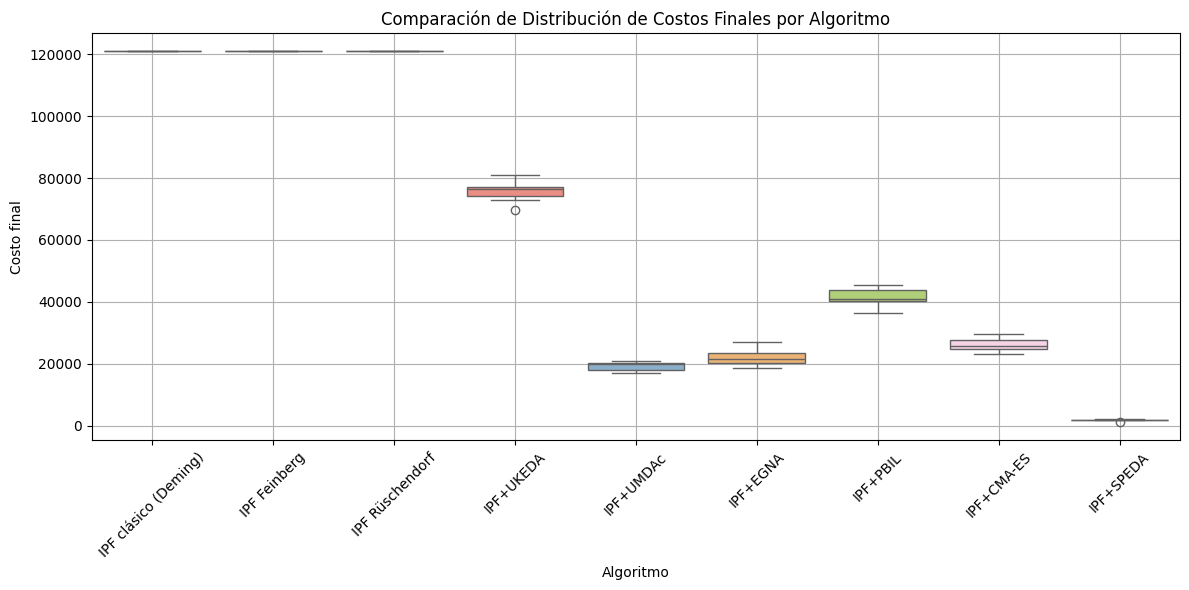

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Usar los nombres definidos en tu experimento
data = {
    "IPF clásico (Deming)": best_costs_ipf,
    "IPF Feinberg": best_costs_fienberg,
    "IPF Rüschendorf": best_costs_ruschendorf,
    "IPF+UKEDA": best_costs_ukeda,
    "IPF+UMDAc": best_costs_umdac,
    "IPF+EGNA": best_costs_egna,
    "IPF+PBIL": best_costs_pbil,
    "IPF+CMA-ES": best_costs_cmaes,
    "IPF+SPEDA": best_costs_speda
}

df = pd.DataFrame(data)
df_melted = df.melt(var_name="Algoritmo", value_name="Costo final")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x="Algoritmo", y="Costo final", palette="Set3")
plt.title("Comparación de Distribución de Costos Finales por Algoritmo")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-20-e150c5d90390>:41: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


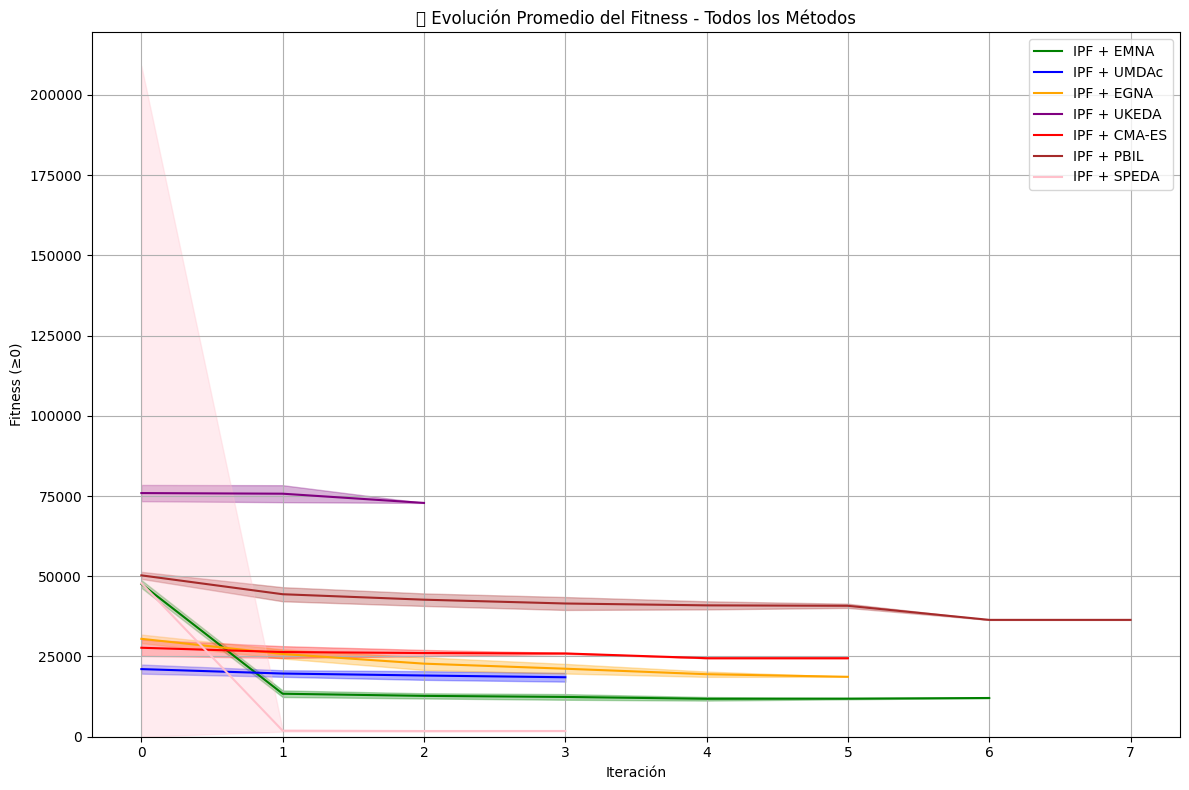

In [ ]:
# Lista de historias, etiquetas y colores
all_histories = [all_histories_emna, all_histories_umdac, all_histories_egna, all_histories_ukeda,
                 all_histories_cmaes, all_histories_pbil, all_histories_speda]

labels = ["IPF + EMNA", "IPF + UMDAc", "IPF + EGNA", "IPF + UKEDA", "IPF + CMA-ES", "IPF + PBIL", "IPF + SPEDA"]

colors = ['green', 'blue', 'orange', 'purple', 'red', 'brown', 'pink']

# Crear la figura antes del bucle
plt.figure(figsize=(12, 8))

# Rango inferior mínimo global para ajustar el eje y
global_min = float('inf')

for history_list, label, color in zip(all_histories, labels, colors):
    max_len = max(len(h) for h in history_list)
    history_array = np.array([np.pad(h, (0, max_len - len(h)), constant_values=np.nan) for h in history_list])

    mean_fitness = np.nanmean(history_array, axis=0)
    std_fitness = np.nanstd(history_array, axis=0)

    lower_bound = np.nanmin(mean_fitness - std_fitness)
    global_min = min(global_min, lower_bound)

    plt.plot(mean_fitness, label=f'{label}', color=color)
    plt.fill_between(range(max_len),
                     np.maximum(0, mean_fitness - std_fitness),
                     mean_fitness + std_fitness,
                     color=color, alpha=0.3)

# Ajustar eje Y dinámicamente
ylim_bottom = 0 if global_min < 0 else global_min * 0.95
plt.ylim(bottom=ylim_bottom)

# Etiquetas y formato
plt.title("📉 Evolución Promedio del Fitness - Todos los Métodos")
plt.xlabel("Iteración")
plt.ylabel("Fitness (≥0)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# PRUEBAS IPF vs IPF+EDAs 3 DIM

Se han truncado las últimas 5000 líneas del flujo de salida.
  [40.84048297 41.3551511  27.31682261 28.07215893 36.27408789
   28.75843032 29.00056835 35.05900029 33.83248648 33.24558989]]

 [[32.88060301 38.73445634 32.32653035 30.82091839 32.9325478
   29.37862621 32.67431644 38.46508146 31.20692215 32.65165192]
  [35.77453637 28.22555474 24.53728492 27.51211341 24.96021063
   30.12838305 26.13047224 28.75052398 27.60368659 26.92508213]
  [34.01600476 38.42093814 32.44262746 30.46471391 29.2041933
   36.19123897 31.03412533 33.87276432 35.16548855 29.92127401]
  [32.03341853 35.27765374 21.71583688 28.27542174 25.22397671
   31.90832617 27.73381738 30.90777195 30.80788825 30.43470058]
  [31.66517571 43.94088302 27.69683031 26.69930214 27.60626912
   30.34946464 29.8677534  32.7235711  31.11384567 28.83289627]
  [34.31236337 38.5435115  31.42396954 29.82334239 29.46309564
   31.65949551 32.64300929 30.86319727 30.93337527 34.91491303]
  [36.63600476 36.44541091 28.62455911 26.75117532

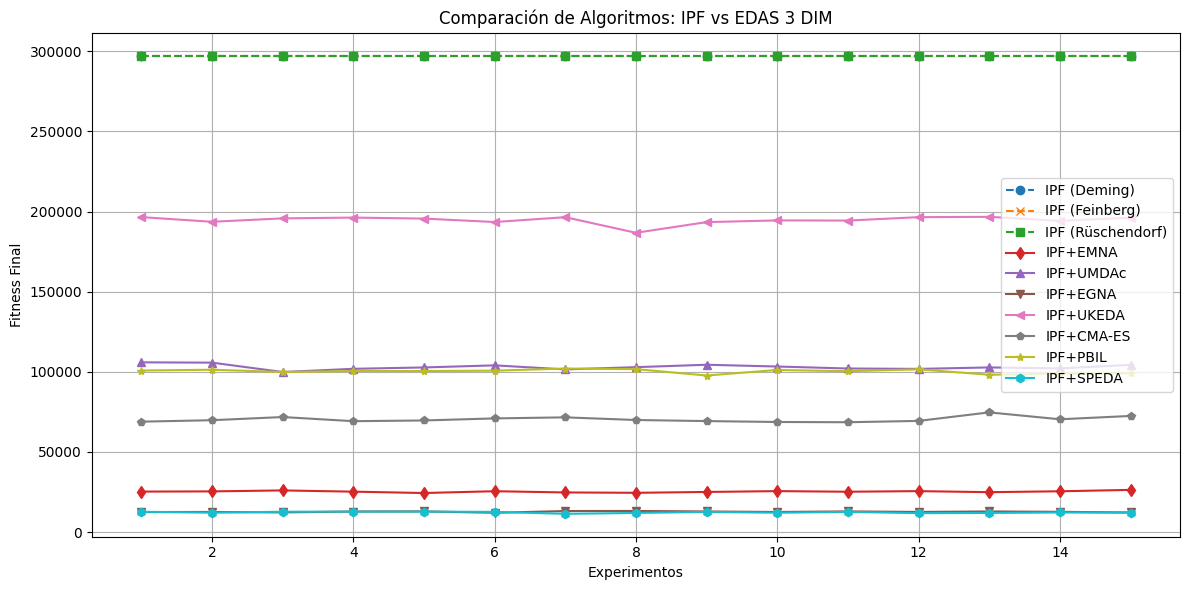


🔹 Resultados Finales por Experimento:
    Experimento  IPF (Deming)  IPF (Feinberg)  IPF (Rüschendorf)    IPF+EMNA  \
0             1      297250.0        297250.0           297250.0  25252.2585   
1             2      297250.0        297250.0           297250.0  25382.0315   
2             3      297250.0        297250.0           297250.0  25987.8324   
3             4      297250.0        297250.0           297250.0  25213.9684   
4             5      297250.0        297250.0           297250.0  24365.8604   
5             6      297250.0        297250.0           297250.0  25489.7949   
6             7      297250.0        297250.0           297250.0  24720.2629   
7             8      297250.0        297250.0           297250.0  24499.9646   
8             9      297250.0        297250.0           297250.0  25027.1058   
9            10      297250.0        297250.0           297250.0  25551.8358   
10           11      297250.0        297250.0           297250.0  25166.9019   
1

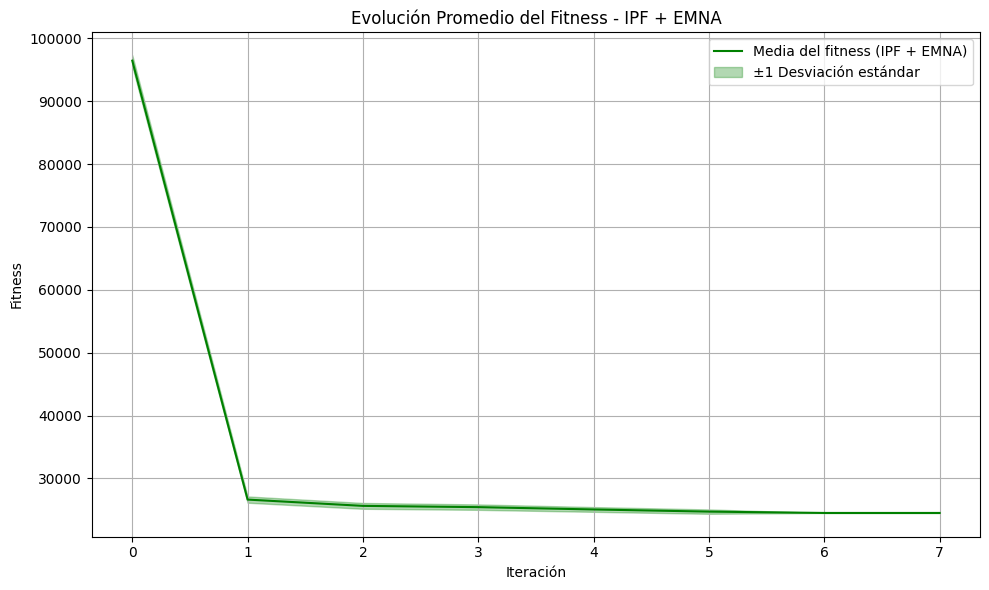

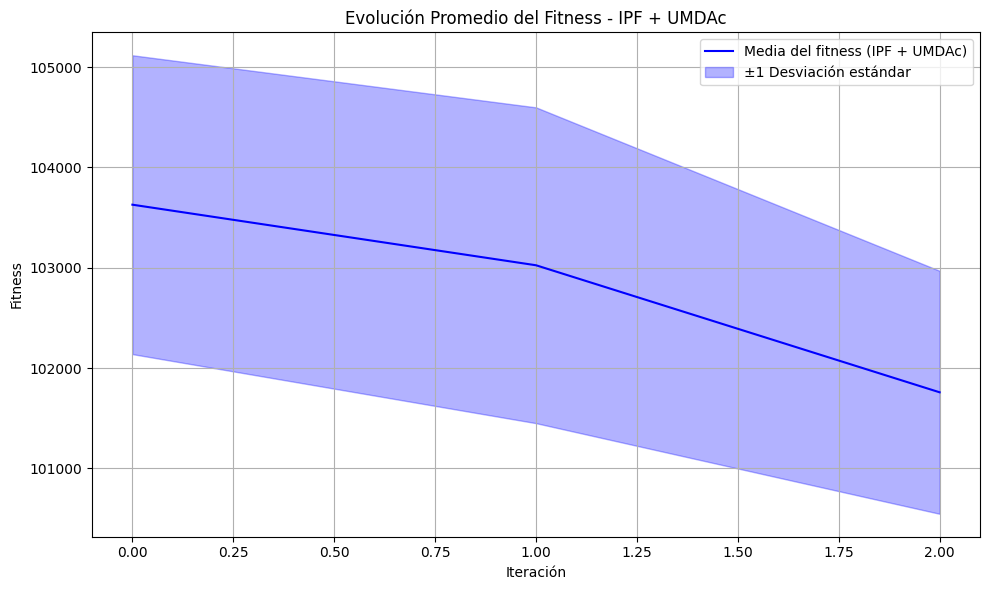

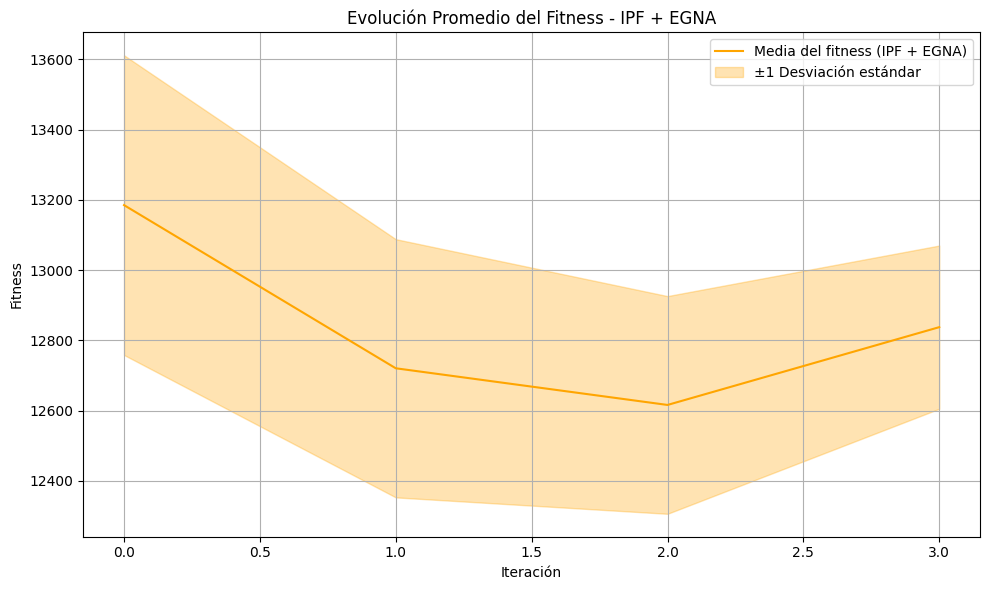

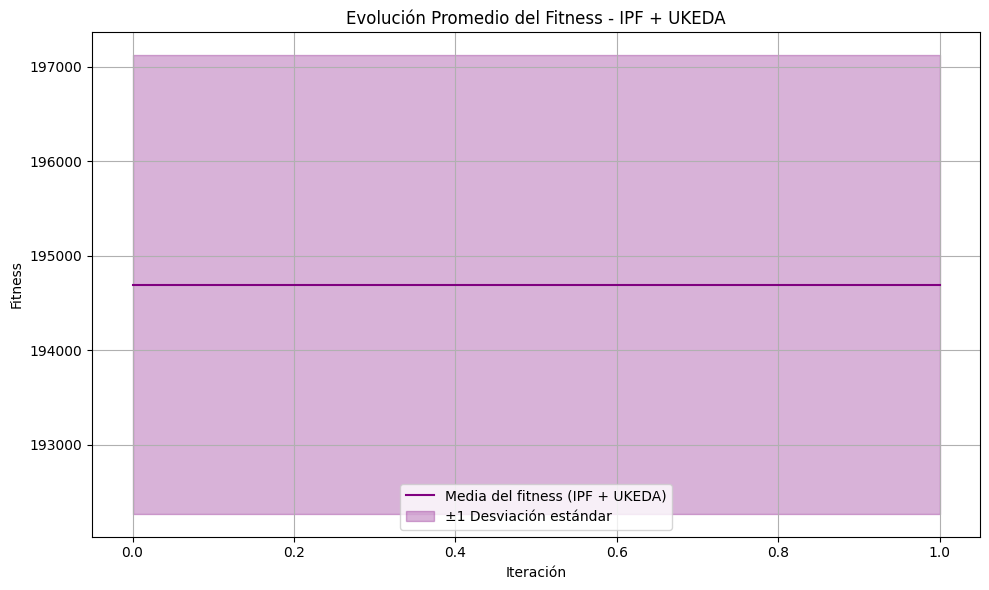

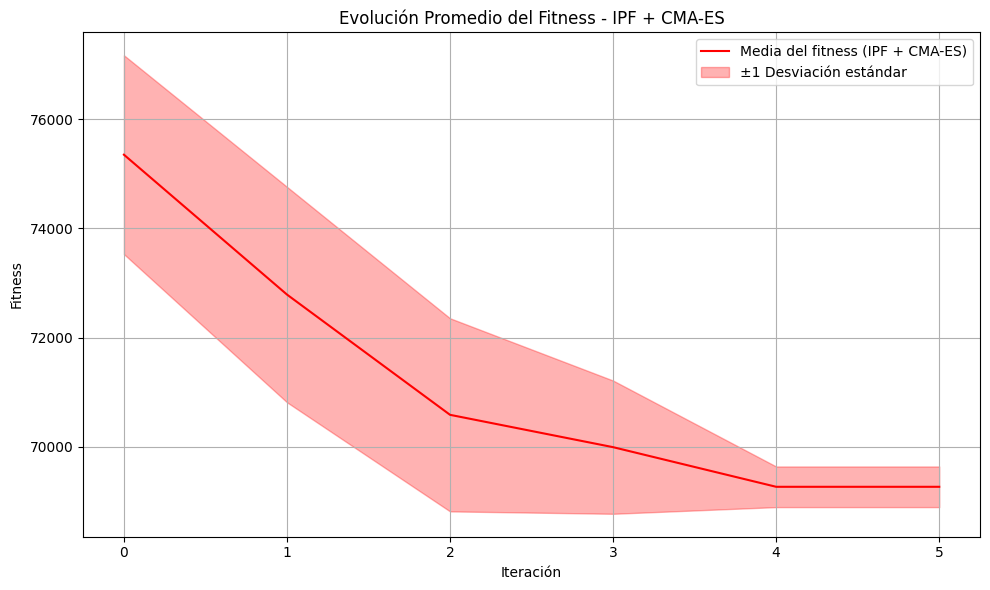

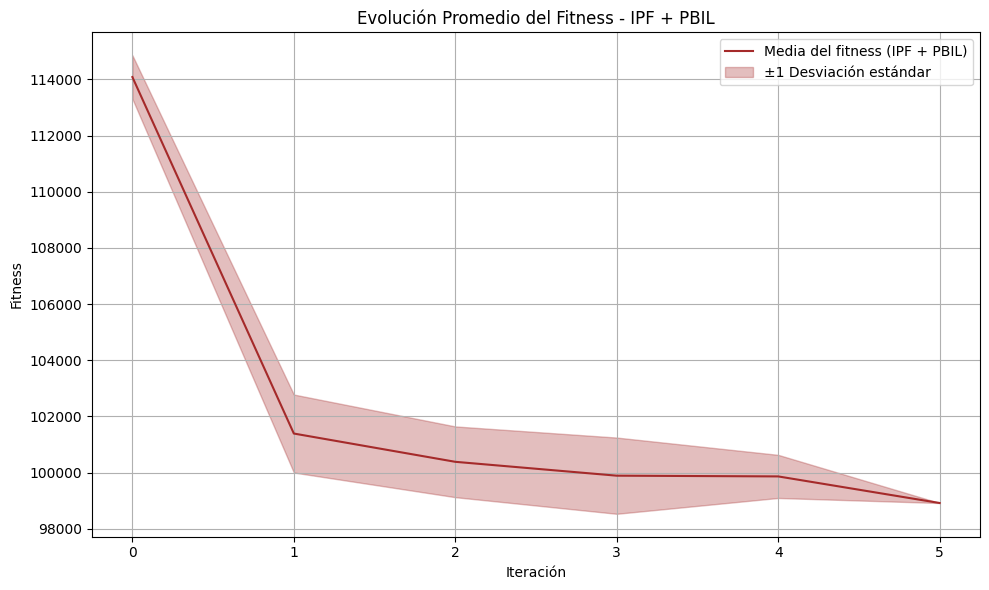

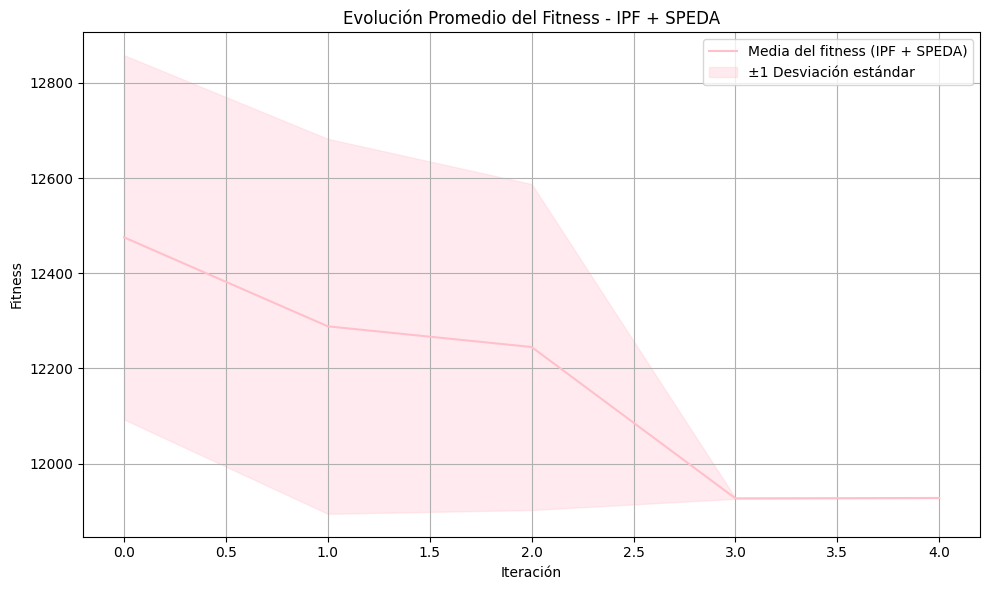

In [ ]:
import numpy as np
import matplotlib.pyplot as pltho
import matplotlib.pyplot as plt
import time, cma
import pandas as pd
from EDAspy.optimization import EMNA, UMDAc, EGNA

# Parámetros generales
dimensions = (10, 10, 10)  # Dimensiones del tensor (3D)
num_experiments = 15  # Número de experimentos

alpha, beta = 60, 10

# Funciones auxiliares
def generate_initial_tensor(rows, cols, depth):
    return np.random.randint(20, 100, size=(rows, cols, depth))

# Función para generar márgenes aleatorios
def generate_tensor_margins(dimensions, total_sum=np.random.randint(30000, 60000)):
    row_margins = np.random.randint(10000, 13000, size=dimensions[0])
    row_margins = np.round(row_margins / row_margins.sum() * total_sum).astype(int)

    col_margins = np.random.randint(10000, 13000, size=dimensions[1])
    col_margins = np.round(col_margins / col_margins.sum() * total_sum).astype(int)

    depth_margins = np.random.randint(10000, 13000, size=dimensions[2])
    depth_margins = np.round(depth_margins / depth_margins.sum() * total_sum).astype(int)

    row_margins[-1] += total_sum - row_margins.sum()
    col_margins[-1] += total_sum - col_margins.sum()
    depth_margins[-1] += total_sum - depth_margins.sum()

    return row_margins, col_margins, depth_margins


def normalize_tensor(tensor, margin0, margin1, margin2, max_iters=10, tol=1e-6):
    tensor = tensor.copy().astype(float)
    for _ in range(max_iters):
        prev_tensor = tensor.copy()

        tensor *= (margin0[:, None, None] / (tensor.sum(axis=(1, 2), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None] / (tensor.sum(axis=(0, 2), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :] / (tensor.sum(axis=(0, 1), keepdims=True) + 1e-10))

        if np.linalg.norm(tensor - prev_tensor) < tol:
            break

    return tensor

def generate_non_negative_tensor(mean_tensor, std_tensor, max_retries=100):
    depth, rows, cols = mean_tensor.shape
    tensor = np.random.normal(mean_tensor, std_tensor)

    for d in range(depth):
        for r in range(rows):
            for c in range(cols):
                retries = 0
                while tensor[d, r, c] < 0 and retries < max_retries:
                    tensor[d, r, c] = np.random.normal(mean_tensor[d, r, c], std_tensor[d, r, c])
                    retries += 1
                if tensor[d, r, c] < 0:
                    tensor[d, r, c] = 0  # If after retries it is still negative, set to 0
    return tensor


def combined_penalty(tensor, row_margins, col_margins, depth_margins, initial_tensor, alpha=60, beta=10):
    row_diff = np.abs(tensor.sum(axis=(1, 2)) - row_margins)
    col_diff = np.abs(tensor.sum(axis=(0, 2)) - col_margins)
    depth_diff = np.abs(tensor.sum(axis=(0, 1)) - depth_margins)
    margin_penalty = np.sum(row_diff**2) + np.sum(col_diff**2) + np.sum(depth_diff**2)

    similarity_penalty = np.sum(np.abs(tensor - initial_tensor))

    return alpha * margin_penalty + beta * similarity_penalty

def fitness_function(tensor, row_margins, col_margins, depth_margins, initial_tensor):
    return combined_penalty(tensor, row_margins, col_margins, depth_margins, initial_tensor)

def ipf_deming_3d(tensor, row_margins, col_margins, depth_margins, initial_tensor,
                                    tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    best_costs = []  # Almacena el mejor costo en cada iteración

    for it in range(max_iterations):
        # --- Ajuste para las filas (dimensión 0) ---
        row_sums = tensor.sum(axis=(1, 2))  # Suma sobre columnas y profundidad
        row_sums[row_sums == 0] = 1e-10  # Evitar división por cero
        tensor *= (row_margins[:, None, None] / row_sums[:, None, None])

        # --- Ajuste para las columnas (dimensión 1) ---
        col_sums = tensor.sum(axis=(0, 2))  # Suma sobre filas y profundidad
        col_sums[col_sums == 0] = 1e-10
        tensor *= (col_margins[None, :, None] / col_sums[None, :, None])

        # --- Ajuste para la profundidad (dimensión 2) ---
        depth_sums = tensor.sum(axis=(0, 1))  # Suma sobre filas y columnas
        depth_sums[depth_sums == 0] = 1e-10
        tensor *= (depth_margins[None, None, :] / depth_sums[None, None, :])

        # Calcular el costo (fitness) después del ajuste
        current_cost = fitness_function(tensor, row_margins, col_margins, depth_margins, initial_tensor)
        best_costs.append(current_cost)

        print(f"IT: {it + 1} \tBest cost: {int(current_cost)}")

        # Criterio de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    # Redondear a enteros al final
    tensor = np.round(tensor).astype(int)
    execution_time = time.time() - start_time
    return tensor, execution_time, best_costs

# Log-verosimilitud en 3D
def log_likelihood_3d(tensor, row_margins, col_margins, depth_margins):
    epsilon = 1e-10
    total = row_margins.sum()
    expected = np.einsum('i,j,k->ijk', row_margins, col_margins, depth_margins) / (total**2)
    return np.sum(tensor * np.log((tensor + epsilon) / expected))

# IPF - Feinberg en 3D
def ipf_fienberg_3d(tensor, row_margins, col_margins, depth_margins, initial_tensor, tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    prev_ll = log_likelihood_3d(tensor, row_margins, col_margins, depth_margins)
    best_costs = []

    for it in range(max_iterations):
        # Ajuste por filas (dim 0)
        row_sums = tensor.sum(axis=(1, 2))
        tensor *= row_margins[:, None, None] / (row_sums[:, None, None] + 1e-10)

        # Ajuste por columnas (dim 1)
        col_sums = tensor.sum(axis=(0, 2))
        tensor *= col_margins[None, :, None] / (col_sums[None, :, None] + 1e-10)

        # Ajuste por profundidad (dim 2)
        depth_sums = tensor.sum(axis=(0, 1))
        tensor *= depth_margins[None, None, :] / (depth_sums[None, None, :] + 1e-10)

        # Evaluación
        new_ll = log_likelihood_3d(tensor, row_margins, col_margins, depth_margins)
        best_cost = fitness_function(tensor, row_margins, col_margins, depth_margins, initial_tensor)
        best_costs.append(best_cost)

        print(f"[Feinberg 3D] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if abs(new_ll - prev_ll) < tol:
            print("Convergencia alcanzada.")
            break

        prev_ll = new_ll

    execution_time = time.time() - start_time
    return np.round(tensor).astype(int), execution_time, best_costs

# KL divergencia simétrica para tensores 3D
def kl_symmetric_divergence_3d(p, q):
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    return np.sum(p * np.log(p / q) + q * np.log(q / p))

# IPF - Rüschendorf en 3D
def ipf_ruschendorf_3d(tensor, row_margins, col_margins, depth_margins, initial_tensor, tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    prev_tensor = tensor.copy()
    best_costs = []

    for it in range(max_iterations):
        # Ajuste por filas (dim 0)
        row_sums = tensor.sum(axis=(1, 2))
        tensor *= row_margins[:, None, None] / (row_sums[:, None, None] + 1e-10)

        # Ajuste por columnas (dim 1)
        col_sums = tensor.sum(axis=(0, 2))
        tensor *= col_margins[None, :, None] / (col_sums[None, :, None] + 1e-10)

        # Ajuste por profundidad (dim 2)
        depth_sums = tensor.sum(axis=(0, 1))
        tensor *= depth_margins[None, None, :] / (depth_sums[None, None, :] + 1e-10)

        # Coste (fitness)
        best_cost = fitness_function(tensor, row_margins, col_margins, depth_margins, initial_tensor)
        best_costs.append(best_cost)
        print(f"[Rüschendorf 3D] IT: {it + 1} \tBest cost: {int(best_cost)}")

        # Criterio de parada: divergencia KL simétrica
        if kl_symmetric_divergence_3d(tensor, prev_tensor) < tol:
            print("Convergencia alcanzada.")
            break

        prev_tensor = tensor.copy()

    execution_time = time.time() - start_time
    return np.round(tensor).astype(int), execution_time, best_costs


# Función de búsqueda local con ruido
def local_search_with_noise_tensor(X, margins, initial_tensor, shape, normalize_tensor,
                                   alpha=60, beta=10, trials=30, std=0.01):

    best_X = X.copy()
    best_tensor = normalize_tensor(X.reshape(shape), *margins)
    best_fitness = combined_penalty(best_tensor, margins, initial_tensor, alpha, beta)
    best_perturbed_X = X.copy()
    improved = False

    for _ in range(trials):
        noise = np.random.normal(0, std, size=X.shape)
        perturbed_X = X + X * noise
        tensor = normalize_tensor(perturbed_X.reshape(shape), *margins)
        fitness = combined_penalty(tensor, *margins, initial_tensor, alpha, beta)

        if fitness < best_fitness:
            best_fitness = fitness
            best_X = tensor.flatten()
            best_perturbed_X = perturbed_X.copy()
            improved = True

    if improved:
        print("\n Mejor 'perturbed_X':")
        print(best_perturbed_X.reshape(shape))
        print(" Fitness tras local search:", best_fitness)
    else:
        print("\n Local search no mejoró el fitness.")

    return best_X.reshape(shape), best_fitness, best_perturbed_X.reshape(shape), improved


# Ejecución de EMNA para tensor/matriz
def run_emna_tensor(margins, shape, iterations, initial_tensor,
                    alpha=60, beta=10, trials=30, std=0.01):

    n_variables = np.prod(shape)
    upper_bound = max([m.max() for m in margins])

    emna = EMNA(size_gen=100, max_iter=iterations, dead_iter=10,
                n_variables=n_variables, lower_bound=1, upper_bound=upper_bound)

    def fitness_function(individual):
        tensor = individual.reshape(shape)
        tensor = normalize_tensor(tensor, *margins)
        return combined_penalty(tensor, *margins, initial_tensor)

    start_time = time.time()
    result = emna.minimize(fitness_function)
    end_time = time.time()

    best_tensor = result.best_ind.reshape(shape)
    best_tensor = normalize_tensor(best_tensor, *margins)
    base_X = best_tensor.flatten()

    execution_time = end_time - start_time
    original_fitness = combined_penalty(best_tensor, *margins, initial_tensor)

    print("\nEjecutando búsqueda local con ruido sobre la solución de EMNA...")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        base_X, margins, initial_tensor, shape, normalize_tensor,
        alpha=alpha, beta=beta, trials=trials, std=std
    )

    if improved:
        print("Búsqueda local mejoró la solución de EMNA.")
        return refined_tensor, -np.array(result.history), refined_fitness, execution_time
    else:
        print("La búsqueda local no mejoró la solución de EMNA.")
        return best_tensor, -np.array(result.history), original_fitness, execution_time


def iterative_proportional_fitting_plus_emna_tensor(tensor, margins, initial_tensor, iterations=10, tol=1e-6):
    tensor = tensor.astype(float)
    best_costs = []
    start_time = time.time()

    margin0, margin1, margin2 = margins

    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = combined_penalty(best_tensor_so_far, *margins, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 3D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None] / (tensor.sum(axis=(1, 2), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None] / (tensor.sum(axis=(0, 2), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :] / (tensor.sum(axis=(0, 1), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con EMNA
        refined_tensor, history, refined_fitness, execution_time_emna = run_emna_tensor(margins, tensor.shape, 10, tensor)

        # Actualizamos el tensor y el coste si la mejora de EMNA es significativa
        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos el tensor actual y su coste
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far  # No se cambia el fitness, seguimos con IPF


        # Criterio de parada: si la diferencia entre los costes consecutivos es menor que la tolerancia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Devolver el mejor tensor encontrado, el tiempo de ejecución y los costes
    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs

# UMDAc (Estimación de distribución con variables categóricas)
def run_umdac_tensor(margins, shape, iterations, initial_tensor,
                     alpha=60, beta=10, trials=30, std=0.01):

    n_variables = np.prod(shape)
    upper_bound = max([m.max() for m in margins])

    umdac = UMDAc(size_gen=100, max_iter=iterations, dead_iter=10,
                  n_variables=n_variables, lower_bound=1, upper_bound=upper_bound)

    def fitness_function(individual):
        tensor = individual.reshape(shape)
        tensor = normalize_tensor(tensor, *margins)
        return combined_penalty(tensor, *margins, initial_tensor)

    start_time = time.time()
    result = umdac.minimize(fitness_function)
    end_time = time.time()

    best_tensor = result.best_ind.reshape(shape)
    best_tensor = normalize_tensor(best_tensor, *margins)
    base_X = best_tensor.flatten()

    execution_time = end_time - start_time
    original_fitness = combined_penalty(best_tensor, *margins, initial_tensor)

    print("\n🔍 Ejecutando búsqueda local con ruido sobre la solución de UMDAc...")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        base_X, margins, initial_tensor, shape, normalize_tensor,
        alpha=alpha, beta=beta, trials=trials, std=std
    )

    if improved:
        print("Búsqueda local mejoró la solución de UMDAc.")
        return refined_tensor, np.array(result.history), refined_fitness, execution_time
    else:
        print("La búsqueda local no mejoró la solución de UMDAc.")
        return best_tensor, np.array(result.history), original_fitness, execution_time


# Función Iterative Proportional Fitting con UMDAc
def iterative_proportional_fitting_plus_umdac_tensor(tensor, margins, initial_tensor, iterations=10, tol=1e-6):

    tensor = tensor.astype(float)
    best_costs = []
    start_time = time.time()

    margin0, margin1, margin2 = margins

    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = combined_penalty(best_tensor_so_far, *margins, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 3D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None] / (tensor.sum(axis=(1, 2), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None] / (tensor.sum(axis=(0, 2), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :] / (tensor.sum(axis=(0, 1), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con UMDAc
        refined_tensor, history, refined_fitness, execution_time_umdac = run_umdac_tensor(margins, tensor.shape, 20, tensor)

        # Actualizamos el tensor y el coste si la mejora de UMDAc es significativa
        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos el tensor actual y su coste
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far  # No se cambia el fitness, seguimos con IPF

        # Criterio de parada: si la diferencia entre los costes consecutivos es menor que la tolerancia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Devolver el mejor tensor encontrado, el tiempo de ejecución y los costes
    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs



# UnivariateKEDA
def run_ukeda_tensor(margins, shape, iterations, initial_tensor,
                     alpha=60, beta=10, trials=30, std=0.01):

    n_variables = np.prod(shape)
    upper_bound = max([m.max() for m in margins])

    ukeda = UnivariateKEDA(size_gen=3000, max_iter=iterations, dead_iter=10,
                           n_variables=n_variables, lower_bound=1, upper_bound=upper_bound)

    def fitness_function(individual):
        tensor = individual.reshape(shape)
        tensor = normalize_tensor(tensor, *margins)
        return combined_penalty(tensor, *margins, initial_tensor)

    start_time = time.time()
    result = ukeda.minimize(fitness_function)
    end_time = time.time()

    best_tensor = result.best_ind.reshape(shape)
    best_tensor = normalize_tensor(best_tensor, *margins)
    base_X = best_tensor.flatten()

    execution_time = end_time - start_time
    original_fitness = combined_penalty(best_tensor, *margins, initial_tensor)

    print("\nEjecutando búsqueda local con ruido sobre la solución de UKEDA...")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        base_X, margins, initial_tensor, shape, normalize_tensor,
        alpha=alpha, beta=beta, trials=trials, std=std
    )

    if improved:
        print("Búsqueda local mejoró la solución de UKEDA.")
        return refined_tensor, np.array(result.history), refined_fitness, execution_time
    else:
        print("La búsqueda local no mejoró la solución de UKEDA.")
        return best_tensor, np.array(result.history), original_fitness, execution_time


# Función Iterative Proportional Fitting con Univariate KEDA 3D
def iterative_proportional_fitting_plus_ukeda_tensor(tensor, margins, initial_tensor, iterations=20, tol=1e-6):
    start_time = time.time()
    tensor = tensor.astype(float)
    best_costs = []

    margin0, margin1, margin2 = margins

    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = fitness_function(best_tensor_so_far, row_margins, col_margins, depth_margins, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 3D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None] / (tensor.sum(axis=(1, 2), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None] / (tensor.sum(axis=(0, 2), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :] / (tensor.sum(axis=(0, 1), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con Univariate KEDA + búsqueda local
        refined_tensor, history, refined_fitness, exec_time_ukeda = run_ukeda_tensor(margins, tensor.shape, 20, tensor)

        # Evaluación de mejora
        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, se conserva el tensor anterior y su fitness
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far

        # Criterio de parada por convergencia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    execution_time = time.time() - start_time
    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs

#EGNA
def run_egna_tensor(base_tensor, row_margins, col_margins, depth_margins, initial_tensor,
                    population_size=50, num_generations=20, elite_size=10, noise_level=5, lambda_=0.7,
                    alpha=60, beta=10, trials=30, std=0.01):

    base_tensor = np.array(base_tensor)
    shape = base_tensor.shape
    margins = (row_margins, col_margins, depth_margins)

    current_population = [
        generate_non_negative_tensor(base_tensor, np.full_like(base_tensor, noise_level))
        for _ in range(population_size)
    ]

    history = []
    global_best_fitness = float('inf')
    global_best_tensor = None

    for gen in range(num_generations):
        fitness_scores = [
            float(fitness_function(np.round(ind).astype(int), *margins, initial_tensor))
            for ind in current_population
        ]

        current_best_fitness = min(fitness_scores)
        best_index = np.argmin(fitness_scores)
        current_best_tensor = np.round(current_population[best_index]).astype(int)

        if current_best_fitness < global_best_fitness:
            global_best_fitness = current_best_fitness
            global_best_tensor = current_best_tensor

        history.append(global_best_fitness)
        print(f"EGNA 3D - Generación {gen+1}: Best fitness = {global_best_fitness:.4f}")

        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)

        mean_elite = np.mean(elite_array, axis=0)
        std_elite = np.std(elite_array, axis=0)

        base_tensor = lambda_ * base_tensor + (1 - lambda_) * mean_elite

        current_population = [
            generate_non_negative_tensor(base_tensor, std_elite)
            for _ in range(population_size)
        ]

    # Aplicar búsqueda local al mejor tensor
    print("\nEjecutando búsqueda local con ruido sobre el tensor de EGNA...")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        global_best_tensor.flatten(), margins, initial_tensor, shape,
        normalize_tensor, alpha=alpha, beta=beta, trials=trials, std=std
    )

    if improved:
        print("Búsqueda local mejoró la solución de EGNA.")
        return refined_tensor, -np.array(history), refined_fitness
    else:
        print("La búsqueda local no mejoró la solución de EGNA.")
        return global_best_tensor, -np.array(history), global_best_fitness


#IPF+EGNA
def iterative_proportional_fitting_plus_egna_tensor(tensor, margins, initial_tensor, iterations=10, tol=1e-6):
    tensor = tensor.astype(float)
    best_costs = []
    start_time = time.time()

    margin0, margin1, margin2 = margins

    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = combined_penalty(best_tensor_so_far, *margins, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 3D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None] / (tensor.sum(axis=(1, 2), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None] / (tensor.sum(axis=(0, 2), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :] / (tensor.sum(axis=(0, 1), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con EGNA
        refined_tensor, history, refined_fitness = run_egna_tensor(tensor, margin0, margin1, margin2, tensor)

        # Actualizamos el tensor y el coste si la mejora de EGNA es significativa
        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos el tensor actual y su coste
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far  # No se cambia el fitness, seguimos con IPF


        # Criterio de parada: si la diferencia entre los costes consecutivos es menor que la tolerancia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Devolver el mejor tensor encontrado, el tiempo de ejecución y los costes
    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs


def cmaes_3d_optimization(base_tensor, row_margins, col_margins, depth_margins, initial_tensor,
                           sigma=10, population_size=50, generations=30,
                           alpha=60, beta=10, trials=30, std=0.01):

    shape = base_tensor.shape
    n_variables = np.prod(shape)
    margins = (row_margins, col_margins, depth_margins)
    initial_flat = base_tensor.flatten().astype(float)

    # Inicialización CMA-ES
    es = cma.CMAEvolutionStrategy(initial_flat, sigma, {
        'popsize': population_size,
        'maxiter': generations,
        'verb_log': 0,
        'verb_disp': 0,
    })

    history = []
    best_fitness = float('inf')
    best_solution = None

    start_time = time.time()

    while not es.stop():
        solutions = es.ask()
        fitnesses = []

        for s in solutions:
            tensor = s.reshape(shape)
            tensor = np.maximum(tensor, 0)  # Asegura no negatividad
            tensor = normalize_tensor(tensor, *margins)
            fitness = fitness_function(np.round(tensor).astype(int), *margins, initial_tensor)
            fitnesses.append(fitness)

            if fitness < best_fitness:
                best_fitness = fitness
                best_solution = tensor.copy()

        es.tell(solutions, fitnesses)
        history.append(best_fitness)

        print(f"CMA-ES - Generación {len(history)}: Best fitness = {best_fitness:.6f}")

        if len(history) >= generations:
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Redondear la mejor solución antes de aplicar la búsqueda local
    best_tensor = np.round(best_solution).astype(int)
    best_tensor_flat = best_tensor.flatten()

    # Aplicar búsqueda local con ruido
    print("\nEjecutando búsqueda local con ruido sobre el tensor de CMA-ES...")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        best_tensor_flat, margins, initial_tensor, shape, normalize_tensor,
        alpha=alpha, beta=beta, trials=trials, std=std
    )

    if improved:
        print("Búsqueda local mejoró la solución de CMA-ES.")
        return refined_tensor, history, refined_fitness, execution_time
    else:
        print("La búsqueda local no mejoró la solución de CMA-ES.")
        return best_tensor, history, best_fitness, execution_time

def iterative_proportional_fitting_plus_cmaes_tensor(tensor, margins, initial_tensor, iterations=10, tol=1e-6):
    tensor = tensor.astype(float)
    best_costs = []
    start_time = time.time()

    margin0, margin1, margin2 = margins

    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = combined_penalty(best_tensor_so_far, *margins, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 3D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None] / (tensor.sum(axis=(1, 2), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None] / (tensor.sum(axis=(0, 2), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :] / (tensor.sum(axis=(0, 1), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con CMAES
        refined_tensor, history, refined_fitness, execution_time_cmaes = cmaes_3d_optimization(
            tensor, margin0, margin1, margin2, tensor)


        # Actualizamos el tensor y el coste si la mejora de EMNA es significativa
        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos el tensor actual y su coste
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far  # No se cambia el fitness, seguimos con IPF


        # Criterio de parada: si la diferencia entre los costes consecutivos es menor que la tolerancia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Devolver el mejor tensor encontrado, el tiempo de ejecución y los costes
    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs

# PBIL continuo
def run_pbil_continuous_tensor(margins, tensor_shape, initial_tensor, iterations=10,
                                size_gen=100, learning_rate=0.01, alpha=60, beta=10, trials=30, std=0.01):
    n_variables = np.prod(tensor_shape)

    lower_bound = np.ones(n_variables)
    upper_bound = np.full(n_variables, max(m.max() for m in margins))

    # Vector de probabilidad inicial
    prob_vector = (lower_bound + upper_bound) / 2.0
    std_dev = (upper_bound - lower_bound) / 6  # Para mantener la mayoría dentro de límites

    best_fitness = float('inf')
    best_solution = None
    fitness_history = []

    def fitness_function(individual):
        tensor = individual.reshape(tensor_shape)
        tensor = normalize_tensor(tensor, *margins)
        return combined_penalty(tensor, *margins, initial_tensor, alpha, beta)

    for iter in range(iterations):
        # Generar población
        population = np.random.normal(loc=prob_vector, scale=std_dev, size=(size_gen, n_variables))
        population = np.clip(population, lower_bound, upper_bound)

        fitness_values = np.array([fitness_function(ind) for ind in population])
        best_idx = np.argmin(fitness_values)
        best_individual = population[best_idx]

        if fitness_values[best_idx] < best_fitness:
            best_fitness = fitness_values[best_idx]
            best_solution = best_individual.copy()

        # Actualizar vector de probabilidad
        prob_vector = (1 - learning_rate) * prob_vector + learning_rate * best_individual
        fitness_history.append(best_fitness)

        print(f"PBIL IT {iter+1} - Best cost: {best_fitness:.4f}")

    # Mejor tensor encontrado
    best_tensor = best_solution.reshape(tensor_shape)
    best_tensor = normalize_tensor(best_tensor, *margins)

    # Búsqueda local
    print("\nEjecutando búsqueda local con ruido sobre el tensor de PBIL...")
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        best_solution, margins, initial_tensor, tensor_shape, normalize_tensor,
        alpha=alpha, beta=beta, trials=trials, std=std
    )

    if improved:
        print("Búsqueda local mejoró la solución encontrada por PBIL.")
        best_tensor = refined_tensor
        best_fitness = refined_fitness
    else:
        print("La búsqueda local no logró mejorar la solución de PBIL.")

    return best_tensor, fitness_history, best_fitness


def iterative_proportional_fitting_plus_pbil_tensor(tensor, margins, initial_tensor, iterations=10, tol=1e-6):
    tensor = tensor.astype(float)
    best_costs = []
    start_time = time.time()

    margin0, margin1, margin2 = margins

    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = combined_penalty(best_tensor_so_far, *margins, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 3D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None] / (tensor.sum(axis=(1, 2), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None] / (tensor.sum(axis=(0, 2), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :] / (tensor.sum(axis=(0, 1), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con PBIL
        refined_tensor, history, refined_fitness = run_pbil_continuous_tensor(margins=margins,
            tensor_shape=tensor.shape,iterations=30,initial_tensor=tensor)

        # Actualizamos el tensor y el coste si la mejora de PBIL es significativa
        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos el tensor actual y su coste
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far  # No se cambia el fitness, seguimos con IPF

        # Criterio de parada: si la diferencia entre los costes consecutivos es menor que la tolerancia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Devolver el mejor tensor encontrado, el tiempo de ejecución y los costes
    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs

# SPEDA (versión simplificada)
def speda_3d_optimization(base_tensor, row_margins, col_margins, depth_margins, initial_tensor,
                          population_size=50, num_generations=20, elite_size=10, alpha=0.7, noise_level=5,
                          local_search_trials=30, local_search_std=0.01, local_search_alpha=60, local_search_beta=10):
    shape = base_tensor.shape  # (dim1, dim2, dim3)

    # Inicializa la población con ruido
    current_population = [
        generate_non_negative_tensor(base_tensor, np.full_like(base_tensor, noise_level))
        for _ in range(population_size)
    ]

    best_fitness = float('inf')
    best_tensor = None
    history = []

    for gen in range(num_generations):
        # Evalúa el fitness para cada tensor
        fitness_scores = [
            fitness_function(np.round(ind).astype(int), row_margins, col_margins, depth_margins, initial_tensor)
            for ind in current_population
        ]

        # Selección de la élite
        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)  # shape: (elite_size, dim1, dim2, dim3)

        mean_elite = np.mean(elite_array, axis=0)
        std_elite = np.std(elite_array, axis=0)

        # Actualizar modelo base con suavizado
        base_tensor = alpha * base_tensor + (1 - alpha) * mean_elite

        # Generar nueva población a partir de la distribución suavizada
        current_population = [
            generate_non_negative_tensor(base_tensor, std_elite)
            for _ in range(population_size)
        ]

        # Mejor fitness actual y su tensor correspondiente
        current_best_fitness = np.min(fitness_scores)
        current_best_tensor = current_population[np.argmin(fitness_scores)]

        # Actualizar el mejor fitness global
        if current_best_fitness < best_fitness:
            best_fitness = current_best_fitness
            best_tensor = current_best_tensor

        print(f"SPEDA 3D Generación {gen+1}: Best fitness = {best_fitness:.6f}")
        history.append(best_fitness)

    # Ejecutar búsqueda local sobre la mejor solución encontrada
    print("\nEjecutando búsqueda local con ruido sobre la mejor solución de SPEDA...")
    base_X = best_tensor.flatten()
    refined_tensor, refined_fitness, _, improved = local_search_with_noise_tensor(
        base_X, (row_margins, col_margins, depth_margins), initial_tensor, shape, normalize_tensor,
        alpha=local_search_alpha, beta=local_search_beta, trials=local_search_trials, std=local_search_std
    )

    if improved:
        print("La búsqueda local mejoró la solución de SPEDA.")
        return refined_tensor, history, refined_fitness
    else:
        print("La búsqueda local no mejoró la solución de SPEDA.")
        return best_tensor, history, best_fitness


# IPF clásico con SPEDA
def iterative_proportional_fitting_plus_speda_tensor(tensor, margins, initial_tensor, iterations=10, tol=1e-6, max_iterations=100):
    tensor = tensor.astype(float)
    best_costs = []
    start_time = time.time()

    margin0, margin1, margin2 = margins

    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = combined_penalty(best_tensor_so_far, *margins, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 3D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None] / (tensor.sum(axis=(1, 2), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None] / (tensor.sum(axis=(0, 2), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :] / (tensor.sum(axis=(0, 1), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Aplicar SPEDA como refinamiento
        refined_tensor, history, refined_fitness = speda_3d_optimization( np.round(tensor).astype(int),margin0, margin1, margin2,tensor)

        # Actualizamos el tensor y el coste si la mejora de EMNA es significativa
        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos el tensor actual y su coste
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far  # No se cambia el fitness, seguimos con IPF


        # Criterio de parada: si la diferencia entre los costes consecutivos es menor que la tolerancia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Devolver el mejor tensor encontrado, el tiempo de ejecución y los costes
    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs


# Almacenar resultados
best_costs_deming, times_deming  = [], []
best_costs_fienberg, times_fienberg = [], []
best_costs_ruschendorf, times_ruschendorf = [], []

best_costs_emna, times_emna = [], []
best_costs_umdac, times_umdac = [], []
best_costs_egna, times_egna = [], []
best_costs_keda, times_keda = [], []
best_costs_cmaes, times_cmaes = [], []
best_costs_pbil, times_pbil = [], []
best_costs_speda, times_speda = [], []

all_histories_emna, all_histories_umdac, all_histories_egna = [], [], []
all_histories_keda, all_histories_cmaes, all_histories_pbil= [], [], []
all_histories_speda = []

# Generar márgenes y tensor inicial
row_margins, col_margins, depth_margins = generate_tensor_margins(dimensions)
initial_tensor = generate_initial_tensor(*dimensions)

# Imprimir el tensor inicial y los márgenes
print("\nTensor inicial (antes de ajustar):")
print(initial_tensor)

print("\nMárgenes por filas (dim 0):")
print(row_margins)

print("\nMárgenes por columnas (dim 1):")
print(col_margins)

print("\nMárgenes por profundidad (dim 2):")
print(depth_margins)

# Experimentos
for i in range(num_experiments):
    print(f"\nEjecutando prueba {i+1}/{num_experiments}...")

    margins = [row_margins, col_margins, depth_margins]

    # IPF 3D (Deming)
    optimized_tensor_deming, time_deming, costs_deming = ipf_deming_3d(
        initial_tensor, row_margins, col_margins, depth_margins, initial_tensor
    )
    best_costs_deming.append(costs_deming[-1])
    times_deming.append(time_deming)
    print(f"📌 IPF Deming - Fitness final: {costs_deming[-1]:.2f}, Tiempo: {time_deming:.2f}s")

    # IPF 3D (Feinberg)
    optimized_tensor_fienberg, time_fienberg, costs_fienberg = ipf_fienberg_3d(
        initial_tensor, row_margins, col_margins, depth_margins, initial_tensor
    )
    best_costs_fienberg.append(costs_fienberg[-1])
    times_fienberg.append(time_fienberg)
    print(f"📌 IPF basado en Feinberg - Fitness final: {costs_fienberg[-1]:.2f}, Tiempo: {time_fienberg:.2f}s")

    # IPF 3D (Rüschendorf)
    optimized_tensor_ruschendorf, time_ruschendorf, costs_ruschendorf = ipf_ruschendorf_3d(
        initial_tensor, row_margins, col_margins, depth_margins, initial_tensor
    )
    best_costs_ruschendorf.append(costs_ruschendorf[-1])
    times_ruschendorf.append(time_ruschendorf)
    print(f"📌 IPF basado en Rüschendorf - Fitness final: {costs_ruschendorf[-1]:.2f}, Tiempo: {time_ruschendorf:.2f}s")

    # Univariate KEDA 3D (nueva inclusión)
    optimized_tensor_keda, time_keda, costs_keda = iterative_proportional_fitting_plus_ukeda_tensor(
        initial_tensor, margins, initial_tensor)
    best_costs_keda.append(costs_keda[-1])
    times_keda.append(time_keda)
    all_histories_keda.append(costs_keda)  # Guardar historial
    print(f"📌 Fitness IPF+Univariate KEDA - Fitness final: {costs_keda[-1]:.4f}, Tiempo: {time_keda:.4f}s")

    # IPF + EMNA (adaptado para tensor 3D)
    optimized_tensor_emna, time_emna, costs_emna = iterative_proportional_fitting_plus_emna_tensor(
        initial_tensor, margins, initial_tensor
    )
    best_costs_emna.append(costs_emna[-1])
    times_emna.append(time_emna)
    all_histories_emna.append(costs_emna)  # Guardar historial
    print(f"📌 IPF + EMNA - Fitness final: {costs_emna[-1]:.2f}, Tiempo: {time_emna:.2f}s")

    # IPF + UMDAc (adaptado para tensor 3D)
    optimized_tensor_umdac, time_umdac, costs_umdac = iterative_proportional_fitting_plus_umdac_tensor(
        initial_tensor, margins, initial_tensor
    )
    best_costs_umdac.append(costs_umdac[-1])
    times_umdac.append(time_umdac)
    all_histories_umdac.append(costs_umdac)  # Guardar historial
    print(f"📌 IPF + UMDAc - Fitness final: {costs_umdac[-1]:.2f}, Tiempo: {time_umdac:.2f}s")

    # IPF + EGNA 3D
    optimized_tensor_egna, time_egna, costs_egna = iterative_proportional_fitting_plus_egna_tensor(
        initial_tensor, margins, initial_tensor
    )
    best_costs_egna.append(costs_egna[-1])
    times_egna.append(time_egna)
    all_histories_egna.append(costs_egna)  # Guardar historial
    print(f"📌 IPF + EGNA 3D - Fitness final: {costs_egna[-1]:.4f}, Tiempo: {time_egna:.4f}s")

    # IPF + CMAES (adaptado para tensor 3D)
    optimized_tensor_cmaes, time_cmaes, costs_cmaes = iterative_proportional_fitting_plus_cmaes_tensor(
        initial_tensor, margins, initial_tensor
    )
    best_costs_cmaes.append(costs_cmaes[-1])
    times_cmaes.append(time_cmaes)
    all_histories_cmaes.append(costs_cmaes)  # Guardar historial
    print(f"📌 IPF + CMAES - Fitness final: {costs_cmaes[-1]:.2f}, Tiempo: {time_cmaes:.2f}s")

    # IPF + PBIL 3D
    optimized_tensor_pbil, time_pbil, costs_pbil = iterative_proportional_fitting_plus_pbil_tensor(
        initial_tensor, margins, initial_tensor
    )
    best_costs_pbil.append(costs_pbil[-1])
    times_pbil.append(time_pbil)
    all_histories_pbil.append(costs_pbil)  # Guardar historial
    print(f"📌 IPF + PBIL 3D - Fitness final: {costs_pbil[-1]:.4f}, Tiempo: {time_pbil:.4f}s")

    # IPF + SPEDA 3D
    optimized_tensor_speda, time_speda, costs_speda = iterative_proportional_fitting_plus_speda_tensor(
        initial_tensor, margins, initial_tensor
    )
    best_costs_speda.append(costs_speda[-1])
    times_speda.append(time_speda)
    all_histories_speda.append(costs_speda)  # Guardar historial
    print(f"📌 IPF + SPEDA - Fitness final: {costs_speda[-1]:.4f}, Tiempo: {time_speda:.4f}s")


# Mostrar resumen final
df_resultados = pd.DataFrame({
    "Experimento": np.arange(1, num_experiments+1),
    "IPF (Deming)": best_costs_deming,
    "IPF (Feinberg)": best_costs_fienberg,
    "IPF (Rüschendorf)": best_costs_ruschendorf,
    "IPF+EMNA": best_costs_emna,
    "IPF+UMDAc": best_costs_umdac,
    "IPF+EGNA": best_costs_egna,
    "IPF+UKEDA": best_costs_keda,
    "IPF+CMA-ES": best_costs_cmaes,
    "IPF+PBIL": best_costs_pbil,
    "IPF+SPEDA": best_costs_speda
})

# Graficar resultados de comparación de fitness
plt.figure(figsize=(12, 6))
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Deming)"], label="IPF (Deming)", marker='o', linestyle='--')
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Feinberg)"], label="IPF (Feinberg)", marker='x', linestyle='--')
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Rüschendorf)"], label="IPF (Rüschendorf)", marker='s', linestyle='--')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+EMNA"], label="IPF+EMNA", marker='d')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+UMDAc"], label="IPF+UMDAc", marker='^')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+EGNA"], label="IPF+EGNA", marker='v')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+UKEDA"], label="IPF+UKEDA", marker='<')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+CMA-ES"], label="IPF+CMA-ES", marker='p')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+PBIL"], label="IPF+PBIL", marker='*')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+SPEDA"], label="IPF+SPEDA", marker='h')

plt.xlabel("Experimentos")
plt.ylabel("Fitness Final")
plt.title("Comparación de Algoritmos: IPF vs EDAS 3 DIM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 🧾 Mostrar resultados tabulares
print("\n🔹 Resultados Finales por Experimento:")
print(df_resultados.round(4))


# Lista de todas las historias y etiquetas
all_histories = [all_histories_emna, all_histories_umdac, all_histories_egna, all_histories_keda,
                 all_histories_cmaes, all_histories_pbil, all_histories_speda]

labels = ["IPF + EMNA","IPF + UMDAc", "IPF + EGNA", "IPF + UKEDA", "IPF + CMA-ES", "IPF + PBIL", "IPF + SPEDA"]

colors = ['green', 'blue', 'orange', 'purple', 'red', 'brown', 'pink']

for history_list, label, color in zip(all_histories, labels, colors):
    max_len = max(len(h) for h in history_list)
    history_array = np.array([np.pad(h, (0, max_len - len(h)), constant_values=np.nan) for h in history_list])

    mean_fitness = np.nanmean(history_array, axis=0)
    std_fitness = np.nanstd(history_array, axis=0)

    plt.figure(figsize=(10, 6))
    plt.plot(mean_fitness, label=f'Media del fitness ({label})', color=color)
    plt.fill_between(range(max_len),
                     mean_fitness - std_fitness,
                     mean_fitness + std_fitness,
                     color=color, alpha=0.3, label='±1 Desviación estándar')
    plt.title(f'Evolución Promedio del Fitness - {label}')
    plt.xlabel('Iteración')
    plt.ylabel('Fitness')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


<ipython-input-28-889cedca7fe4>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x="Algoritmo", y="Costo final", palette="Set3")


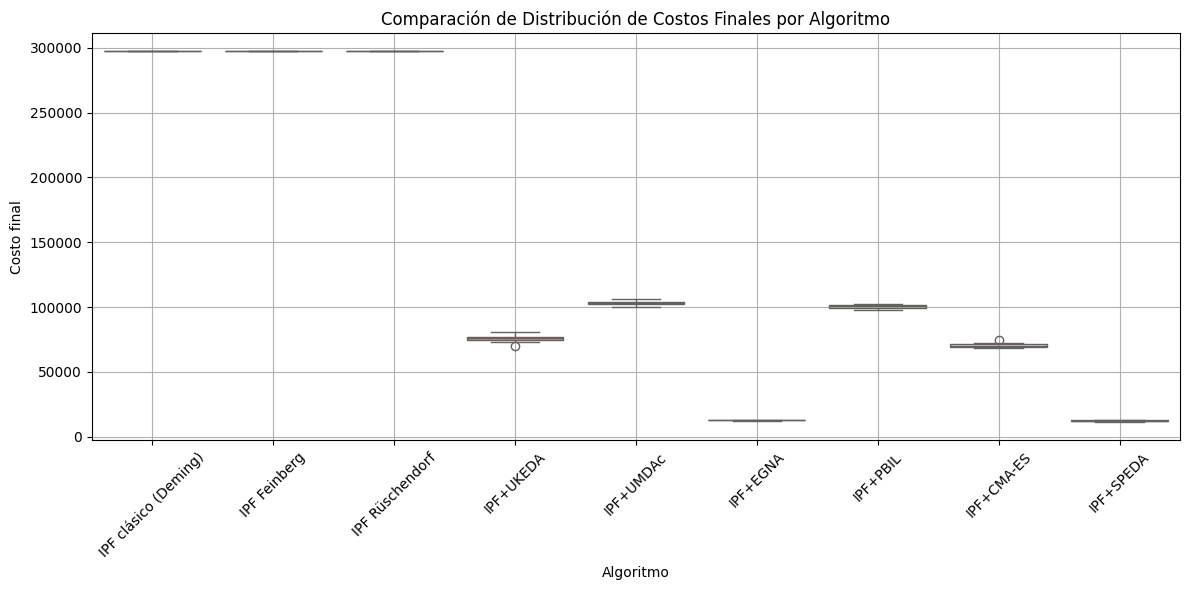

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Usar los nombres definidos en tu experimento
data = {
    "IPF clásico (Deming)": best_costs_deming,
    "IPF Feinberg": best_costs_fienberg,
    "IPF Rüschendorf": best_costs_ruschendorf,
    "IPF+UKEDA": best_costs_ukeda,
    "IPF+UMDAc": best_costs_umdac,
    "IPF+EGNA": best_costs_egna,
    "IPF+PBIL": best_costs_pbil,
    "IPF+CMA-ES": best_costs_cmaes,
    "IPF+SPEDA": best_costs_speda
}

df = pd.DataFrame(data)
df_melted = df.melt(var_name="Algoritmo", value_name="Costo final")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x="Algoritmo", y="Costo final", palette="Set3")
plt.title("Comparación de Distribución de Costos Finales por Algoritmo")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


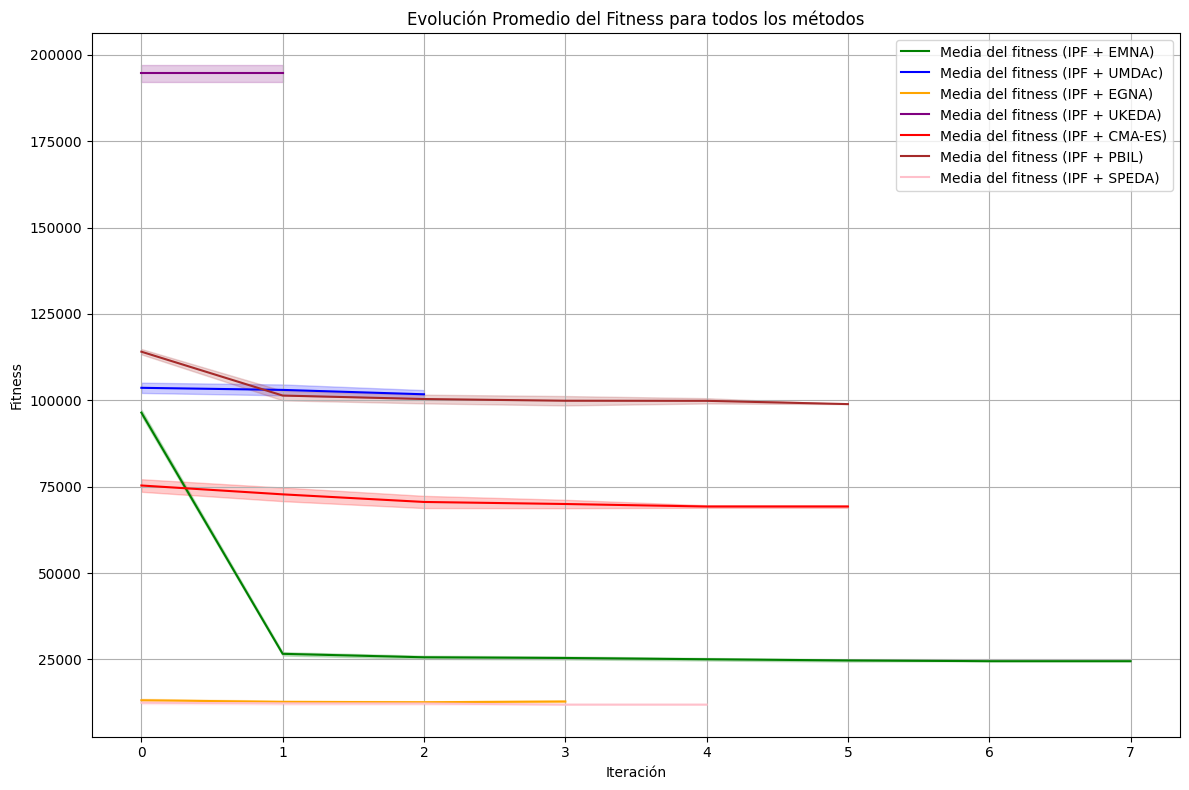

In [ ]:
plt.figure(figsize=(12, 8))

for history_list, label, color in zip(all_histories, labels, colors):
    max_len = max(len(h) for h in history_list)
    history_array = np.array([np.pad(h, (0, max_len - len(h)), constant_values=np.nan) for h in history_list])

    mean_fitness = np.nanmean(history_array, axis=0)
    std_fitness = np.nanstd(history_array, axis=0)

    plt.plot(mean_fitness, label=f'Media del fitness ({label})', color=color)
    plt.fill_between(range(max_len),
                     mean_fitness - std_fitness,
                     mean_fitness + std_fitness,
                     color=color, alpha=0.2)

plt.title('Evolución Promedio del Fitness para todos los métodos')
plt.xlabel('Iteración')
plt.ylabel('Fitness')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# PRUEBAS IPF vs IPF+EDAs 4 DIM


Tensor inicial (antes de ajustar):

Márgenes por filas (dim 0):
[26270 50970 49768 36398 33242 42707 47331 35064 37013]

Márgenes por columnas (dim 1):
[62804 48240 34891 32443 30682 34123 61327 23637 30616]

Márgenes por profundidad (dim 2):
[29249 46682 35521 38587 31869 47448 50982 52516 25909]

Márgenes por profundidad 4D (dim 3):
[36957 29019 23038 60097 44721 63650 25258 24274 51749]

🔹 Ejecutando experimento 1/8...
IT: 1 	Best cost: 116987724
IT: 2 	Best cost: 1772827
IT: 3 	Best cost: 1758329
IT: 4 	Best cost: 1758327
IT: 5 	Best cost: 1758327
IT: 6 	Best cost: 1758327
IT: 7 	Best cost: 1758327
Convergencia alcanzada.
📌 IPF Deming - Fitness final: 1758328.00, Tiempo: 0.00s
[Feinberg 4D] IT: 1 	Best cost: 116987724
[Feinberg 4D] IT: 2 	Best cost: 1772827
[Feinberg 4D] IT: 3 	Best cost: 1758329
[Feinberg 4D] IT: 4 	Best cost: 1758327
[Feinberg 4D] IT: 5 	Best cost: 1758327
[Feinberg 4D] IT: 6 	Best cost: 1758327
[Feinberg 4D] IT: 7 	Best cost: 1758327
[Feinberg 4D] IT: 8 	Best c

<ipython-input-13-e50d47bd7a3e>:138: RuntimeWarning: invalid value encountered in log
  return np.sum(tensor * np.log((tensor + epsilon) / expected))


Se han truncado las últimas 5000 líneas del flujo de salida.
  [[ 7.33019361e+01  3.98590641e+01  1.40815911e+01 ...  3.21278787e+01
     4.39012115e+01  7.15379083e+01]
   [ 1.19986282e+02  7.83555331e+01  2.52361898e+01 ...  7.84137411e+01
     7.40705870e+01  1.66414957e+01]
   [ 1.94876541e+01  7.57706099e+00  3.82505782e+01 ...  5.75378481e+01
     2.49444563e+01  1.16954781e+02]
   ...
   [ 1.16715229e+02  6.86410708e+01  5.45343865e+01 ...  4.88699468e+01
     4.25002228e+01  2.20387415e+02]
   [ 1.36519019e+02  3.99427053e+01  2.46036615e+01 ...  9.71822103e+01
     2.93493974e+01  1.64378098e+02]
   [ 3.30111078e+01  3.43245548e+01  3.79933591e+01 ...  5.62746934e+01
     2.03956584e+01  6.68317953e+01]]

  [[ 1.73284637e+01  1.52530396e+01  1.53857008e+01 ...  2.28774930e+01
     2.47099482e+01  2.23254747e+01]
   [ 1.53303142e+01  2.31124097e+01  2.89350392e+01 ...  2.44912599e+01
     2.87008150e+01  2.21413885e+01]
   [ 1.97241059e+01  1.82253415e+01  1.75023777e+01 ...  1

<ipython-input-13-e50d47bd7a3e>:1080: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


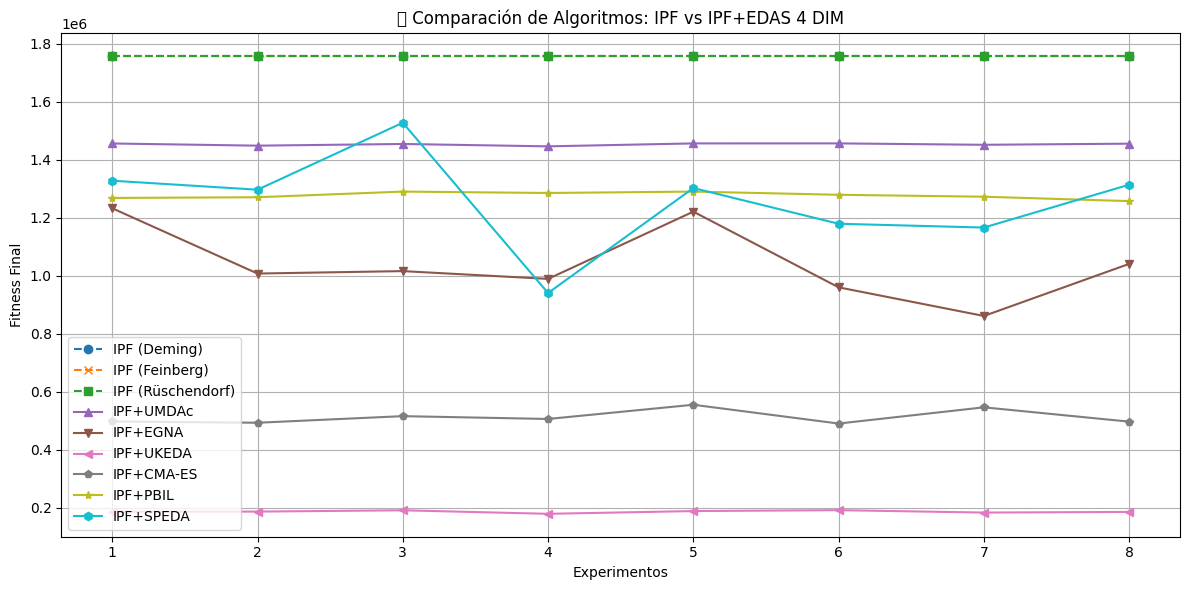


🔹 Resultados Finales por Experimento:
   Experimento  IPF (Deming)  IPF (Feinberg)  IPF (Rüschendorf)     IPF+UMDAc  \
0            1  1.758328e+06    1.758328e+06       1.758328e+06  1.455742e+06   
1            2  1.758328e+06    1.758328e+06       1.758328e+06  1.448249e+06   
2            3  1.758328e+06    1.758328e+06       1.758328e+06  1.454073e+06   
3            4  1.758328e+06    1.758328e+06       1.758328e+06  1.445888e+06   
4            5  1.758328e+06    1.758328e+06       1.758328e+06  1.456018e+06   
5            6  1.758328e+06    1.758328e+06       1.758328e+06  1.456069e+06   
6            7  1.758328e+06    1.758328e+06       1.758328e+06  1.451259e+06   
7            8  1.758328e+06    1.758328e+06       1.758328e+06  1.455117e+06   

       IPF+EGNA    IPF+UKEDA   IPF+CMA-ES      IPF+PBIL     IPF+SPEDA  
0  1.232309e+06  186123.9804  497199.2358  1.267965e+06  1.327442e+06  
1  1.007260e+06  186479.5444  492816.3336  1.270397e+06  1.296360e+06  
2  1.015713e+06

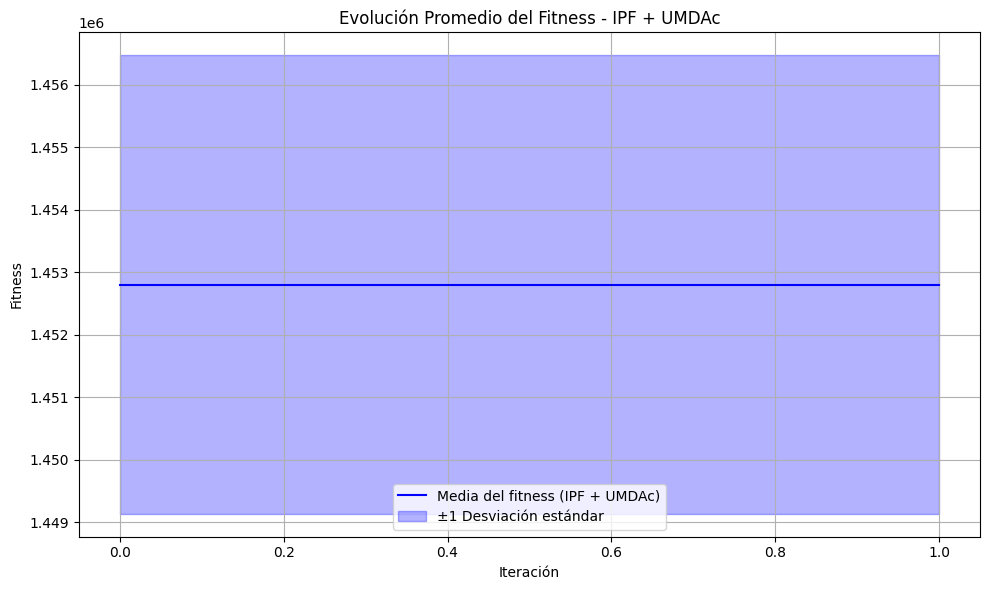

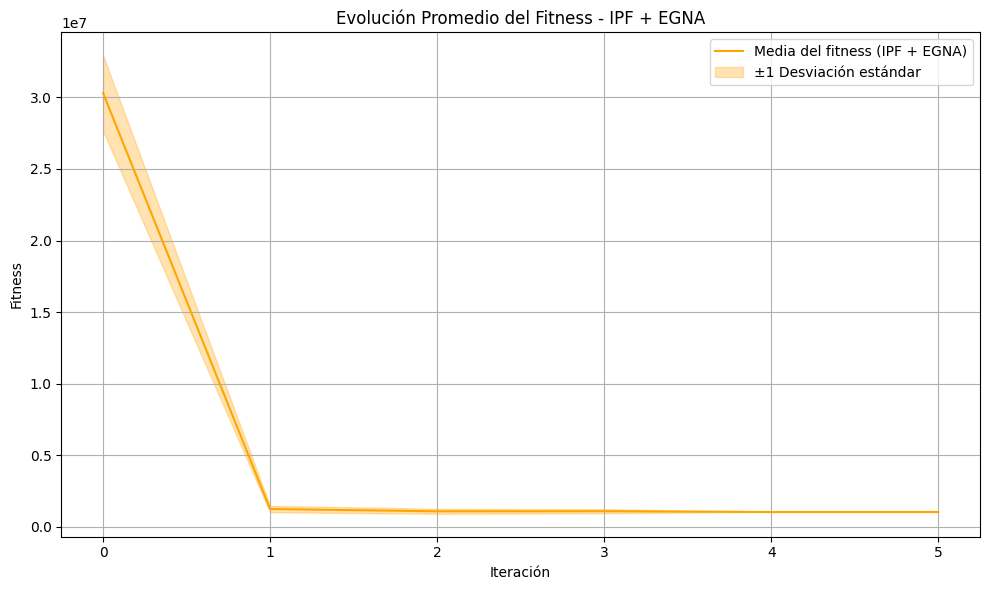

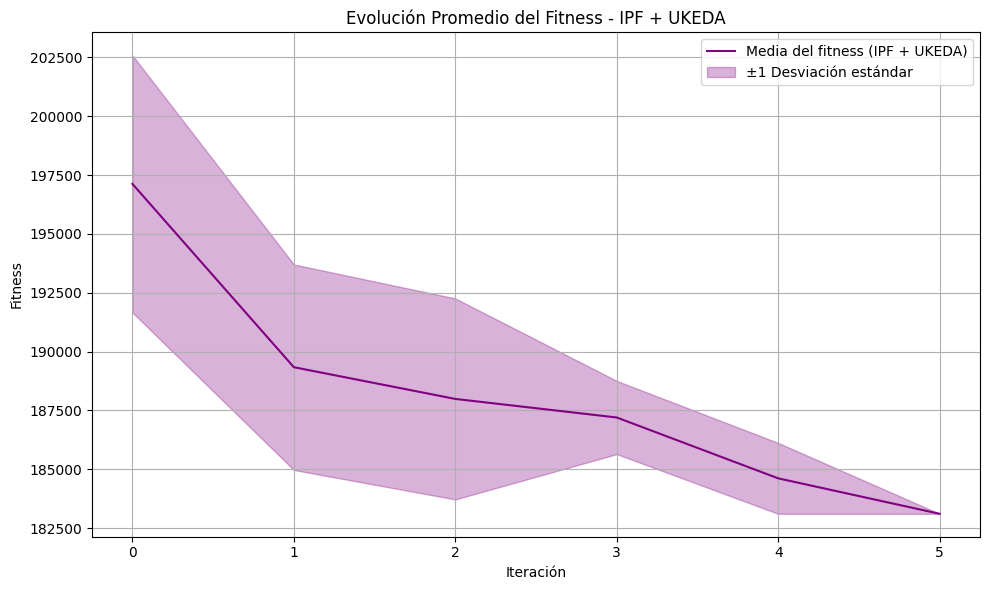

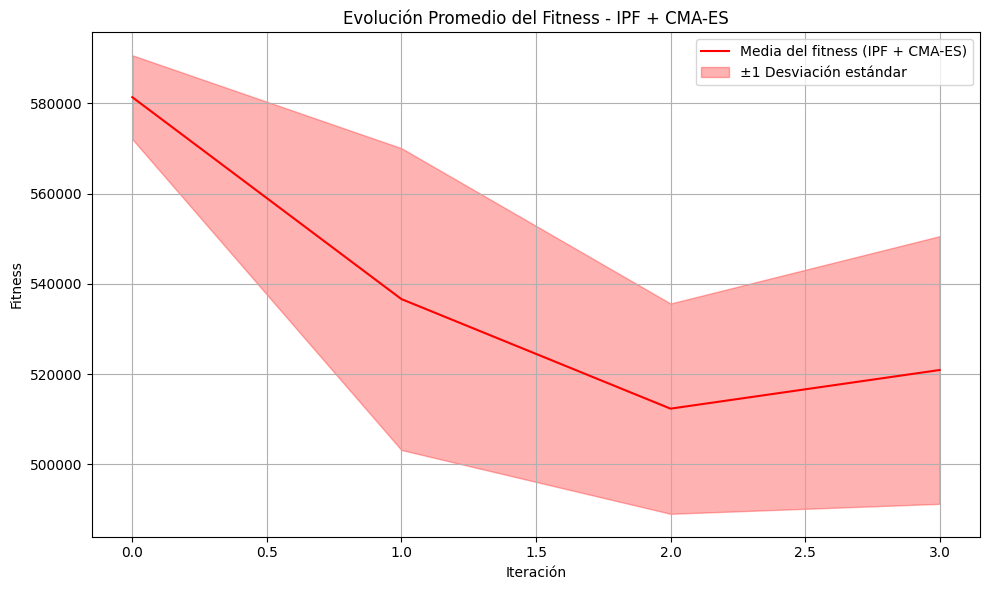

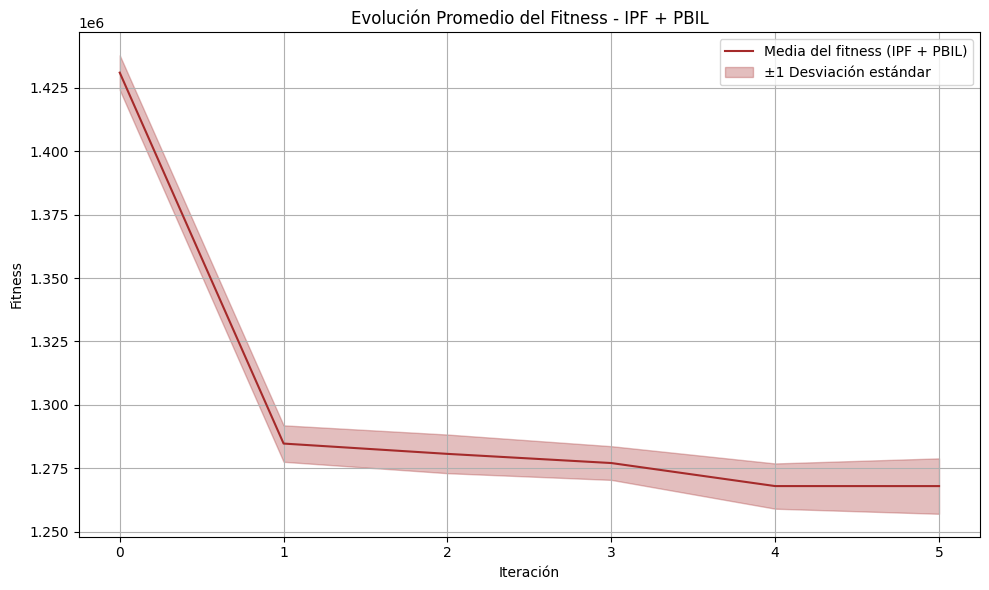

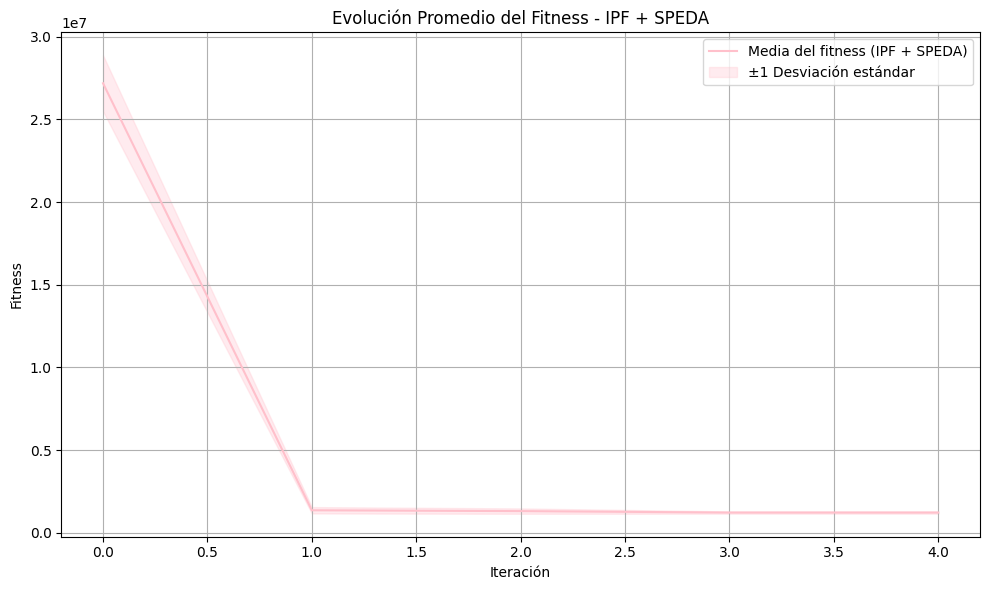

In [ ]:
import numpy as np
import matplotlib.pyplot as pltho
import matplotlib.pyplot as plt
import time, cma
import pandas as pd
from EDAspy.optimization import EMNA, UMDAc, EGNA

# Parámetros generales
num_experiments = 8  # Número de experimentos
iterations = 25  # Número de iteraciones
dimensions = (9, 9, 9, 9)  # Dimensiones del tensor (4D)


def generate_tensor_margins_4d(dimensions, total_sum=np.random.randint(200000, 400000)):
    # Márgenes para cada dimensión
    margin_0 = np.random.randint(10000, 30000, size=dimensions[0])
    margin_0 = np.round(margin_0 / margin_0.sum() * total_sum).astype(int)

    margin_1 = np.random.randint(10000, 30000, size=dimensions[1])
    margin_1 = np.round(margin_1 / margin_1.sum() * total_sum).astype(int)

    margin_2 = np.random.randint(10000, 30000, size=dimensions[2])
    margin_2 = np.round(margin_2 / margin_2.sum() * total_sum).astype(int)

    margin_3 = np.random.randint(10000, 30000, size=dimensions[3])
    margin_3 = np.round(margin_3 / margin_3.sum() * total_sum).astype(int)

    # Asegurarse de que los márgenes sumen el total deseado
    margin_0[-1] += total_sum - margin_0.sum()
    margin_1[-1] += total_sum - margin_1.sum()
    margin_2[-1] += total_sum - margin_2.sum()
    margin_3[-1] += total_sum - margin_3.sum()

    return margin_0, margin_1, margin_2, margin_3

def normalize_tensor_4d(tensor, margin0, margin1, margin2, margin3, max_iters=10, tol=1e-6):
    for _ in range(max_iters):
        prev_tensor = tensor.copy()
        tensor = tensor.astype(float)

        sum0 = tensor.sum(axis=(1, 2, 3), keepdims=True)
        tensor *= margin0[:, None, None, None] / (sum0 + 1e-10)

        sum1 = tensor.sum(axis=(0, 2, 3), keepdims=True)
        tensor *= margin1[None, :, None, None] / (sum1 + 1e-10)

        sum2 = tensor.sum(axis=(0, 1, 3), keepdims=True)
        tensor *= margin2[None, None, :, None] / (sum2 + 1e-10)

        sum3 = tensor.sum(axis=(0, 1, 2), keepdims=True)
        tensor *= margin3[None, None, None, :] / (sum3 + 1e-10)

        diff = ((tensor - prev_tensor) ** 2).sum()
        if diff < tol:
            break

    return tensor

def generate_non_negative_tensor_4d(mean_tensor, std_tensor, max_retries=100):
    dim1, dim2, dim3, dim4 = mean_tensor.shape
    tensor = np.random.normal(mean_tensor, std_tensor)

    for i in range(dim1):
        for j in range(dim2):
            for k in range(dim3):
                for l in range(dim4):
                    retries = 0
                    while tensor[i, j, k, l] < 0 and retries < max_retries:
                        tensor[i, j, k, l] = np.random.normal(mean_tensor[i, j, k, l], std_tensor[i, j, k, l])
                        retries += 1
                    if tensor[i, j, k, l] < 0:
                        tensor[i, j, k, l] = 0  # Si sigue siendo negativo, lo fijamos a 0
    return tensor

def combined_penalty(tensor, margin_0, margin_1, margin_2, margin_3, initial_tensor, alpha=60, beta=10):
    row_diff = np.abs(tensor.sum(axis=(1, 2, 3)) - margin_0)
    col_diff = np.abs(tensor.sum(axis=(0, 2, 3)) - margin_1)
    depth_diff = np.abs(tensor.sum(axis=(0, 1, 3)) - margin_2)
    depth_4d_diff = np.abs(tensor.sum(axis=(0, 1, 2)) - margin_3)

    margin_penalty = np.sum(row_diff**2) + np.sum(col_diff**2) + np.sum(depth_diff**2) + np.sum(depth_4d_diff**2)
    similarity_penalty = np.sum(np.abs(tensor - initial_tensor))

    return alpha * margin_penalty + beta * similarity_penalty

def fitness_function_4d(tensor, margin_0, margin_1, margin_2, margin_3, initial_tensor):
    return combined_penalty(tensor, margin_0, margin_1, margin_2, margin_3, initial_tensor)


def ipf_deming_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor,
                  tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    best_costs = []

    for it in range(max_iterations):
        # --- Ajuste para la dimensión 0 ---
        sum0 = tensor.sum(axis=(1, 2, 3))
        sum0[sum0 == 0] = 1e-10
        tensor *= (margin0[:, None, None, None] / sum0[:, None, None, None])

        # --- Ajuste para la dimensión 1 ---
        sum1 = tensor.sum(axis=(0, 2, 3))
        sum1[sum1 == 0] = 1e-10
        tensor *= (margin1[None, :, None, None] / sum1[None, :, None, None])

        # --- Ajuste para la dimensión 2 ---
        sum2 = tensor.sum(axis=(0, 1, 3))
        sum2[sum2 == 0] = 1e-10
        tensor *= (margin2[None, None, :, None] / sum2[None, None, :, None])

        # --- Ajuste para la dimensión 3 ---
        sum3 = tensor.sum(axis=(0, 1, 2))
        sum3[sum3 == 0] = 1e-10
        tensor *= (margin3[None, None, None, :] / sum3[None, None, None, :])

        # --- Evaluar el fitness ---
        current_cost = fitness_function_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor)
        best_costs.append(current_cost)

        print(f"IT: {it + 1} \tBest cost: {int(current_cost)}")

        # Criterio de convergencia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    # Redondear y finalizar
    tensor = np.round(tensor).astype(int)
    execution_time = time.time() - start_time
    return tensor, execution_time, best_costs


def log_likelihood_4d(tensor, margin0, margin1, margin2, margin3):
    epsilon = 1e-10
    total = margin0.sum()
    expected = np.einsum('i,j,k,l->ijkl', margin0, margin1, margin2, margin3) / (total**3)
    return np.sum(tensor * np.log((tensor + epsilon) / expected))


def ipf_fienberg_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor,
                    tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    prev_ll = log_likelihood_4d(tensor, margin0, margin1, margin2, margin3)
    best_costs = []

    for it in range(max_iterations):
        # --- Ajuste para la dimensión 0 ---
        sum0 = tensor.sum(axis=(1, 2, 3))
        tensor *= margin0[:, None, None, None] / (sum0[:, None, None, None] + 1e-10)

        # --- Ajuste para la dimensión 1 ---
        sum1 = tensor.sum(axis=(0, 2, 3))
        tensor *= margin1[None, :, None, None] / (sum1[None, :, None, None] + 1e-10)

        # --- Ajuste para la dimensión 2 ---
        sum2 = tensor.sum(axis=(0, 1, 3))
        tensor *= margin2[None, None, :, None] / (sum2[None, None, :, None] + 1e-10)

        # --- Ajuste para la dimensión 3 ---
        sum3 = tensor.sum(axis=(0, 1, 2))
        tensor *= margin3[None, None, None, :] / (sum3[None, None, None, :] + 1e-10)

        # Evaluación
        new_ll = log_likelihood_4d(tensor, margin0, margin1, margin2, margin3)
        best_cost = fitness_function_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor)
        best_costs.append(best_cost)

        print(f"[Feinberg 4D] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if abs(new_ll - prev_ll) < tol:
            print("Convergencia alcanzada.")
            break

        prev_ll = new_ll

    execution_time = time.time() - start_time
    return np.round(tensor).astype(int), execution_time, best_costs


# KL divergencia simétrica para 4D
def kl_symmetric_divergence_4d(p, q):
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    return np.sum(p * np.log(p / q) + q * np.log(q / p))

# IPF con criterio de convergencia basado en Rüschendorf para 4D
def ipf_ruschendorf_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor,
                       tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    prev_tensor = tensor.copy()
    best_costs = []

    for it in range(max_iterations):
        # Ajuste dimensión 0
        sum0 = tensor.sum(axis=(1, 2, 3))
        tensor *= margin0[:, None, None, None] / (sum0[:, None, None, None] + 1e-10)

        # Ajuste dimensión 1
        sum1 = tensor.sum(axis=(0, 2, 3))
        tensor *= margin1[None, :, None, None] / (sum1[None, :, None, None] + 1e-10)

        # Ajuste dimensión 2
        sum2 = tensor.sum(axis=(0, 1, 3))
        tensor *= margin2[None, None, :, None] / (sum2[None, None, :, None] + 1e-10)

        # Ajuste dimensión 3
        sum3 = tensor.sum(axis=(0, 1, 2))
        tensor *= margin3[None, None, None, :] / (sum3[None, None, None, :] + 1e-10)

        # Evaluación del coste
        best_cost = fitness_function_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor)
        best_costs.append(best_cost)

        print(f"[Rüschendorf 4D] IT: {it + 1} \tBest cost: {int(best_cost)}")

        # Criterio de parada: divergencia KL simétrica
        if kl_symmetric_divergence_4d(tensor, prev_tensor) < tol:
            print("Convergencia alcanzada.")
            break

        prev_tensor = tensor.copy()

    execution_time = time.time() - start_time
    return np.round(tensor).astype(int), execution_time, best_costs

def local_search_with_noise_tensor_4d(X, margins, initial_tensor, shape, normalize_tensor,
                                     alpha=60, beta=10, trials=30, std=0.01):
    best_X = X.copy()
    best_tensor = normalize_tensor(X.reshape(shape), *margins)
    best_fitness = combined_penalty(best_tensor, *margins, initial_tensor, alpha, beta)
    best_perturbed_X = X.copy()
    improved = False

    for _ in range(trials):
        noise = np.random.normal(0, std, size=X.shape)
        perturbed_X = X + X * noise
        tensor = normalize_tensor(perturbed_X.reshape(shape), *margins)
        fitness = combined_penalty(tensor, *margins, initial_tensor, alpha, beta)

        if fitness < best_fitness:
            best_fitness = fitness
            best_X = tensor.flatten()
            best_perturbed_X = perturbed_X.copy()
            improved = True

    if improved:
        print("\nMejor 'perturbed_X':")
        print(best_perturbed_X.reshape(shape))
        print("Fitness tras local search:", best_fitness)
    else:
        print("\nLocal search no mejoró el fitness.")

    return best_X.reshape(shape), best_fitness, best_perturbed_X.reshape(shape), improved


#UMDAc
def run_umdac_tensor_4d(margins, shape, iterations, initial_tensor,
                        alpha=60, beta=10, local_search_trials=30, local_search_std=0.01):
    n_variables = np.prod(shape)
    upper_bound = max([m.max() for m in margins])

    umdac = UMDAc(size_gen=100, max_iter=iterations, dead_iter=10,
                  n_variables=n_variables, lower_bound=1, upper_bound=upper_bound)

    def fitness_function(individual):
        tensor = individual.reshape(shape)
        tensor = normalize_tensor_4d(tensor, *margins)
        return combined_penalty(tensor, *margins, initial_tensor, alpha, beta)

    start_time = time.time()
    result = umdac.minimize(fitness_function)
    end_time = time.time()

    best_tensor = result.best_ind.reshape(shape)
    best_tensor = normalize_tensor_4d(best_tensor, *margins)
    final_fitness = combined_penalty(best_tensor, *margins, initial_tensor, alpha, beta)
    execution_time = end_time - start_time

    # --- Aquí aplicamos la búsqueda local con ruido ---
    best_flat = best_tensor.flatten()
    best_tensor_ls, best_fitness_ls, best_perturbed_ls, improved = local_search_with_noise_tensor_4d(
        best_flat, margins, initial_tensor, shape, normalize_tensor_4d,
        alpha=alpha, beta=beta, trials=local_search_trials, std=local_search_std
    )

    # Si la búsqueda local mejora el resultado, actualizamos los valores
    if improved and best_fitness_ls < final_fitness:
        best_tensor = best_tensor_ls
        final_fitness = best_fitness_ls

    return best_tensor, np.array(result.history), final_fitness, execution_time


def iterative_proportional_fitting_plus_umdac_tensor_4d(tensor, margins, initial_tensor, iterations=10, tol=1e-6):
    tensor = np.copy(tensor).astype(float)
    best_costs = []
    start_time = time.time()

    margin0, margin1, margin2, margin3 = margins

    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = combined_penalty(best_tensor_so_far, *margins, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 4D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None, None] / (tensor.sum(axis=(1, 2, 3), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None, None] / (tensor.sum(axis=(0, 2, 3), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :, None] / (tensor.sum(axis=(0, 1, 3), keepdims=True) + 1e-10))
        tensor *= (margin3[None, None, None, :] / (tensor.sum(axis=(0, 1, 2), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con UMDAc
        refined_tensor, history, refined_fitness, execution_time_umdac = run_umdac_tensor_4d(margins, tensor.shape, 30, tensor)

        # Actualizamos el tensor y el coste si la mejora de UMDAc es significativa
        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos el tensor actual y su coste
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far  # No se cambia el fitness, seguimos con IPF

        # Criterio de parada: si la diferencia entre los costes consecutivos es menor que la tolerancia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Devolver el mejor tensor encontrado, el tiempo de ejecución y los costes
    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs


# EGNA 4D
def run_egna_tensor_4d(base_tensor, row_margins, col_margins, depth_margins, depth_4d_margins, initial_tensor,
                       population_size=50, num_generations=25, elite_size=10, noise_level=5, lambda_=0.7,
                       local_search_trials=30, local_search_std=0.01, ls_alpha=60, ls_beta=10):
    base_tensor = np.array(base_tensor)
    shape = base_tensor.shape

    current_population = [
        generate_non_negative_tensor_4d(base_tensor, np.full_like(base_tensor, noise_level))
        for _ in range(population_size)
    ]

    history = []
    global_best_fitness = float('inf')
    global_best_tensor = None

    for gen in range(num_generations):
        fitness_scores = [
            float(fitness_function_4d(np.round(ind).astype(int), row_margins, col_margins, depth_margins, depth_4d_margins, initial_tensor))
            for ind in current_population
        ]

        current_best_fitness = min(fitness_scores)
        best_index = np.argmin(fitness_scores)
        current_best_tensor = np.round(current_population[best_index]).astype(int)

        if current_best_fitness < global_best_fitness:
            global_best_fitness = current_best_fitness
            global_best_tensor = current_best_tensor

        history.append(global_best_fitness)
        print(f"EGNA 4D - Generación {gen+1}: Best fitness = {global_best_fitness:.4f}")

        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)

        mean_elite = np.mean(elite_array, axis=0)
        std_elite = np.std(elite_array, axis=0)

        base_tensor = lambda_ * base_tensor + (1 - lambda_) * mean_elite

        current_population = [
            generate_non_negative_tensor_4d(base_tensor, std_elite)
            for _ in range(population_size)
        ]

    # === Búsqueda local ===
    best_tensor_ls, fitness_ls, perturbed_tensor_ls, improved = local_search_with_noise_tensor_4d(
        global_best_tensor.flatten(),  # Aplanar para la función
        [row_margins, col_margins, depth_margins, depth_4d_margins],
        initial_tensor,
        shape,
        normalize_tensor_4d,
        alpha=ls_alpha,
        beta=ls_beta,
        trials=local_search_trials,
        std=local_search_std
    )

    if improved and fitness_ls < global_best_fitness:
        global_best_tensor = best_tensor_ls
        global_best_fitness = fitness_ls

    return global_best_tensor, -np.array(history), global_best_fitness


def iterative_proportional_fitting_plus_egna_tensor_4d(tensor, margins, initial_tensor, iterations=10, tol=1e-6):
    tensor = np.copy(tensor).astype(float)
    best_costs = []
    start_time = time.time()

    margin0, margin1, margin2, margin3 = margins

    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = combined_penalty(best_tensor_so_far, *margins, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 4D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None, None] / (tensor.sum(axis=(1, 2, 3), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None, None] / (tensor.sum(axis=(0, 2, 3), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :, None] / (tensor.sum(axis=(0, 1, 3), keepdims=True) + 1e-10))
        tensor *= (margin3[None, None, None, :] / (tensor.sum(axis=(0, 1, 2), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con EGNA
        refined_tensor, history, refined_fitness = run_egna_tensor_4d(tensor, row_margins, col_margins, depth_margins, depth_4d_margins, tensor)

        # Actualizamos el tensor y el coste si la mejora de EGNA es significativa
        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos el tensor actual y su coste
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far  # No se cambia el fitness, seguimos con IPF

        # Criterio de parada: si la diferencia entre los costes consecutivos es menor que la tolerancia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Devolver el mejor tensor encontrado, el tiempo de ejecución y los costes
    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs

#uKEDA
def run_univariate_keda_tensor_4d(base_tensor, margin0, margin1, margin2, margin3, initial_tensor,
                                   population_size=50, num_generations=20, elite_size=10, noise_level=3,
                                   alpha=60, beta=10, local_search_trials=30, local_search_std=0.01):
    shape = base_tensor.shape  # (dim0, dim1, dim2, dim3)

    # Inicializa la población con ruido y normalización
    current_population = [
        normalize_tensor_4d(
            generate_non_negative_tensor_4d(base_tensor, np.full_like(base_tensor, noise_level)),
            margin0, margin1, margin2, margin3
        )
        for _ in range(population_size)
    ]

    history = []
    prev_best_fitness = float('inf')

    for gen in range(num_generations):
        fitness_scores = [
            fitness_function_4d(np.round(ind).astype(int), margin0, margin1, margin2, margin3, initial_tensor)
            for ind in current_population]

        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)

        mean = np.mean(elite_array, axis=0)
        std = np.std(elite_array, axis=0)

        current_population = [
            normalize_tensor_4d(
                generate_non_negative_tensor_4d(mean, std),
                margin0, margin1, margin2, margin3)
            for _ in range(population_size)]

        best_fitness = np.min(fitness_scores)
        if best_fitness > prev_best_fitness:
            best_fitness = prev_best_fitness

        prev_best_fitness = best_fitness
        history.append(best_fitness)

        print(f"Univariate KEDA 4D - Generación {gen+1}: Best fitness = {best_fitness:.6f}")

    # Mejor tensor de la última población
    best_index = np.argmin(fitness_scores)
    best_tensor = current_population[best_index]

    # Aplicar búsqueda local con ruido
    best_flat = best_tensor.flatten()
    best_tensor_ls, best_fitness_ls, best_perturbed_ls, improved = local_search_with_noise_tensor_4d(
        best_flat, [margin0, margin1, margin2, margin3], initial_tensor,
        shape, normalize_tensor_4d, alpha=alpha, beta=beta,
        trials=local_search_trials, std=local_search_std)

    if improved and best_fitness_ls < best_fitness:
        final_tensor = best_tensor_ls
        final_fitness = best_fitness_ls
    else:
        final_tensor = np.round(best_tensor).astype(int)
        final_fitness = best_fitness

    return final_tensor, history, final_fitness


def iterative_proportional_fitting_plus_keda_tensor_4d(tensor, margins, initial_tensor, iterations=10, tol=1e-6):
    tensor = tensor.astype(float)
    best_costs = []
    start_time = time.time()

    margin0, margin1, margin2, margin3 = margins
    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = combined_penalty(best_tensor_so_far, margin0, margin1, margin2, margin3, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 4D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None, None] / (tensor.sum(axis=(1, 2, 3), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None, None] / (tensor.sum(axis=(0, 2, 3), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :, None] / (tensor.sum(axis=(0, 1, 3), keepdims=True) + 1e-10))
        tensor *= (margin3[None, None, None, :] / (tensor.sum(axis=(0, 1, 2), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        refined_tensor, history, refined_fitness = run_univariate_keda_tensor_4d(tensor, *margins, tensor)

        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            best_costs.append(best_fitness_so_far)

        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs

#PBIL 4D
def run_pbil_continuous_tensor_4d(margins, tensor_shape, iterations, initial_tensor,
                                  size_gen=100, learning_rate=0.01,
                                  alpha=60, beta=10, local_search_trials=30, local_search_std=0.01):
    n_variables = np.prod(tensor_shape)

    lower_bound = np.ones(n_variables)
    upper_bound = np.full(n_variables, max([m.max() for m in margins]))

    prob_vector = (lower_bound + upper_bound) / 2.0
    std_dev = (upper_bound - lower_bound) / 6

    def fitness_function(individual):
        tensor = individual.reshape(tensor_shape)
        tensor = normalize_tensor_4d(tensor, *margins)
        return combined_penalty(tensor, *margins, initial_tensor)

    best_fitness = float('inf')
    best_solution = None
    fitness_history = []

    for iter in range(iterations):
        population = np.random.normal(loc=prob_vector, scale=std_dev, size=(size_gen, n_variables))
        population = np.clip(population, lower_bound, upper_bound)

        fitness_values = np.array([fitness_function(ind) for ind in population])
        best_idx = np.argmin(fitness_values)
        best_individual = population[best_idx]

        if fitness_values[best_idx] < best_fitness:
            best_fitness = fitness_values[best_idx]
            best_solution = best_individual.copy()

        prob_vector = (1 - learning_rate) * prob_vector + learning_rate * best_individual
        fitness_history.append(best_fitness)

        print(f"PBIL IT {iter+1} - Best cost: {best_fitness:.4f}")

    # Aplicar búsqueda local con ruido al mejor tensor encontrado
    best_flat = best_solution.flatten()
    best_tensor_ls, best_fitness_ls, best_perturbed_ls, improved = local_search_with_noise_tensor_4d(
        best_flat, margins, initial_tensor, tensor_shape,
        normalize_tensor_4d, alpha=alpha, beta=beta, trials=local_search_trials, std=local_search_std)

    if improved and best_fitness_ls < best_fitness:
        final_tensor = best_tensor_ls
        final_fitness = best_fitness_ls
    else:
        final_tensor = best_solution.reshape(tensor_shape)
        final_fitness = best_fitness

    return final_tensor, fitness_history, final_fitness


def iterative_proportional_fitting_plus_pbil_tensor_4d(tensor, margins, initial_tensor, iterations=10, tol=1e-6):
    tensor = tensor.astype(float)
    best_costs = []
    start_time = time.time()

    margin0, margin1, margin2, margin3 = margins

    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = combined_penalty(best_tensor_so_far, *margins, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 4D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None, None] / (tensor.sum(axis=(1, 2, 3), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None, None] / (tensor.sum(axis=(0, 2, 3), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :, None] / (tensor.sum(axis=(0, 1, 3), keepdims=True) + 1e-10))
        tensor *= (margin3[None, None, None, :] / (tensor.sum(axis=(0, 1, 2), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        refined_tensor, history, refined_fitness = run_pbil_continuous_tensor_4d(margins,tensor.shape,20,tensor)

        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            best_costs.append(best_fitness_so_far)

        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs

#CMAES
def cmaes_4d_optimization(base_tensor, margin0, margin1, margin2, margin3, initial_tensor,
                          sigma=10, population_size=50, generations=20,
                          alpha=60, beta=10, local_search_trials=30, local_search_std=0.01):
    shape = base_tensor.shape
    n_variables = np.prod(shape)
    initial_flat = base_tensor.flatten().astype(float)

    es = cma.CMAEvolutionStrategy(initial_flat, sigma, {
        'popsize': population_size,
        'maxiter': generations,
        'verb_log': 0,
        'verb_disp': 0,
    })

    history = []
    best_fitness = float('inf')
    best_solution = None

    start_time = time.time()

    while not es.stop():
        solutions = es.ask()
        fitnesses = []

        for s in solutions:
            tensor = s.reshape(shape)
            tensor = np.clip(tensor, 0, None)  # Evita negativos
            tensor = normalize_tensor_4d(tensor, margin0, margin1, margin2, margin3)
            fitness = fitness_function_4d(np.round(tensor).astype(int), margin0, margin1, margin2, margin3, initial_tensor)
            fitnesses.append(fitness)

            if fitness < best_fitness:
                best_fitness = fitness
                best_solution = tensor.copy()

        es.tell(solutions, fitnesses)
        history.append(best_fitness)

        print(f"CMA-ES 4D - Generación {len(history)}: Best fitness = {best_fitness:.6f}")

        if len(history) >= generations:
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Aplicar búsqueda local con ruido al mejor tensor encontrado
    best_flat = best_solution.flatten()
    best_tensor_ls, best_fitness_ls, best_perturbed_ls, improved = local_search_with_noise_tensor_4d(
        best_flat,
        [margin0, margin1, margin2, margin3],
        initial_tensor,
        shape,
        normalize_tensor_4d,
        alpha=alpha,
        beta=beta,
        trials=local_search_trials,
        std=local_search_std
    )

    if improved and best_fitness_ls < best_fitness:
        final_tensor = best_tensor_ls
        final_fitness = best_fitness_ls
    else:
        final_tensor = np.round(best_solution).astype(int)
        final_fitness = best_fitness

    return final_tensor, history, final_fitness, execution_time


def iterative_proportional_fitting_plus_cmaes_tensor_4d(tensor, margins, initial_tensor, iterations=10, tol=1e-6):
    tensor = np.copy(tensor).astype(float)
    best_costs = []
    start_time = time.time()

    margin0, margin1, margin2, margin3 = margins

    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = combined_penalty(best_tensor_so_far, *margins, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 4D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None, None] / (tensor.sum(axis=(1, 2, 3), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None, None] / (tensor.sum(axis=(0, 2, 3), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :, None] / (tensor.sum(axis=(0, 1, 3), keepdims=True) + 1e-10))
        tensor *= (margin3[None, None, None, :] / (tensor.sum(axis=(0, 1, 2), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        refined_tensor, history, refined_fitness, execution_time_cmaes = cmaes_4d_optimization(
            tensor, margin0, margin1, margin2, margin3, tensor)


        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            best_costs.append(best_fitness_so_far)

        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs

#SPEDA
def speda_4d_optimization(base_tensor, row_margins, col_margins, depth_margins, depth4d_margins, initial_tensor,
                          population_size=50, num_generations=25, elite_size=10, alpha=0.7, noise_level=5,
                          local_search_trials=30, local_search_std=0.01, ls_alpha=60, ls_beta=10):
    shape = base_tensor.shape

    current_population = [
        generate_non_negative_tensor_4d(base_tensor, np.full_like(base_tensor, noise_level))
        for _ in range(population_size)
    ]

    best_fitness = float('inf')
    best_tensor = None
    history = []

    for gen in range(num_generations):
        fitness_scores = [
            fitness_function_4d(np.round(ind).astype(int), row_margins, col_margins, depth_margins, depth4d_margins, initial_tensor)
            for ind in current_population
        ]

        elite_indices = np.argsort(fitness_scores)[:elite_size]
        elite = [current_population[i] for i in elite_indices]
        elite_array = np.array(elite)

        mean_elite = np.mean(elite_array, axis=0)
        std_elite = np.std(elite_array, axis=0)

        base_tensor = alpha * base_tensor + (1 - alpha) * mean_elite

        current_population = [
            generate_non_negative_tensor_4d(base_tensor, std_elite)
            for _ in range(population_size)]

        current_best_fitness = np.min(fitness_scores)
        if current_best_fitness < best_fitness:
            best_fitness = current_best_fitness
            best_tensor = current_population[np.argmin(fitness_scores)]

        print(f"SPEDA 4D Generación {gen+1}: Best fitness = {best_fitness:.6f}")
        history.append(best_fitness)

    # === Búsqueda local ===
    flat_best = best_tensor.flatten()
    best_tensor_ls, fitness_ls, perturbed_tensor_ls, improved = local_search_with_noise_tensor_4d(
        flat_best,
        [row_margins, col_margins, depth_margins, depth4d_margins],
        initial_tensor,
        shape,
        normalize_tensor_4d,
        alpha=ls_alpha,
        beta=ls_beta,
        trials=local_search_trials,
        std=local_search_std
    )

    if improved and fitness_ls < best_fitness:
        final_tensor = best_tensor_ls
        final_fitness = fitness_ls
    else:
        final_tensor = np.round(best_tensor).astype(int)
        final_fitness = best_fitness

    return final_tensor, history, final_fitness

def iterative_proportional_fitting_plus_speda_tensor_4d(tensor, margins, initial_tensor, iterations=10, tol=1e-6):
    tensor = np.copy(tensor).astype(float)
    best_costs = []
    start_time = time.time()

    margin0, margin1, margin2, margin3 = margins

    best_tensor_so_far = tensor.copy()
    best_fitness_so_far = combined_penalty(best_tensor_so_far, *margins, initial_tensor)

    for it in range(iterations):
        # Usamos el mejor tensor hasta ahora como punto de partida
        tensor = best_tensor_so_far.copy()

        # Paso IPF para 4D: Ajustamos el tensor con los márgenes de cada dimensión
        tensor *= (margin0[:, None, None, None] / (tensor.sum(axis=(1, 2, 3), keepdims=True) + 1e-10))
        tensor *= (margin1[None, :, None, None] / (tensor.sum(axis=(0, 2, 3), keepdims=True) + 1e-10))
        tensor *= (margin2[None, None, :, None] / (tensor.sum(axis=(0, 1, 3), keepdims=True) + 1e-10))
        tensor *= (margin3[None, None, None, :] / (tensor.sum(axis=(0, 1, 2), keepdims=True) + 1e-10))

        # Fitness después de IPF
        current_fitness = combined_penalty(tensor, *margins, initial_tensor)

        # Actualizamos si IPF mejora el mejor fitness global
        if current_fitness < best_fitness_so_far:
            best_fitness_so_far = current_fitness
            best_tensor_so_far = tensor.copy()

        print(f"\nIPF Iteración {it}: Best cost = {best_fitness_so_far:.2f}")

        # Refinamiento con SPEDA
        refined_tensor, history, refined_fitness = speda_4d_optimization(np.round(tensor).astype(int), margin0, margin1, margin2, margin3, tensor)

        # Actualizamos el tensor y el coste si la mejora de SPEDA es significativa
        if refined_fitness < best_fitness_so_far:
            best_tensor_so_far = refined_tensor.astype(float)
            best_fitness_so_far = refined_fitness
            best_costs.append(refined_fitness)
        else:
            # Si no mejora, mantenemos el tensor actual y su coste
            best_costs.append(best_fitness_so_far)
            refined_fitness = best_fitness_so_far  # No se cambia el fitness, seguimos con IPF

        # Criterio de parada: si la diferencia entre los costes consecutivos es menor que la tolerancia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            print("Convergencia alcanzada.")
            break

    end_time = time.time()
    execution_time = end_time - start_time

    # Devolver el mejor tensor encontrado, el tiempo de ejecución y los costes
    return np.round(best_tensor_so_far).astype(int), execution_time, best_costs


# Almacenar resultados
best_costs_deming, times_deming  = [], []
best_costs_fienberg, times_fienberg = [], []
best_costs_ruschendorf, times_ruschendorf = [], []

best_costs_umdac, times_umdac = [], []
best_costs_egna, times_egna = [], []
best_costs_keda, times_keda = [], []
best_costs_cmaes, times_cmaes = [], []
best_costs_pbil, times_pbil = [], []
best_costs_speda, times_speda = [], []

all_histories_speda, all_histories_umdac, all_histories_egna = [], [], []
all_histories_keda, all_histories_cmaes, all_histories_pbil= [], [], []


# Inicialización fija para todos los experimentos
initial_tensor = np.random.randint(20, 100, size=dimensions)

# Generación de los márgenes para las cuatro dimensiones
row_margins, col_margins, depth_margins, depth_4d_margins = generate_tensor_margins_4d(dimensions)

# Imprimir el tensor inicial y los márgenes
print("\nTensor inicial (antes de ajustar):")
#print(initial_tensor)

print("\nMárgenes por filas (dim 0):")
print(row_margins)
print("\nMárgenes por columnas (dim 1):")
print(col_margins)
print("\nMárgenes por profundidad (dim 2):")
print(depth_margins)
print("\nMárgenes por profundidad 4D (dim 3):")
print(depth_4d_margins)

# Repetir experimento
for i in range(num_experiments):
    print(f"\n🔹 Ejecutando experimento {i+1}/{num_experiments}...")

    margins = [row_margins, col_margins, depth_margins, depth_4d_margins]

    # IPF 4D (Deming)
    optimized_tensor_deming, time_deming, costs_deming = ipf_deming_4d(
        initial_tensor, row_margins, col_margins, depth_margins, depth_4d_margins, initial_tensor
    )
    best_costs_deming.append(costs_deming[-1])
    times_deming.append(time_deming)
    print(f"📌 IPF Deming - Fitness final: {costs_deming[-1]:.2f}, Tiempo: {time_deming:.2f}s")

    # IPF 4D (Feinberg)
    optimized_tensor_fienberg, time_fienberg, costs_fienberg = ipf_fienberg_4d(
        initial_tensor, row_margins, col_margins, depth_margins, depth_4d_margins, initial_tensor
    )
    best_costs_fienberg.append(costs_fienberg[-1])
    times_fienberg.append(time_fienberg)
    print(f"📌 IPF Feinberg - Fitness final: {costs_fienberg[-1]:.2f}, Tiempo: {time_fienberg:.2f}s")

    # IPF 4D (Rüschendorf)
    optimized_tensor_ruschendorf, time_ruschendorf, costs_ruschendorf = ipf_ruschendorf_4d(
        initial_tensor, row_margins, col_margins, depth_margins, depth_4d_margins, initial_tensor
    )
    best_costs_ruschendorf.append(costs_ruschendorf[-1])
    times_ruschendorf.append(time_ruschendorf)
    print(f"📌 IPF Rüschendorf - Fitness final: {costs_ruschendorf[-1]:.2f}, Tiempo: {time_ruschendorf:.2f}s")

    # IPF + UMDAC
    optimized_tensor_umdac, time_umdac, costs_umdac = iterative_proportional_fitting_plus_umdac_tensor_4d(
        initial_tensor, margins, initial_tensor
    )
    best_costs_umdac.append(costs_umdac[-1])
    times_umdac.append(time_umdac)
    all_histories_umdac.append(costs_umdac)
    print(f"📌 IPF + UMDAC - Fitness final: {costs_umdac[-1]:.2f}, Tiempo: {time_umdac:.2f}s")

    # IPF + EGNA
    optimized_tensor_egna, time_egna, costs_egna = iterative_proportional_fitting_plus_egna_tensor_4d(
        initial_tensor, margins, initial_tensor)
    best_costs_egna.append(costs_egna[-1])
    times_egna.append(time_egna)
    all_histories_egna.append(costs_egna)
    print(f"📌 IPF + EGNA - Fitness final: {costs_egna[-1]:.2f}, Tiempo: {time_egna:.2f}s")

    # IPF + Univariate KEDA
    optimized_tensor_keda, time_keda, costs_keda = iterative_proportional_fitting_plus_keda_tensor_4d(
        initial_tensor, margins, initial_tensor
    )
    best_costs_keda.append(costs_keda[-1])
    times_keda.append(time_keda)
    all_histories_keda.append(costs_keda)
    print(f"📌 IPF + Univariate KEDA - Fitness final: {costs_keda[-1]:.2f}, Tiempo: {time_keda:.2f}s")

    # Ejecutar IPF + PBIL
    optimized_tensor_pbil, time_pbil, costs_pbil = iterative_proportional_fitting_plus_pbil_tensor_4d(
        initial_tensor, margins, initial_tensor
    )
    best_costs_pbil.append(costs_pbil[-1])
    times_pbil.append(time_pbil)
    all_histories_pbil.append(costs_pbil)
    print(f"📌 IPF + Univariate PBIL - Fitness final: {costs_keda[-1]:.2f}, Tiempo: {time_keda:.2f}s")

    # IPF + CMA-ES
    optimized_tensor_cmaes, time_cmaes, costs_cmaes = iterative_proportional_fitting_plus_cmaes_tensor_4d(
        initial_tensor, margins, initial_tensor
    )
    best_costs_cmaes.append(costs_cmaes[-1])
    times_cmaes.append(time_cmaes)
    all_histories_cmaes.append(costs_cmaes)
    print(f"📌 IPF + CMA-ES - Fitness final: {costs_cmaes[-1]:.2f}, Tiempo: {time_cmaes:.2f}s")

    # IPF + SPEDA
    optimized_tensor_speda, time_speda, costs_speda = iterative_proportional_fitting_plus_speda_tensor_4d(
        initial_tensor, margins, initial_tensor
    )
    best_costs_speda.append(costs_speda[-1])
    times_speda.append(time_speda)
    all_histories_speda.append(costs_speda)
    print(f"📌 IPF + SPEDA - Fitness final: {costs_speda[-1]:.2f}, Tiempo: {time_speda:.2f}s")


# Mostrar resumen final
df_resultados = pd.DataFrame({
    "Experimento": np.arange(1, num_experiments+1),
    "IPF (Deming)": best_costs_deming,
    "IPF (Feinberg)": best_costs_fienberg,
    "IPF (Rüschendorf)": best_costs_ruschendorf,
    "IPF+UMDAc": best_costs_umdac,
    "IPF+EGNA": best_costs_egna,
    "IPF+UKEDA": best_costs_keda,
    "IPF+CMA-ES": best_costs_cmaes,
    "IPF+PBIL": best_costs_pbil,
    "IPF+SPEDA": best_costs_speda
})

# Graficar resultados de comparación de fitness
plt.figure(figsize=(12, 6))
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Deming)"], label="IPF (Deming)", marker='o', linestyle='--', color='#1f77b4')
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Feinberg)"], label="IPF (Feinberg)", marker='x', linestyle='--', color='#ff7f0e')
plt.plot(df_resultados["Experimento"], df_resultados["IPF (Rüschendorf)"], label="IPF (Rüschendorf)", marker='s', linestyle='--', color='#2ca02c')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+UMDAc"], label="IPF+UMDAc", marker='^', linestyle='-', color='#9467bd')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+EGNA"], label="IPF+EGNA", marker='v', linestyle='-', color='#8c564b')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+UKEDA"], label="IPF+UKEDA", marker='<', linestyle='-', color='#e377c2')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+CMA-ES"], label="IPF+CMA-ES", marker='p', linestyle='-', color='#7f7f7f')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+PBIL"], label="IPF+PBIL", marker='*', linestyle='-', color='#bcbd22')
plt.plot(df_resultados["Experimento"], df_resultados["IPF+SPEDA"], label="IPF+SPEDA", marker='h', linestyle='-', color='#17becf')

plt.xlabel("Experimentos")
plt.ylabel("Fitness Final")
plt.title("🔍 Comparación de Algoritmos: IPF vs IPF+EDAS 4 DIM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 🧾 Mostrar resultados tabulares
print("\n🔹 Resultados Finales por Experimento:")
print(df_resultados.round(4))

# Lista de todas las historias y etiquetas
all_histories = [all_histories_umdac, all_histories_egna, all_histories_keda,
                 all_histories_cmaes, all_histories_pbil, all_histories_speda]

labels = ["IPF + UMDAc", "IPF + EGNA", "IPF + UKEDA", "IPF + CMA-ES", "IPF + PBIL", "IPF + SPEDA"]

colors = ['blue', 'orange', 'purple', 'red', 'brown', 'pink']

for history_list, label, color in zip(all_histories, labels, colors):
    max_len = max(len(h) for h in history_list)
    history_array = np.array([np.pad(h, (0, max_len - len(h)), constant_values=np.nan) for h in history_list])

    mean_fitness = np.nanmean(history_array, axis=0)
    std_fitness = np.nanstd(history_array, axis=0)

    plt.figure(figsize=(10, 6))
    plt.plot(mean_fitness, label=f'Media del fitness ({label})', color=color)
    plt.fill_between(range(max_len),
                     mean_fitness - std_fitness,
                     mean_fitness + std_fitness,
                     color=color, alpha=0.3, label='±1 Desviación estándar')
    plt.title(f'Evolución Promedio del Fitness - {label}')
    plt.xlabel('Iteración')
    plt.ylabel('Fitness')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

<ipython-input-14-35fe3c7565a7>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x="Algoritmo", y="Costo final", palette="Set3")


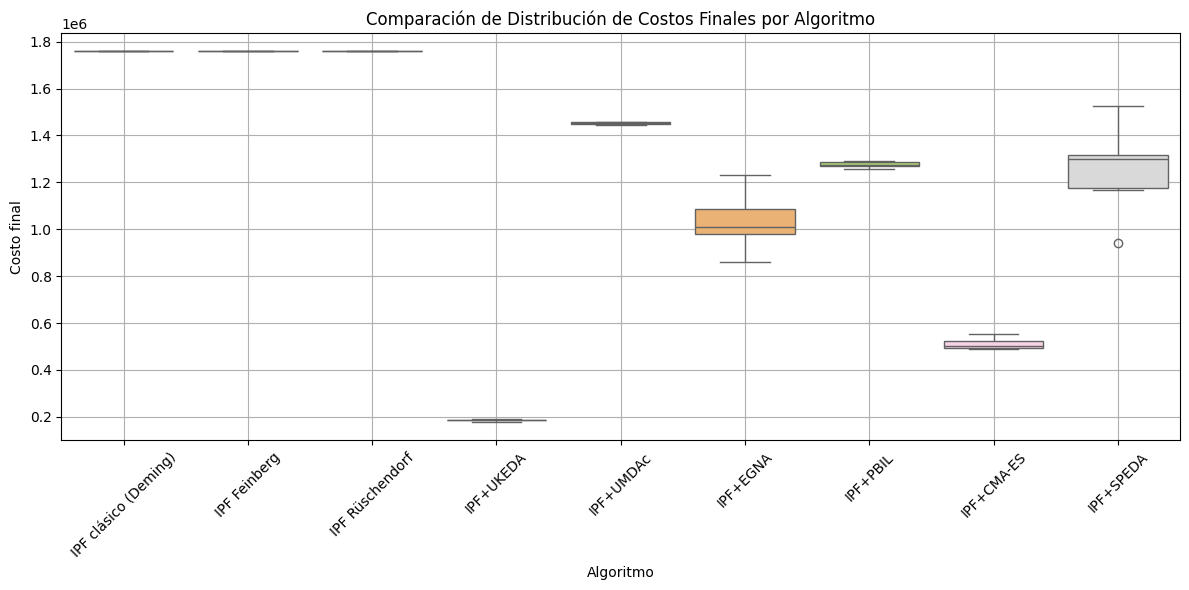

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Usar los nombres definidos en tu experimento
data = {
    "IPF clásico (Deming)": best_costs_deming,
    "IPF Feinberg": best_costs_fienberg,
    "IPF Rüschendorf": best_costs_ruschendorf,
    "IPF+UKEDA": best_costs_keda,
    "IPF+UMDAc": best_costs_umdac,
    "IPF+EGNA": best_costs_egna,
    "IPF+PBIL": best_costs_pbil,
    "IPF+CMA-ES": best_costs_cmaes,
    "IPF+SPEDA": best_costs_speda
}

df = pd.DataFrame(data)
df_melted = df.melt(var_name="Algoritmo", value_name="Costo final")

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x="Algoritmo", y="Costo final", palette="Set3")
plt.title("Comparación de Distribución de Costos Finales por Algoritmo")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


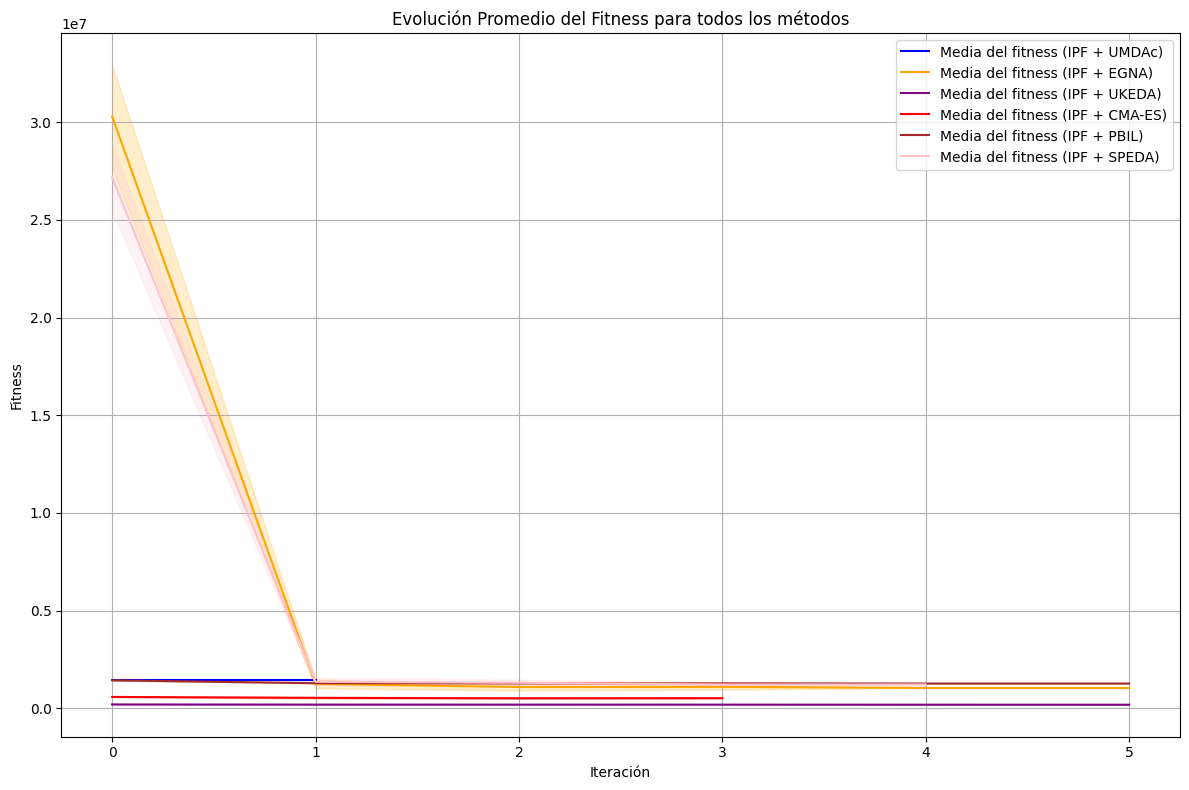

In [ ]:
plt.figure(figsize=(12, 8))

for history_list, label, color in zip(all_histories, labels, colors):
    max_len = max(len(h) for h in history_list)
    history_array = np.array([np.pad(h, (0, max_len - len(h)), constant_values=np.nan) for h in history_list])

    mean_fitness = np.nanmean(history_array, axis=0)
    std_fitness = np.nanstd(history_array, axis=0)

    plt.plot(mean_fitness, label=f'Media del fitness ({label})', color=color)
    plt.fill_between(range(max_len),
                     mean_fitness - std_fitness,
                     mean_fitness + std_fitness,
                     color=color, alpha=0.2)

plt.title('Evolución Promedio del Fitness para todos los métodos')
plt.xlabel('Iteración')
plt.ylabel('Fitness')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# DEMING VS FEINBERG VS RUSCHENDORF 2 DIM


Ejecutando experimento 1/10...
[Deming] IT: 1 	Best cost: 627645
[Deming] IT: 2 	Best cost: 91136
[Deming] IT: 3 	Best cost: 90930
[Deming] IT: 4 	Best cost: 90929
[Deming] IT: 5 	Best cost: 90929
[Deming] IT: 6 	Best cost: 90929
[Deming] IT: 7 	Best cost: 90929
[Deming] IT: 8 	Best cost: 90929
[Fienberg] IT: 1 	Best cost: 627645
[Fienberg] IT: 2 	Best cost: 91136
[Fienberg] IT: 3 	Best cost: 90930
[Fienberg] IT: 4 	Best cost: 90929
[Fienberg] IT: 5 	Best cost: 90929
[Fienberg] IT: 6 	Best cost: 90929
Convergencia alcanzada.
[Rüschendorf] IT: 1 	Best cost: 627645
[Rüschendorf] IT: 2 	Best cost: 91136
[Rüschendorf] IT: 3 	Best cost: 90930
[Rüschendorf] IT: 4 	Best cost: 90929
[Rüschendorf] IT: 5 	Best cost: 90929
Convergencia alcanzada.

Ejecutando experimento 2/10...
[Deming] IT: 1 	Best cost: 627645
[Deming] IT: 2 	Best cost: 91136
[Deming] IT: 3 	Best cost: 90930
[Deming] IT: 4 	Best cost: 90929
[Deming] IT: 5 	Best cost: 90929
[Deming] IT: 6 	Best cost: 90929
[Deming] IT: 7 	Best c

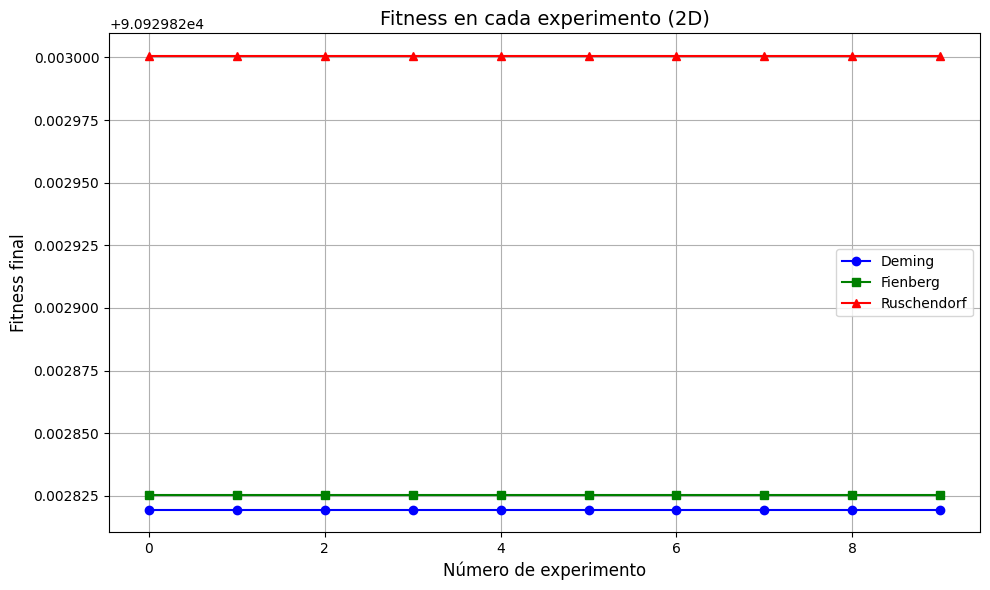

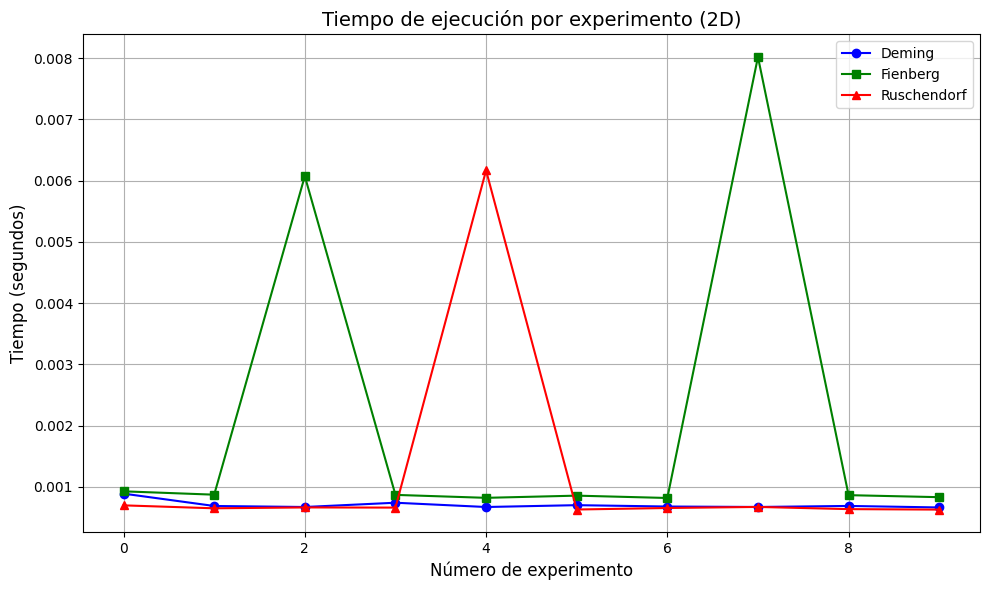

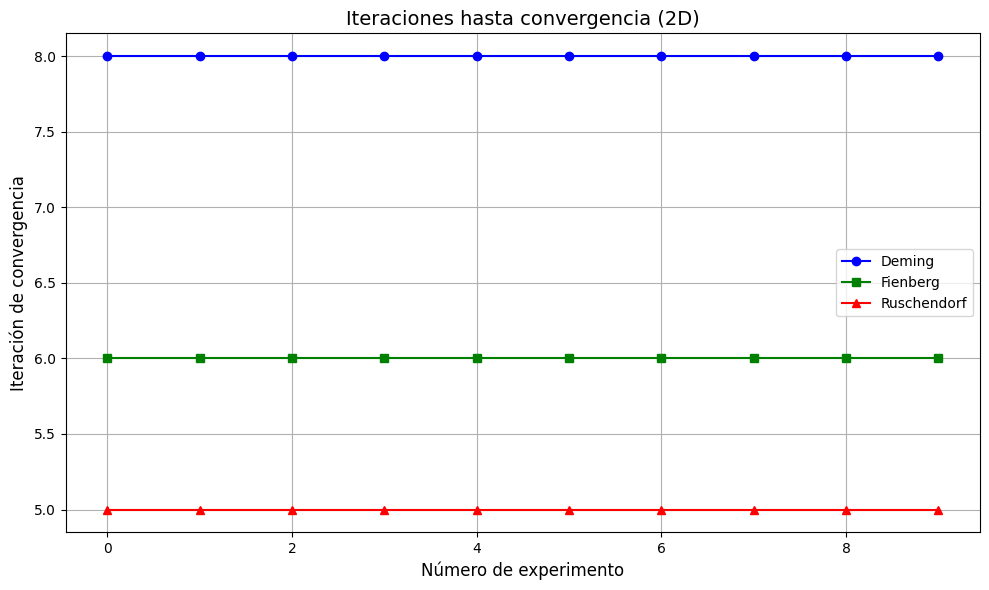

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

# Configuración inicial
rows, cols = 20, 20
num_experiments = 10
iterations = 20

# Función para generar márgenes
def generate_margins(rows, cols, total_sum=np.random.randint(15000, 25000)):
    row_margins = np.random.randint(2000, 6000, size=rows)
    row_margins = np.round(row_margins / row_margins.sum() * total_sum).astype(int)
    col_margins = np.random.randint(2000, 6000, size=cols)
    col_margins = np.round(col_margins / col_margins.sum() * total_sum).astype(int)
    row_margins[-1] += total_sum - row_margins.sum()
    col_margins[-1] += total_sum - col_margins.sum()
    return row_margins, col_margins

# Penalización combinada
def combined_penalty(matrix, row_margins, col_margins, initial_matrix, alpha=60, beta=10):
    row_diff = np.abs(np.sum(matrix, axis=1) - row_margins)
    col_diff = np.abs(np.sum(matrix, axis=0) - col_margins)
    margin_penalty = np.sum(row_diff**2) + np.sum(col_diff**2)
    similarity_penalty = np.sum(np.abs(matrix - initial_matrix))
    return alpha * margin_penalty + beta * similarity_penalty

def fitness_function(matrix, row_margins, col_margins, initial_matrix):
    return combined_penalty(matrix, row_margins, col_margins, initial_matrix)


# IPF basado en Deming & Stephan
def iterative_proportional_fitting_deming(matrix, row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=100):
    start_time = time.time()
    matrix = matrix.astype(float)
    best_costs = []

    convergence_iter = None
    for it in range(max_iterations):
        matrix *= (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix *= (col_margins / (matrix.sum(axis=0) + 1e-10))

        best_cost = fitness_function(matrix, row_margins, col_margins, initial_matrix)
        best_costs.append(best_cost)
        print(f"[Deming] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            convergence_iter = it + 1
            break

    matrix = np.round(matrix).astype(int)
    execution_time = time.time() - start_time
    return matrix, execution_time, best_costs, convergence_iter


# Log-verosimilitud
def log_likelihood(matrix, row_margins, col_margins):
    epsilon = 1e-10
    expected = np.outer(row_margins, col_margins) / np.sum(row_margins)
    return np.sum(matrix * np.log((matrix + epsilon) / expected))

# IPF - Feinberg
def iterative_proportional_fitting_fienberg(matrix, row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=25):
    start_time = time.time()
    matrix = matrix.astype(float)
    prev_ll = log_likelihood(matrix, row_margins, col_margins)
    best_costs = []

    convergence_iter = None
    for it in range(max_iterations):
        matrix *= row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10)
        matrix *= col_margins[None, :] / (matrix.sum(axis=0, keepdims=True) + 1e-10)

        new_ll = log_likelihood(matrix, row_margins, col_margins)
        best_cost = fitness_function(matrix, row_margins, col_margins, initial_matrix)
        best_costs.append(best_cost)
        print(f"[Fienberg] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if abs(new_ll - prev_ll) < tol:
            convergence_iter = it + 1
            print("Convergencia alcanzada.")
            break

        prev_ll = new_ll

    matrix = np.round(matrix).astype(int)
    execution_time = time.time() - start_time
    return matrix, execution_time, best_costs, convergence_iter


# KL divergencia simétrica
def kl_symmetric_divergence(p, q):
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    return np.sum(p * np.log(p / q) + q * np.log(q / p))

# IPF - Rüschendorf con divergencia KL simétrica
def iterative_proportional_fitting_ruschendorf(matrix, row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=25):
    start_time = time.time()
    matrix = matrix.astype(float)
    prev_matrix = matrix.copy()
    best_costs = []

    convergence_iter = None
    for it in range(max_iterations):
        matrix *= row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10)
        matrix *= col_margins[None, :] / (matrix.sum(axis=0, keepdims=True) + 1e-10)

        best_cost = fitness_function(matrix, row_margins, col_margins, initial_matrix)
        best_costs.append(best_cost)
        print(f"[Rüschendorf] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if kl_symmetric_divergence(matrix, prev_matrix) < tol:
            convergence_iter = it + 1
            print("Convergencia alcanzada.")
            break

        prev_matrix = matrix.copy()

    matrix = np.round(matrix).astype(int)
    execution_time = time.time() - start_time
    return matrix, execution_time, best_costs, convergence_iter


# ========================== EXPERIMENTOS 2D =============================

# Inicialización
initial_matrix = np.random.randint(20, 100, size=(rows, cols))
row_margins, col_margins = generate_margins(rows, cols)

# Listas para almacenar resultados
fitness_deming_list, fitness_fienberg_list, fitness_ruschendorf_list = [], [], []
time_deming_list, time_fienberg_list, time_ruschendorf_list = [], [], []
convergence_deming_list, convergence_fienberg_list, convergence_ruschendorf_list = [], [], []

# Experimentos
for i in range(num_experiments):
    print(f"\nEjecutando experimento {i+1}/{num_experiments}...")

    # DEMING
    matrix_deming, time_deming, fitness_history_deming, conv_deming = iterative_proportional_fitting_deming(
        initial_matrix.copy(), row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=iterations
    )
    fitness_deming_list.append(fitness_history_deming[-1])
    time_deming_list.append(time_deming)
    convergence_deming_list.append(conv_deming)

    # FIENBERG
    matrix_fienberg, time_fienberg, fitness_history_fienberg, conv_fienberg = iterative_proportional_fitting_fienberg(
        initial_matrix.copy(), row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=iterations
    )
    fitness_fienberg_list.append(fitness_history_fienberg[-1])
    time_fienberg_list.append(time_fienberg)
    convergence_fienberg_list.append(conv_fienberg)

    # RUSCHENDORF
    matrix_ruschendorf, time_ruschendorf, fitness_history_ruschendorf, conv_ruschendorf = iterative_proportional_fitting_ruschendorf(
        initial_matrix.copy(), row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=iterations
    )
    fitness_ruschendorf_list.append(fitness_history_ruschendorf[-1])
    time_ruschendorf_list.append(time_ruschendorf)
    convergence_ruschendorf_list.append(conv_ruschendorf)

# ========================== RESULTADOS ESTADÍSTICOS =============================

print("\nResultados estadísticos (2D):")

# Fitness
print(f"Media Fitness DEMING: {np.mean(fitness_deming_list):.4f} ± {np.std(fitness_deming_list):.4f}")
print(f"Media Fitness FIENBERG: {np.mean(fitness_fienberg_list):.4f} ± {np.std(fitness_fienberg_list):.4f}")
print(f"Media Fitness RUSCHENDORF: {np.mean(fitness_ruschendorf_list):.4f} ± {np.std(fitness_ruschendorf_list):.4f}")

# Tiempo
print(f"Tiempo medio DEMING: {np.mean(time_deming_list):.4f} segundos ± {np.std(time_deming_list):.4f}")
print(f"Tiempo medio FIENBERG: {np.mean(time_fienberg_list):.4f} segundos ± {np.std(time_fienberg_list):.4f}")
print(f"Tiempo medio RUSCHENDORF: {np.mean(time_ruschendorf_list):.4f} segundos ± {np.std(time_ruschendorf_list):.4f}")

# Convergencia
print(f"Iteración media de convergencia DEMING: {np.mean(convergence_deming_list):.2f} ± {np.std(convergence_deming_list):.2f}")
print(f"Iteración media de convergencia FIENBERG: {np.mean(convergence_fienberg_list):.2f} ± {np.std(convergence_fienberg_list):.2f}")
print(f"Iteración media de convergencia RUSCHENDORF: {np.mean(convergence_ruschendorf_list):.2f} ± {np.std(convergence_ruschendorf_list):.2f}")

# ========================== GRÁFICOS DE RESULTADOS =============================

# Gráfico de fitness
plt.figure(figsize=(10, 6))
plt.plot(fitness_deming_list, label="Deming", marker='o', linestyle='-', color='b')
plt.plot(fitness_fienberg_list, label="Fienberg", marker='s', linestyle='-', color='g')
plt.plot(fitness_ruschendorf_list, label="Ruschendorf", marker='^', linestyle='-', color='r')
plt.title("Fitness en cada experimento (2D)", fontsize=14)
plt.xlabel("Número de experimento", fontsize=12)
plt.ylabel("Fitness final", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de tiempo de ejecución
plt.figure(figsize=(10, 6))
plt.plot(time_deming_list, label="Deming", marker='o', linestyle='-', color='b')
plt.plot(time_fienberg_list, label="Fienberg", marker='s', linestyle='-', color='g')
plt.plot(time_ruschendorf_list, label="Ruschendorf", marker='^', linestyle='-', color='r')
plt.title("Tiempo de ejecución por experimento (2D)", fontsize=14)
plt.xlabel("Número de experimento", fontsize=12)
plt.ylabel("Tiempo (segundos)", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de iteraciones hasta convergencia
plt.figure(figsize=(10, 6))
plt.plot(convergence_deming_list, label="Deming", marker='o', linestyle='-', color='b')
plt.plot(convergence_fienberg_list, label="Fienberg", marker='s', linestyle='-', color='g')
plt.plot(convergence_ruschendorf_list, label="Ruschendorf", marker='^', linestyle='-', color='r')
plt.title("Iteraciones hasta convergencia (2D)", fontsize=14)
plt.xlabel("Número de experimento", fontsize=12)
plt.ylabel("Iteración de convergencia", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<ipython-input-7-0d967d17b757>:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([fitness_deming_list, fitness_fienberg_list, fitness_ruschendorf_list],


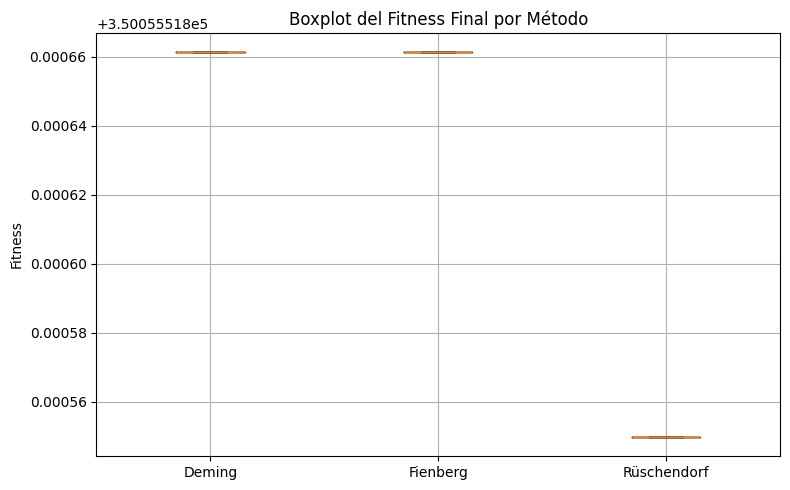

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot([fitness_deming_list, fitness_fienberg_list, fitness_ruschendorf_list],
            labels=['Deming', 'Fienberg', 'Rüschendorf'])
plt.title('Boxplot del Fitness Final por Método')
plt.ylabel('Fitness')
plt.grid(True)
plt.tight_layout()
plt.show()



Ejecutando experimento 1/10...
[Deming] IT: 1 	Best cost: 1042899
[Deming] IT: 2 	Best cost: 100559
[Deming] IT: 3 	Best cost: 100116
[Deming] IT: 4 	Best cost: 100116
[Deming] IT: 5 	Best cost: 100116
[Deming] IT: 6 	Best cost: 100116
[Deming] IT: 7 	Best cost: 100116
[Deming] IT: 8 	Best cost: 100116
[Fienberg] IT: 1 	Best cost: 1042899
[Fienberg] IT: 2 	Best cost: 100559
[Fienberg] IT: 3 	Best cost: 100116
[Fienberg] IT: 4 	Best cost: 100116
[Fienberg] IT: 5 	Best cost: 100116
[Fienberg] IT: 6 	Best cost: 100116
[Fienberg] IT: 7 	Best cost: 100116
Convergencia alcanzada.
[Rüschendorf] IT: 1 	Best cost: 1042899
[Rüschendorf] IT: 2 	Best cost: 100559
[Rüschendorf] IT: 3 	Best cost: 100116
[Rüschendorf] IT: 4 	Best cost: 100116
[Rüschendorf] IT: 5 	Best cost: 100116
Convergencia alcanzada.

Ejecutando experimento 2/10...
[Deming] IT: 1 	Best cost: 1042899
[Deming] IT: 2 	Best cost: 100559
[Deming] IT: 3 	Best cost: 100116
[Deming] IT: 4 	Best cost: 100116
[Deming] IT: 5 	Best cost: 10

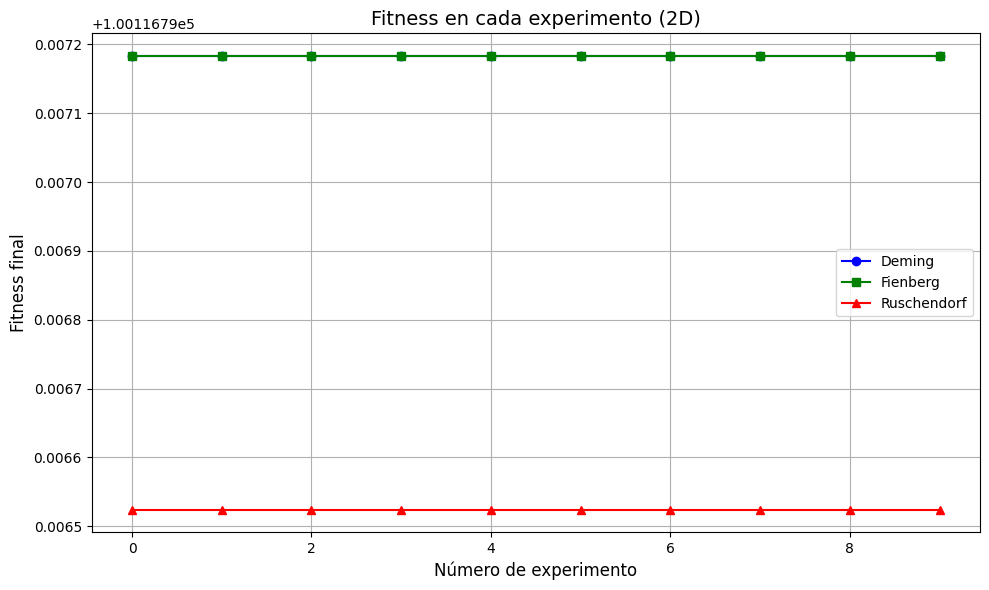

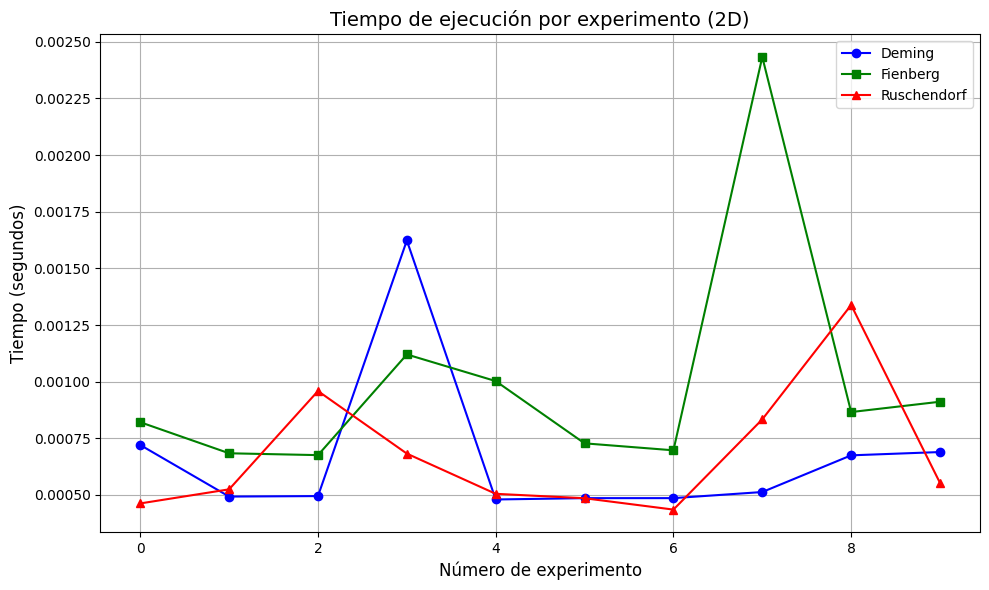

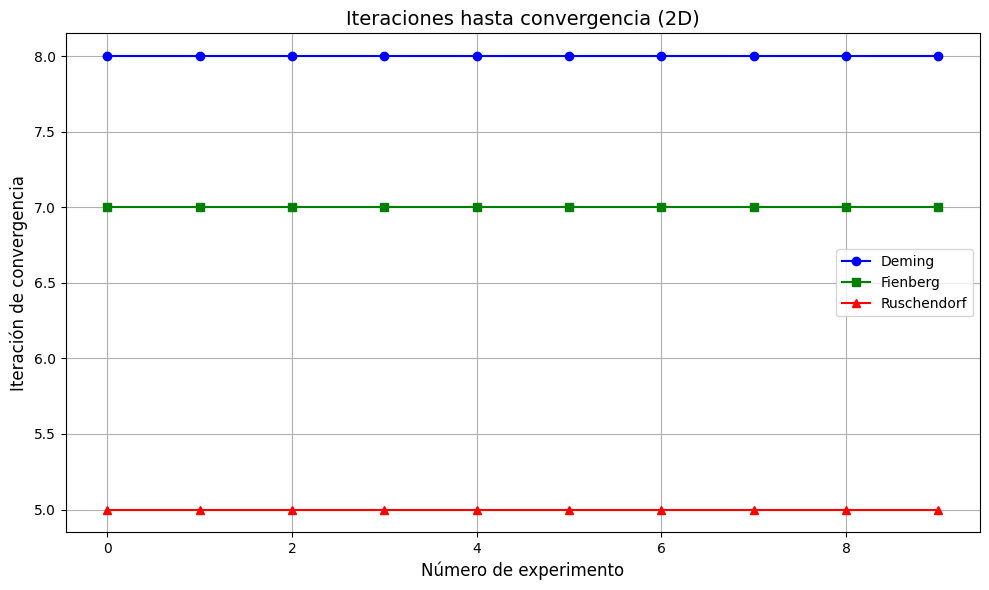

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

# Configuración inicial
rows, cols = 20, 20
num_experiments = 10
iterations = 20

# Función para generar márgenes
def generate_margins(rows, cols, total_sum=np.random.randint(15000, 25000)):
    row_margins = np.random.randint(2000, 6000, size=rows)
    row_margins = np.round(row_margins / row_margins.sum() * total_sum).astype(int)
    col_margins = np.random.randint(2000, 6000, size=cols)
    col_margins = np.round(col_margins / col_margins.sum() * total_sum).astype(int)
    row_margins[-1] += total_sum - row_margins.sum()
    col_margins[-1] += total_sum - col_margins.sum()
    return row_margins, col_margins

# Penalización combinada
def combined_penalty(matrix, row_margins, col_margins, initial_matrix, alpha=60, beta=10):
    row_diff = np.abs(np.sum(matrix, axis=1) - row_margins)
    col_diff = np.abs(np.sum(matrix, axis=0) - col_margins)
    margin_penalty = np.sum(row_diff**2) + np.sum(col_diff**2)
    similarity_penalty = np.sum(np.abs(matrix - initial_matrix))
    return alpha * margin_penalty + beta * similarity_penalty

def fitness_function(matrix, row_margins, col_margins, initial_matrix):
    return combined_penalty(matrix, row_margins, col_margins, initial_matrix)


# IPF basado en Deming & Stephan
def iterative_proportional_fitting_deming(matrix, row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=100):
    start_time = time.time()
    matrix = matrix.astype(float)
    best_costs = []

    convergence_iter = None
    for it in range(max_iterations):
        matrix *= (row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10))
        matrix *= (col_margins / (matrix.sum(axis=0) + 1e-10))

        best_cost = fitness_function(matrix, row_margins, col_margins, initial_matrix)
        best_costs.append(best_cost)
        print(f"[Deming] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            convergence_iter = it + 1
            break

    matrix = np.round(matrix).astype(int)
    execution_time = time.time() - start_time
    return matrix, execution_time, best_costs, convergence_iter


# Log-verosimilitud
def log_likelihood(matrix, row_margins, col_margins):
    epsilon = 1e-10
    expected = np.outer(row_margins, col_margins) / np.sum(row_margins)
    return np.sum(matrix * np.log((matrix + epsilon) / expected))

# IPF - Feinberg
def iterative_proportional_fitting_fienberg(matrix, row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=25):
    start_time = time.time()
    matrix = matrix.astype(float)
    prev_ll = log_likelihood(matrix, row_margins, col_margins)
    best_costs = []

    convergence_iter = None
    for it in range(max_iterations):
        matrix *= row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10)
        matrix *= col_margins[None, :] / (matrix.sum(axis=0, keepdims=True) + 1e-10)

        new_ll = log_likelihood(matrix, row_margins, col_margins)
        best_cost = fitness_function(matrix, row_margins, col_margins, initial_matrix)
        best_costs.append(best_cost)
        print(f"[Fienberg] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if abs(new_ll - prev_ll) < tol:
            convergence_iter = it + 1
            print("Convergencia alcanzada.")
            break

        prev_ll = new_ll

    matrix = np.round(matrix).astype(int)
    execution_time = time.time() - start_time
    return matrix, execution_time, best_costs, convergence_iter


# KL divergencia simétrica
def kl_symmetric_divergence(p, q):
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    return np.sum(p * np.log(p / q) + q * np.log(q / p))

# IPF - Rüschendorf con divergencia KL simétrica
def iterative_proportional_fitting_ruschendorf(matrix, row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=25):
    start_time = time.time()
    matrix = matrix.astype(float)
    prev_matrix = matrix.copy()
    best_costs = []

    convergence_iter = None
    for it in range(max_iterations):
        matrix *= row_margins[:, None] / (matrix.sum(axis=1, keepdims=True) + 1e-10)
        matrix *= col_margins[None, :] / (matrix.sum(axis=0, keepdims=True) + 1e-10)

        best_cost = fitness_function(matrix, row_margins, col_margins, initial_matrix)
        best_costs.append(best_cost)
        print(f"[Rüschendorf] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if kl_symmetric_divergence(matrix, prev_matrix) < tol:
            convergence_iter = it + 1
            print("Convergencia alcanzada.")
            break

        prev_matrix = matrix.copy()

    matrix = np.round(matrix).astype(int)
    execution_time = time.time() - start_time
    return matrix, execution_time, best_costs, convergence_iter


# Inicialización
initial_matrix = np.random.randint(20, 100, size=(rows, cols))
row_margins, col_margins = generate_margins(rows, cols)

# Listas para almacenar resultados
fitness_deming_list, fitness_fienberg_list, fitness_ruschendorf_list = [], [], []
time_deming_list, time_fienberg_list, time_ruschendorf_list = [], [], []
convergence_deming_list, convergence_fienberg_list, convergence_ruschendorf_list = [], [], []

# Experimentos
for i in range(num_experiments):
    print(f"\nEjecutando experimento {i+1}/{num_experiments}...")

    # DEMING
    matrix_deming, time_deming, fitness_history_deming, conv_deming = iterative_proportional_fitting_deming(
        initial_matrix.copy(), row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=iterations
    )
    fitness_deming_list.append(fitness_history_deming[-1])
    time_deming_list.append(time_deming)
    convergence_deming_list.append(conv_deming)

    # FIENBERG
    matrix_fienberg, time_fienberg, fitness_history_fienberg, conv_fienberg = iterative_proportional_fitting_fienberg(
        initial_matrix.copy(), row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=iterations
    )
    fitness_fienberg_list.append(fitness_history_fienberg[-1])
    time_fienberg_list.append(time_fienberg)
    convergence_fienberg_list.append(conv_fienberg)

    # RUSCHENDORF
    matrix_ruschendorf, time_ruschendorf, fitness_history_ruschendorf, conv_ruschendorf = iterative_proportional_fitting_ruschendorf(
        initial_matrix.copy(), row_margins, col_margins, initial_matrix, tol=1e-6, max_iterations=iterations
    )
    fitness_ruschendorf_list.append(fitness_history_ruschendorf[-1])
    time_ruschendorf_list.append(time_ruschendorf)
    convergence_ruschendorf_list.append(conv_ruschendorf)

print("\nResultados estadísticos (2D):")

# Fitness
print(f"Media Fitness DEMING: {np.mean(fitness_deming_list):.4f} ± {np.std(fitness_deming_list):.4f}")
print(f"Media Fitness FIENBERG: {np.mean(fitness_fienberg_list):.4f} ± {np.std(fitness_fienberg_list):.4f}")
print(f"Media Fitness RUSCHENDORF: {np.mean(fitness_ruschendorf_list):.4f} ± {np.std(fitness_ruschendorf_list):.4f}")

# Tiempo
print(f"Tiempo medio DEMING: {np.mean(time_deming_list):.4f} segundos ± {np.std(time_deming_list):.4f}")
print(f"Tiempo medio FIENBERG: {np.mean(time_fienberg_list):.4f} segundos ± {np.std(time_fienberg_list):.4f}")
print(f"Tiempo medio RUSCHENDORF: {np.mean(time_ruschendorf_list):.4f} segundos ± {np.std(time_ruschendorf_list):.4f}")

# Convergencia
print(f"Iteración media de convergencia DEMING: {np.mean(convergence_deming_list):.2f} ± {np.std(convergence_deming_list):.2f}")
print(f"Iteración media de convergencia FIENBERG: {np.mean(convergence_fienberg_list):.2f} ± {np.std(convergence_fienberg_list):.2f}")
print(f"Iteración media de convergencia RUSCHENDORF: {np.mean(convergence_ruschendorf_list):.2f} ± {np.std(convergence_ruschendorf_list):.2f}")

# Gráfico de fitness
plt.figure(figsize=(10, 6))
plt.plot(fitness_deming_list, label="Deming", marker='o', linestyle='-', color='b')
plt.plot(fitness_fienberg_list, label="Fienberg", marker='s', linestyle='-', color='g')
plt.plot(fitness_ruschendorf_list, label="Ruschendorf", marker='^', linestyle='-', color='r')
plt.title("Fitness en cada experimento (2D)", fontsize=14)
plt.xlabel("Número de experimento", fontsize=12)
plt.ylabel("Fitness final", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de tiempo de ejecución
plt.figure(figsize=(10, 6))
plt.plot(time_deming_list, label="Deming", marker='o', linestyle='-', color='b')
plt.plot(time_fienberg_list, label="Fienberg", marker='s', linestyle='-', color='g')
plt.plot(time_ruschendorf_list, label="Ruschendorf", marker='^', linestyle='-', color='r')
plt.title("Tiempo de ejecución por experimento (2D)", fontsize=14)
plt.xlabel("Número de experimento", fontsize=12)
plt.ylabel("Tiempo (segundos)", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de iteraciones hasta convergencia
plt.figure(figsize=(10, 6))
plt.plot(convergence_deming_list, label="Deming", marker='o', linestyle='-', color='b')
plt.plot(convergence_fienberg_list, label="Fienberg", marker='s', linestyle='-', color='g')
plt.plot(convergence_ruschendorf_list, label="Ruschendorf", marker='^', linestyle='-', color='r')
plt.title("Iteraciones hasta convergencia (2D)", fontsize=14)
plt.xlabel("Número de experimento", fontsize=12)
plt.ylabel("Iteración de convergencia", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# DEMING VS FEINBERG VS RUSCHENDORF 3 DIM


Tensor inicial (antes de ajustar):
[[[98 48 96 21 67 35 50 83 73 70]
  [96 75 27 53 59 77 98 46 38 31]
  [65 25 51 28 83 27 98 49 78 25]
  [40 30 87 44 37 24 49 71 97 32]
  [47 96 80 30 78 42 99 85 94 27]
  [90 89 28 27 43 84 25 75 47 67]
  [29 87 48 83 92 59 92 88 83 51]
  [85 49 99 26 25 40 33 29 37 85]
  [54 42 30 52 63 79 20 44 98 53]
  [82 21 88 47 44 49 70 98 23 32]]

 [[68 43 55 27 33 68 52 47 59 24]
  [21 22 94 55 57 63 49 79 99 28]
  [54 64 33 32 97 64 85 96 99 63]
  [22 73 90 31 58 65 89 65 72 50]
  [37 72 43 87 22 49 27 34 59 43]
  [31 34 54 28 69 28 44 78 94 36]
  [68 42 47 55 25 41 62 39 30 69]
  [93 53 78 67 79 47 56 68 43 44]
  [36 80 67 23 26 82 28 45 61 93]
  [38 82 73 42 74 44 22 79 26 36]]

 [[43 96 77 91 29 48 35 85 67 30]
  [84 27 42 27 59 67 43 47 54 26]
  [38 31 67 69 75 42 23 67 76 36]
  [29 62 60 43 47 98 51 47 59 78]
  [27 41 61 68 99 91 31 29 76 89]
  [49 39 94 74 87 45 54 51 27 28]
  [26 88 68 43 61 24 81 51 48 92]
  [78 77 28 93 96 40 67 77 44 65]
  [43 32

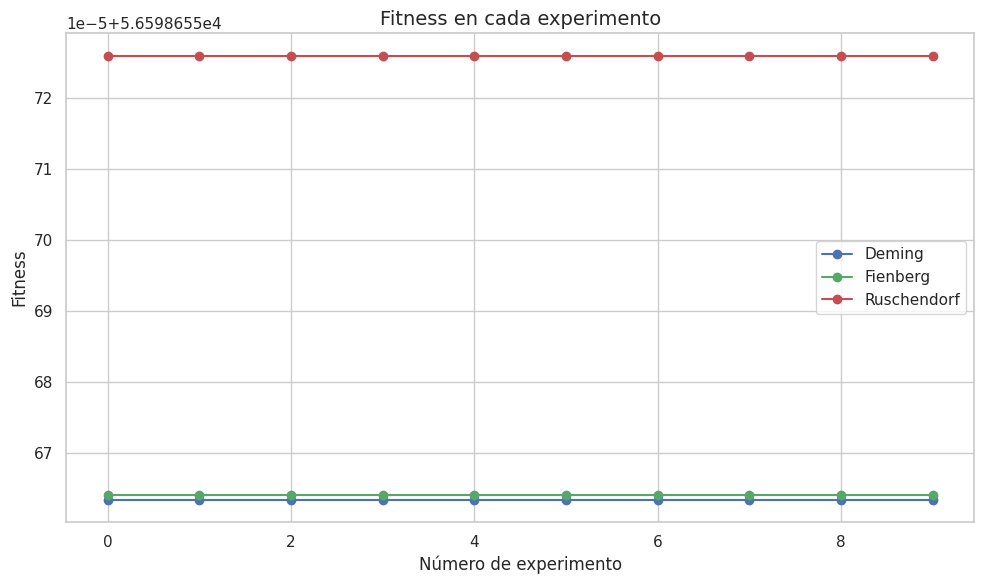

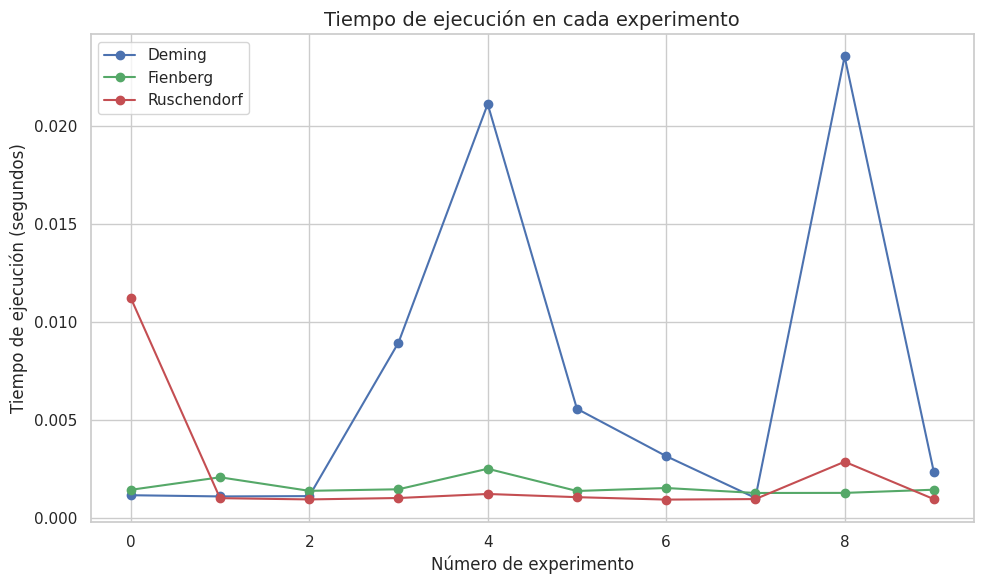

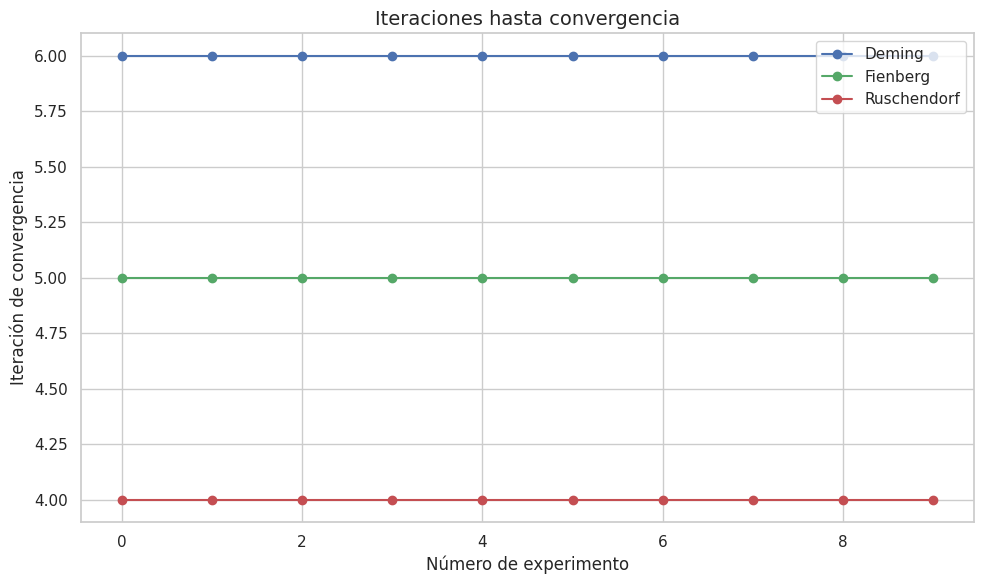

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns

# Parámetros generales
num_experiments = 10  # Número de experimentos
iterations = 20  # Número de iteraciones
dimensions = (10, 10, 10)  # Dimensiones del tensor (3D)

# Función para generar márgenes aleatorios
def generate_tensor_margins(dimensions, total_sum=np.random.randint(30000, 60000)):
    row_margins = np.random.randint(10000, 13000, size=dimensions[0])
    row_margins = np.round(row_margins / row_margins.sum() * total_sum).astype(int)

    col_margins = np.random.randint(10000, 13000, size=dimensions[1])
    col_margins = np.round(col_margins / col_margins.sum() * total_sum).astype(int)

    depth_margins = np.random.randint(10000, 13000, size=dimensions[2])
    depth_margins = np.round(depth_margins / depth_margins.sum() * total_sum).astype(int)

    row_margins[-1] += total_sum - row_margins.sum()
    col_margins[-1] += total_sum - col_margins.sum()
    depth_margins[-1] += total_sum - depth_margins.sum()

    return row_margins, col_margins, depth_margins

def combined_penalty(tensor, row_margins, col_margins, depth_margins, initial_tensor, alpha=60, beta=10):
    row_diff = np.abs(tensor.sum(axis=(1, 2)) - row_margins)
    col_diff = np.abs(tensor.sum(axis=(0, 2)) - col_margins)
    depth_diff = np.abs(tensor.sum(axis=(0, 1)) - depth_margins)

    margin_penalty = np.sum(row_diff**2) + np.sum(col_diff**2) + np.sum(depth_diff**2)
    similarity_penalty = np.sum(np.abs(tensor - initial_tensor))

    return alpha * margin_penalty + beta * similarity_penalty

def fitness_function(tensor, row_margins, col_margins, depth_margins, initial_tensor):
    return combined_penalty(tensor, row_margins, col_margins, depth_margins, initial_tensor)

def ipf_deming_3d(tensor, row_margins, col_margins, depth_margins, initial_tensor,
                                    tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    best_costs = []  # Almacena el mejor costo en cada iteración

    for it in range(max_iterations):
        # --- Ajuste para las filas (dimensión 0) ---
        row_sums = tensor.sum(axis=(1, 2))  # Suma sobre columnas y profundidad
        row_sums[row_sums == 0] = 1e-10  # Evitar división por cero
        tensor *= (row_margins[:, None, None] / row_sums[:, None, None])

        # --- Ajuste para las columnas (dimensión 1) ---
        col_sums = tensor.sum(axis=(0, 2))  # Suma sobre filas y profundidad
        col_sums[col_sums == 0] = 1e-10
        tensor *= (col_margins[None, :, None] / col_sums[None, :, None])

        # --- Ajuste para la profundidad (dimensión 2) ---
        depth_sums = tensor.sum(axis=(0, 1))  # Suma sobre filas y columnas
        depth_sums[depth_sums == 0] = 1e-10
        tensor *= (depth_margins[None, None, :] / depth_sums[None, None, :])

        # Calcular el costo (fitness) después del ajuste
        current_cost = fitness_function(tensor, row_margins, col_margins, depth_margins, initial_tensor)
        best_costs.append(current_cost)

        print(f"IT: {it + 1} \tBest cost: {int(current_cost)}")

        # Criterio de parada
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            convergence_iter = it + 1
            print("Convergencia alcanzada.")
            break

    # Redondear a enteros al final
    tensor = np.round(tensor).astype(int)
    execution_time = time.time() - start_time
    return tensor, execution_time, best_costs, convergence_iter

# Log-verosimilitud en 3D
def log_likelihood_3d(tensor, row_margins, col_margins, depth_margins):
    epsilon = 1e-10
    total = row_margins.sum()
    expected = np.einsum('i,j,k->ijk', row_margins, col_margins, depth_margins) / (total**2)
    return np.sum(tensor * np.log((tensor + epsilon) / expected))

# IPF - Feinberg en 3D
def ipf_fienberg_3d(tensor, row_margins, col_margins, depth_margins, initial_tensor, tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    prev_ll = log_likelihood_3d(tensor, row_margins, col_margins, depth_margins)
    best_costs = []

    for it in range(max_iterations):
        # Ajuste por filas (dim 0)
        row_sums = tensor.sum(axis=(1, 2))
        tensor *= row_margins[:, None, None] / (row_sums[:, None, None] + 1e-10)

        # Ajuste por columnas (dim 1)
        col_sums = tensor.sum(axis=(0, 2))
        tensor *= col_margins[None, :, None] / (col_sums[None, :, None] + 1e-10)

        # Ajuste por profundidad (dim 2)
        depth_sums = tensor.sum(axis=(0, 1))
        tensor *= depth_margins[None, None, :] / (depth_sums[None, None, :] + 1e-10)

        # Evaluación
        new_ll = log_likelihood_3d(tensor, row_margins, col_margins, depth_margins)
        best_cost = fitness_function(tensor, row_margins, col_margins, depth_margins, initial_tensor)
        best_costs.append(best_cost)

        print(f"[Feinberg 3D] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if abs(new_ll - prev_ll) < tol:
            convergence_iter = it + 1
            print("Convergencia alcanzada.")
            break

        prev_ll = new_ll

    execution_time = time.time() - start_time
    return np.round(tensor).astype(int), execution_time, best_costs, convergence_iter

# KL divergencia simétrica para tensores 3D
def kl_symmetric_divergence_3d(p, q):
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    return np.sum(p * np.log(p / q) + q * np.log(q / p))

# IPF - Rüschendorf en 3D
def ipf_ruschendorf_3d(tensor, row_margins, col_margins, depth_margins, initial_tensor, tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    prev_tensor = tensor.copy()
    best_costs = []

    for it in range(max_iterations):
        # Ajuste por filas (dim 0)
        row_sums = tensor.sum(axis=(1, 2))
        tensor *= row_margins[:, None, None] / (row_sums[:, None, None] + 1e-10)

        # Ajuste por columnas (dim 1)
        col_sums = tensor.sum(axis=(0, 2))
        tensor *= col_margins[None, :, None] / (col_sums[None, :, None] + 1e-10)

        # Ajuste por profundidad (dim 2)
        depth_sums = tensor.sum(axis=(0, 1))
        tensor *= depth_margins[None, None, :] / (depth_sums[None, None, :] + 1e-10)

        # Coste (fitness)
        best_cost = fitness_function(tensor, row_margins, col_margins, depth_margins, initial_tensor)
        best_costs.append(best_cost)
        print(f"[Rüschendorf 3D] IT: {it + 1} \tBest cost: {int(best_cost)}")

        # Criterio de parada: divergencia KL simétrica
        if kl_symmetric_divergence_3d(tensor, prev_tensor) < tol:
            convergence_iter = it + 1
            print("Convergencia alcanzada.")
            break

        prev_tensor = tensor.copy()

    execution_time = time.time() - start_time
    return np.round(tensor).astype(int), execution_time, best_costs, convergence_iter


# Listas para almacenar los resultados de cada variante
fitness_deming_list, fitness_fienberg_list, fitness_ruschendorf_list = [], [], []
time_deming_list, time_fienberg_list, time_ruschendorf_list = [], [], []

# Generar márgenes y tensor inicial
row_margins, col_margins, depth_margins = generate_tensor_margins(dimensions)
initial_tensor = np.random.randint(20, 100, size=dimensions)

# Imprimir el tensor inicial y los márgenes
print("\nTensor inicial (antes de ajustar):")
print(initial_tensor)

print("\nMárgenes por filas (dim 0):")
print(row_margins)

print("\nMárgenes por columnas (dim 1):")
print(col_margins)

print("\nMárgenes por profundidad (dim 2):")
print(depth_margins)

# Listas para guardar las iteraciones de convergencia
convergence_deming_list = []
convergence_fienberg_list = []
convergence_ruschendorf_list = []

# Experimentos
for i in range(num_experiments):
    print(f"\nEjecutando prueba {i+1}/{num_experiments}...")

    # Ejecutar DEMING
    tensor_deming, execution_time_deming, fitness_deming_history, conv_deming = ipf_deming_3d(
        initial_tensor.copy(), row_margins, col_margins, depth_margins, initial_tensor, tol=1e-6, max_iterations=iterations
    )
    fitness_deming = fitness_deming_history[-1]
    fitness_deming_list.append(fitness_deming)
    time_deming_list.append(execution_time_deming)
    convergence_deming_list.append(conv_deming)

    # Ejecutar FIENBERG
    tensor_fienberg, execution_time_fienberg, fitness_fienberg_history, conv_fienberg = ipf_fienberg_3d(
        initial_tensor.copy(), row_margins, col_margins, depth_margins, initial_tensor, tol=1e-6, max_iterations=iterations
    )
    fitness_fienberg = fitness_fienberg_history[-1]
    fitness_fienberg_list.append(fitness_fienberg)
    time_fienberg_list.append(execution_time_fienberg)
    convergence_fienberg_list.append(conv_fienberg)

    # Ejecutar RUSCHENDORF
    tensor_ruschendorf, execution_time_ruschendorf, fitness_ruschendorf_history, conv_ruschendorf = ipf_ruschendorf_3d(
        initial_tensor.copy(), row_margins, col_margins, depth_margins, initial_tensor, tol=1e-6, max_iterations=iterations
    )
    fitness_ruschendorf = fitness_ruschendorf_history[-1]
    fitness_ruschendorf_list.append(fitness_ruschendorf)
    time_ruschendorf_list.append(execution_time_ruschendorf)
    convergence_ruschendorf_list.append(conv_ruschendorf)

# Análisis estadístico
print("\nResultados estadísticos:")

# Fitness
print(f"Media Fitness DEMING: {np.mean(fitness_deming_list):.4f} ± {np.std(fitness_deming_list):.4f}")
print(f"Media Fitness FIENBERG: {np.mean(fitness_fienberg_list):.4f} ± {np.std(fitness_fienberg_list):.4f}")
print(f"Media Fitness RUSCHENDORF: {np.mean(fitness_ruschendorf_list):.4f} ± {np.std(fitness_ruschendorf_list):.4f}")

# Tiempo de ejecución
print(f"Tiempo medio DEMING: {np.mean(time_deming_list):.4f} segundos ± {np.std(time_deming_list):.4f}")
print(f"Tiempo medio FIENBERG: {np.mean(time_fienberg_list):.4f} segundos ± {np.std(time_fienberg_list):.4f}")
print(f"Tiempo medio RUSCHENDORF: {np.mean(time_ruschendorf_list):.4f} segundos ± {np.std(time_ruschendorf_list):.4f}")

# Iteraciones hasta convergencia
print(f"Iteración media de convergencia DEMING: {np.mean(convergence_deming_list):.2f} ± {np.std(convergence_deming_list):.2f}")
print(f"Iteración media de convergencia FIENBERG: {np.mean(convergence_fienberg_list):.2f} ± {np.std(convergence_fienberg_list):.2f}")
print(f"Iteración media de convergencia RUSCHENDORF: {np.mean(convergence_ruschendorf_list):.2f} ± {np.std(convergence_ruschendorf_list):.2f}")

# Gráfico de fitness
plt.figure(figsize=(10, 6))
plt.plot(fitness_deming_list, label="Deming", marker='o', linestyle='-', color='b')
plt.plot(fitness_fienberg_list, label="Fienberg", marker='o', linestyle='-', color='g')
plt.plot(fitness_ruschendorf_list, label="Ruschendorf", marker='o', linestyle='-', color='r')
plt.title('Fitness en cada experimento', fontsize=14)
plt.xlabel('Número de experimento', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de tiempo de ejecución
plt.figure(figsize=(10, 6))
plt.plot(time_deming_list, label="Deming", marker='o', linestyle='-', color='b')
plt.plot(time_fienberg_list, label="Fienberg", marker='o', linestyle='-', color='g')
plt.plot(time_ruschendorf_list, label="Ruschendorf", marker='o', linestyle='-', color='r')
plt.title('Tiempo de ejecución en cada experimento', fontsize=14)
plt.xlabel('Número de experimento', fontsize=12)
plt.ylabel('Tiempo de ejecución (segundos)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de convergencia
plt.figure(figsize=(10, 6))
plt.plot(convergence_deming_list, label="Deming", marker='o', linestyle='-', color='b')
plt.plot(convergence_fienberg_list, label="Fienberg", marker='o', linestyle='-', color='g')
plt.plot(convergence_ruschendorf_list, label="Ruschendorf", marker='o', linestyle='-', color='r')
plt.title('Iteraciones hasta convergencia', fontsize=14)
plt.xlabel('Número de experimento', fontsize=12)
plt.ylabel('Iteración de convergencia', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


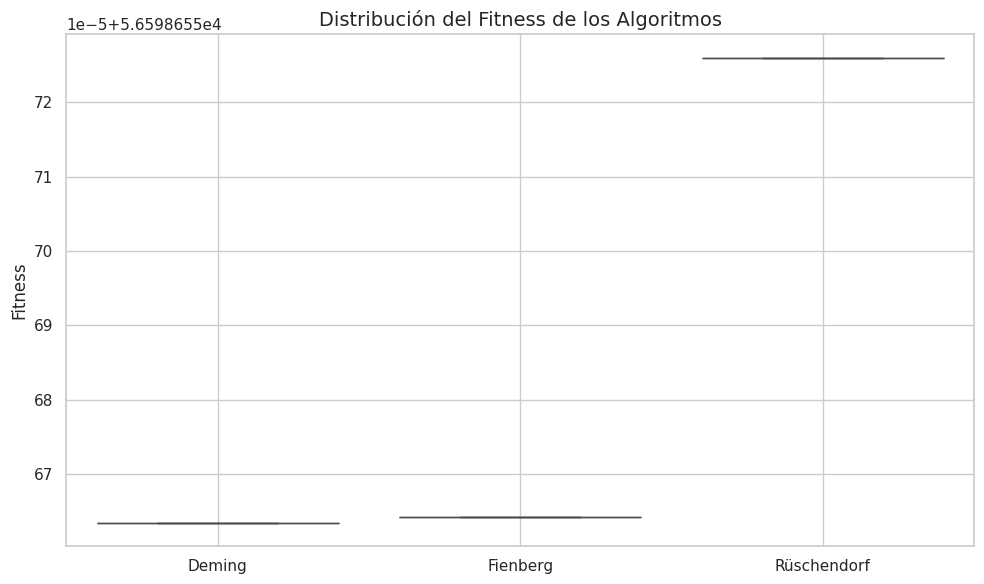

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Visualización 🔹
sns.set(style="whitegrid")

# Gráfico de Boxplot del Fitness
plt.figure(figsize=(10, 6))

# Preparar datos para el boxplot
data_fitness = [fitness_deming_list, fitness_fienberg_list, fitness_ruschendorf_list]

# Crear boxplot
sns.boxplot(data=data_fitness)
plt.xticks([0, 1, 2], ["Deming", "Fienberg", "Rüschendorf"])

# Título y etiquetas
plt.title("Distribución del Fitness de los Algoritmos", fontsize=14)
plt.ylabel("Fitness", fontsize=12)
plt.grid(True)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


# DEMING VS FEINBERG VS RUSCHENDORF 4 DIM


Tensor inicial (antes de ajustar):
[[[[96 37 51 ... 50 21 56]
   [41 97 22 ... 74 31 95]
   [53 74 30 ... 77 93 63]
   ...
   [80 44 75 ... 20 54 99]
   [94 36 99 ... 49 88 38]
   [83 33 84 ... 88 64 65]]

  [[44 37 42 ... 33 26 34]
   [97 83 56 ... 83 82 48]
   [85 43 58 ... 88 98 27]
   ...
   [86 30 80 ... 61 71 44]
   [87 86 84 ... 51 60 91]
   [28 37 68 ... 45 60 52]]

  [[64 58 46 ... 98 79 67]
   [76 45 65 ... 83 93 78]
   [40 78 72 ... 27 85 89]
   ...
   [71 53 96 ... 53 84 51]
   [91 24 83 ... 51 89 79]
   [38 78 28 ... 66 94 33]]

  ...

  [[70 94 42 ... 25 32 40]
   [26 48 50 ... 51 22 80]
   [96 33 49 ... 33 43 73]
   ...
   [65 63 99 ... 84 44 29]
   [75 31 88 ... 36 30 93]
   [48 77 49 ... 50 28 45]]

  [[29 59 82 ... 31 75 44]
   [80 89 49 ... 21 23 87]
   [55 94 75 ... 75 54 97]
   ...
   [75 22 20 ... 75 51 74]
   [86 76 41 ... 30 59 69]
   [45 50 34 ... 35 97 92]]

  [[66 36 62 ... 35 65 99]
   [48 88 97 ... 44 74 88]
   [39 50 35 ... 52 98 96]
   ...
   [86 60 51 .

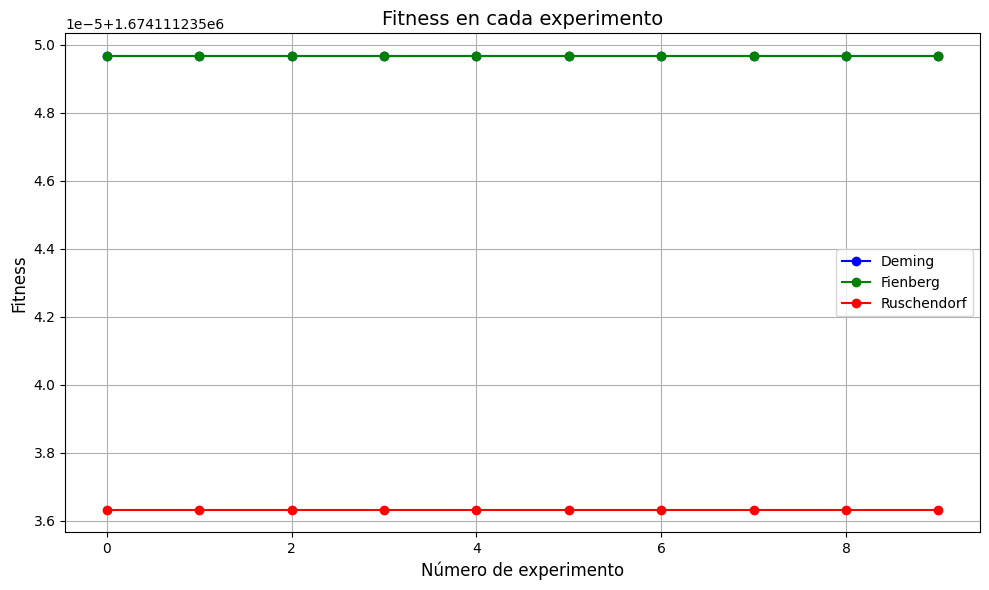

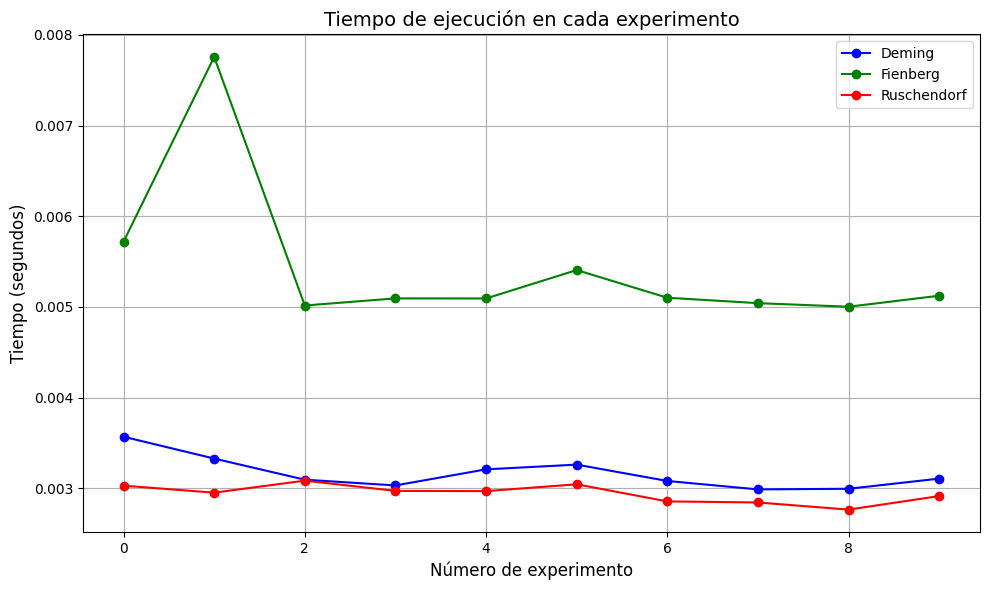

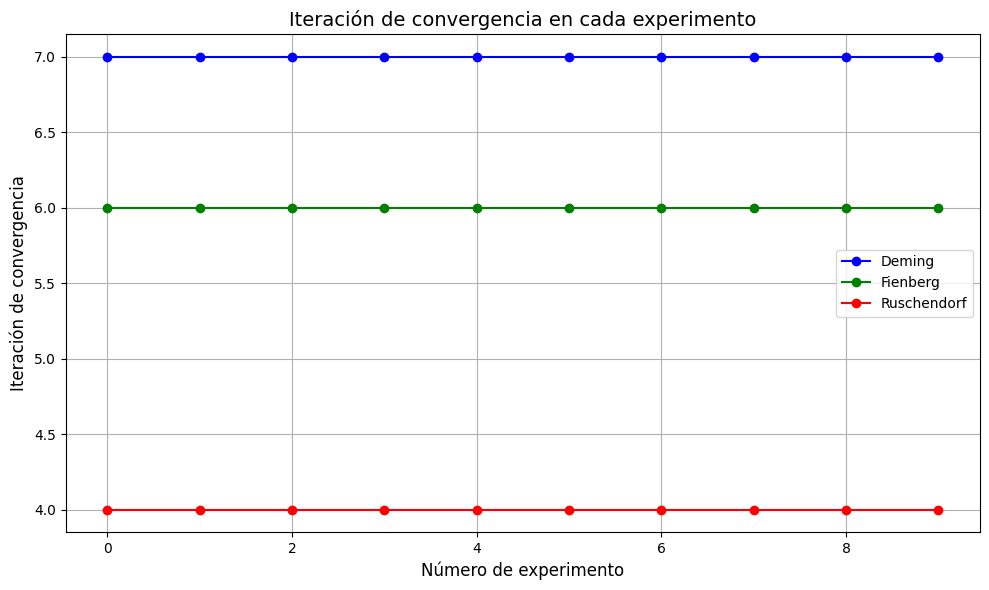

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns

# Parámetros generales
num_experiments = 10  # Número de experimentos
iterations = 25  # Número de iteraciones
dimensions = (9, 9, 9, 9)  # Dimensiones del tensor (3D)

def generate_tensor_margins_4d(dimensions, total_sum=np.random.randint(200000, 400000)):
    # Márgenes para cada dimensión
    margin_0 = np.random.randint(10000, 30000, size=dimensions[0])
    margin_0 = np.round(margin_0 / margin_0.sum() * total_sum).astype(int)

    margin_1 = np.random.randint(10000, 30000, size=dimensions[1])
    margin_1 = np.round(margin_1 / margin_1.sum() * total_sum).astype(int)

    margin_2 = np.random.randint(10000, 30000, size=dimensions[2])
    margin_2 = np.round(margin_2 / margin_2.sum() * total_sum).astype(int)

    margin_3 = np.random.randint(10000, 30000, size=dimensions[3])
    margin_3 = np.round(margin_3 / margin_3.sum() * total_sum).astype(int)

    # Asegurarse de que los márgenes sumen el total deseado
    margin_0[-1] += total_sum - margin_0.sum()
    margin_1[-1] += total_sum - margin_1.sum()
    margin_2[-1] += total_sum - margin_2.sum()
    margin_3[-1] += total_sum - margin_3.sum()

    return margin_0, margin_1, margin_2, margin_3

def combined_penalty(tensor, margin_0, margin_1, margin_2, margin_3, initial_tensor, alpha=60, beta=10):
    row_diff = np.abs(tensor.sum(axis=(1, 2, 3)) - margin_0)
    col_diff = np.abs(tensor.sum(axis=(0, 2, 3)) - margin_1)
    depth_diff = np.abs(tensor.sum(axis=(0, 1, 3)) - margin_2)
    depth_4d_diff = np.abs(tensor.sum(axis=(0, 1, 2)) - margin_3)

    margin_penalty = np.sum(row_diff**2) + np.sum(col_diff**2) + np.sum(depth_diff**2) + np.sum(depth_4d_diff**2)
    similarity_penalty = np.sum(np.abs(tensor - initial_tensor))

    return alpha * margin_penalty + beta * similarity_penalty

def fitness_function_4d(tensor, margin_0, margin_1, margin_2, margin_3, initial_tensor):
    return combined_penalty(tensor, margin_0, margin_1, margin_2, margin_3, initial_tensor)


def ipf_deming_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor,
                  tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    best_costs = []

    for it in range(max_iterations):
        # --- Ajuste para la dimensión 0 ---
        sum0 = tensor.sum(axis=(1, 2, 3))
        sum0[sum0 == 0] = 1e-10
        tensor *= (margin0[:, None, None, None] / sum0[:, None, None, None])

        # --- Ajuste para la dimensión 1 ---
        sum1 = tensor.sum(axis=(0, 2, 3))
        sum1[sum1 == 0] = 1e-10
        tensor *= (margin1[None, :, None, None] / sum1[None, :, None, None])

        # --- Ajuste para la dimensión 2 ---
        sum2 = tensor.sum(axis=(0, 1, 3))
        sum2[sum2 == 0] = 1e-10
        tensor *= (margin2[None, None, :, None] / sum2[None, None, :, None])

        # --- Ajuste para la dimensión 3 ---
        sum3 = tensor.sum(axis=(0, 1, 2))
        sum3[sum3 == 0] = 1e-10
        tensor *= (margin3[None, None, None, :] / sum3[None, None, None, :])

        # --- Evaluar el fitness ---
        current_cost = fitness_function_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor)
        best_costs.append(current_cost)

        print(f"IT: {it + 1} \tBest cost: {int(current_cost)}")

        # Criterio de convergencia
        if it > 0 and abs(best_costs[-1] - best_costs[-2]) < tol:
            convergence_iter = it + 1
            print("Convergencia alcanzada.")
            break

    # Redondear y finalizar
    tensor = np.round(tensor).astype(int)
    execution_time = time.time() - start_time
    return tensor, execution_time, best_costs, convergence_iter


def log_likelihood_4d(tensor, margin0, margin1, margin2, margin3):
    epsilon = 1e-10
    total = margin0.sum()
    expected = np.einsum('i,j,k,l->ijkl', margin0, margin1, margin2, margin3) / (total**3)
    return np.sum(tensor * np.log((tensor + epsilon) / expected))


def ipf_fienberg_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor,
                    tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    prev_ll = log_likelihood_4d(tensor, margin0, margin1, margin2, margin3)
    best_costs = []

    for it in range(max_iterations):
        # --- Ajuste para la dimensión 0 ---
        sum0 = tensor.sum(axis=(1, 2, 3))
        tensor *= margin0[:, None, None, None] / (sum0[:, None, None, None] + 1e-10)

        # --- Ajuste para la dimensión 1 ---
        sum1 = tensor.sum(axis=(0, 2, 3))
        tensor *= margin1[None, :, None, None] / (sum1[None, :, None, None] + 1e-10)

        # --- Ajuste para la dimensión 2 ---
        sum2 = tensor.sum(axis=(0, 1, 3))
        tensor *= margin2[None, None, :, None] / (sum2[None, None, :, None] + 1e-10)

        # --- Ajuste para la dimensión 3 ---
        sum3 = tensor.sum(axis=(0, 1, 2))
        tensor *= margin3[None, None, None, :] / (sum3[None, None, None, :] + 1e-10)

        # Evaluación
        new_ll = log_likelihood_4d(tensor, margin0, margin1, margin2, margin3)
        best_cost = fitness_function_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor)
        best_costs.append(best_cost)

        print(f"[Feinberg 4D] IT: {it + 1} \tBest cost: {int(best_cost)}")

        if abs(new_ll - prev_ll) < tol:
            convergence_iter = it + 1
            print("Convergencia alcanzada.")
            break

        prev_ll = new_ll

    execution_time = time.time() - start_time
    return np.round(tensor).astype(int), execution_time, best_costs, convergence_iter


# KL divergencia simétrica para 4D
def kl_symmetric_divergence_4d(p, q):
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    return np.sum(p * np.log(p / q) + q * np.log(q / p))

# IPF con criterio de convergencia basado en Rüschendorf para 4D
def ipf_ruschendorf_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor,
                       tol=1e-6, max_iterations=100):
    start_time = time.time()
    tensor = tensor.astype(float)
    prev_tensor = tensor.copy()
    best_costs = []

    for it in range(max_iterations):
        # Ajuste dimensión 0
        sum0 = tensor.sum(axis=(1, 2, 3))
        tensor *= margin0[:, None, None, None] / (sum0[:, None, None, None] + 1e-10)

        # Ajuste dimensión 1
        sum1 = tensor.sum(axis=(0, 2, 3))
        tensor *= margin1[None, :, None, None] / (sum1[None, :, None, None] + 1e-10)

        # Ajuste dimensión 2
        sum2 = tensor.sum(axis=(0, 1, 3))
        tensor *= margin2[None, None, :, None] / (sum2[None, None, :, None] + 1e-10)

        # Ajuste dimensión 3
        sum3 = tensor.sum(axis=(0, 1, 2))
        tensor *= margin3[None, None, None, :] / (sum3[None, None, None, :] + 1e-10)

        # Evaluación del coste
        best_cost = fitness_function_4d(tensor, margin0, margin1, margin2, margin3, initial_tensor)
        best_costs.append(best_cost)

        print(f"[Rüschendorf 4D] IT: {it + 1} \tBest cost: {int(best_cost)}")

        # Criterio de parada: divergencia KL simétrica
        if kl_symmetric_divergence_4d(tensor, prev_tensor) < tol:
            convergence_iter = it + 1
            print("Convergencia alcanzada.")
            break

        prev_tensor = tensor.copy()

    execution_time = time.time() - start_time
    return np.round(tensor).astype(int), execution_time, best_costs, convergence_iter

# Listas para almacenar los resultados de cada variante
fitness_deming_list, fitness_fienberg_list, fitness_ruschendorf_list = [], [], []
time_deming_list, time_fienberg_list, time_ruschendorf_list = [], [], []
conv_iter_deming_list, conv_iter_fienberg_list, conv_iter_ruschendorf_list = [], [], []

# Generar datos aleatorios
row_margins, col_margins, depth_margins, depth_4d_margins = generate_tensor_margins_4d(dimensions)
initial_tensor = np.random.randint(20, 100, size=dimensions)

# Imprimir el tensor inicial y los márgenes
print("\nTensor inicial (antes de ajustar):")
print(initial_tensor)

print("\nMárgenes por filas (dim 0):")
print(row_margins)

print("\nMárgenes por columnas (dim 1):")
print(col_margins)

print("\nMárgenes por profundidad (dim 2):")
print(depth_margins)

print("\nMárgenes por profundidad 4D (dim 3):")
print(depth_4d_margins)

# Ejecutar los experimentos
for i in range(num_experiments):
    print(f"\nEjecutando prueba {i+1}/{num_experiments}...")

    # Ejecutar DEMING
    tensor_deming, time_deming, fitness_deming_history, conv_iter_deming = ipf_deming_4d(
        initial_tensor.copy(), row_margins, col_margins, depth_margins, depth_4d_margins, initial_tensor,
        tol=1e-6, max_iterations=iterations)
    fitness_deming = fitness_deming_history[-1]
    fitness_deming_list.append(fitness_deming)
    time_deming_list.append(time_deming)
    conv_iter_deming_list.append(conv_iter_deming)

    # Ejecutar FEINBERG
    tensor_fienberg, time_fienberg, fitness_fienberg_history, conv_iter_fienberg = ipf_fienberg_4d(
        initial_tensor.copy(), row_margins, col_margins, depth_margins, depth_4d_margins, initial_tensor,
        tol=1e-6, max_iterations=iterations)
    fitness_fienberg = fitness_fienberg_history[-1]
    fitness_fienberg_list.append(fitness_fienberg)
    time_fienberg_list.append(time_fienberg)
    conv_iter_fienberg_list.append(conv_iter_fienberg)

    # Ejecutar RUSCHENDORF
    tensor_ruschendorf, time_ruschendorf, fitness_ruschendorf_history, conv_iter_ruschendorf = ipf_ruschendorf_4d(
        initial_tensor.copy(), row_margins, col_margins, depth_margins, depth_4d_margins, initial_tensor,
        tol=1e-6, max_iterations=iterations)
    fitness_ruschendorf = fitness_ruschendorf_history[-1]
    fitness_ruschendorf_list.append(fitness_ruschendorf)
    time_ruschendorf_list.append(time_ruschendorf)
    conv_iter_ruschendorf_list.append(conv_iter_ruschendorf)

# Análisis estadístico
print("\nResultados estadísticos:")

# Fitness
print(f"Media Fitness DEMING: {np.mean(fitness_deming_list):.4f} ± {np.std(fitness_deming_list):.4f}")
print(f"Media Fitness FIENBERG: {np.mean(fitness_fienberg_list):.4f} ± {np.std(fitness_fienberg_list):.4f}")
print(f"Media Fitness RUSCHENDORF: {np.mean(fitness_ruschendorf_list):.4f} ± {np.std(fitness_ruschendorf_list):.4f}")

# Tiempo de ejecución
print(f"Tiempo medio DEMING: {np.mean(time_deming_list):.4f} segundos ± {np.std(time_deming_list):.4f}")
print(f"Tiempo medio FIENBERG: {np.mean(time_fienberg_list):.4f} segundos ± {np.std(time_fienberg_list):.4f}")
print(f"Tiempo medio RUSCHENDORF: {np.mean(time_ruschendorf_list):.4f} segundos ± {np.std(time_ruschendorf_list):.4f}")

# Iteración de convergencia
print(f"Iteración media de convergencia DEMING: {np.mean(conv_iter_deming_list):.2f} ± {np.std(conv_iter_deming_list):.2f}")
print(f"Iteración media de convergencia FIENBERG: {np.mean(conv_iter_fienberg_list):.2f} ± {np.std(conv_iter_fienberg_list):.2f}")
print(f"Iteración media de convergencia RUSCHENDORF: {np.mean(conv_iter_ruschendorf_list):.2f} ± {np.std(conv_iter_ruschendorf_list):.2f}")

# Gráfico de Fitness
plt.figure(figsize=(10, 6))
plt.plot(fitness_deming_list, label="Deming", marker='o', linestyle='-', color='b')
plt.plot(fitness_fienberg_list, label="Fienberg", marker='o', linestyle='-', color='g')
plt.plot(fitness_ruschendorf_list, label="Ruschendorf", marker='o', linestyle='-', color='r')
plt.title('Fitness en cada experimento', fontsize=14)
plt.xlabel('Número de experimento', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico del Tiempo de Ejecución
plt.figure(figsize=(10, 6))
plt.plot(time_deming_list, label="Deming", marker='o', linestyle='-', color='b')
plt.plot(time_fienberg_list, label="Fienberg", marker='o', linestyle='-', color='g')
plt.plot(time_ruschendorf_list, label="Ruschendorf", marker='o', linestyle='-', color='r')
plt.title('Tiempo de ejecución en cada experimento', fontsize=14)
plt.xlabel('Número de experimento', fontsize=12)
plt.ylabel('Tiempo (segundos)', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Gráfico de Iteración de Convergencia
plt.figure(figsize=(10, 6))
plt.plot(conv_iter_deming_list, label="Deming", marker='o', linestyle='-', color='b')
plt.plot(conv_iter_fienberg_list, label="Fienberg", marker='o', linestyle='-', color='g')
plt.plot(conv_iter_ruschendorf_list, label="Ruschendorf", marker='o', linestyle='-', color='r')
plt.title('Iteración de convergencia en cada experimento', fontsize=14)
plt.xlabel('Número de experimento', fontsize=12)
plt.ylabel('Iteración de convergencia', fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


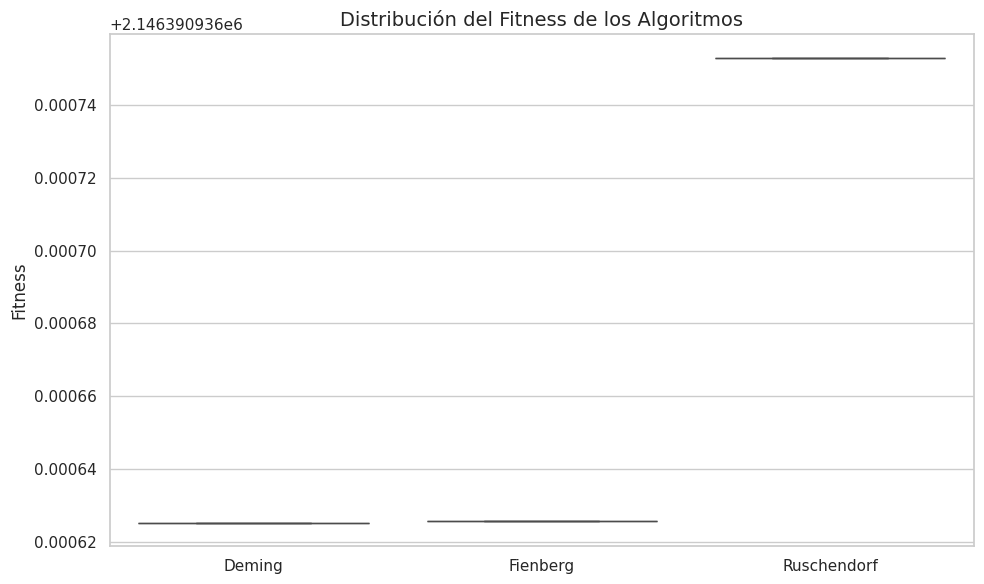

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Listas de resultados de fitness para cada algoritmo
# Se asume que ya tienes las listas fitness_deming_list, fitness_fienberg_list, fitness_ruschendorf_list

# Crear un DataFrame con los resultados de fitness
df_fitness = pd.DataFrame({
    'Deming': fitness_deming_list,
    'Fienberg': fitness_fienberg_list,
    'Ruschendorf': fitness_ruschendorf_list
})

# Configurar el estilo de seaborn
sns.set(style="whitegrid")

# Crear un gráfico de boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_fitness)

# Título y etiquetas
plt.title("Distribución del Fitness de los Algoritmos", fontsize=14)
plt.ylabel("Fitness", fontsize=12)
plt.xticks([0, 1, 2], ["Deming", "Fienberg", "Ruschendorf"])

# Mostrar el gráfico
plt.tight_layout()
plt.show()
